In [11]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import sweetviz as sv
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import warnings
from scipy.stats import zscore, mode
from sklearn.metrics import (silhouette_samples,silhouette_score,make_scorer,mean_absolute_error, r2_score, mean_squared_error,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
from sklearn.base import (BaseEstimator,TransformerMixin,ClassifierMixin,RegressorMixin)
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, BaseCrossValidator, KFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import joblib
from joblib import load
import os
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans, silhouette_score as ts_silhouette_score
import shap
from lime import lime_tabular
from sklearn.model_selection import GroupKFold

In [12]:
# Cargar los datos desde el archivo Excel
file_path = 'C:/Users/Andy/OneDrive/Desktop/MCD/Tesis/Datos_fuente_Bloomberg/en valores/serie completa 2014-2024/Dataset/dataset_oct_2014-set_2024_sin dlocal.xlsx'
df = pd.read_excel(file_path, sheet_name='dataset')

In [13]:
df.head()

,Empresa,Fecha,P_E,P_B,P_S,P_Share,ROCE_sp,ROCE_l,EBIT_sp,EBIT_l,...,Efectivo y equiv_l,CPI,CPI_Exp_mediana,CPI_Exp_promedio,Fed Funds Rate,Fed Funds Rate_Exp_mediana,Fed Funds Rate_Exp_promedio,Non farm payrolls,Non farm payrolls_Exp_mediana,Non farm payrolls_Exp_promedio
0,FLWS US Equity,20141031,35.4266,2.8638,0.6770,8.03,8.881198,6.831567,18.021166,-0.264000,...,2.610333,1.7,0.016,0.0162,0.25,0.0025,0.0025,240,215k,216.22k
1,FLWS US Equity,20141128,37.7207,3.0493,0.7208,8.55,9.469145,7.776733,17.412222,2.352000,...,3.906667,1.3,0.016,0.0157,0.25,0.0025,0.0025,284,235k,236.62k
2,FLWS US Equity,20141231,11.3711,2.3843,0.5153,8.24,8.721900,8.721900,4.968000,4.968000,...,5.203000,0.8,0.014,0.0142,0.25,0.0025,0.0025,278,230k,229.16k
3,FLWS US Equity,20150130,10.8881,2.2830,0.4934,7.89,7.711122,8.876467,-9.636666,1.102667,...,4.188000,-0.1,0.007,0.0069,0.25,0.0025,0.0025,196,240k,234.73k
4,FLWS US Equity,20150227,17.2222,3.6111,0.7804,12.48,7.508469,9.031033,-16.726944,-2.762667,...,3.173000,0.0,-0.001,-0.0013,0.25,0.0025,0.0025,269,228k,228.96k


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Empresa                         21600 non-null  object 
 1   Fecha                           21600 non-null  int64  
 2   P_E                             21600 non-null  float64
 3   P_B                             21600 non-null  float64
 4   P_S                             21600 non-null  float64
 5   P_Share                         21600 non-null  float64
 6   ROCE_sp                         21600 non-null  float64
 7   ROCE_l                          21600 non-null  float64
 8   EBIT_sp                         21600 non-null  float64
 9   EBIT_l                          21600 non-null  float64
 10  Total Activos_sp                21600 non-null  float64
 11  Total Activos_l                 21600 non-null  float64
 12  Deuda a LP_sp                   

In [15]:
# Quitar "k" de las columnas "Non farm payrolls_Exp_mediana" y "Non farm payrolls_Exp_promedio"
df['Non farm payrolls_Exp_mediana'] = df['Non farm payrolls_Exp_mediana'].astype(str).str.replace('k', '')
df['Non farm payrolls_Exp_promedio'] = df['Non farm payrolls_Exp_promedio'].astype(str).str.replace('k', '')

# Convertir las columnas a valores numéricos
df['Non farm payrolls_Exp_mediana'] = pd.to_numeric(df['Non farm payrolls_Exp_mediana'], errors='coerce')
df['Non farm payrolls_Exp_promedio'] = pd.to_numeric(df['Non farm payrolls_Exp_promedio'], errors='coerce')
df['P_B'] = pd.to_numeric(df['P_B'], errors='coerce')
df['P_S'] = pd.to_numeric(df['P_S'], errors='coerce')
df['P_Share'] = pd.to_numeric(df['P_Share'], errors='coerce')

In [16]:
# Convertir la columna de fecha a formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y%m%d')

# Extraer características temporales relevantes
df['mes'] = df['Fecha'].dt.month
df['año'] = df['Fecha'].dt.year
df['periodo'] = df['Fecha'].dt.to_period('M')

In [17]:
# Convertir CPI y Fed Funds Rate a decimales
df['CPI'] = df['CPI'] / 100
df['Fed Funds Rate'] = df['Fed Funds Rate'] / 100

In [18]:
# Calcular diferencias en puntos básicos
df['dif_CPI_mediana'] = (df['CPI'] - df['CPI_Exp_mediana']) * 10000
df['dif_CPI_promedio'] = (df['CPI'] - df['CPI_Exp_promedio']) * 10000

df['dif_FFR_mediana'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_mediana']) * 10000
df['dif_FFR_promedio'] = (df['Fed Funds Rate'] - df['Fed Funds Rate_Exp_promedio']) * 10000

# Calcular diferencia
df['dif_NFP_mediana'] = (df['Non farm payrolls'] - df['Non farm payrolls_Exp_mediana'])
df['dif_NFP_promedio'] = (df['Non farm payrolls'] - df['Non farm payrolls_Exp_promedio'])

In [19]:
# Lista de columnas numéricas para análisis con mensualización lineal de los ratios 
# y variables macroeconómicas calculadas con mediana
columnas_numericas_lineal_mediana= [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_l',
    'EBIT_l',
    'Total Activos_l',
    'Deuda a LP_l',
    'ROA_l',
    'Beneficio neto_l',
    'ROI_l',
    'EV_l',
    'Cap de mercado_l',
    'Deuda a CP_l',
    'Efectivo y equiv_l',
    'dif_CPI_mediana',
    'dif_FFR_mediana',
    'dif_NFP_mediana'
]

In [20]:
# Lista de columnas numéricas para análisis con mensualización spline de los ratios 
# y variables macroeconómicas calculadas con mediana
columnas_numericas_spline_mediana = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_sp',
    'EBIT_sp',
    'Total Activos_sp',
    'Deuda a LP_sp',
    'ROA_sp',
    'Beneficio neto_sp',
    'ROI_sp',
    'EV_sp',
    'Cap de mercado_sp',
    'Deuda a CP_sp',
    'Efectivo y equiv_sp',
    'dif_CPI_mediana',
    'dif_FFR_mediana',
    'dif_NFP_mediana'
]

In [21]:
# Lista de columnas numéricas para análisis con mensualización lineal de los ratios 
# y variables macroeconómicas calculadas con promedio
columnas_numericas_lineal_promedio = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_l',
    'EBIT_l',
    'Total Activos_l',
    'Deuda a LP_l',
    'ROA_l',
    'Beneficio neto_l',
    'ROI_l',
    'EV_l',
    'Cap de mercado_l',
    'Deuda a CP_l',
    'Efectivo y equiv_l',
    'dif_CPI_promedio',
    'dif_FFR_promedio',
    'dif_NFP_promedio'
]

In [22]:
# Lista de columnas numéricas para análisis con mensualización spline de los ratios 
# y variables macroeconómicas calculadas con promedio
columnas_numericas_spline_promedio = [
    'P_E',
    'P_B',
    'P_S',
    'P_Share',
    'ROCE_sp',
    'EBIT_sp',
    'Total Activos_sp',
    'Deuda a LP_sp',
    'ROA_sp',
    'Beneficio neto_sp',
    'ROI_sp',
    'EV_sp',
    'Cap de mercado_sp',
    'Deuda a CP_sp',
    'Efectivo y equiv_sp',
    'dif_CPI_promedio',
    'dif_FFR_promedio',
    'dif_NFP_promedio'
]

In [23]:
listas_columnas = {
    'lineal_mediana': columnas_numericas_lineal_mediana,
    'spline_mediana': columnas_numericas_spline_mediana,
    'lineal_promedio': columnas_numericas_lineal_promedio,
    'spline_promedio': columnas_numericas_spline_promedio
}

In [24]:
listas_columnas

{'lineal_mediana': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_l',
  'EBIT_l',
  'Total Activos_l',
  'Deuda a LP_l',
  'ROA_l',
  'Beneficio neto_l',
  'ROI_l',
  'EV_l',
  'Cap de mercado_l',
  'Deuda a CP_l',
  'Efectivo y equiv_l',
  'dif_CPI_mediana',
  'dif_FFR_mediana',
  'dif_NFP_mediana'],
 'spline_mediana': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_sp',
  'EBIT_sp',
  'Total Activos_sp',
  'Deuda a LP_sp',
  'ROA_sp',
  'Beneficio neto_sp',
  'ROI_sp',
  'EV_sp',
  'Cap de mercado_sp',
  'Deuda a CP_sp',
  'Efectivo y equiv_sp',
  'dif_CPI_mediana',
  'dif_FFR_mediana',
  'dif_NFP_mediana'],
 'lineal_promedio': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_l',
  'EBIT_l',
  'Total Activos_l',
  'Deuda a LP_l',
  'ROA_l',
  'Beneficio neto_l',
  'ROI_l',
  'EV_l',
  'Cap de mercado_l',
  'Deuda a CP_l',
  'Efectivo y equiv_l',
  'dif_CPI_promedio',
  'dif_FFR_promedio',
  'dif_NFP_promedio'],
 'spline_promedio': ['P_E',
  'P_B',
  'P_S',
  'P_Share',
  'ROCE_sp',
  'E

In [25]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 1: Importaciones y Funciones Auxiliares                  │
# └─────────────────────────────────────────────────────────────────┘
import pandas as pd
import numpy as np

def pct_missing_by_column(df, columns):
    """Devuelve % de NaNs por columna, ordenado descendente."""
    return (df[columns].isna().mean() * 100).sort_values(ascending=False)

def pct_missing_by_group(df, group_col, features):
    """Devuelve Series con el máximo % de NaNs en cualquier feature por grupo."""
    missing = df.groupby(group_col)[features]\
                .apply(lambda g: g.isna().mean()*100)
    return missing.max(axis=1)

def filter_companies_by_target_missing(df, group_col, target_col):
    """Filtra y devuelve df sin empresas que tengan ANY NaN en target_col."""
    ok = ~df.groupby(group_col)[target_col].apply(lambda s: s.isna().any())
    valid_companies = ok[ok].index
    return df[df[group_col].isin(valid_companies)].copy()

def impute_by_group(df, group_col, zero_ok_cols, other_cols):
    """
    Imputa NaNs:
      • zero_ok_cols  -> sustituye NaN por 0
      • other_cols    -> ffill por empresa + mediana por empresa
                         y crea bandera *_was_na*
    """
    df = df.sort_values([group_col, 'Fecha']).copy()
    
    # 2.1 columnas donde 0 es válido
    df[zero_ok_cols] = df[zero_ok_cols].fillna(0)
    
    # 2.2 columnas donde 0 NO es válido
    #     (a) bandera de NaN original
    for col in other_cols:
        df[f"{col}_was_na"] = df[col].isna().astype('int8')
    
    #     (b) ffill por empresa
    df[other_cols] = df.groupby(group_col)[other_cols].ffill()
    
    #     (c) mediana histórica de la empresa
    df[other_cols] = df.groupby(group_col)[other_cols]\
                       .transform(lambda g: g.fillna(g.median()))
    
    #     (d) si aún quedan NaNs (empresas sin historial) — opcional: drop o 0
    df[other_cols] = df[other_cols].fillna(0)
    return df

def create_lags(df, group_col, date_col, features, lag=1):
    """Genera columnas de lag para cada feature dentro de cada grupo."""
    df2 = df.sort_values([group_col, date_col]).copy()
    for feat in features:
        df2[f"{feat}_lag{lag}"] = df2.groupby(group_col)[feat].shift(lag)
    return df2


#### ¿Por qué “rellenar con 0” suele ser sub-óptimo?

| Tipo de variable                                         | Interpretación de un 0 real              | Riesgo al imputar 0                                                                                                        |
| -------------------------------------------------------- | ---------------------------------------- | -------------------------------------------------------------------------------------------------------------------------- |
| **Ratios de valoración** (`P_B`, `ROA_l`, …)             | Prácticamente imposible (salvo quiebra)  | Distorsionas la escala; 0 queda varios σ lejos del rango normal → el modelo aprende que “falta” ≡ “baratísimo / negativo”. |
| **Variables macro** (diferencias de CPI, FFR, …)         | 0 ―sí tiene sentido (sin sorpresa macro) | Ok para estas columnas.                                                                                                    |
| **Magnitudes contables** (`Beneficio neto_l`, `EV_l`, …) | 0 a veces es válido, pero raro           | Lo mismo: creas outliers artificiales.                                                                                     |

En la práctica, el 0 termina funcionando como **flag implícito de “faltaba dato”** —no siempre malo, pero no controlas qué está aprendiendo el modelo.

---

#### Recomendaciones de imputación “más sanas”

1. **FFill + indicadores de ausencia (opción sencilla y segura)**

   ```python
   def impute_by_group(df, group_col, features, fill_strategy='ffill'):
       df = df.sort_values([group_col, 'Fecha']).copy()
       # ① bandera de NaN original
       for col in features:
           df[f"{col}_was_na"] = df[col].isna().astype(int)
       # ② imputación
       if fill_strategy == 'ffill':
           df[features] = df.groupby(group_col)[features].ffill()
       elif fill_strategy == 'median':
           df[features] = df.groupby(group_col)[features]\
                            .transform(lambda g: g.fillna(g.median()))
       # ③ todavía pueden quedar NaNs (primeros meses) → back-fill corto o drop
       df[features] = df.groupby(group_col)[features].bfill(limit=1)
       return df
   ```

   *Ventaja*: el modelo puede explotar la bandera “was\_na” si realmente importa que falte el dato, sin forzarte a inventar ceros.

2. **Mediana histórica por empresa**
   Usar `groupby(group_col).transform('median')` para los NaNs que queden después del *ffill* inicial.

   * Mantienes la **escala típica de la compañía**.
   * Sigues sin mirar al futuro (la mediana del *pasado*).

3. **Relleno contextual (industria / región)**
   Si tienes un campo *Industria*, puedes caer en la mediana de la industria cuando toda la serie de la empresa es NaN al principio.

4. **Model-based / KNN / IterativeImputer**
   Sólo vale la pena si el % de faltantes es grande y los datos son ricos. Tendrías que aplicarlo **dentro del fold** para no fugar información → más complejo.

---

#### ¿Cómo decidir?

* **% faltante < 3-5 %**: con *ffill* bastará, bandera opcional.
* **Ratios muy volátiles** (P/E, P/S): mediana de la propia empresa es más robusta que 0.
* **Macros**: 0 (sin sorpresa) puede mantenerse.
* **Series nuevas** (empresas con pocos meses): quizá prefieras descartar los primeros registros hasta que tengas un historial mínimo.

> ⚠️  **Nunca** mezcles datos de TEST en el cálculo de la imputación.
> Eso ya lo cumples, porque imputas **antes** del *split* por empresa. Si alguna vez haces *split temporal* dentro de la misma empresa, tendrás que imputar **después** de cortar la parte de entrenamiento.

---

#### Implementación rápida para tu notebook

```python
# Sustituye la antigua función:
def impute_by_group(df, group_col, features):
    df = df.sort_values([group_col, 'Fecha']).copy()
    
    # 1️⃣ bandera de NaN original
    for col in features:
        df[f"{col}_was_na"] = df[col].isna().astype('int8')
    
    # 2️⃣ ffill dentro de la empresa
    df[features] = df.groupby(group_col)[features].ffill()
    
    # 3️⃣ mediana histórica de la empresa para los que sigan NaN
    df[features] = df.groupby(group_col)[features]\
                     .transform(lambda g: g.fillna(g.median()))
    
    # 4️⃣ aún podrían quedar NaNs (todo un historial vacío) → opcional:
    df[features] = df[features].fillna(0)   # o bien dropna()
    return df
```

* Con esto eliminas los “0 ficticios” para ratios, mantienes coherencia de escala y das al modelo la posibilidad de aprender si “faltaba” el dato.

---

#### Resumen

* **Eliminar `fill_value=0` por defecto** es, casi siempre, una mejora.
* Reemplázalo por `ffill` + mediana (o media/percentil) **por empresa** y, si quieres, añade **banderas de imputación**.
* Para las pocas columnas donde 0 es un valor válido (p. ej. sorpresas macro en pbs), puedes seguir usando 0 ad-hoc.


### Implementación en el notebook
#### -------------------------------------------------------------
#### 1) Define listas explícitas
cols_zero_ok = [                     # 0 es un valor con sentido
    'dif_CPI_mediana', 'dif_CPI_promedio',
    'dif_FFR_mediana', 'dif_FFR_promedio',
    'dif_NFP_mediana', 'dif_NFP_promedio',
]
cols_zero_not_ok = [c for c in features_kept   # el resto de tus features numéricas
                    if c not in cols_zero_ok]
#### -------------------------------------------------------------
#### 2) Nueva función de imputación
def impute_by_group(df, group_col, zero_ok_cols, other_cols):
    """
    Imputa NaNs:
      • zero_ok_cols  -> sustituye NaN por 0
      • other_cols    -> ffill por empresa + mediana por empresa
                         y crea bandera *_was_na*
    """
    df = df.sort_values([group_col, 'Fecha']).copy()
    
    # 2.1 columnas donde 0 es válido
    df[zero_ok_cols] = df[zero_ok_cols].fillna(0)
    
    # 2.2 columnas donde 0 NO es válido
    #     (a) bandera de NaN original
    for col in other_cols:
        df[f"{col}_was_na"] = df[col].isna().astype('int8')
    
    #     (b) ffill por empresa
    df[other_cols] = df.groupby(group_col)[other_cols].ffill()
    
    #     (c) mediana histórica de la empresa
    df[other_cols] = df.groupby(group_col)[other_cols]\
                       .transform(lambda g: g.fillna(g.median()))
    
    #     (d) si aún quedan NaNs (empresas sin historial) — opcional: drop o 0
    df[other_cols] = df[other_cols].fillna(0)
    return df

### Uso

df_imputed = impute_by_group(
    df_final, 
    group_col='Empresa', 
    zero_ok_cols=cols_zero_ok, 
    other_cols=cols_zero_not_ok
)

In [26]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 3: Conversión Masiva a Numérico                         │
# └─────────────────────────────────────────────────────────────────┘
# Crear set de features base (sin 'Empresa' ni 'Fecha'), añadir 'P_E' si existe
features_base = {
    col for cols in listas_columnas.values()
            for col in cols if col not in ('Empresa','Fecha')
}
if 'P_E' in df.columns:
    features_base.add('P_E')
numeric_cols = [c for c in sorted(features_base) if c in df.columns]

# Vectorizado
nan_before = df[numeric_cols].isna().sum()
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
nan_after = df[numeric_cols].isna().sum()
print("NaNs añadidos:", (nan_after - nan_before).sum())

NaNs añadidos: 0


In [27]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 4: Filtrar Empresas con NaNs en el Target P_E           │
# └─────────────────────────────────────────────────────────────────┘
df_no_PE_NaN = filter_companies_by_target_missing(df, 'Empresa', 'P_E')
print("Empresas tras filtrar P_E NaN:", df_no_PE_NaN['Empresa'].nunique())

Empresas tras filtrar P_E NaN: 180


In [28]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 5: Excluir Columnas Críticas con Demasiados NaNs        │
# └─────────────────────────────────────────────────────────────────┘
col_pct = pct_missing_by_column(df_no_PE_NaN, numeric_cols)
col_pct

Beneficio neto_l       0.0
Beneficio neto_sp      0.0
dif_NFP_mediana        0.0
dif_FFR_promedio       0.0
dif_FFR_mediana        0.0
dif_CPI_promedio       0.0
dif_CPI_mediana        0.0
Total Activos_sp       0.0
Total Activos_l        0.0
ROI_sp                 0.0
ROI_l                  0.0
ROCE_sp                0.0
ROCE_l                 0.0
ROA_sp                 0.0
ROA_l                  0.0
P_Share                0.0
P_S                    0.0
P_E                    0.0
P_B                    0.0
Efectivo y equiv_sp    0.0
Efectivo y equiv_l     0.0
EV_sp                  0.0
EV_l                   0.0
EBIT_sp                0.0
EBIT_l                 0.0
Deuda a LP_sp          0.0
Deuda a LP_l           0.0
Deuda a CP_sp          0.0
Deuda a CP_l           0.0
Cap de mercado_sp      0.0
Cap de mercado_l       0.0
dif_NFP_promedio       0.0
dtype: float64

In [29]:
umbral_col = 5.0   # % máximo de NaNs tolerable
cols_to_exclude = col_pct[col_pct > umbral_col].index.tolist()
features_kept = [c for c in numeric_cols if c not in cols_to_exclude]
print(f"Columnas excluidas (> {umbral_col}% NaNs):", cols_to_exclude)

Columnas excluidas (> 5.0% NaNs): []


In [30]:
cols_zero_ok = [                     # 0 es un valor con sentido
    'dif_CPI_mediana', 'dif_CPI_promedio',
    'dif_FFR_mediana', 'dif_FFR_promedio',
    'dif_NFP_mediana', 'dif_NFP_promedio',
]
cols_zero_not_ok = [c for c in features_kept   # el resto de tus features numéricas
                    if c not in cols_zero_ok]

In [31]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 6: Excluir Empresas con Demasiados NaNs en Features     │
# └─────────────────────────────────────────────────────────────────┘
umbral_grp = 10   # % máximo de NaNs por empresa
grp_pct = pct_missing_by_group(df_no_PE_NaN, 'Empresa', features_kept)
empresas_final = grp_pct[grp_pct <= umbral_grp].index.tolist()
df_final = df_no_PE_NaN[df_no_PE_NaN['Empresa'].isin(empresas_final)].copy()
print("Empresas finales (<= {umbral_grp}% NaNs):", len(empresas_final))


Empresas finales (<= {umbral_grp}% NaNs): 180


In [32]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 7: Imputar NaNs Restantes                                │
# └─────────────────────────────────────────────────────────────────┘
df_imputed = impute_by_group(
    df_final, 
    group_col='Empresa', 
    zero_ok_cols=cols_zero_ok, 
    other_cols=cols_zero_not_ok
)
print("NaNs totales después de imputar:", df_imputed[features_kept].isna().sum().sum())


NaNs totales después de imputar: 0


In [33]:
# ┌─────────────────────────────────────────────────────────────────┐
# │ BLOQUE 8: Crear DataFrames con Lag (Incluyendo P_E_lag1 como feature) │
# └─────────────────────────────────────────────────────────────────┘
dfs_shifted = {}
LAG_VALUE_EXPERIMENT = 1 # Define el lag a usar (ej. 1 para _lag1)

# Asunciones:
# 1. df_imputed: DataFrame con datos limpios, incluyendo 'Empresa', 'Fecha', 'P_E' y las columnas base.
# 2. listas_columnas: Diccionario {metodo: [lista_de_columnas_base_para_ese_metodo]}
# 3. features_kept: Lista de columnas que pasaron filtros de NaNs (debe incluir 'P_E' si quieres su lag).
#    Si 'P_E' no está en features_kept porque se trató solo como target, necesitaremos añadirlo
#    específicamente para la creación de su lag.

# Asegurarse de que 'P_E' esté considerado para laggear si queremos P_E_lag1
# Esto es importante si 'features_kept' no incluye 'P_E' porque se manejó solo como target antes.
features_kept_for_lags = features_kept.copy() # Trabajar con una copia
if 'P_E' not in features_kept_for_lags and 'P_E' in df_imputed.columns:
    print("  Nota Bloque 8: Añadiendo 'P_E' a la lista de features a considerar para lags, para poder generar P_E_lagN.")
    features_kept_for_lags.append('P_E')
    features_kept_for_lags = sorted(list(set(features_kept_for_lags)))


for metodo, cols_originales_del_metodo in listas_columnas.items():
    print(f"\nProcesando lags para Método: {metodo}")
    # 1. Determinar las features base para este método que SÍ existen y pasaron filtros
    #    Estas son las features (EXCLUYENDO IDs y el target P/E original) para las que se crearán lags.
    #    PERO, si queremos P_E_lag1, P_E debe estar entre las features para las que se crea un lag.
    
    features_base_para_este_metodo = [
        col for col in cols_originales_del_metodo # Empezar con las definidas para el método
        if col in features_kept_for_lags  # Solo las que pasaron el filtro de NaNs global (y ahora incluye P_E)
           and col in df_imputed.columns    # Y existen en df_imputed
           and col not in ('Empresa', 'Fecha') # Excluir IDs
           # NO excluimos 'P_E' aquí porque queremos generar P_E_lagN
    ]

    if not features_base_para_este_metodo:
        print(f"  Método '{metodo}': No hay features base válidas (de 'features_kept_for_lags') para crear lags. Se omite.")
        continue
    
    print(f"  Features base para {metodo} que se usarán para generar lags ({len(features_base_para_este_metodo)}): {features_base_para_este_metodo[:5]}...")

    # 2. Preparar el DataFrame base para la función create_lags
    #    Necesita 'Empresa', 'Fecha', y TODAS las 'features_base_para_este_metodo' (que ahora incluye 'P_E')
    columnas_para_df_con_lags = ['Empresa', 'Fecha']
    # Añadir las features base, asegurando que 'P_E' (target original) también esté si no está ya en features_base_para_este_metodo
    # (aunque debería estarlo si se añadió a features_kept_for_lags)
    columnas_para_df_con_lags.extend(f for f in features_base_para_este_metodo if f not in columnas_para_df_con_lags)
    if 'P_E' not in columnas_para_df_con_lags and 'P_E' in df_imputed.columns: # Asegurar que P_E (target) esté para el join final
        columnas_para_df_con_lags.append('P_E')

    columnas_para_df_con_lags = [col for col in columnas_para_df_con_lags if col in df_imputed.columns] # Solo existentes
    
    if not all(essential_col in columnas_para_df_con_lags for essential_col in ['Empresa', 'Fecha']):
        print(f"  Método '{metodo}': Faltan 'Empresa' o 'Fecha'. Se omite.")
        continue
        
    df_para_crear_lags = df_imputed[columnas_para_df_con_lags].copy()

    # 3. Generar los lags para TODAS las features_base_para_este_metodo (incluyendo P_E)
    #    La función create_lags añadirá columnas como 'FeatureX_lag1', 'P_E_lag1'
    df_con_lags_generados = create_lags(df_para_crear_lags, 'Empresa', 'Fecha', features_base_para_este_metodo, lag=LAG_VALUE_EXPERIMENT)

    # 4. Definir las columnas de lag que se usarán como predictores finales
    #    Esto incluye P_E_lagN y los lags de las otras features.
    predictor_cols_finales_con_lag = [f"{feat}_lag{LAG_VALUE_EXPERIMENT}" for feat in features_base_para_este_metodo]
    
    # Asegurar que estas columnas de lag realmente se generaron
    predictor_cols_finales_existentes = [col for col in predictor_cols_finales_con_lag if col in df_con_lags_generados.columns]

    if not predictor_cols_finales_existentes:
         print(f"  Método '{metodo}': No se generaron columnas de lag válidas. Se omite.")
         continue
    
    # 5. Eliminar filas donde CUALQUIERA de los predictores de lag finales sea NaN
    rows_before_dropna = len(df_con_lags_generados)
    df_con_lags_generados.dropna(subset=predictor_cols_finales_existentes, inplace=True)
    rows_after_dropna = len(df_con_lags_generados)
    print(f"  {metodo}: Se eliminaron {rows_before_dropna - rows_after_dropna} filas por NaNs en lags.")


    if df_con_lags_generados.empty:
        print(f"  Método '{metodo}': El DataFrame quedó vacío después de crear lags y dropna.")
    else:
        # El DataFrame final para este método contendrá:
        # 'Empresa', 'Fecha', 'P_E' (target actual), y todas las 'predictor_cols_finales_existentes'
        # (que incluye P_E_lagN y los lags de otras features)
        
        # Seleccionar solo las columnas necesarias para el siguiente bloque (experimentos)
        columnas_a_mantener_en_dfs_shifted = ['Empresa', 'Fecha']
        if 'P_E' in df_con_lags_generados.columns: # Target
            columnas_a_mantener_en_dfs_shifted.append('P_E')
        columnas_a_mantener_en_dfs_shifted.extend(predictor_cols_finales_existentes) # Todas las features _lagN
        
        # Eliminar duplicados en la lista de columnas por si acaso
        columnas_a_mantener_en_dfs_shifted = sorted(list(set(col for col in columnas_a_mantener_en_dfs_shifted if col in df_con_lags_generados.columns)))

        dfs_shifted[metodo] = df_con_lags_generados[columnas_a_mantener_en_dfs_shifted].copy()
        
        print(f"  Método '{metodo}' (dfs_shifted): {dfs_shifted[metodo].shape[0]} filas, {dfs_shifted[metodo].shape[1]} columnas.")
        print(f"    Predictores finales (lags): {len(predictor_cols_finales_existentes)} {predictor_cols_finales_existentes[:5]}...")
        if f'P_E_lag{LAG_VALUE_EXPERIMENT}' in predictor_cols_finales_existentes:
            print(f"    ¡Confirmado! 'P_E_lag{LAG_VALUE_EXPERIMENT}' está incluido como predictor.")


Procesando lags para Método: lineal_mediana
  Features base para lineal_mediana que se usarán para generar lags (18): ['P_E', 'P_B', 'P_S', 'P_Share', 'ROCE_l']...
  lineal_mediana: Se eliminaron 180 filas por NaNs en lags.
  Método 'lineal_mediana' (dfs_shifted): 21420 filas, 21 columnas.
    Predictores finales (lags): 18 ['P_E_lag1', 'P_B_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROCE_l_lag1']...
    ¡Confirmado! 'P_E_lag1' está incluido como predictor.

Procesando lags para Método: spline_mediana
  Features base para spline_mediana que se usarán para generar lags (18): ['P_E', 'P_B', 'P_S', 'P_Share', 'ROCE_sp']...
  spline_mediana: Se eliminaron 180 filas por NaNs en lags.
  Método 'spline_mediana' (dfs_shifted): 21420 filas, 21 columnas.
    Predictores finales (lags): 18 ['P_E_lag1', 'P_B_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROCE_sp_lag1']...
    ¡Confirmado! 'P_E_lag1' está incluido como predictor.

Procesando lags para Método: lineal_promedio
  Features base para lineal_promedio que

### TL;DR

Con la estrategia que usas **no hay fuga de información relevante (“data leakage”)**.
Los dos puntos críticos – imputación y creación de lags – se hacen **dentro de cada empresa** y **solo con datos pasados**, y el *split* final que decide qué empresas van a TRAIN y cuáles a TEST se hace **después**.
Aun así, te dejo un checklist para que veas dónde *podría* aparecer fuga si cambias algo.

---

## Por qué tu pipeline está a salvo

| Paso                                                      | Qué haces                                                             | ¿Puede usar datos del futuro? | Motivo de seguridad                                                                          |
| --------------------------------------------------------- | --------------------------------------------------------------------- | ----------------------------- | -------------------------------------------------------------------------------------------- |
| **1. Imputación `ffill` por empresa** (`impute_by_group`) | Rellena NaNs mirando **solo hacia atrás** dentro de la misma empresa. | **No**                        | `ffill()` nunca mira valores futuros; además lo haces **antes** de crear lags.               |
| **2. Creación de lags** (`create_lags`)                   | `shift(lag)` por empresa.                                             | **No**                        | `shift(1)` desplaza la serie hacia abajo → sólo usa valores anteriores.                      |
| **3. Split TRAIN/TEST** (`train_test_split_by_empresa`)   | Todas las filas de una empresa van al mismo lado.                     | **No**                        | El modelo nunca ve ni un solo registro de la(s) empresa(s) de TEST durante el entrenamiento. |
| **4. Entrenamiento & CV**                                 | Opcionalmente CV por grupos (`GroupKFold`).                           | **No**                        | El agrupamiento es por `Empresa`, compatible con el split.                                   |
| **5. Predicción back-test en DLocal**                     | Para la fila *t*, sólo usas lags creados con la fila *t-1*.           | **No**                        | No hay look-ahead; cada predicción se basa en información realmente disponible.              |

### Sobre el orden “Empresa 1 (todas las fechas) → Empresa 2 → …”

* Aunque el fichero esté así, tu helper **elige las empresas aleatoriamente** (`shuffle=True`) antes de partir en TRAIN/TEST ⇒ no dependes del orden físico.
* Si algún día quitas el `shuffle`, el split seguiría siendo “por empresa”, así que tampoco habría fuga (pero el conjunto TEST podría quedar sesgado: solo “últimas” empresas del archivo).

---

## Dónde habría riesgo *si cambias la lógica*

1. **Back-test temporal dentro de la misma empresa**

   * Si quisieras predecir 2023 usando un modelo entrenado hasta 2021 **y** imputaras antes de cortar, el `ffill()` de 2023 rellenaría huecos en 2020 y contaminaría el entrenamiento.
   * Solución: primero cortas por fecha, **después** imputas/laggeas cada tramo.

2. **Imputar con técnicas que miran hacia delante**

   * Ej.: `bfill`, interpolaciones simétricas o modelos que usen toda la serie.
   * En tu notebook no las usas, pero si las añades, hazlo **después** del split temporal.

3. **Variables target “infiltradas” en los predictores**

   * Tú sólo incluyes `P_E_lag1` (válido). Evita usar `P_E` actual como feature.

---

## Checklist rápido

* [x] Imputación por empresa **solo con pasado** (`ffill`).
* [x] Lags creados **después** de imputar.
* [x] Split por empresa hecho **después** de todo lo anterior.
* [x] Ninguna fila de una empresa de TEST aparece en TRAIN.
* [x] Para DLocal, el modelo nunca se entrenó con datos de DLocal.

Si se mantienen estas condiciones, **puedes estar tranquilo: no hay data leakage**.


## Dlocal

In [34]:
# Cargar los datos desde el archivo Excel
file_path = 'C:/Users/Andy/OneDrive/Desktop/MCD/Tesis/Datos_fuente_Bloomberg/en valores/serie completa 2014-2024/Dataset/dataset_dlocal_casi sin vacías.xlsx'
df_dlocal = pd.read_excel(file_path, sheet_name='dataset (2)')

In [35]:
df_dlocal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Empresa                         28 non-null     object 
 1   Fecha                           28 non-null     int64  
 2   P_E                             28 non-null     float64
 3   P_B                             28 non-null     float64
 4   P_S                             28 non-null     float64
 5   P_Share                         28 non-null     float64
 6   ROCE_sp                         28 non-null     float64
 7   ROCE_l                          28 non-null     float64
 8   EBIT_sp                         28 non-null     float64
 9   EBIT_l                          28 non-null     float64
 10  Total Activos_sp                28 non-null     float64
 11  Total Activos_l                 28 non-null     float64
 12  Deuda a LP_sp                   28 non

In [36]:
# Quitar "k" de las columnas "Non farm payrolls_Exp_mediana" y "Non farm payrolls_Exp_promedio"
df_dlocal['Non farm payrolls_Exp_mediana'] = df_dlocal['Non farm payrolls_Exp_mediana'].astype(str).str.replace('k', '')
df_dlocal['Non farm payrolls_Exp_promedio'] = df_dlocal['Non farm payrolls_Exp_promedio'].astype(str).str.replace('k', '')

# Convertir las columnas a valores numéricos
df_dlocal['Non farm payrolls_Exp_mediana'] = pd.to_numeric(df_dlocal['Non farm payrolls_Exp_mediana'], errors='coerce')
df_dlocal['Non farm payrolls_Exp_promedio'] = pd.to_numeric(df_dlocal['Non farm payrolls_Exp_promedio'], errors='coerce')

df_dlocal['P_B'] = pd.to_numeric(df_dlocal['P_B'], errors='coerce')
#df_dlocal['P_TB'] = pd.to_numeric(df_dlocal['P_TB'], errors='coerce')
df_dlocal['P_S'] = pd.to_numeric(df_dlocal['P_S'], errors='coerce')
#df_dlocal['P_FCF'] = pd.to_numeric(df_dlocal['P_FCF'], errors='coerce')
df_dlocal['P_Share'] = pd.to_numeric(df_dlocal['P_Share'], errors='coerce')

In [37]:
# Convertir la columna de fecha a formato datetime
df_dlocal['Fecha'] = pd.to_datetime(df_dlocal['Fecha'], format='%Y%m%d')

# Extraer características temporales relevantes
df_dlocal['mes'] = df_dlocal['Fecha'].dt.month
df_dlocal['año'] = df_dlocal['Fecha'].dt.year
df_dlocal['periodo'] = df_dlocal['Fecha'].dt.to_period('M')

In [38]:
# Convertir CPI y Fed Funds Rate a decimales
df_dlocal['CPI'] = df_dlocal['CPI'] / 100
df_dlocal['Fed Funds Rate'] = df_dlocal['Fed Funds Rate'] / 100

In [39]:
# Calcular diferencias en puntos básicos
df_dlocal['dif_CPI_mediana'] = (df_dlocal['CPI'] - df_dlocal['CPI_Exp_mediana']) * 10000
df_dlocal['dif_CPI_promedio'] = (df_dlocal['CPI'] - df_dlocal['CPI_Exp_promedio']) * 10000

df_dlocal['dif_FFR_mediana'] = (df_dlocal['Fed Funds Rate'] - df_dlocal['Fed Funds Rate_Exp_mediana']) * 10000
df_dlocal['dif_FFR_promedio'] = (df_dlocal['Fed Funds Rate'] - df_dlocal['Fed Funds Rate_Exp_promedio']) * 10000

# Calcular diferencia
df_dlocal['dif_NFP_mediana'] = (df_dlocal['Non farm payrolls'] - df_dlocal['Non farm payrolls_Exp_mediana'])
df_dlocal['dif_NFP_promedio'] = (df_dlocal['Non farm payrolls'] - df_dlocal['Non farm payrolls_Exp_promedio'])

In [40]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib
import os 
import re 

# --- Modelos ---
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# --- Métricas y Preprocesamiento ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, GroupKFold 
from sklearn.pipeline import Pipeline

# Ignorar warnings comunes
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# =====================================
# CLASE AUXILIAR DropColumns (Definir una vez)
# =====================================
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns if columns is not None else []
    def fit(self, X, y=None): return self
    def transform(self, X):
        if not isinstance(X, pd.DataFrame): return X
        return X.copy().drop(columns=self.columns, errors='ignore')
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            raise ValueError("input_features debe ser provisto a get_feature_names_out para DropColumns")
        return [col for col in input_features if col not in self.columns]

# =====================================
# FUNCIONES AUXILIARES
# =====================================
def rmse(y_true, y_pred):
    y_true_np, y_pred_np = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_true_np, y_pred_np = y_true_np[mask], y_pred_np[mask]
    if len(y_true_np) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

def train_test_split_by_empresa(df_model_input, n_empresas_prueba):
    df_model = df_model_input.copy()
    if 'Empresa' not in df_model.columns: raise KeyError("'Empresa' necesaria")
    if 'P_E' not in df_model.columns: raise KeyError("'P_E' (target) necesaria")
    empresas_unicas = df_model['Empresa'].unique()
    n_total_empresas = len(empresas_unicas)
    if n_total_empresas == 0: return None, None, None, None
    if n_total_empresas == 1:
        X = df_model.drop(columns=['P_E']); y = df_model['P_E']
        return X.copy(), y.copy(), pd.DataFrame(columns=X.columns), pd.Series(dtype=y.dtype)
    n_empresas_prueba_valido = max(0, min(n_empresas_prueba, n_total_empresas - 1 if n_total_empresas > 0 else 0))
    if n_empresas_prueba_valido != n_empresas_prueba:
        print(f"  Advertencia train_test_split: n_empresas_prueba ajustado de {n_empresas_prueba} a {n_empresas_prueba_valido}")
    n_empresas_prueba = n_empresas_prueba_valido
    if n_empresas_prueba == 0:
        empresas_entrenamiento = empresas_unicas; empresas_prueba = np.array([])
    else:
        empresas_entrenamiento, empresas_prueba = train_test_split(
            empresas_unicas, test_size=n_empresas_prueba, random_state=42, shuffle=True)
    mask_entrenamiento = df_model['Empresa'].isin(empresas_entrenamiento)
    X = df_model.drop(columns=['P_E']); y = df_model['P_E']
    X_train, y_train = X[mask_entrenamiento].copy(), y[mask_entrenamiento].copy()
    if n_empresas_prueba > 0 and len(empresas_prueba) > 0:
        mask_prueba = df_model['Empresa'].isin(empresas_prueba)
        X_test, y_test = X[mask_prueba].copy(), y[mask_prueba].copy()
        if X_test.empty and not mask_prueba.empty() and not X_train.empty : 
             X_test = pd.DataFrame(columns=X_train.columns)
             y_test = pd.Series(dtype=y_train.dtype)
    else:
        X_test_cols = X_train.columns if not X_train.empty else (X.columns if not X.empty else [])
        y_test_dtype = y_train.dtype if not y_train.empty else (y.dtype if not y.empty else float)
        X_test, y_test = pd.DataFrame(columns=X_test_cols), pd.Series(dtype=y_test_dtype)
    if X_train.empty and n_total_empresas > 0 :
        return None, None, None, None
    return X_train, y_train, X_test, y_test

def evaluate_model(y_test, y_pred):
    y_test_np, y_pred_np = np.asarray(y_test), np.asarray(y_pred)
    mask = np.isfinite(y_test_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_test_np, y_pred_np = y_test_np[mask], y_pred_np[mask]
    if len(y_test_np) == 0: return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    mae = mean_absolute_error(y_test_np, y_pred_np); rmse_val = rmse(y_test_np, y_pred_np)
    r2 = np.nan
    if len(y_test_np) > 1 and np.var(y_test_np) > 1e-9:
        try: r2 = r2_score(y_test_np, y_pred_np)
        except ValueError: pass
    elif len(y_test_np) > 0 and mean_squared_error(y_test_np, y_pred_np) < 1e-9: r2 = 1.0
    elif len(y_test_np) > 0: r2 = 0.0
    return {'RMSE': rmse_val, 'MAE': mae, 'R2': r2}

def sort_by_timestep(X_df, y_series):
    X, y = X_df.copy(), y_series.copy()
    if 'time_step' not in X.columns: return X, y
    if not isinstance(y, pd.Series) or not X.index.equals(y.index):
        if len(y) == len(X): y = pd.Series(np.asarray(y), index=X.index, name=getattr(y, 'name', 'target'))
        else: print("Error sort_by_timestep: y no alineable con X."); return X, y
    X_sorted = X.sort_values('time_step'); y_sorted = y.loc[X_sorted.index]
    return X_sorted, y_sorted

def plot_feature_importances(model_or_pipeline, feature_names, title="Importancia de Características"):
    try:
        estimator = model_or_pipeline
        if hasattr(model_or_pipeline, 'steps'): 
            estimator = model_or_pipeline.steps[-1][1]
        elif hasattr(model_or_pipeline, 'best_estimator_'): 
            estimator_from_grid = model_or_pipeline.best_estimator_
            if hasattr(estimator_from_grid, 'steps'): 
                 estimator = estimator_from_grid.steps[-1][1]
            else: 
                 estimator = estimator_from_grid
        if not hasattr(estimator, 'feature_importances_'):
            print(f"Estimador {type(estimator).__name__} no tiene 'feature_importances_'.")
            return None
        importances = estimator.feature_importances_
        names_to_use = feature_names 
        if hasattr(estimator, 'feature_names_in_') and len(estimator.feature_names_in_) == len(importances):
            names_to_use = list(estimator.feature_names_in_)
        elif len(feature_names) != len(importances):
            print(f"Error plot_feature_importances: Longitud de nombres ({len(feature_names)}) no coincide con importancias ({len(importances)}).")
            return None
        fi_df = pd.DataFrame({'feature': names_to_use, 'importance': importances}).sort_values('importance', ascending=False).head(30)
        if fi_df.empty: print("No hay importancias para graficar."); return None
        plt.figure(figsize=(10, max(5, len(fi_df) * 0.3))); plt.barh(fi_df['feature'], fi_df['importance'])
        plt.xlabel('Importancia'); plt.ylabel('Característica'); plt.title(title); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
        return fi_df
    except Exception as e: print(f"Error graficando importancia: {e}"); return None

#### Sin transformación logarítmica


Procesando Método: lineal_mediana (SIN Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=24.3463, MAE=4.2828, R2=0.2830
    Métricas Test RF_HP: RMSE=19.1328, MAE=3.9345, R2=0.5572
    Métricas Test XGB_Simple: RMSE=34.5271, MAE=5.1425, R2=-0.4420
    Métricas Test XGB_HP: RMSE=26.5116, MAE=4.3060, R2=0.1498
    Métricas Test LGBM_Simple: RMSE=29.7207, MAE=5.0284, R2=-0.0684
    Métricas Test LGBM_HP: RMSE=26.1546, MAE=4.8631, R2=0.1726
    Métricas Test CB_Simple: RMSE=18.9338, MAE=4.4350, R2=0.5664
    Métricas Test CB_HP: RMSE=20.9267, MAE=5.1141, R2=0.4703

Tiempo total para Método: lineal_mediana: 248.00s

Procesando Método: spline_mediana (SIN Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=22.8511, MAE=4.2366, R2=0.3684
    Métricas Test RF_HP: RMSE=20.1600, MAE=3.9465, R2=0.5084
    Métricas Test XGB_Simple: RMSE=37.7567, MAE=5.1537, R2=-0.7243
    Métricas Test XGB_HP: RMSE=21.8231, MAE=4.1700, R2=0.4239
    Métr

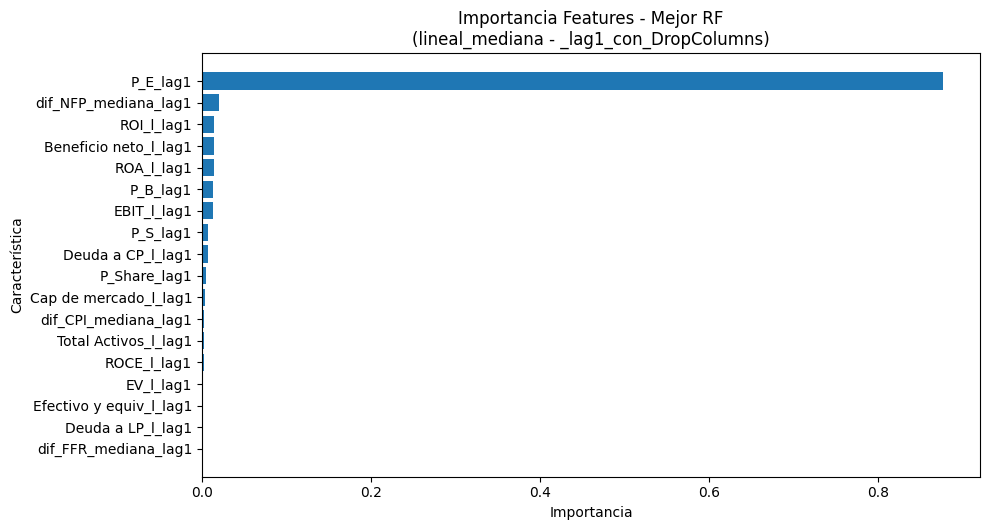

  Mejor XGB para lineal_mediana: RMSE = 26.5116
    Generando importancia de features para Mejor XGB de lineal_mediana...


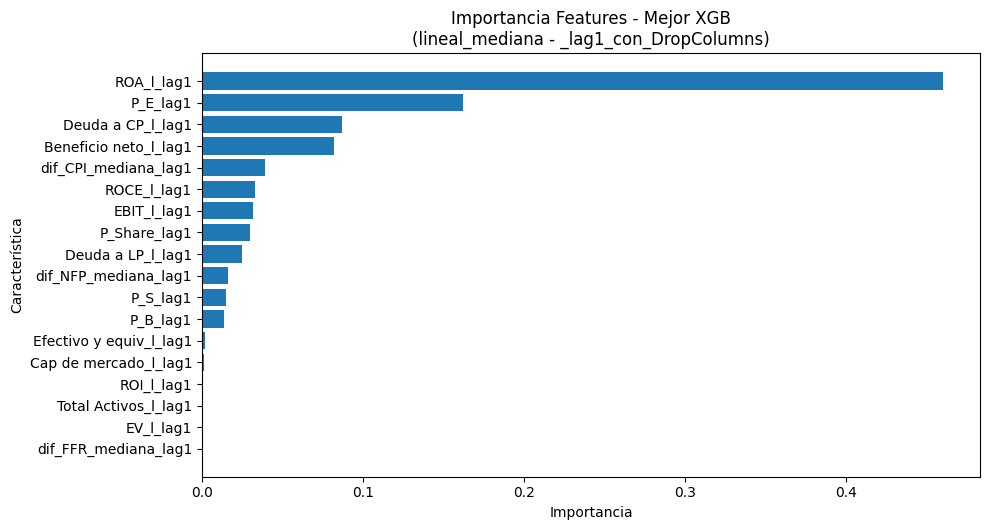

  Mejor LGBM para lineal_mediana: RMSE = 26.1546
    Generando importancia de features para Mejor LGBM de lineal_mediana...


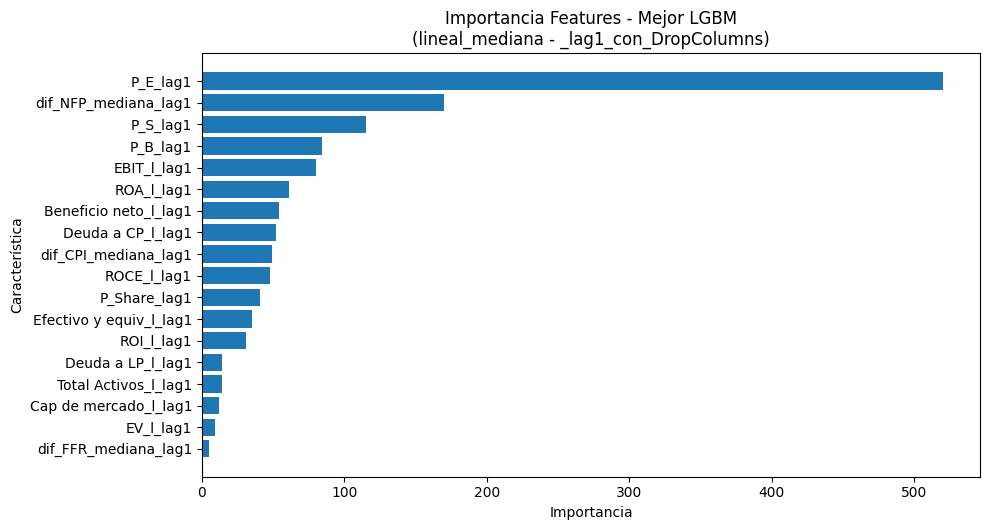

  Mejor CB para lineal_mediana: RMSE = 18.9338
    Generando importancia de features para Mejor CB de lineal_mediana...


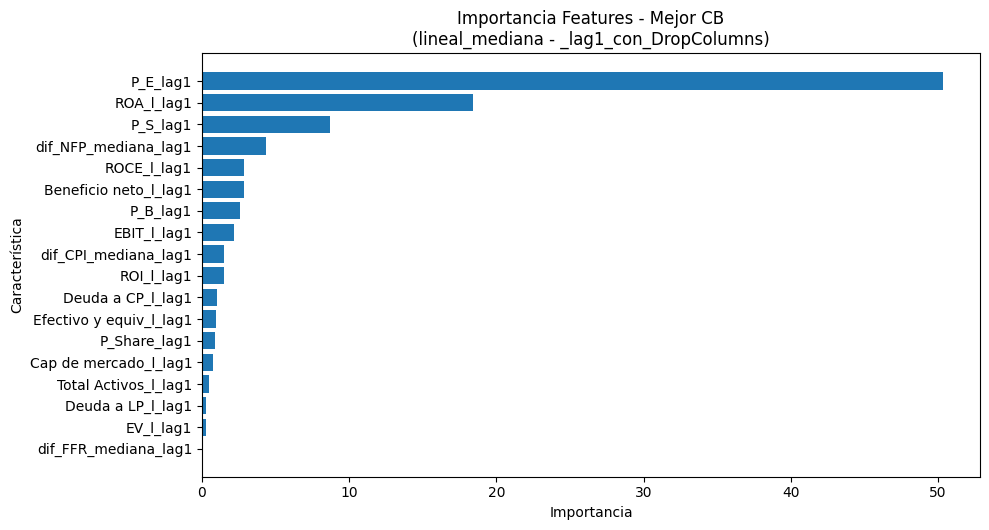


Paquete para 'lineal_mediana' guardado como: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_mediana ---
  Mejor RF para spline_mediana: RMSE = 20.1600
    Generando importancia de features para Mejor RF de spline_mediana...


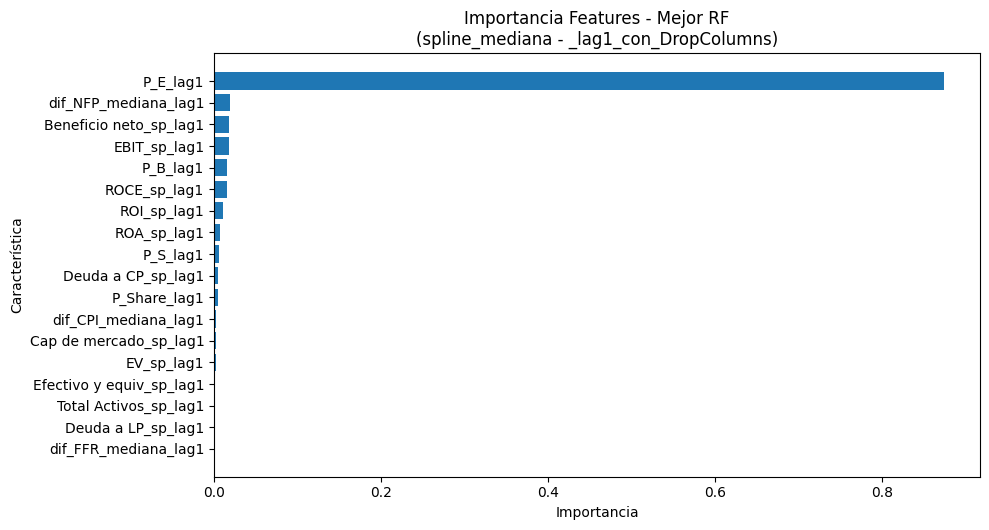

  Mejor XGB para spline_mediana: RMSE = 21.8231
    Generando importancia de features para Mejor XGB de spline_mediana...


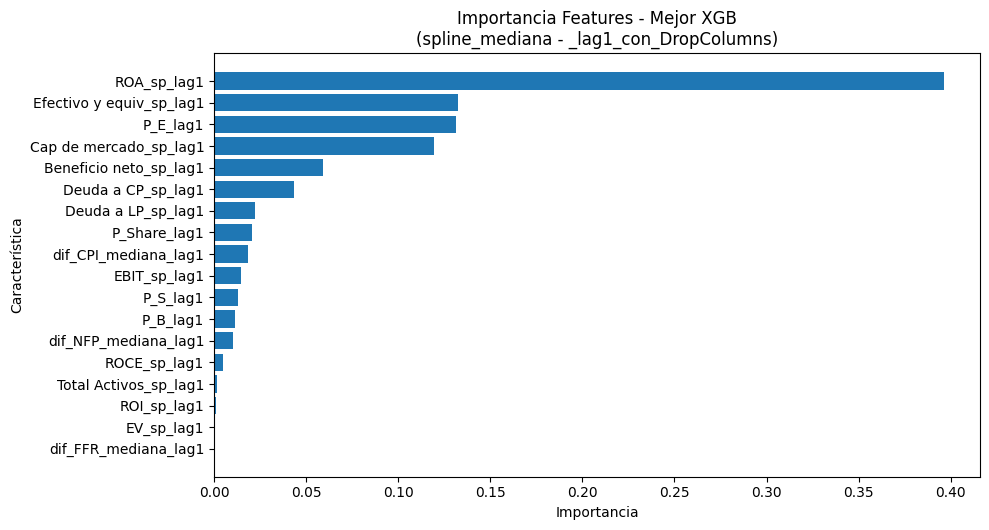

  Mejor LGBM para spline_mediana: RMSE = 30.0984
    Generando importancia de features para Mejor LGBM de spline_mediana...


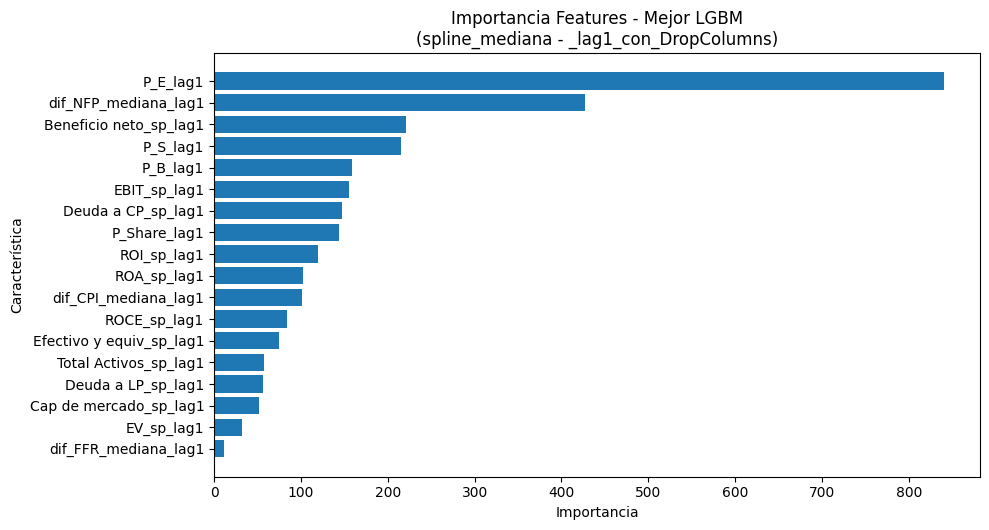

  Mejor CB para spline_mediana: RMSE = 18.7218
    Generando importancia de features para Mejor CB de spline_mediana...


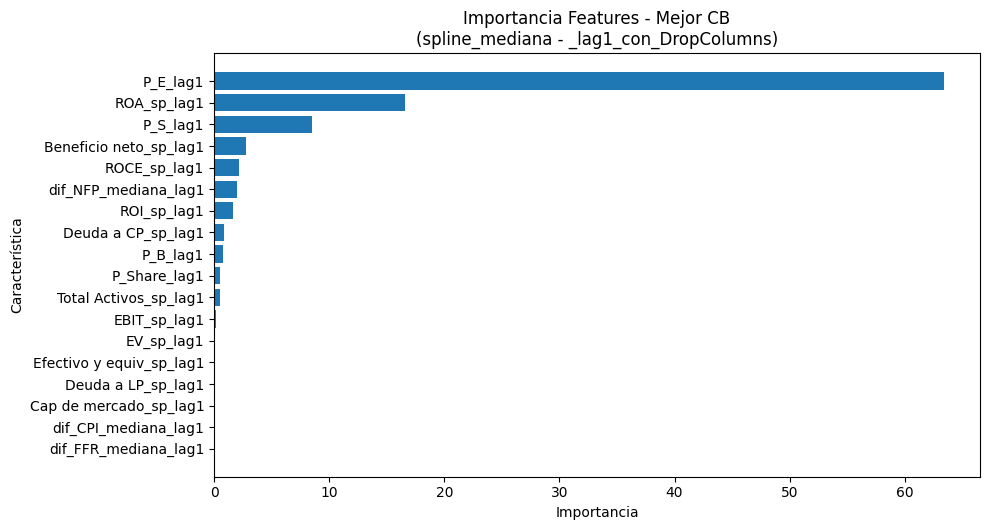


Paquete para 'spline_mediana' guardado como: paquete_mejores_por_tipo_spline_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: lineal_promedio ---
  Mejor RF para lineal_promedio: RMSE = 19.2164
    Generando importancia de features para Mejor RF de lineal_promedio...


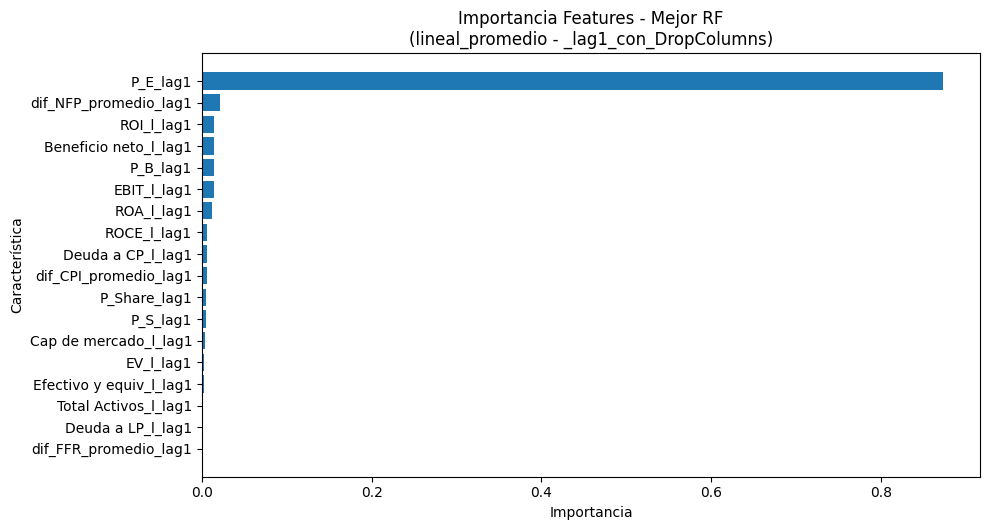

  Mejor XGB para lineal_promedio: RMSE = 26.0072
    Generando importancia de features para Mejor XGB de lineal_promedio...


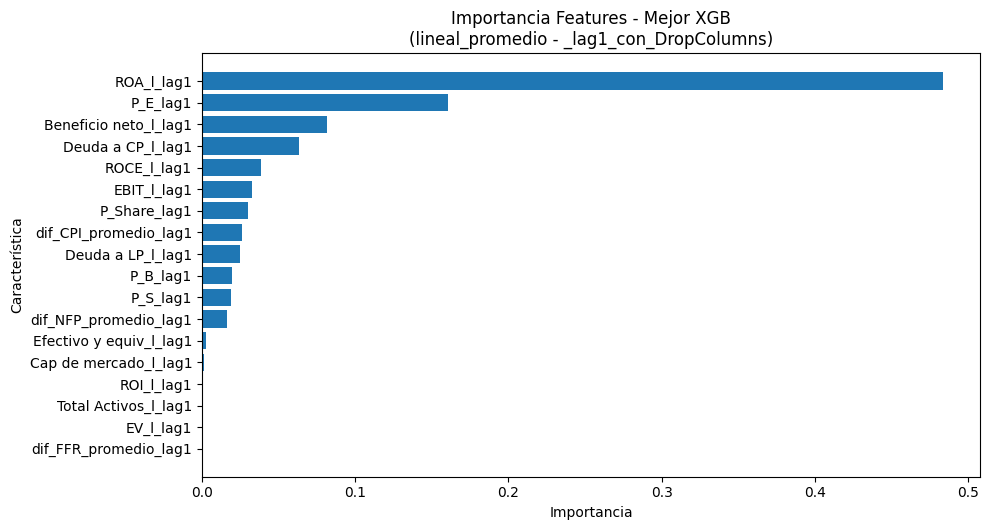

  Mejor LGBM para lineal_promedio: RMSE = 26.7617
    Generando importancia de features para Mejor LGBM de lineal_promedio...


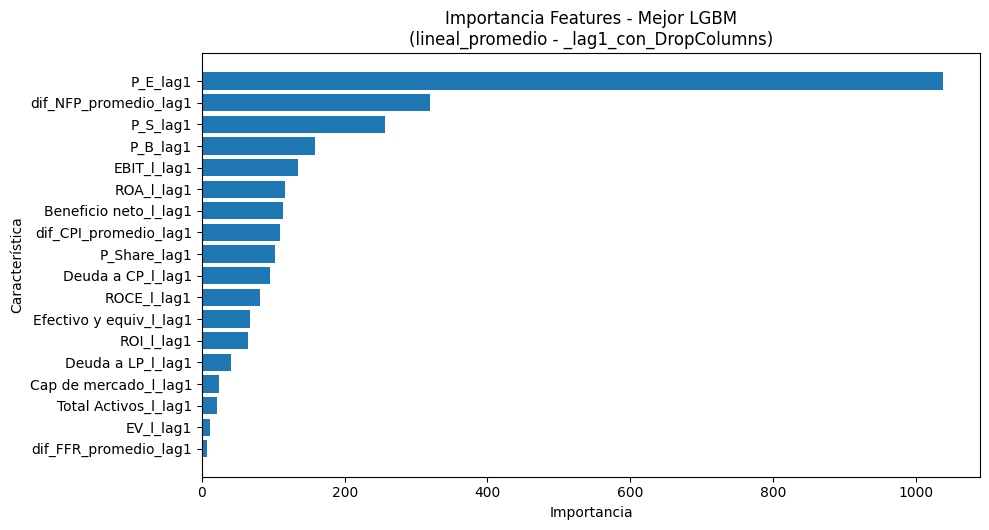

  Mejor CB para lineal_promedio: RMSE = 19.6530
    Generando importancia de features para Mejor CB de lineal_promedio...


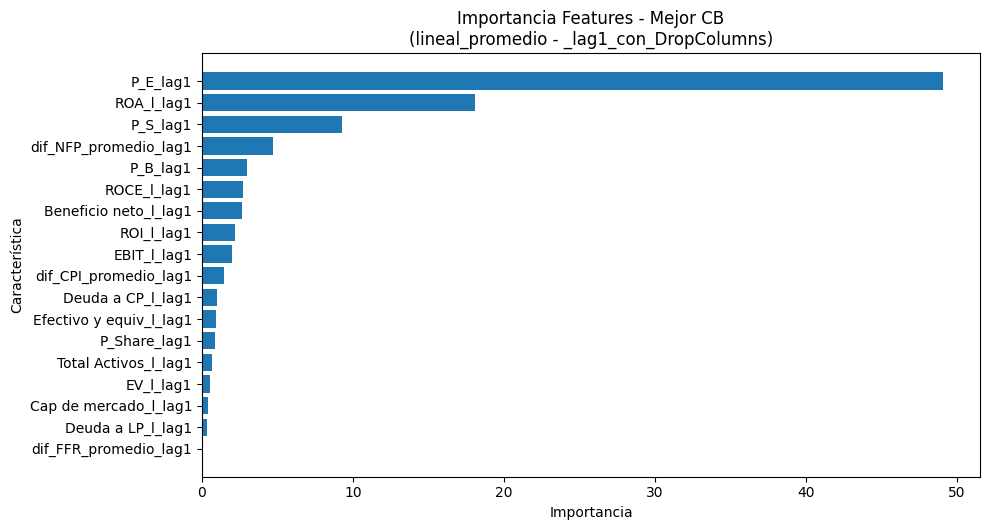


Paquete para 'lineal_promedio' guardado como: paquete_mejores_por_tipo_lineal_promedio__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_promedio ---
  Mejor RF para spline_promedio: RMSE = 20.3375
    Generando importancia de features para Mejor RF de spline_promedio...


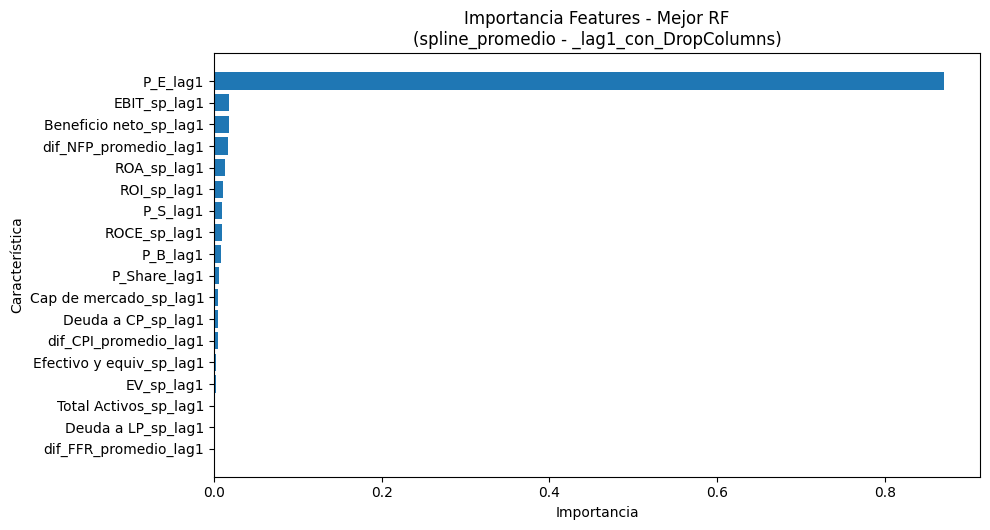

  Mejor XGB para spline_promedio: RMSE = 20.9667
    Generando importancia de features para Mejor XGB de spline_promedio...


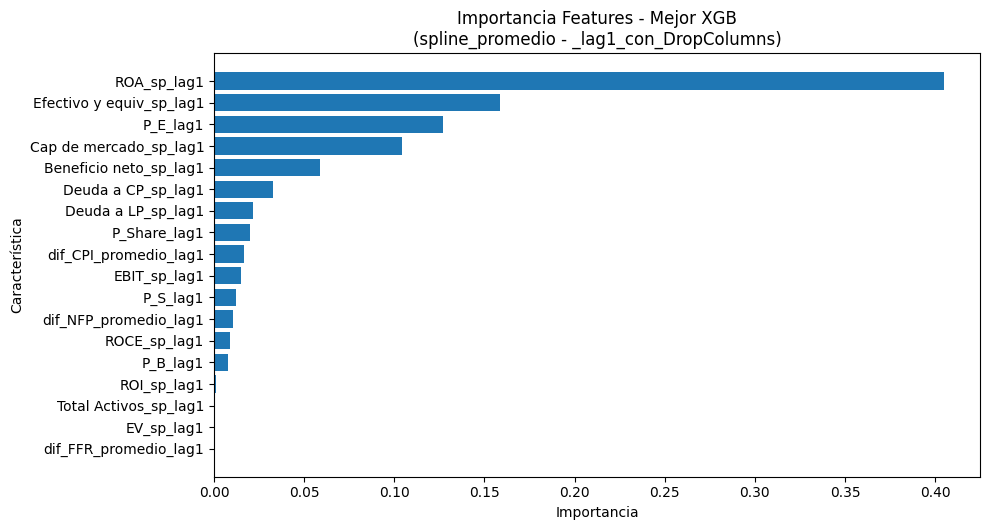

  Mejor LGBM para spline_promedio: RMSE = 31.6774
    Generando importancia de features para Mejor LGBM de spline_promedio...


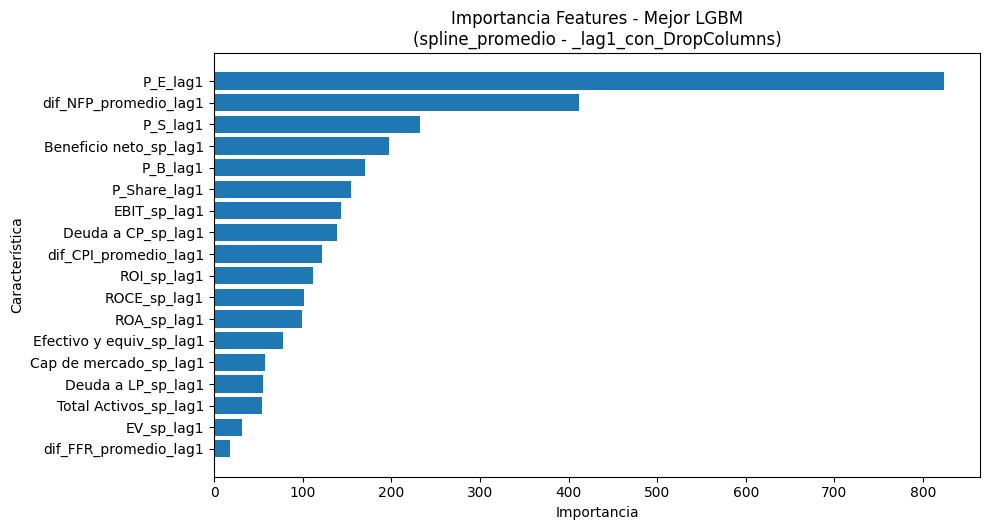

  Mejor CB para spline_promedio: RMSE = 18.7063
    Generando importancia de features para Mejor CB de spline_promedio...


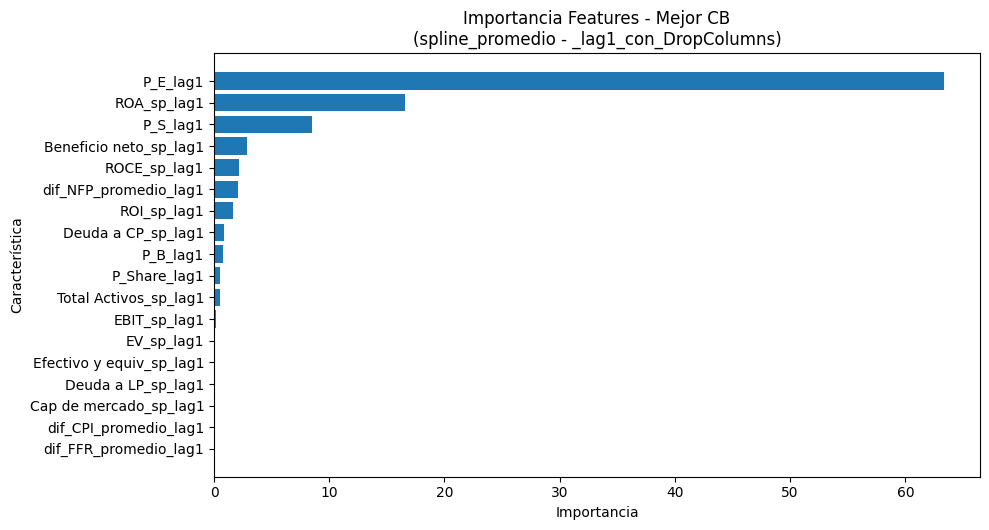


Paquete para 'spline_promedio' guardado como: paquete_mejores_por_tipo_spline_promedio__lag1_con_DropColumns.joblib

TABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO
Metodo_Features            Lag_Config  Log_Transform Modelo_Tipo_Base    RMSE    MAE      R2  n_features_modelo                                                                                                Best_Params
 lineal_mediana _lag1_con_DropColumns          False               CB 18.9338 4.4350  0.5664                 18                                                                                                       None
 lineal_mediana _lag1_con_DropColumns          False               RF 19.1328 3.9345  0.5572                 18                       {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 100}
 lineal_mediana _lag1_con_DropColumns          False             LGBM 26.1546 4.8631  0.1726                 18  {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_est

In [41]:
# ================================================================================
# BLOQUE DE EXPERIMENTOS (CON DropColumns en Pipeline, PLOT FEATURE IMPORTANCE para Mejores por Tipo, GUARDAR PAQUETES)
# ================================================================================
results_accumulator = [] 
start_time_total_experiments = time.time()
use_log_transform_experiment = False
test_size_ratio_experiment = 0.20
LAG_SUFFIX_TO_USE = '_lag1' 

if 'dfs_shifted' not in locals() or not isinstance(dfs_shifted, dict) or not dfs_shifted:
    raise NameError("El diccionario 'dfs_shifted' no está definido o está vacío.")

for metodo_features, df_original_with_lags_and_ids in dfs_shifted.items():
    start_time_metodo = time.time()
    lag_config_display = f"{LAG_SUFFIX_TO_USE}_con_DropColumns" 

    print("\n" + "="*80)
    print(f"Procesando Método: {metodo_features} {'(CON Log Transform)' if use_log_transform_experiment else '(SIN Log Transform)'} (Lags: {LAG_SUFFIX_TO_USE}, con DropColumns)")
    print("="*80 + "\n")

    if df_original_with_lags_and_ids.empty: continue
    df_current_method_processed = df_original_with_lags_and_ids.copy()
    if 'time_step' not in df_current_method_processed.columns:
        df_current_method_processed.sort_values(['Empresa', 'Fecha'], inplace=True)
        df_current_method_processed['time_step'] = df_current_method_processed.groupby('Empresa').cumcount()

    predictor_cols_for_pipeline_input = sorted([
        c for c in df_current_method_processed.columns 
        if c.endswith(LAG_SUFFIX_TO_USE) and c not in ['Empresa', 'Fecha', 'time_step', 'P_E']
    ])
    if not predictor_cols_for_pipeline_input: continue
    columnas_base_que_generaron_lags = sorted(list(set(re.sub(r'_lag\d+$', '', lag_col) for lag_col in predictor_cols_for_pipeline_input)))
    
    all_relevant_cols_for_df = ['Empresa', 'Fecha', 'time_step', 'P_E'] + predictor_cols_for_pipeline_input
    final_cols_for_df_model_construction = sorted(list(set(c for c in all_relevant_cols_for_df if c in df_current_method_processed.columns)))
    essential_cols_check = ['Empresa', 'Fecha', 'time_step', 'P_E']
    if not all(ec in final_cols_for_df_model_construction for ec in essential_cols_check): continue
    df_model_for_splitting = df_current_method_processed[final_cols_for_df_model_construction].copy()

    n_total_empresas = df_model_for_splitting['Empresa'].nunique()
    n_empresas_test = 0
    if n_total_empresas > 1:
        n_empresas_test = max(1, int(round(n_total_empresas * test_size_ratio_experiment)))
        if n_total_empresas - n_empresas_test < 1 : n_empresas_test = n_total_empresas - 1
    X_train_with_ids, y_train_original, X_test_with_ids, y_test_original = train_test_split_by_empresa(df_model_for_splitting, n_empresas_test)
    if X_train_with_ids is None or X_train_with_ids.empty: continue
    
    y_train_transformed_target = y_train_original.copy()
    if use_log_transform_experiment:
        y_numeric = pd.to_numeric(y_train_original, errors='coerce')
        median_y_train = y_numeric.median() if not y_numeric.isnull().all() else 0.0
        y_numeric = y_numeric.fillna(median_y_train); y_numeric.loc[y_numeric < 0] = 0
        y_train_transformed_target = np.log1p(y_numeric)
        if y_train_transformed_target.isnull().any():
             median_y_transformed = y_train_transformed_target.median() if not y_train_transformed_target.isnull().all() else 0.0
             y_train_transformed_target = y_train_transformed_target.fillna(median_y_transformed)

    if not X_train_with_ids.index.equals(y_train_transformed_target.index):
        common_idx_train = X_train_with_ids.index.intersection(y_train_transformed_target.index)
        X_train_with_ids = X_train_with_ids.loc[common_idx_train]
        y_train_transformed_target = y_train_transformed_target.loc[common_idx_train]
        if X_train_with_ids.empty : continue

    X_train_s_with_ids, y_train_s_transformed = sort_by_timestep(X_train_with_ids, y_train_transformed_target)
    X_test_s_with_ids, y_test_s_original = pd.DataFrame(), pd.Series(dtype=float)
    if X_test_with_ids is not None and not X_test_with_ids.empty:
        X_test_s_with_ids, y_test_s_original = sort_by_timestep(X_test_with_ids, y_test_original)

    param_grid_rf   = {'model__max_depth':[10, 20, None],'model__min_samples_split':[5, 10],'model__n_estimators':[100, 200]}
    param_grid_xgb  = {'model__n_estimators':[100, 200],'model__max_depth':[3, 5, 7],'model__learning_rate':[0.1, 0.05]}
    param_grid_lgbm = {'model__n_estimators':[100, 200],'model__learning_rate':[0.1, 0.05],'model__max_depth':[3, 5, 7],'model__num_leaves':[15, 31]}
    param_grid_cb   = {'model__iterations':[100, 200],'model__learning_rate':[0.1, 0.05],'model__depth':[3, 5, 7],'model__l2_leaf_reg':[1, 3]}
    scenarios = {
        'RF_Simple':  {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_rf},
        'RF_HP':      {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_rf},
        'XGB_Simple': {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_xgb},
        'XGB_HP':     {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_xgb},
        'LGBM_Simple':{'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': False, 'vt': False, 'grid': param_grid_lgbm},
        'LGBM_HP':    {'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': True,  'vt': False, 'grid': param_grid_lgbm},
        'CB_Simple':  {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': False, 'vt': False, 'grid': param_grid_cb},
        'CB_HP':      {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': True,  'vt': False, 'grid': param_grid_cb},
    }

    for escenario_nombre, escenario_cfg in scenarios.items():
        tiempo_esc_inicio = time.time()
        current_base_model = escenario_cfg['model']; perform_hp_search = escenario_cfg['hp']; use_temporal_cv_in_scenario = escenario_cfg.get('vt', False)
        X_fit_data_pipeline = X_train_s_with_ids if use_temporal_cv_in_scenario else X_train_with_ids
        y_fit_data_pipeline = y_train_s_transformed if use_temporal_cv_in_scenario else y_train_transformed_target
        X_eval_data_pipeline = X_test_s_with_ids if use_temporal_cv_in_scenario else X_test_with_ids
        y_eval_data_original_final = y_test_s_original if use_temporal_cv_in_scenario else y_test_original
        if X_fit_data_pipeline.empty or y_fit_data_pipeline.empty:
            results_accumulator.append({'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario,
                'Busqueda_HP': perform_hp_search, 'Config_Key': metodo_features, 'Metodo': metodo_features,
                'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 'RMSE': np.nan, 'MAE': np.nan, 
                'R2': np.nan, 'Best_Params': None, 'pipeline': 'Error: Datos vacíos', 
                'columnas_base_usadas': columnas_base_que_generaron_lags, 
                'n_features_modelo': len(predictor_cols_after_drop), 
                'features_usadas_por_modelo': [], 'Error': 'Datos vacíos'})
            continue
        cols_to_drop_in_pipeline = [col for col in ['Empresa', 'Fecha', 'time_step'] if col in X_fit_data_pipeline.columns]
        pipeline_obj_for_training = Pipeline([('drop_ids', DropColumns(columns=cols_to_drop_in_pipeline)), ('model', current_base_model)])
        model_actual_features_for_plot = [col for col in X_fit_data_pipeline.columns if col not in cols_to_drop_in_pipeline]
        final_fitted_pipeline, hp_best_params_found, error_msg_escenario = None, None, None
        try:
            if perform_hp_search:
                cv_strategy_obj, cv_fit_params_dict, can_perform_cv = None, {}, True
                n_groups_for_cv = X_fit_data_pipeline['Empresa'].nunique() if use_temporal_cv_in_scenario and 'Empresa' in X_fit_data_pipeline.columns else 0
                if use_temporal_cv_in_scenario and n_groups_for_cv >= 2:
                    groups_for_gkf = X_fit_data_pipeline['Empresa']; n_splits_gkf = min(3, n_groups_for_cv); n_splits_gkf = max(2, n_splits_gkf)
                    if len(X_fit_data_pipeline) < n_splits_gkf : can_perform_cv = False
                    else: cv_strategy_obj = GroupKFold(n_splits=n_splits_gkf); cv_fit_params_dict = {'groups': groups_for_gkf}
                elif len(X_fit_data_pipeline) >= 2:
                    n_samples_kf = len(X_fit_data_pipeline); kfold_splits_val = min(3, n_samples_kf); kfold_splits_val = max(2, kfold_splits_val)
                    if n_samples_kf < kfold_splits_val : can_perform_cv = False
                    else: cv_strategy_obj = KFold(n_splits=kfold_splits_val, shuffle=True, random_state=42)
                else: can_perform_cv = False
                if not can_perform_cv or cv_strategy_obj is None: perform_hp_search = False
                if perform_hp_search:
                    gs = GridSearchCV(pipeline_obj_for_training, escenario_cfg['grid'], scoring=rmse_scorer, cv=cv_strategy_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                    gs.fit(X_fit_data_pipeline, y_fit_data_pipeline, **cv_fit_params_dict)
                    final_fitted_pipeline, hp_best_params_found = gs.best_estimator_, gs.best_params_
            if not perform_hp_search or final_fitted_pipeline is None:
                pipeline_obj_for_training.fit(X_fit_data_pipeline, y_fit_data_pipeline)
                final_fitted_pipeline = pipeline_obj_for_training; hp_best_params_found = None
        except Exception as e: error_msg_escenario = str(e)
        eval_metrics_dict, n_features_in_final_model_attr = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}, "N/A"
        if final_fitted_pipeline:
            try:
                actual_estimator = final_fitted_pipeline.steps[-1][1]
                n_features_in_final_model_attr = getattr(actual_estimator, 'n_features_in_', "N/A")
                if not X_eval_data_pipeline.empty and not y_eval_data_original_final.empty:
                    pred_transformed_eval = final_fitted_pipeline.predict(X_eval_data_pipeline)
                    pred_original_scale_eval = np.expm1(pred_transformed_eval) if use_log_transform_experiment else pred_transformed_eval
                    if use_log_transform_experiment: pred_original_scale_eval[~np.isfinite(pred_original_scale_eval)] = np.nan
                    eval_metrics_dict = evaluate_model(y_eval_data_original_final, pred_original_scale_eval)
                    print(f"    Métricas Test {escenario_nombre}: RMSE={eval_metrics_dict['RMSE']:.4f}, MAE={eval_metrics_dict['MAE']:.4f}, R2={eval_metrics_dict['R2']:.4f}")
                # NO PLOTEAMOS AQUÍ, LO HAREMOS AL FINAL PARA LOS MEJORES POR TIPO
            except Exception as e_eval: error_msg_escenario = (error_msg_escenario + f" | EvalError: {str(e_eval)}") if error_msg_escenario else f"EvalError: {str(e_eval)}"
        
        results_accumulator.append({
            'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario and isinstance(cv_strategy_obj, GroupKFold),
            'Busqueda_HP': escenario_cfg['hp'] and perform_hp_search, 
            'Config_Key': metodo_features, 'Metodo': metodo_features, 
            'Lag_Config': lag_config_display, 
            'Log_Transform': use_log_transform_experiment, 
            'RMSE': eval_metrics_dict['RMSE'], 'MAE': eval_metrics_dict['MAE'], 'R2': eval_metrics_dict['R2'], 
            'Best_Params': hp_best_params_found, 
            'pipeline': final_fitted_pipeline, 
            'columnas_base_usadas': columnas_base_que_generaron_lags, 
            'n_features_modelo': n_features_in_final_model_attr, 
            'features_usadas_por_modelo': model_actual_features_for_plot, # Guardar las features que vio el estimador
            'Error': error_msg_escenario
        })
    print(f"\nTiempo total para Método: {metodo_features}: {time.time() - start_time_metodo:.2f}s")
print(f"\n\nTiempo total de ejecución de todos los experimentos: {(time.time() - start_time_total_experiments)/60:.2f} minutos")

# ================================================================================
# CREAR TABLA DE RESULTADOS GENERAL, GUARDAR PAQUETES Y PLOTEAR MEJORES POR TIPO
# ================================================================================
if results_accumulator:
    df_results_all_experiments = pd.DataFrame(results_accumulator)
    print("\n" + "="*80 + "\n--- Resultados Finales Globales ---\n" + f"Total resultados: {len(df_results_all_experiments)}\n")
    cols_to_display_summary = ['Metodo', 'Modelo', 'Busqueda_HP', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Lag_Config', 'Error', 'Best_Params'] # Quitado 'features_usadas_por_modelo' para brevedad
    final_cols_to_display_summary = [col for col in cols_to_display_summary if col in df_results_all_experiments.columns]
    with pd.option_context('display.max_rows', 200, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
        print(df_results_all_experiments.sort_values(by=['Metodo','RMSE'], ascending=[True,True])[final_cols_to_display_summary].to_string(index=False))

    lista_info_mejores_por_tipo_global = []
    for metodo_actual_features_key in df_results_all_experiments['Metodo'].unique(): 
        print("\n" + "="*70 + f"\n--- Preparando paquete y plots para Método: {metodo_actual_features_key} ---")
        df_resultados_metodo_actual = df_results_all_experiments[
            (df_results_all_experiments['Metodo'] == metodo_actual_features_key) &
            (df_results_all_experiments['RMSE'].notna()) &
            (df_results_all_experiments['pipeline'].notna()) & 
            (df_results_all_experiments['Error'].isna()) &
            (df_results_all_experiments['pipeline'].apply(lambda x: not (isinstance(x, str) and x.startswith('Error:')))) & # Asegurar que pipeline no sea string de error
            (df_results_all_experiments['features_usadas_por_modelo'].apply(lambda x: isinstance(x, list) and len(x) > 0)) # Asegurar que hay features
        ].copy()

        if df_resultados_metodo_actual.empty: 
            print(f"No hay resultados válidos con features para el método '{metodo_actual_features_key}' para crear paquete o plotear.")
            continue

        mejores_modelos_info_para_paquete = {}
        modelos_base_a_considerar = ['RF', 'XGB', 'LGBM', 'CB']
        
        metadata_ref_row = df_resultados_metodo_actual.iloc[0]
        log_transform_paquete_actual = metadata_ref_row.get('Log_Transform', True)
        columnas_base_paquete_actual = metadata_ref_row.get('columnas_base_usadas', []) 
        lag_config_paquete_actual = metadata_ref_row.get('Lag_Config', 'desconocida')
        
        for tipo_modelo_base in modelos_base_a_considerar:
            df_tipo_especifico = df_resultados_metodo_actual[df_resultados_metodo_actual['Modelo'] == tipo_modelo_base]
            if not df_tipo_especifico.empty:
                mejor_fila_tipo_actual = df_tipo_especifico.sort_values(by='RMSE', ascending=True).iloc[0]
                
                pipeline_obj_actual = mejor_fila_tipo_actual['pipeline']
                features_usadas_actual = mejor_fila_tipo_actual['features_usadas_por_modelo']

                mejores_modelos_info_para_paquete[tipo_modelo_base] = {
                    'pipeline_object': pipeline_obj_actual,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'Best_Params': mejor_fila_tipo_actual['Best_Params'],
                    'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'features_usadas_por_modelo': features_usadas_actual, 
                    'Escenario_Validacion_Temp': mejor_fila_tipo_actual['Validacion_Temp'],
                    'Escenario_Busqueda_HP': mejor_fila_tipo_actual['Busqueda_HP']}
                
                print(f"  Mejor {tipo_modelo_base} para {metodo_actual_features_key}: RMSE = {mejor_fila_tipo_actual['RMSE']:.4f}")

                # --- PLOT FEATURE IMPORTANCE PARA ESTE MEJOR MODELO POR TIPO ---
                titulo_plot_tipo = (
                    f"Importancia Features - Mejor {tipo_modelo_base}\n"
                    f"({metodo_actual_features_key} - {lag_config_paquete_actual})"
                )
                print(f"    Generando importancia de features para Mejor {tipo_modelo_base} de {metodo_actual_features_key}...")
                plot_feature_importances(
                    pipeline_obj_actual, # El pipeline completo (DropColumns + modelo)
                    feature_names=features_usadas_actual, # Las features que vio el estimador final
                    title=titulo_plot_tipo
                )
                # --- FIN PLOT ---

                info_para_tabla_resumen = {
                    'Metodo_Features': metodo_actual_features_key, 
                    'Lag_Config': lag_config_paquete_actual,
                    'Log_Transform': log_transform_paquete_actual, 
                    'Modelo_Tipo_Base': tipo_modelo_base,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'Best_Params': mejor_fila_tipo_actual['Best_Params']}
                lista_info_mejores_por_tipo_global.append(info_para_tabla_resumen)
            else: 
                mejores_modelos_info_para_paquete[tipo_modelo_base] = None 

        if any(mejores_modelos_info_para_paquete.values()):
            paquete_final_a_guardar = {
                'metodo_features': metodo_actual_features_key, 
                'lag_config_usada': lag_config_paquete_actual,
                'log_transform_target': log_transform_paquete_actual,
                'columnas_base_para_lags': columnas_base_paquete_actual, 
                'mejores_modelos_info_por_tipo': mejores_modelos_info_para_paquete
            }
            nombre_archivo_paquete_final = f"paquete_mejores_por_tipo_{metodo_actual_features_key.replace(' ', '_')}_{lag_config_paquete_actual}.joblib"
            try:
                joblib.dump(paquete_final_a_guardar, nombre_archivo_paquete_final)
                print(f"\nPaquete para '{metodo_actual_features_key}' guardado como: {nombre_archivo_paquete_final}")
            except Exception as e_dump_final_package: print(f"\nERROR al guardar paquete para '{metodo_actual_features_key}': {e_dump_final_package}")
    
    if lista_info_mejores_por_tipo_global:
        df_mejores_por_tipo_global = pd.DataFrame(lista_info_mejores_por_tipo_global)
        print("\n" + "="*80 + "\nTABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO" + "\n" + "="*80)
        with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
            cols_resumen_mejores = ['Metodo_Features', 'Lag_Config', 'Log_Transform', 'Modelo_Tipo_Base', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Best_Params']
            cols_resumen_existentes = [col for col in cols_resumen_mejores if col in df_mejores_por_tipo_global.columns]
            print(df_mejores_por_tipo_global.sort_values(by=['Metodo_Features', 'RMSE'], ascending=[True, True])[cols_resumen_existentes].to_string(index=False))
else: 
    print("\nNo se generaron resultados en los experimentos.")

In [42]:
df_mejores_por_tipo_global.sort_values(by=["R2"], ascending=False)

,Metodo_Features,Lag_Config,Log_Transform,Modelo_Tipo_Base,RMSE,MAE,R2,n_features_modelo,Best_Params
15,spline_promedio,_lag1_con_DropColumns,False,CB,18.706307,5.045065,0.576738,18,"{'model__depth': 3, 'model__iterations': 100, ..."
7,spline_mediana,_lag1_con_DropColumns,False,CB,18.721766,5.045601,0.576038,18,"{'model__depth': 3, 'model__iterations': 100, ..."
3,lineal_mediana,_lag1_con_DropColumns,False,CB,18.933796,4.435030,0.566380,18,None
0,lineal_mediana,_lag1_con_DropColumns,False,RF,19.132791,3.934464,0.557218,18,"{'model__max_depth': 10, 'model__min_samples_s..."
8,lineal_promedio,_lag1_con_DropColumns,False,RF,19.216399,3.996716,0.553340,18,"{'model__max_depth': None, 'model__min_samples..."
11,lineal_promedio,_lag1_con_DropColumns,False,CB,19.652985,4.620004,0.532813,18,None
4,spline_mediana,_lag1_con_DropColumns,False,RF,20.160024,3.946510,0.508396,18,"{'model__max_depth': 10, 'model__min_samples_s..."
12,spline_promedio,_lag1_con_DropColumns,False,RF,20.337465,4.015746,0.499704,18,"{'model__max_depth': None, 'model__min_samples..."
13,spline_promedio,_lag1_con_DropColumns,False,XGB,20.966712,4.112610,0.468266,18,"{'model__learning_rate': 0.05, 'model__max_dep..."
5,spline_mediana,_lag1_con_DropColumns,False,XGB,21.823075,4.170015,0.423943,18,"{'model__learning_rate': 0.05, 'model__max_dep..."


In [43]:
# Celda: BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib
import os
import re # Para la lógica de extracción de lags

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# --- Definiciones de Clases y Funciones Auxiliares ---
class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None): self.columns = columns if columns is not None else []
    def fit(self, X, y=None): return self
    def transform(self, X):
        if not isinstance(X, pd.DataFrame): return X
        return X.copy().drop(columns=self.columns, errors='ignore')

def rmse(y_true, y_pred):
    y_true_np, y_pred_np = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_true_np, y_pred_np = y_true_np[mask], y_pred_np[mask]
    if len(y_true_np) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def evaluate_model(y_test, y_pred):
    y_test_np, y_pred_np = np.asarray(y_test), np.asarray(y_pred)
    mask = np.isfinite(y_test_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_test_np, y_pred_np = y_test_np[mask], y_pred_np[mask]
    if len(y_test_np) == 0: return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    mae = mean_absolute_error(y_test_np, y_pred_np); rmse_val = rmse(y_test_np, y_pred_np)
    r2 = np.nan
    if len(y_test_np) > 1 and np.var(y_test_np) > 1e-9:
        try: r2 = r2_score(y_test_np, y_pred_np)
        except ValueError: pass
    elif len(y_test_np) > 0 and mean_squared_error(y_test_np, y_pred_np) < 1e-9: r2 = 1.0
    elif len(y_test_np) > 0: r2 = 0.0
    return {'RMSE': rmse_val, 'MAE': mae, 'R2': r2}

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

Cargando paquete de modelos desde: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib
Paquete de modelos cargado exitosamente.
  Información del Paquete: Método=lineal_mediana, LagConfig=_lag1_con_DropColumns, LogT=False
    Columnas Base (usadas para generar lags): 18 ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a CP_l', 'Deuda a LP_l', 'EBIT_l']...
    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.
Se generarán lags [1] para DLocal.

Preparando datos de DLocal (Método: lineal_mediana, Lags: [1])
Generando lags para DLocal para las features: ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a CP_l', 'Deuda a LP_l', 'EBIT_l', 'EV_l', 'Efectivo y equiv_l', 'P_B', 'P_E', 'P_S', 'P_Share', 'ROA_l', 'ROCE_l', 'ROI_l', 'Total Activos_l', 'dif_CPI_mediana', 'dif_FFR_mediana', 'dif_NFP_mediana']
Se generaron 18 columnas de lag para DLocal: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l

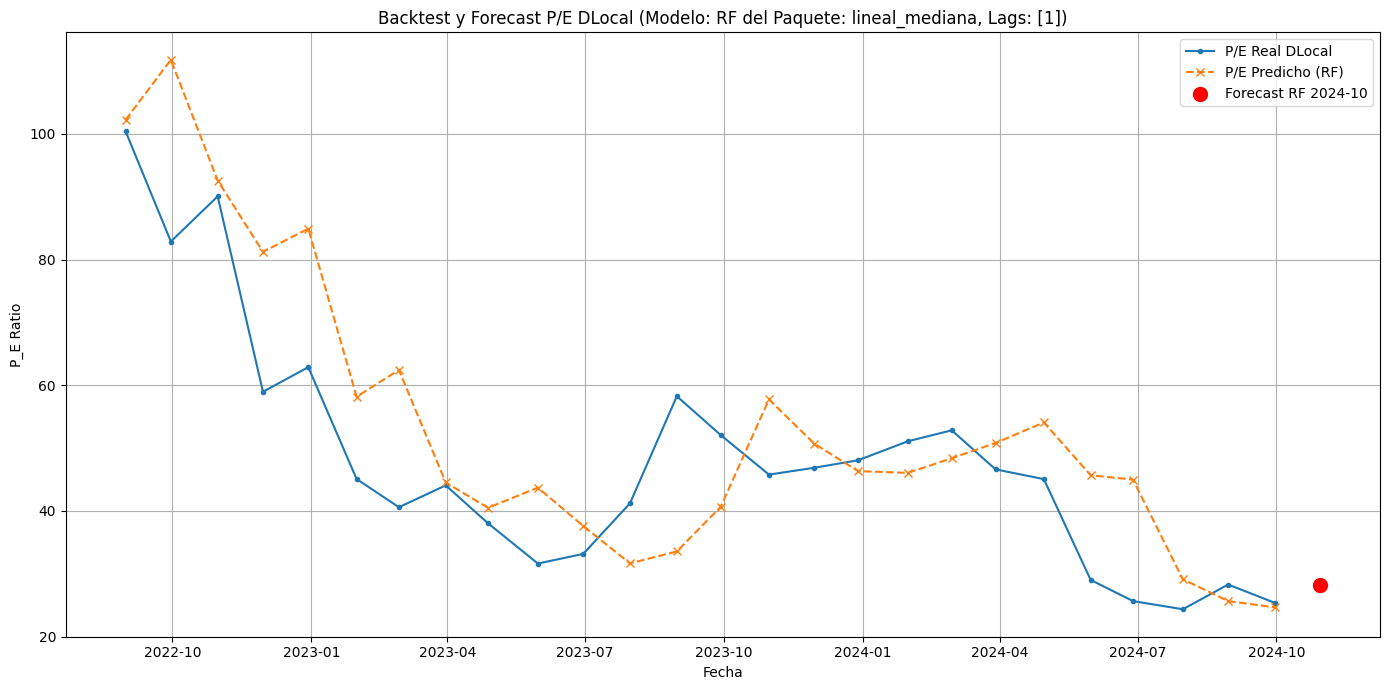


--- Procesando Modelo Tipo: XGB ---
  Features esperadas por XGB (del paquete o inferidas): 18 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1']...
  Métricas Backtest (XGB): RMSE=14.6446, MAE=10.7142, R2=0.3990


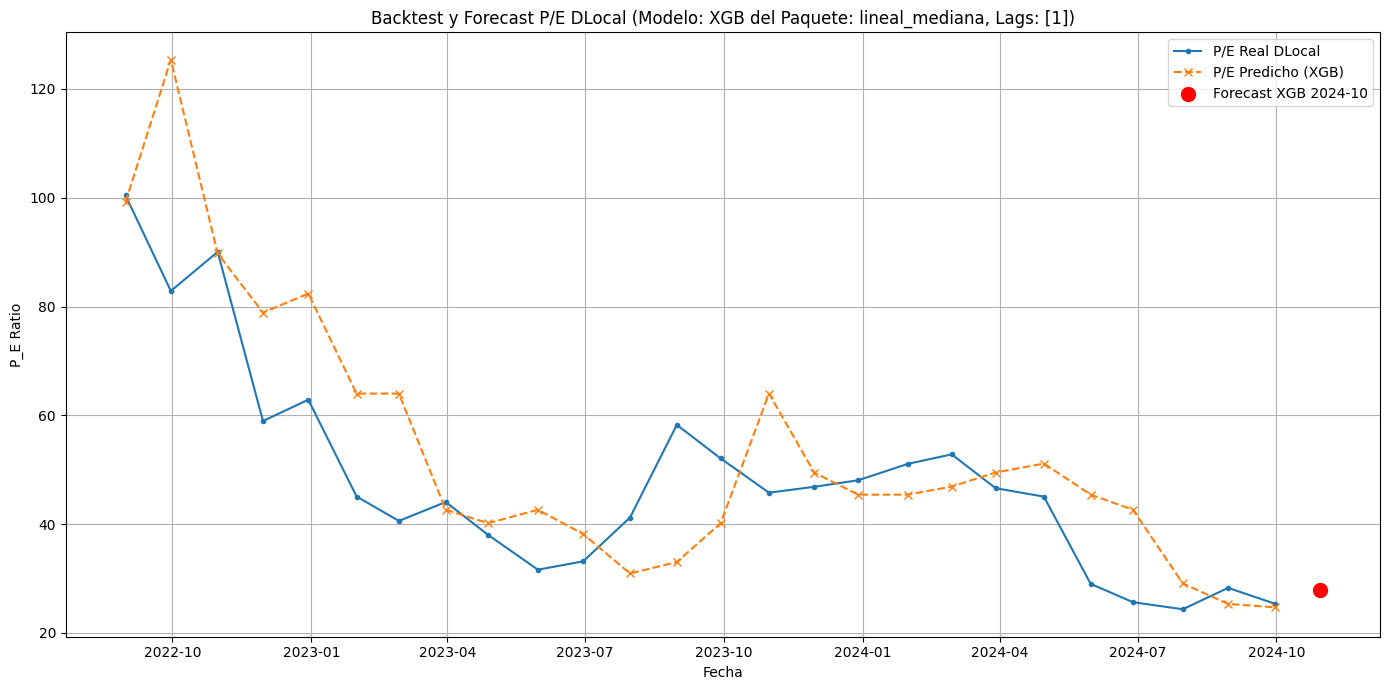


--- Procesando Modelo Tipo: LGBM ---
  Features esperadas por LGBM (del paquete o inferidas): 18 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1']...
  Métricas Backtest (LGBM): RMSE=19.1101, MAE=13.5362, R2=-0.0233


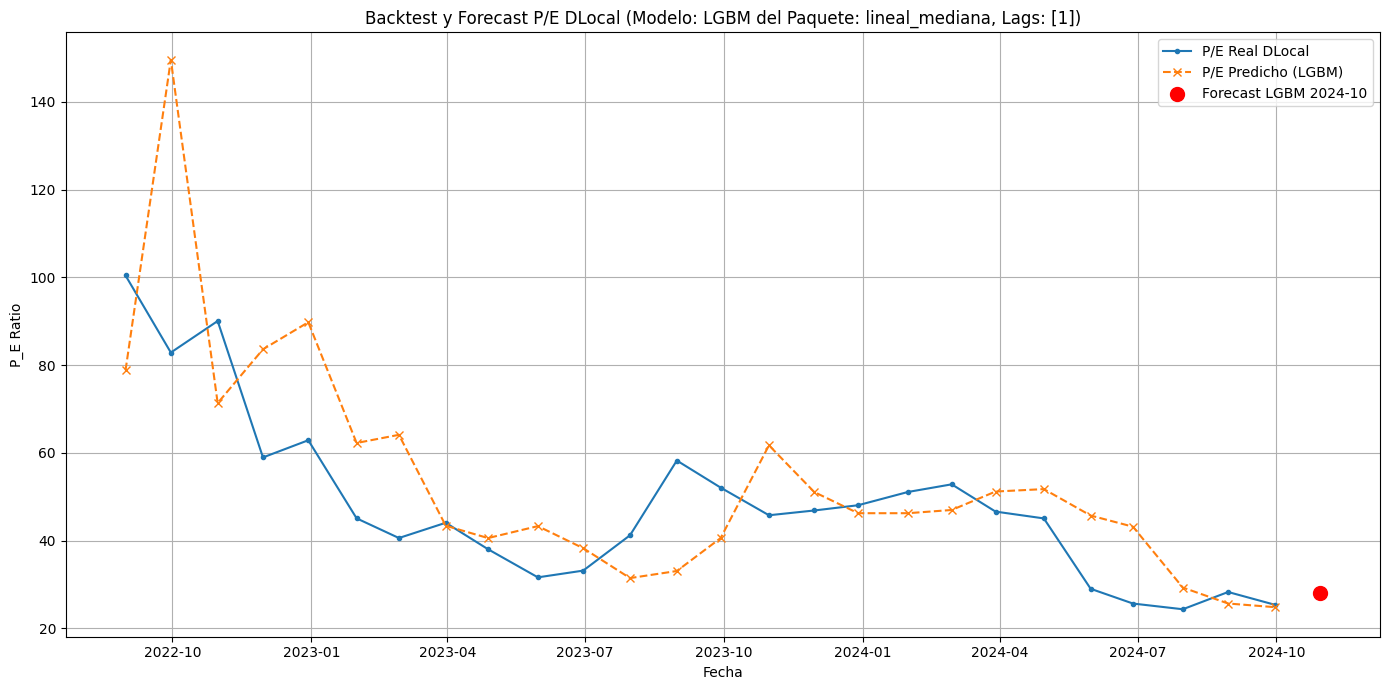


--- Procesando Modelo Tipo: CB ---
  Features esperadas por CB (del paquete o inferidas): 18 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1']...
  Métricas Backtest (CB): RMSE=11.8200, MAE=8.8916, R2=0.6085


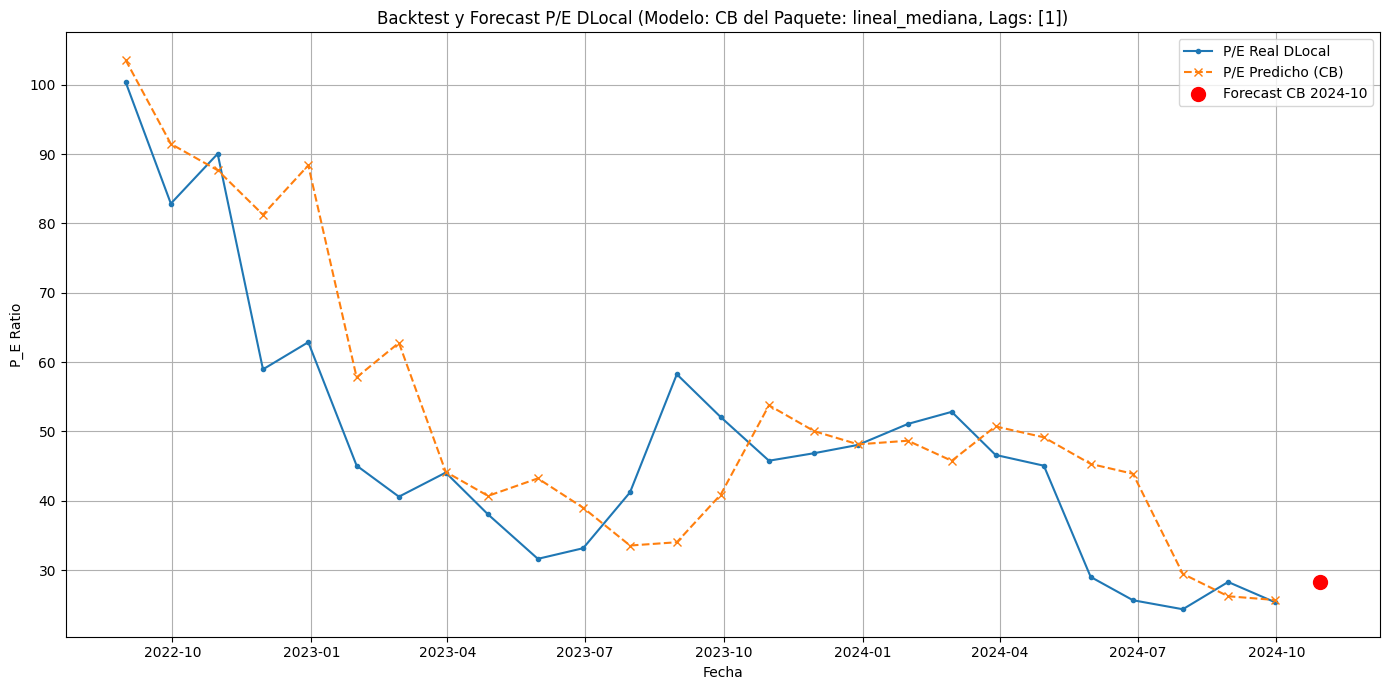


Resumen de Métricas Individuales de los Modelos en el Backtest de DLocal
Modelo_Tipo    RMSE     MAE      R2
         CB 11.8200  8.8916  0.6085
         RF 13.1063 10.0751  0.5187
        XGB 14.6446 10.7142  0.3990
       LGBM 19.1101 13.5362 -0.0233

Proceso de predicción para DLocal completado.


In [44]:
# =====================================================================================
# BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)
# =====================================================================================

# --- 0. CONFIGURACIÓN Y CARGA DEL PAQUETE DEL MODELO ---
# ASUME: df_dlocal está cargado.
#        listas_columnas está definida (si es necesaria como fallback para columnas_base_paquete).
#        El paquete fue entrenado incluyendo P_E_lagN como feature si se desea usar aquí.

nombre_paquete_a_cargar = "paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib"

print(f"Cargando paquete de modelos desde: {nombre_paquete_a_cargar}")
model_package = None
try:
    ruta_paquete = os.path.join(os.getcwd(), nombre_paquete_a_cargar)
    if not os.path.exists(ruta_paquete):
        raise FileNotFoundError(f"El archivo del paquete '{ruta_paquete}' no existe.")
    model_package = joblib.load(ruta_paquete)
    print("Paquete de modelos cargado exitosamente.")

    required_keys = ['metodo_features', 'lag_config_usada', 'log_transform_target', 'mejores_modelos_info_por_tipo']
    if not isinstance(model_package, dict) or not all(key in model_package for key in required_keys):
        raise ValueError("El archivo cargado no es un paquete de modelos válido o le faltan claves esenciales.")

    metodo_features_paquete = model_package['metodo_features']
    lag_config_paquete = model_package['lag_config_usada'] 
    log_transform_paquete = model_package['log_transform_target']
    columnas_base_paquete = model_package.get('columnas_base_para_lags') # Esta clave debe existir en tu paquete
    mejores_modelos_info = model_package['mejores_modelos_info_por_tipo']

    if not columnas_base_paquete: # Fallback si no está en el paquete
        print("ADVERTENCIA: 'columnas_base_para_lags' no encontrada en el paquete. Intentando usar 'listas_columnas'.")
        if 'listas_columnas' in locals() and metodo_features_paquete in listas_columnas:
            columnas_base_paquete = listas_columnas[metodo_features_paquete]
            # Si P_E_lagN se usó y 'P_E' no está en listas_columnas[metodo_features_paquete], hay que añadirlo:
            # Esta lógica asume que si P_E_lagN es una feature, 'P_E' debe estar en las bases para generar ese lag.
            # El paquete idealmente ya tendría 'P_E' en 'columnas_base_para_lags' si P_E_lagN fue usado.
            # Si el paquete es de "solo lags de P/E", columnas_base_paquete debería ser ['P_E'].
            if 'P_E' not in columnas_base_paquete and any(f.startswith("P_E_lag") for f_dict in mejores_modelos_info.values() if f_dict and 'features_usadas_por_modelo' in f_dict for f in f_dict['features_usadas_por_modelo']):
                 if 'P_E' in df_dlocal.columns:
                    print("Añadiendo 'P_E' a columnas_base_paquete para generar su lag, basado en features de modelos.")
                    columnas_base_paquete.append('P_E')
                    columnas_base_paquete = sorted(list(set(columnas_base_paquete)))
        else: 
            raise ValueError("No se pudieron determinar las 'columnas_base_para_lags' ni del paquete ni de 'listas_columnas'.")
    
    print(f"  Información del Paquete: Método={metodo_features_paquete}, LagConfig={lag_config_paquete}, LogT={log_transform_paquete}")
    print(f"    Columnas Base (usadas para generar lags): {len(columnas_base_paquete)} {columnas_base_paquete[:5]}...")
    if 'P_E' in columnas_base_paquete:
        print("    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.")
    else:
        print("    ADVERTENCIA: 'P_E' NO está en columnas_base_paquete. NO se generará P_E_lagN como feature para DLocal, a menos que lag_config_paquete lo fuerce.")

except FileNotFoundError: raise FileNotFoundError(f"ERROR FATAL: No se encontró el archivo del paquete '{nombre_paquete_a_cargar}'.")
except Exception as e_load_pack: raise RuntimeError(f"Error fatal al cargar o procesar el paquete: {e_load_pack}")

if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
     raise NameError("'df_dlocal' no definido o vacío.")

# Determinar qué lags generar para DLocal basado en lag_config_paquete
lags_a_generar_dlocal = []
temp_lag_str_cfg = str(lag_config_paquete).lower()
temp_lag_str_cfg = temp_lag_str_cfg.replace('pe_lags_', '').replace('_solo_pred', '').replace('lags_', '').replace('lag', '')
found_numbers_cfg = re.findall(r'\d+', temp_lag_str_cfg)
if found_numbers_cfg:
    lags_a_generar_dlocal = sorted(list(set(int(num) for num in found_numbers_cfg)))
if not lags_a_generar_dlocal: # Fallback
    for i in range(1, 7): 
        if f"lag{i}" in str(lag_config_paquete).lower() or f"_{i}" in str(lag_config_paquete): 
            lags_a_generar_dlocal.append(i)
    lags_a_generar_dlocal = sorted(list(set(lags_a_generar_dlocal)))
if not lags_a_generar_dlocal:
    raise ValueError(f"No se pudo determinar qué lags numéricos generar a partir de lag_config_paquete: '{lag_config_paquete}'")
print(f"Se generarán lags {lags_a_generar_dlocal} para DLocal.")


# --- 1. PREPARAR df_dlocal ---
print("\n" + "="*80 + f"\nPreparando datos de DLocal (Método: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})" + "\n" + "="*80)
df_dlocal_procesado_base = df_dlocal.copy()

# 1.1 Conversión Numérica
# Usar 'columnas_base_paquete' que ahora debería incluir 'P_E' si P_E_lagN es una feature.
cols_convertir_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
for col in cols_convertir_dlocal:
    if not pd.api.types.is_numeric_dtype(df_dlocal_procesado_base[col]):
        df_dlocal_procesado_base[col] = pd.to_numeric(df_dlocal_procesado_base[col], errors='coerce')

# 1.2 Imputación Pre-Lag
cols_imputar_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
if cols_imputar_dlocal:
    df_dlocal_procesado_base.sort_values(['Empresa', 'Fecha'], inplace=True)
    if df_dlocal_procesado_base['Empresa'].nunique() > 1:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base.groupby('Empresa')[cols_imputar_dlocal].ffill()
    else:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].ffill()
    df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].fillna(0)

# 1.3 Generar Lags
# 'features_para_generar_lags_dlocal' se basa en 'columnas_base_paquete'
features_para_generar_lags_dlocal = [c for c in columnas_base_paquete if c in df_dlocal_procesado_base.columns]
# Asegurar que P_E esté si se espera P_E_lagN y no está ya en features_para_generar_lags_dlocal
# (Esta lógica es un poco redundante si columnas_base_paquete ya es correcta)
if any(f"P_E_lag{lg}" in model_info_actual.get('features_usadas_por_modelo',[]) for lg in lags_a_generar_dlocal for model_info_actual in mejores_modelos_info.values() if model_info_actual) \
   and 'P_E' not in features_para_generar_lags_dlocal and 'P_E' in df_dlocal_procesado_base.columns:
    print("  Asegurando que 'P_E' se incluya para generar sus lags para DLocal.")
    features_para_generar_lags_dlocal.append('P_E')
    features_para_generar_lags_dlocal = sorted(list(set(features_para_generar_lags_dlocal)))


cols_necesarias_para_base_df = ['Empresa', 'Fecha']
if 'P_E' in df_dlocal_procesado_base.columns: cols_necesarias_para_base_df.append('P_E')
for f_lag in features_para_generar_lags_dlocal:
    if f_lag not in cols_necesarias_para_base_df: cols_necesarias_para_base_df.append(f_lag)

df_dlocal_con_todos_lags = df_dlocal_procesado_base[cols_necesarias_para_base_df].copy()
all_generated_lag_cols_dlocal = []

print(f"Generando lags para DLocal para las features: {features_para_generar_lags_dlocal}")
for lag_val in lags_a_generar_dlocal:
    for col_base_para_lag in features_para_generar_lags_dlocal:
        lag_col_name = f"{col_base_para_lag}_lag{lag_val}"
        df_dlocal_con_todos_lags[lag_col_name] = df_dlocal_con_todos_lags.groupby('Empresa')[col_base_para_lag].shift(lag_val)
        all_generated_lag_cols_dlocal.append(lag_col_name)
all_generated_lag_cols_dlocal = sorted(list(set(all_generated_lag_cols_dlocal)))
print(f"Se generaron {len(all_generated_lag_cols_dlocal)} columnas de lag para DLocal: {all_generated_lag_cols_dlocal[:5]}...")
# Confirmación de P_E_lagN
pe_lags_actually_generated = [col for col in all_generated_lag_cols_dlocal if col.startswith("P_E_lag")]
if pe_lags_actually_generated:
    print(f"    ¡Confirmado! Lags de P/E generados: {pe_lags_actually_generated}")
else:
    print("    ADVERTENCIA: NO se generaron lags de P/E para DLocal. Verifica 'columnas_base_paquete' y la lógica de generación de lags.")

# 1.4 Aplicar dropna
df_dlocal_final_features_con_ids = df_dlocal_con_todos_lags.dropna(subset=all_generated_lag_cols_dlocal).copy()
if df_dlocal_final_features_con_ids.empty: raise ValueError("DLocal vacío post lags y dropna.")
print(f"DataFrame DLocal procesado y listo (con IDs y lags): {df_dlocal_final_features_con_ids.shape}")

# --- 2. ITERAR, PREDECIR, EVALUAR INDIVIDUALMENTE Y GRAFICAR ---
print("\n" + "="*80 + "\nIterando sobre modelos por tipo para predicción, evaluación y graficación individual en DLocal" + "\n" + "="*80)
lista_metricas_individuales_dlocal = []

for tipo_modelo_actual, model_info_actual in mejores_modelos_info.items():
    print(f"\n--- Procesando Modelo Tipo: {tipo_modelo_actual} ---")

    if model_info_actual is None or 'pipeline_object' not in model_info_actual or model_info_actual['pipeline_object'] is None:
        print(f"  No hay un pipeline válido para '{tipo_modelo_actual}'. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    pipeline_cargado_actual = model_info_actual['pipeline_object']
    estimador_real_actual = pipeline_cargado_actual
    if hasattr(pipeline_cargado_actual, 'steps'): estimador_real_actual = pipeline_cargado_actual.steps[-1][1]
    
    # Obtener las features que este modelo específico espera (guardadas en el paquete)
    features_esperadas_por_modelo_actual = model_info_actual.get('features_usadas_por_modelo', [])
    
    if not features_esperadas_por_modelo_actual: # Fallback si no se guardaron en el paquete
        print(f"  ADVERTENCIA para {tipo_modelo_actual}: 'features_usadas_por_modelo' no encontrada en el paquete. Intentando inferir...")
        if hasattr(estimador_real_actual, 'feature_names_in_'):
            features_esperadas_por_modelo_actual = list(estimador_real_actual.feature_names_in_)
        elif hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == len(all_generated_lag_cols_dlocal):
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        elif tipo_modelo_actual == 'CB' and hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == 0 and len(all_generated_lag_cols_dlocal) > 0:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        else:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal # Último recurso
            print(f"    Usando todos los {len(all_generated_lag_cols_dlocal)} lags generados como fallback final.")

    if not features_esperadas_por_modelo_actual:
        print(f"  Error: Lista final de features esperadas vacía para {tipo_modelo_actual}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    print(f"  Features esperadas por {tipo_modelo_actual} (del paquete o inferidas): {len(features_esperadas_por_modelo_actual)} {features_esperadas_por_modelo_actual[:5]}...")

    missing_features_in_dlocal = [f for f in features_esperadas_por_modelo_actual if f not in df_dlocal_final_features_con_ids.columns]
    if missing_features_in_dlocal:
        print(f"  ERROR para {tipo_modelo_actual}: Faltan features en DLocal que el modelo espera: {missing_features_in_dlocal}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    X_dlocal_input_this_model = df_dlocal_final_features_con_ids[features_esperadas_por_modelo_actual].copy()
    df_dlocal_eval_data_this_model = df_dlocal_final_features_con_ids[['Fecha', 'P_E']].loc[X_dlocal_input_this_model.index].copy()
    
    if X_dlocal_input_this_model.empty:
        print(f"  Input para {tipo_modelo_actual} vacío. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
    
    n_rows_pred_this_model = len(X_dlocal_input_this_model); fechas_p_individual, preds_p_individual, reales_p_individual = [], [], []
    if n_rows_pred_this_model > 0:
        if n_rows_pred_this_model > 1: # Backtest
            for i in range(1, n_rows_pred_this_model):
                X_pred_row_loop = X_dlocal_input_this_model.iloc[[i-1]]
                try:
                    pred_raw_loop = pipeline_cargado_actual.predict(X_pred_row_loop)[0]
                    pred_orig_loop = np.expm1(pred_raw_loop) if log_transform_paquete else pred_raw_loop
                    if log_transform_paquete and not np.isfinite(pred_orig_loop): pred_orig_loop = np.nan
                except Exception as e_pred_loop:
                    pred_orig_loop = np.nan
                    print(f"    Error en backtest para {tipo_modelo_actual} (Fecha target: {df_dlocal_eval_data_this_model.iloc[i]['Fecha']}): {e_pred_loop}")
                preds_p_individual.append(pred_orig_loop)
                fechas_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['Fecha'])
                reales_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['P_E'])
        
        X_forecast_row_loop = X_dlocal_input_this_model.iloc[[-1]]; pronostico_final_individual = np.nan
        try:
            pred_raw_forecast_loop = pipeline_cargado_actual.predict(X_forecast_row_loop)[0]
            pronostico_final_individual = np.expm1(pred_raw_forecast_loop) if log_transform_paquete else pred_raw_forecast_loop
            if log_transform_paquete and not np.isfinite(pronostico_final_individual): pronostico_final_individual = np.nan
        except Exception as e_forecast_ind:
             print(f"    Error durante el forecast para {tipo_modelo_actual}: {e_forecast_ind}")
        
        proxima_fecha_individual = "Periodo Siguiente"
        if not df_dlocal_eval_data_this_model.empty and 'Fecha' in df_dlocal_eval_data_this_model.columns and not df_dlocal_eval_data_this_model['Fecha'].empty:
            try: proxima_fecha_individual = df_dlocal_eval_data_this_model['Fecha'].iloc[-1] + pd.DateOffset(months=1)
            except: pass
            
        df_backtest_individual = pd.DataFrame({'Fecha': fechas_p_individual, 'P_E_Predicho': preds_p_individual, 'P_E_Real': reales_p_individual})
        
        metricas_individual_actual = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
        if not df_backtest_individual.empty:
            metricas_individual_actual = evaluate_model(df_backtest_individual['P_E_Real'], df_backtest_individual['P_E_Predicho'])
            print(f"  Métricas Backtest ({tipo_modelo_actual}): RMSE={metricas_individual_actual['RMSE']:.4f}, MAE={metricas_individual_actual['MAE']:.4f}, R2={metricas_individual_actual['R2']:.4f}")
        
        metricas_a_guardar = metricas_individual_actual.copy()
        metricas_a_guardar['Modelo_Tipo'] = tipo_modelo_actual
        lista_metricas_individuales_dlocal.append(metricas_a_guardar)

        if not df_backtest_individual.empty:
            plt.figure(figsize=(14, 7))
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Real'], marker='.', linestyle='-', label='P/E Real DLocal')
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Predicho'], marker='x', linestyle='--', label=f'P/E Predicho ({tipo_modelo_actual})')
            if isinstance(proxima_fecha_individual, pd.Timestamp) and pd.notna(pronostico_final_individual):
                 plt.scatter([proxima_fecha_individual], [pronostico_final_individual], color='red', label=f'Forecast {tipo_modelo_actual} {proxima_fecha_individual.strftime("%Y-%m")}', zorder=5, s=100)
            plt.title(f'Backtest y Forecast P/E DLocal (Modelo: {tipo_modelo_actual} del Paquete: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})')
            plt.xlabel('Fecha'); plt.ylabel('P_E Ratio'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    else:
        print(f"  No hay datos suficientes en DLocal procesado para hacer predicciones con {tipo_modelo_actual}.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})

# --- 3. IMPRIMIR TABLA DE MÉTRICAS INDIVIDUALES (AL FINAL) ---
if lista_metricas_individuales_dlocal:
    df_metricas_final_dlocal = pd.DataFrame(lista_metricas_individuales_dlocal)
    print("\n" + "="*80 + "\nResumen de Métricas Individuales de los Modelos en el Backtest de DLocal" + "\n" + "="*80)
    df_metricas_final_dlocal_sorted = df_metricas_final_dlocal.sort_values(by='RMSE', ascending=True)
    columnas_ordenadas_metricas = ['Modelo_Tipo', 'RMSE', 'MAE', 'R2']
    columnas_existentes_para_print = [col for col in columnas_ordenadas_metricas if col in df_metricas_final_dlocal_sorted.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(df_metricas_final_dlocal_sorted[columnas_existentes_para_print].to_string(index=False))
else:
    print("\nNo se generaron métricas para DLocal o la lista está vacía.")

print("\n" + "="*80 + "\nProceso de predicción para DLocal completado." + "\n" + "="*80)

Regresión Cuantílica

In [45]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib
import os 
import re 
import lightgbm as lgb # Para el callback de early stopping de LGBM

# --- Modelos ---
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# --- Métricas y Preprocesamiento ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer, mean_pinball_loss
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, GroupKFold 
from sklearn.pipeline import Pipeline

# Ignorar warnings comunes
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# =====================================
# FUNCIONES AUXILIARES (rmse, train_test_split_by_empresa, evaluate_model_quantile, sort_by_timestep, evaluate_model)
# (Asegúrate de que estén definidas como en tus bloques anteriores)
# =====================================
def rmse(y_true, y_pred):
    y_true_np, y_pred_np = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_true_np, y_pred_np = y_true_np[mask], y_pred_np[mask]
    if len(y_true_np) == 0: return np.nan
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

def train_test_split_by_empresa(df_model_input, n_empresas_prueba):
    df_model = df_model_input.copy();
    if 'Empresa' not in df_model.columns: raise KeyError("'Empresa' necesaria")
    if 'P_E' not in df_model.columns: raise KeyError("'P_E' (target) necesaria")
    empresas_unicas = df_model['Empresa'].unique(); n_total_empresas = len(empresas_unicas)
    if n_total_empresas == 0: return None, None, None, None
    if n_total_empresas == 1:
        X = df_model.drop(columns=['P_E']); y = df_model['P_E']
        return X.copy(), y.copy(), pd.DataFrame(columns=X.columns), pd.Series(dtype=y.dtype)
    n_empresas_prueba_valido = max(0, min(n_empresas_prueba, n_total_empresas - 1 if n_total_empresas > 0 else 0))
    if n_empresas_prueba_valido != n_empresas_prueba: n_empresas_prueba = n_empresas_prueba_valido
    if n_empresas_prueba == 0: empresas_entrenamiento = empresas_unicas; empresas_prueba = np.array([])
    else: empresas_entrenamiento, empresas_prueba = train_test_split(empresas_unicas, test_size=n_empresas_prueba, random_state=42, shuffle=True)
    mask_entrenamiento = df_model['Empresa'].isin(empresas_entrenamiento)
    X = df_model.drop(columns=['P_E']); y = df_model['P_E']
    X_train, y_train = X[mask_entrenamiento].copy(), y[mask_entrenamiento].copy()
    if n_empresas_prueba > 0 and len(empresas_prueba) > 0:
        mask_prueba = df_model['Empresa'].isin(empresas_prueba)
        X_test, y_test = X[mask_prueba].copy(), y[mask_prueba].copy()
        if X_test.empty and not mask_prueba.empty() and not X_train.empty : X_test = pd.DataFrame(columns=X_train.columns); y_test = pd.Series(dtype=y_train.dtype)
    else:
        X_test_cols = X_train.columns if not X_train.empty else (X.columns if not X.empty else []); y_test_dtype = y_train.dtype if not y_train.empty else (y.dtype if not y.empty else float)
        X_test, y_test = pd.DataFrame(columns=X_test_cols), pd.Series(dtype=y_test_dtype)
    if X_train.empty and n_total_empresas > 0 : return None, None, None, None
    return X_train, y_train, X_test, y_test

def evaluate_model(y_test, y_pred):
    y_test_np, y_pred_np = np.asarray(y_test), np.asarray(y_pred); mask = np.isfinite(y_test_np) & np.isfinite(y_pred_np)
    if not np.all(mask): y_test_np, y_pred_np = y_test_np[mask], y_pred_np[mask]
    if len(y_test_np) == 0: return {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
    mae = mean_absolute_error(y_test_np, y_pred_np); rmse_val = rmse(y_test_np, y_pred_np); r2 = np.nan
    if len(y_test_np) > 1 and np.var(y_test_np) > 1e-9:
        try: r2 = r2_score(y_test_np, y_pred_np)
        except ValueError: pass
    elif len(y_test_np) > 0 and mean_squared_error(y_test_np, y_pred_np) < 1e-9: r2 = 1.0
    elif len(y_test_np) > 0: r2 = 0.0
    return {'RMSE': rmse_val, 'MAE': mae, 'R2': r2}

def evaluate_model_quantile(y_test, y_pred_lower, y_pred_upper, y_pred_median=None, alpha_lower=0.05, alpha_upper=0.95):
    results = {}; y_test_np = np.asarray(y_test); y_pred_lower_np = np.asarray(y_pred_lower); y_pred_upper_np = np.asarray(y_pred_upper)
    valid_mask = pd.Series(y_test_np).notna() & pd.Series(y_pred_lower_np).notna() & pd.Series(y_pred_upper_np).notna()
    default_metrics = {'Coverage':np.nan, 'Mean_Interval_Width':np.nan, 'Mean_Pinball_Loss':np.nan}
    if y_pred_median is not None: default_metrics.update({'Median_RMSE': np.nan, 'Median_MAE': np.nan, 'Median_R2': np.nan})
    if not valid_mask.any(): results.update(default_metrics); return results
    y_test_f, y_pred_lower_f, y_pred_upper_f = y_test_np[valid_mask], y_pred_lower_np[valid_mask], y_pred_upper_np[valid_mask]
    results['Coverage'] = np.mean((y_test_f >= y_pred_lower_f) & (y_test_f <= y_pred_upper_f)) if len(y_test_f) > 0 else np.nan
    results['Mean_Interval_Width'] = np.mean(y_pred_upper_f - y_pred_lower_f) if len(y_test_f) > 0 else np.nan
    pinball_lower = mean_pinball_loss(y_test_f, y_pred_lower_f, alpha=alpha_lower)
    pinball_upper = mean_pinball_loss(y_test_f, y_pred_upper_f, alpha=alpha_upper)
    results['Mean_Pinball_Loss'] = (pinball_lower + pinball_upper) / 2
    if y_pred_median is not None:
        y_pred_median_np = np.asarray(y_pred_median); y_pred_median_f = y_pred_median_np[valid_mask]
        if len(y_test_f) == len(y_pred_median_f): results.update(evaluate_model(y_test_f, y_pred_median_f))
        else: results.update({'Median_RMSE': np.nan, 'Median_MAE': np.nan, 'Median_R2': np.nan})
    return results

def sort_by_timestep(X_df, y_series):
    X, y = X_df.copy(), y_series.copy();
    if 'time_step' not in X.columns: return X, y
    if not isinstance(y, pd.Series) or not X.index.equals(y.index):
        if len(y) == len(X): y = pd.Series(np.asarray(y), index=X.index, name=getattr(y, 'name', 'target'))
        else: return X, y 
    X_sorted = X.sort_values('time_step'); y_sorted = y.loc[X_sorted.index]
    return X_sorted, y_sorted
    
# ================================================================================
# BLOQUE DE EXPERIMENTOS (REGRESIÓN CUANTÍLICA - FEATURES COMBINADAS, EARLY STOPPING)
# ================================================================================
results_accumulator_quantile = [] 
start_time_total_quantile_exp = time.time()
use_log_transform_experiment = False # O True
test_size_ratio_experiment = 0.20
QUANTILES_ALPHA = [0.05, 0.5, 0.95] 
EARLY_STOPPING_ROUNDS = 30 # Para LGBM y CatBoost en GridSearchCV

# --- USAR el diccionario 'dfs_shifted' que contiene P_E_lagN y otros lags ---
# Este dfs_shifted debe ser el resultado del "Bloque 8 (Incluyendo P_E_lag1 como feature)"
# Placeholder for dfs_shifted for testing purposes
# dfs_shifted = {'Metodo1': pd.DataFrame({
#     'Empresa': ['A']*5 + ['B']*5 + ['C']*5, # Added more companies for GroupKFold
#     'Fecha': pd.to_datetime(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04', '2020-01-05'] * 3),
#     'P_E': np.random.rand(15) * 10 + 5,
#     'Feature1_lag1': np.random.rand(15),
#     'P_E_lag1': np.random.rand(15) * 10 + 5,
#     'Feature2_lag1': np.random.rand(15)
# })}
if 'dfs_shifted' not in locals() or not isinstance(dfs_shifted, dict) or not dfs_shifted:
    raise NameError("El diccionario 'dfs_shifted' (con P_E_lagN y otros lags) no está definido o está vacío.")

for metodo_features, df_original_with_lags in dfs_shifted.items(): # Iterar sobre los métodos de features
    start_time_config = time.time()
    
    temp_cols_for_lag_config = df_original_with_lags.columns.tolist()
    pe_lags_present = sorted([int(re.search(r'P_E_lag(\d+)', col).group(1)) for col in temp_cols_for_lag_config if re.search(r'P_E_lag(\d+)', col)])
    otros_lags_present = sorted(list(set([int(re.search(r'_lag(\d+)', col).group(1)) for col in temp_cols_for_lag_config if not col.startswith('P_E_') and re.search(r'_lag(\d+)', col)])))
    lag_config_display = f"P_E_lags{pe_lags_present}_Otros_lags{otros_lags_present}"

    print("\n" + "="*80)
    print(f"Procesando Método Features: {metodo_features} (Regresión Cuantílica) {'(CON Log Transform)' if use_log_transform_experiment else '(SIN Log Transform)'}")
    print(f"  Configuración de Lags: {lag_config_display}")
    print(f"  Cuantiles a predecir: {QUANTILES_ALPHA}")
    print("="*80 + "\n")

    if df_original_with_lags.empty: continue

    df_current_method_processed = df_original_with_lags.copy()
    if 'time_step' not in df_current_method_processed.columns:
        df_current_method_processed.sort_values(['Empresa', 'Fecha'], inplace=True)
        df_current_method_processed['time_step'] = df_current_method_processed.groupby('Empresa').cumcount()

    predictor_cols_for_model = sorted([c for c in df_current_method_processed.columns if re.search(r'_lag\d+$', c)])
    if not predictor_cols_for_model: print(f"No se encontraron lags para {metodo_features}."); continue
    columnas_base_que_generaron_lags = sorted(list(set(re.sub(r'_lag\d+$', '', lag_col) for lag_col in predictor_cols_for_model)))
    
    cols_for_df_model_construction = ['Empresa', 'Fecha', 'time_step', 'P_E'] + predictor_cols_for_model
    final_cols_for_df_model_construction = sorted(list(set(c for c in cols_for_df_model_construction if c in df_current_method_processed.columns)))
    essential_cols_check = ['Empresa', 'Fecha', 'time_step', 'P_E']
    if not all(ec in final_cols_for_df_model_construction for ec in essential_cols_check): continue
    df_model_for_splitting = df_current_method_processed[final_cols_for_df_model_construction].copy()
    
    n_total_empresas = df_model_for_splitting['Empresa'].nunique()
    n_empresas_test = 0
    if n_total_empresas > 1:
        n_empresas_test = max(1, int(round(n_total_empresas * test_size_ratio_experiment)))
        if n_total_empresas - n_empresas_test < 1 : n_empresas_test = n_total_empresas - 1
    X_train_with_ids, y_train_original, X_test_with_ids, y_test_original = train_test_split_by_empresa(df_model_for_splitting, n_empresas_test)
    if X_train_with_ids is None or X_train_with_ids.empty: continue
    
    X_train_model_features = X_train_with_ids[predictor_cols_for_model].copy()
    X_test_model_features = pd.DataFrame(columns=predictor_cols_for_model)
    if X_test_with_ids is not None and not X_test_with_ids.empty: X_test_model_features = X_test_with_ids[predictor_cols_for_model].copy()
    
    y_train_transformed_target = y_train_original.copy()
    if use_log_transform_experiment:
        y_numeric = pd.to_numeric(y_train_original, errors='coerce'); median_y_train = y_numeric.median() if not y_numeric.isnull().all() else 0.0
        y_numeric = y_numeric.fillna(median_y_train); y_numeric.loc[y_numeric < 0] = 0; y_train_transformed_target = np.log1p(y_numeric)
        if y_train_transformed_target.isnull().any(): median_y_transformed = y_train_transformed_target.median() if not y_train_transformed_target.isnull().all() else 0.0; y_train_transformed_target = y_train_transformed_target.fillna(median_y_transformed)
    
    if not X_train_with_ids.index.equals(y_train_transformed_target.index):
        common_idx_train = X_train_with_ids.index.intersection(y_train_transformed_target.index)
        X_train_with_ids = X_train_with_ids.loc[common_idx_train]; X_train_model_features = X_train_model_features.loc[common_idx_train]
        y_train_transformed_target = y_train_transformed_target.loc[common_idx_train]
        if X_train_model_features.empty : continue
        
    X_train_cv_data_with_ids, y_train_cv_target = sort_by_timestep(X_train_with_ids, y_train_transformed_target)
    X_train_fit_data_features, y_train_fit_target = sort_by_timestep(X_train_model_features, y_train_transformed_target)
    X_test_eval_data_with_ids, y_test_eval_target_original = pd.DataFrame(), pd.Series(dtype=float)
    X_test_predict_data_features = pd.DataFrame()
    if X_test_with_ids is not None and not X_test_with_ids.empty:
        X_test_eval_data_with_ids, y_test_eval_target_original = sort_by_timestep(X_test_with_ids, y_test_original)
        X_test_predict_data_features, _ = sort_by_timestep(X_test_model_features, y_test_original)

    param_grid_lgbm_q = {'model__n_estimators':[500, 1000], 'model__learning_rate':[0.05, 0.03], 'model__num_leaves':[31, 63]}
    param_grid_cb_q   = {'model__iterations':[500, 1000], 'model__learning_rate':[0.05, 0.03], 'model__depth':[5, 7]}
    param_grid_rf_p   = {'model__n_estimators':[200, 500],'model__max_depth':[10, 20, None],'model__min_samples_split':[5, 10]}
    param_grid_xgb_p  = {'model__n_estimators':[200, 500],'model__max_depth':[5, 7, 9],'model__learning_rate':[0.05, 0.03]}

    scenarios_all = {
        'LGBM_Quantile_HP': {'model_class': LGBMRegressor, 'hp': True, 'grid_base': param_grid_lgbm_q, 'prefix': 'model', 'is_quantile': True},
        'CB_Quantile_HP':   {'model_class': CatBoostRegressor, 'hp': True, 'grid_base': param_grid_cb_q, 'prefix': 'model', 'is_quantile': True},
        'RF_Point_HP':      {'model_class': RandomForestRegressor, 'hp': True,  'grid_base': param_grid_rf_p,   'prefix': 'model', 'is_quantile': False},
        'XGB_Point_HP':     {'model_class': XGBRegressor, 'hp': True,  'grid_base': param_grid_xgb_p,  'prefix': 'model', 'is_quantile': False},
    }
    
    modelos_entrenados_para_paquete = {} 

    for escenario_nombre_base, escenario_cfg in scenarios_all.items():
        model_class = escenario_cfg['model_class']
        perform_hp_search = escenario_cfg['hp']
        model_prefix = escenario_cfg['prefix']
        
        X_fit_input = X_train_fit_data_features 
        y_fit_input = y_train_fit_target
        X_eval_input = X_test_predict_data_features 
        y_eval_target = y_test_eval_target_original
        
        X_for_cv_groups = X_train_cv_data_with_ids 
        current_model_actual_features = list(X_fit_input.columns)

        if escenario_cfg.get('is_quantile', True): 
            modelos_cuantil_del_escenario = {} 
            predictions_test_por_cuantil = {}
            for alpha_q in QUANTILES_ALPHA:
                esc_q_name = f"{escenario_nombre_base}_alpha{int(alpha_q*100)}"
                print(f"\n  --- Esc. Cuantílico: {esc_q_name} para {metodo_features} ---")
                
                # --- CORRECTED SECTION for model_params_q initialization ---
                model_params_q = {'random_state': 42} 
                
                if model_class == LGBMRegressor: 
                    model_params_q.update({'objective': 'quantile', 'alpha': alpha_q, 'verbosity': -1, 'n_jobs': -1})
                elif model_class == CatBoostRegressor: 
                    model_params_q.update({'loss_function': f'Quantile:alpha={alpha_q}', 'verbose': 0, 'allow_writing_files': False})
                    # CatBoostRegressor does not take 'n_jobs' in __init__
                else: 
                    # This case should ideally not be reached if scenarios_all is well-defined
                    # but as a safeguard, skip if model_class is unexpected for quantile.
                    print(f"Modelo {model_class.__name__} no configurado para regresión cuantílica en este script. Saltando.")
                    continue
                # --- END OF CORRECTED SECTION ---
                
                base_model_q = model_class(**model_params_q)
                pipeline_q = Pipeline([(model_prefix, base_model_q)]) 
                fitted_model_q, best_params_q, error_q = None, None, None
                
                current_perform_hp_search = perform_hp_search 

                try:
                    if current_perform_hp_search:
                        pinball_scorer_alpha = make_scorer(mean_pinball_loss, greater_is_better=False, alpha=alpha_q)
                        cv_obj, cv_params = None, {}
                        n_groups_cv = X_for_cv_groups['Empresa'].nunique() if 'Empresa' in X_for_cv_groups.columns else 0
                        can_cv = True
                        if n_groups_cv >= 2: # GroupKFold needs at least 2 groups
                            groups_gkf = X_for_cv_groups['Empresa']
                            # n_splits for GroupKFold must be <= number of groups.
                            n_s = min(3, n_groups_cv) 
                            n_s = max(2, n_s) # Ensure at least 2 splits if possible
                            if len(X_fit_input) < n_s : can_cv = False # Basic check for samples vs splits
                            else: cv_obj = GroupKFold(n_splits=n_s); cv_params = {'groups': groups_gkf}
                        elif len(X_fit_input) >= 4: # KFold needs at least n_splits samples, assume min 2 splits
                            n_s_kf = min(3, len(X_fit_input) // 2 if len(X_fit_input) // 2 >=2 else 2) # Try to make splits reasonable
                            n_s_kf = max(2, n_s_kf)
                            if len(X_fit_input) < n_s_kf: can_cv = False
                            else: cv_obj = KFold(n_splits=n_s_kf, shuffle=True, random_state=42)
                        else: can_cv = False
                        
                        if not can_cv or cv_obj is None: current_perform_hp_search = False

                        if current_perform_hp_search:
                            gs_q = GridSearchCV(pipeline_q, escenario_cfg['grid_base'], scoring=pinball_scorer_alpha, cv=cv_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                            gs_q.fit(X_fit_input, y_fit_input, **cv_params) 
                            fitted_model_q, best_params_q = gs_q.best_estimator_, gs_q.best_params_
                    
                    if not current_perform_hp_search or fitted_model_q is None: 
                        fit_model_instance = pipeline_q 
                        
                        if model_class in [LGBMRegressor, CatBoostRegressor]:
                            # Ensure enough samples for a validation split for early stopping
                            # Test size 0.2 means we need at least 5 samples for 1 validation sample.
                            if len(X_fit_input) >= 5: 
                                temp_X_train, temp_X_val, temp_y_train, temp_y_val = train_test_split(X_fit_input, y_fit_input, test_size=0.2, random_state=42)
                                fit_kwargs = {}
                                if model_class == LGBMRegressor: 
                                    fit_kwargs = {f'{model_prefix}__callbacks':[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)], 
                                                  f'{model_prefix}__eval_set':[(temp_X_val, temp_y_val)], 
                                                  f'{model_prefix}__eval_metric':'quantile'}
                                elif model_class == CatBoostRegressor: 
                                    fit_kwargs = {f'{model_prefix}__early_stopping_rounds':EARLY_STOPPING_ROUNDS, 
                                                  f'{model_prefix}__eval_set':[(temp_X_val, temp_y_val)]}
                                fit_model_instance.fit(temp_X_train, temp_y_train, **fit_kwargs)
                            else: # Not enough data for split, fit on all data without early stopping via eval_set
                                print(f"  Not enough samples ({len(X_fit_input)}) for early stopping split in {esc_q_name}. Fitting on all train data.")
                                fit_model_instance.fit(X_fit_input, y_fit_input)
                        else: 
                            fit_model_instance.fit(X_fit_input, y_fit_input)
                        fitted_model_q = fit_model_instance
                        best_params_q = None 
                except Exception as e: error_q = str(e); print(f"ERROR {esc_q_name}: {e}")
                
                modelos_cuantil_del_escenario[alpha_q] = fitted_model_q 
                if fitted_model_q and not X_eval_input.empty:
                    pred_trans_q = fitted_model_q.predict(X_eval_input)
                    pred_orig_q = np.expm1(pred_trans_q) if use_log_transform_experiment else pred_trans_q
                    if use_log_transform_experiment: pred_orig_q[~np.isfinite(pred_orig_q)] = np.nan
                    predictions_test_por_cuantil[alpha_q] = pred_orig_q
                else: predictions_test_por_cuantil[alpha_q] = np.full(len(y_eval_target) if not y_eval_target.empty else 0, np.nan)
                
                results_accumulator_quantile.append({
                    'Modelo': escenario_nombre_base.split('_')[0], 'Cuantil_Alpha': alpha_q,
                    'Busqueda_HP': escenario_cfg['hp'] and current_perform_hp_search, 
                    'Config_Key': metodo_features, 'Metodo': metodo_features, 
                    'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 
                    'Pinball_Loss_Test': mean_pinball_loss(y_eval_target, predictions_test_por_cuantil[alpha_q], alpha=alpha_q) if not y_eval_target.empty and pd.Series(predictions_test_por_cuantil[alpha_q]).notna().any() else np.nan,
                    'Best_Params': best_params_q, 'pipeline': fitted_model_q, 
                    'columnas_base_usadas': columnas_base_que_generaron_lags, 
                    'n_features_modelo': getattr(fitted_model_q.steps[-1][1] if hasattr(fitted_model_q, 'steps') else fitted_model_q, 'n_features_in_', "N/A") if fitted_model_q else "N/A", 
                    'features_usadas_por_modelo': current_model_actual_features, 'Error': error_q
                })

            if QUANTILES_ALPHA[0] in predictions_test_por_cuantil and QUANTILES_ALPHA[-1] in predictions_test_por_cuantil and not y_eval_target.empty:
                pass 
            modelos_entrenados_para_paquete[escenario_nombre_base.replace('_HP','')] = modelos_cuantil_del_escenario
        
        else: # Escenario de regresión puntual (RF o XGB)
            # For point regressors (RF, XGB), n_jobs is fine as they support it.
            point_model_init_args = {'random_state': 42, 'n_jobs': -1}
            base_point_model_instance = model_class(**point_model_init_args)
            pipeline_for_training = Pipeline([(model_prefix, base_point_model_instance)])
            
            final_fitted_model_object, hp_best_params_found, error_msg_escenario = None, None, None
            current_perform_hp_search_pt = perform_hp_search 

            try:
                if current_perform_hp_search_pt:
                    cv_strategy_obj, cv_fit_params_dict, can_perform_cv = None, {}, True
                    n_groups_cv_point = X_for_cv_groups['Empresa'].nunique() if 'Empresa' in X_for_cv_groups.columns else 0
                    if n_groups_cv_point >= 2:
                        groups_for_cv_point = X_for_cv_groups['Empresa']
                        n_s_gkf = min(3, n_groups_cv_point); n_s_gkf = max(2, n_s_gkf)
                        if len(X_fit_input) < n_s_gkf: can_perform_cv = False
                        else: cv_strategy_obj = GroupKFold(n_splits=n_s_gkf); cv_fit_params_dict = {'groups': groups_for_cv_point}
                    elif len(X_fit_input) >= 4:
                        n_s_kf_pt = min(3, len(X_fit_input) // 2 if len(X_fit_input) // 2 >=2 else 2)
                        n_s_kf_pt = max(2, n_s_kf_pt)
                        if len(X_fit_input) < n_s_kf_pt: can_perform_cv = False
                        else: cv_strategy_obj = KFold(n_splits=n_s_kf_pt, shuffle=True, random_state=42)
                    else: can_perform_cv = False

                    if not can_perform_cv or cv_strategy_obj is None: current_perform_hp_search_pt = False
                    
                    if current_perform_hp_search_pt:
                        gs = GridSearchCV(pipeline_for_training, escenario_cfg['grid_base'], scoring=rmse_scorer, cv=cv_strategy_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                        gs.fit(X_fit_input, y_fit_input, **cv_fit_params_dict)
                        final_fitted_model_object, hp_best_params_found = gs.best_estimator_, gs.best_params_

                if not current_perform_hp_search_pt or final_fitted_model_object is None:
                    fit_model_instance_pt = pipeline_for_training 
                    
                    can_do_early_stopping_split_pt = len(X_fit_input) >= 5

                    if model_class == XGBRegressor and can_do_early_stopping_split_pt:
                        temp_X_train_pt, temp_X_val_pt, temp_y_train_pt, temp_y_val_pt = train_test_split(
                            X_fit_input, y_fit_input, test_size=0.2, random_state=42
                        )
                        fit_kwargs_pt = {
                            f'{model_prefix}__early_stopping_rounds': EARLY_STOPPING_ROUNDS,
                            f'{model_prefix}__eval_set': [(temp_X_val_pt, temp_y_val_pt)],
                        }
                        # XGBoost default eval_metric for regression is rmse, so explicit not always needed
                        # but can be added: f'{model_prefix}__eval_metric': 'rmse'
                        fit_model_instance_pt.fit(temp_X_train_pt, temp_y_train_pt, **fit_kwargs_pt)
                    else: 
                        if model_class == XGBRegressor and not can_do_early_stopping_split_pt:
                             print(f"  Not enough samples ({len(X_fit_input)}) for early stopping split in {escenario_nombre_base}. Fitting on all train data.")
                        fit_model_instance_pt.fit(X_fit_input, y_fit_input)
                    
                    final_fitted_model_object = fit_model_instance_pt
                    hp_best_params_found = None
            except Exception as e: error_msg_escenario = str(e); print(f"ERROR {escenario_nombre_base}: {e}")
            
            eval_metrics_dict = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
            if final_fitted_model_object and not X_eval_input.empty and not y_eval_target.empty:
                pred_transformed_eval = final_fitted_model_object.predict(X_eval_input)
                pred_original_scale_eval = np.expm1(pred_transformed_eval) if use_log_transform_experiment else pred_transformed_eval
                if use_log_transform_experiment: pred_original_scale_eval[~np.isfinite(pred_original_scale_eval)] = np.nan
                eval_metrics_dict = evaluate_model(y_eval_target, pred_original_scale_eval)
            
            results_accumulator_quantile.append({
                'Modelo': escenario_nombre_base.split('_')[0], 'Cuantil_Alpha': 'Puntual',
                'Busqueda_HP': escenario_cfg['hp'] and current_perform_hp_search_pt, 
                'Config_Key': metodo_features, 'Metodo': metodo_features, 
                'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 
                'RMSE': eval_metrics_dict['RMSE'], 'MAE': eval_metrics_dict['MAE'], 'R2': eval_metrics_dict['R2'], 
                'Best_Params': hp_best_params_found, 'pipeline': final_fitted_model_object, 
                'columnas_base_usadas': columnas_base_que_generaron_lags, 
                'n_features_modelo': getattr(final_fitted_model_object.steps[-1][1] if hasattr(final_fitted_model_object, 'steps') else final_fitted_model_object, 'n_features_in_', "N/A") if final_fitted_model_object else "N/A", 
                'features_usadas_por_modelo': current_model_actual_features, 'Error': error_msg_escenario 
            })
            modelos_entrenados_para_paquete[escenario_nombre_base.replace('_HP','')] = final_fitted_model_object

    if modelos_entrenados_para_paquete:
        paquete_final_a_guardar = {
            'metodo_features': metodo_features, 
            'lag_config_usada': lag_config_display, 
            'log_transform_target': use_log_transform_experiment,
            'columnas_base_para_lags': columnas_base_que_generaron_lags, 
            'features_usadas_en_entrenamiento': predictor_cols_for_model,
            'modelos_por_tipo_y_cuantil_o_puntual': modelos_entrenados_para_paquete
        }
        nombre_archivo_paquete_final = f"paquete_cuantil_{metodo_features.replace(' ', '_')}_{lag_config_display.replace(' ', '_')}.joblib" 
        try:
            joblib.dump(paquete_final_a_guardar, nombre_archivo_paquete_final)
            print(f"\nPaquete para '{metodo_features}' ({lag_config_display}) guardado como: {nombre_archivo_paquete_final}") 
        except Exception as e_dump_final_package:
            print(f"\nERROR al guardar el paquete final para '{metodo_features}': {e_dump_final_package}") 
    else:
        print(f"\nNo se entrenaron modelos válidos para '{metodo_features}'. No se guardó paquete.") 

if results_accumulator_quantile:
    df_results_quantile_exp_final = pd.DataFrame(results_accumulator_quantile)
    print("\n" + "="*80 + "\n--- Resultados Finales (Regresión Cuantílica y Puntual) ---\n")
    cols_q_display = ['Metodo', 'Modelo', 'Cuantil_Alpha', 'Busqueda_HP', 'RMSE', 'MAE', 'R2', 'Pinball_Loss_Test', 'Best_Params', 'Error']
    cols_q_exist = [c for c in cols_q_display if c in df_results_quantile_exp_final.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
        print(df_results_quantile_exp_final.sort_values(by=['Metodo', 'Modelo', 'Cuantil_Alpha', 'RMSE', 'Pinball_Loss_Test'],key=lambda x: x.astype(str) if x.name == 'Cuantil_Alpha' else x)[cols_q_exist].to_string(index=False))
else:
    print("\nNo se generaron resultados en los experimentos cuantílicos.")


Procesando Método Features: lineal_mediana (Regresión Cuantílica) (SIN Log Transform)
  Configuración de Lags: P_E_lags[1]_Otros_lags[1]
  Cuantiles a predecir: [0.05, 0.5, 0.95]


  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha5 para lineal_mediana ---

  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha50 para lineal_mediana ---

  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha95 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha5 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha50 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha95 para lineal_mediana ---

Paquete para 'lineal_mediana' (P_E_lags[1]_Otros_lags[1]) guardado como: paquete_cuantil_lineal_mediana_P_E_lags[1]_Otros_lags[1].joblib

Procesando Método Features: spline_mediana (Regresión Cuantílica) (SIN Log Transform)
  Configuración de Lags: P_E_lags[1]_Otros_lags[1]
  Cuantiles a predecir: [0.05, 0.5, 0.95]


  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha5 para spline_mediana --

Predicción Regresión Cuantílica

Usando el paquete: paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib
INFO: Usando la variable 'df_dlocal' existente para los datos históricos de DLocal.


Paquete 'paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib' cargado exitosamente.

--- Backtesting A Un Paso para DLocal ---

Métricas de Backtesting A Un Paso para DLocal:
  Puntos evaluados: 27
  Cobertura (5%-95%): 66.67%
  Anchura Media Intervalo: 16.37
  Pinball Loss Media Intervalo: 1.2087
  RMSE Mediana (Q50): 9.43
  MAE Mediana (Q50): 6.79
  Pinball Loss Mediana (Q50): 3.3947

--- Forecast A Un Paso para DLocal ---
Predicción para 2024-10-30: Q5: 22.67, Q50: 28.23, Q95: 31.23


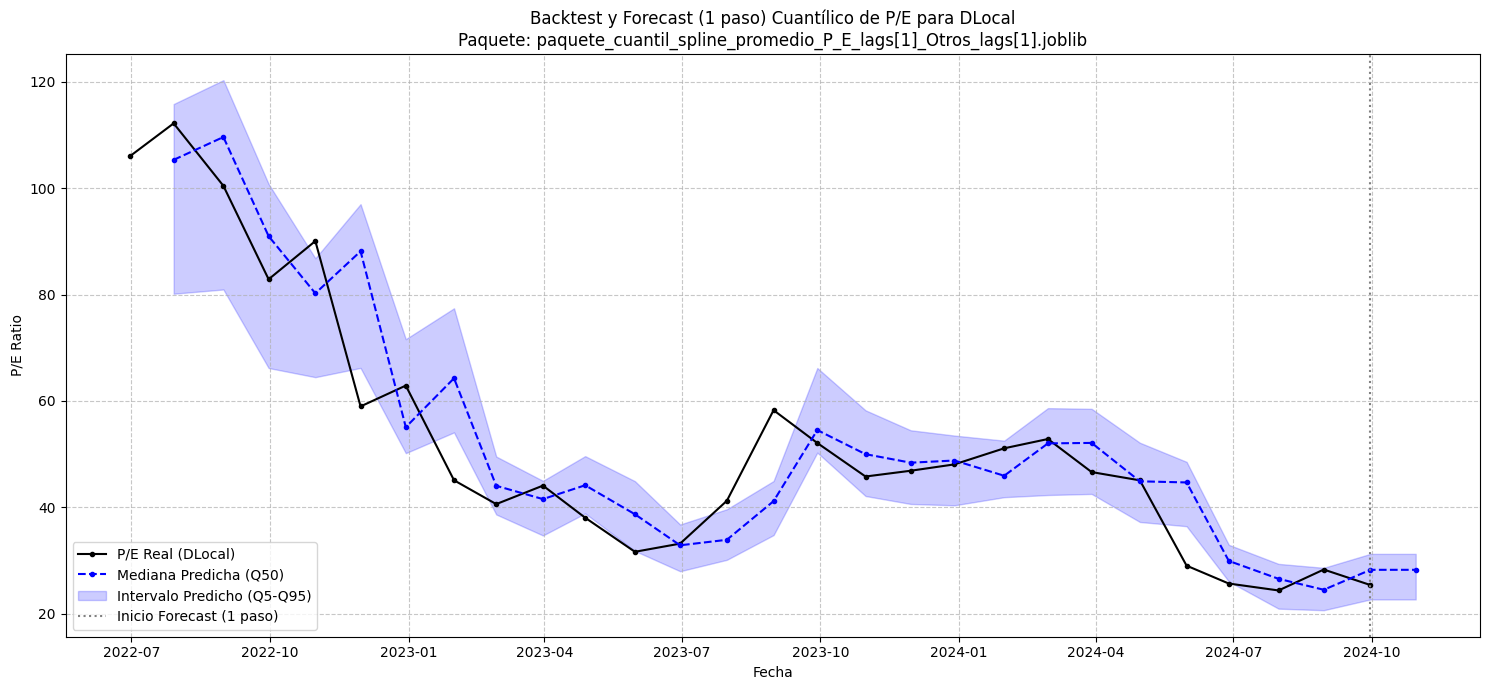


Forecast A Un Paso para DLocal:
       Fecha  P_E_pred_q5  P_E_pred_q50  P_E_pred_q95  P_E
0 2024-10-30    22.667066     28.233272      31.23448  NaN


In [46]:
# ================================================================================
# BLOQUE DE BACKTESTING "A UN PASO" Y FORECAST "A UN PASO" CUANTÍLICO PARA DLOCAL
# ================================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import re
import warnings
from sklearn.metrics import mean_pinball_loss, mean_squared_error # Para métricas de backtesting

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- Configuración para la Predicción ---
EMPRESA_A_PREDECIR = "DLocal"
# N_FUTURE_STEPS ya no se usa para un forecast a un solo paso, pero lo dejamos por si se quiere cambiar
# N_FUTURE_STEPS_FORECAST = 1 # <--- CAMBIO CLAVE: Solo 1 paso para el forecast
QUANTILES_PREDICCION = [0.05, 0.5, 0.95]
ALPHA_LOWER_INTERVAL = QUANTILES_PREDICCION[0]
ALPHA_UPPER_INTERVAL = QUANTILES_PREDICCION[-1]
ALPHA_MEDIAN = QUANTILES_PREDICCION[len(QUANTILES_PREDICCION)//2]


# !!! NOMBRE DEL PAQUETE DE MODELOS ENTRENADOS !!!
NOMBRE_PAQUETE_MODELOS = "paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib"
print(f"Usando el paquete: {NOMBRE_PAQUETE_MODELOS}")

# --- ASEGÚRATE DE QUE 'df_dlocal' ESTÉ DEFINIDO ANTES DE ESTE BLOQUE ---
if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
    print(f"ERROR CRÍTICO: La variable 'df_dlocal' no está definida, no es un DataFrame o está vacía.")
    raise SystemExit("'df_dlocal' no disponible o inválida.")
else:
    print(f"INFO: Usando la variable 'df_dlocal' existente para los datos históricos de {EMPRESA_A_PREDECIR}.")
    df_empresa_hist_original = df_dlocal.copy()

# --- Cargar el paquete de modelos ---
# ... (Sección de carga de paquete sin cambios) ...
try:
    paquete_cargado = joblib.load(NOMBRE_PAQUETE_MODELOS)
    print(f"Paquete '{NOMBRE_PAQUETE_MODELOS}' cargado exitosamente.")
except FileNotFoundError:
    print(f"ERROR CRÍTICO: Archivo del paquete '{NOMBRE_PAQUETE_MODELOS}' no encontrado.")
    raise SystemExit(f"Archivo del paquete no encontrado: {NOMBRE_PAQUETE_MODELOS}")
except Exception as e:
    print(f"ERROR CRÍTICO: No se pudo cargar el paquete '{NOMBRE_PAQUETE_MODELOS}'. Error: {e}")
    raise SystemExit(f"Error al cargar el paquete: {e}")

log_transform_usada = paquete_cargado.get('log_transform_target')
features_entrenamiento = paquete_cargado.get('features_usadas_en_entrenamiento')
modelos_paquete = paquete_cargado.get('modelos_por_tipo_y_cuantil_o_puntual')

if any(v is None for v in [log_transform_usada, features_entrenamiento, modelos_paquete]):
    print("ERROR CRÍTICO: Información esencial faltante en el paquete cargado.")
    raise SystemExit("Paquete inválido.")

modelo_cuantil_key_base = None
for key_iter in modelos_paquete.keys():
    if 'Quantile' in key_iter and isinstance(modelos_paquete[key_iter], dict):
        potential_quantile_models = modelos_paquete[key_iter]
        if all(q_alpha in potential_quantile_models for q_alpha in QUANTILES_PREDICCION):
            modelo_cuantil_key_base = key_iter
            break
if not modelo_cuantil_key_base:
    print(f"ERROR CRÍTICO: No se encontró clave de diccionario para modelos cuantílicos en el paquete.")
    raise SystemExit("Modelos cuantílicos no encontrados en paquete.")
modelos_cuantil_dict = modelos_paquete[modelo_cuantil_key_base]
for alpha_val in QUANTILES_PREDICCION:
    if alpha_val not in modelos_cuantil_dict or not hasattr(modelos_cuantil_dict[alpha_val], 'predict'):
        print(f"ERROR CRÍTICO: Modelo para cuantil {alpha_val} faltante o inválido.")
        raise SystemExit(f"Modelo para cuantil {alpha_val} faltante o inválido.")

# --- Preparar datos históricos de DLocal ---
# ... (Sección de preparación de df_empresa_hist y función crear_features_con_lags sin cambios) ...
df_empresa_hist = df_empresa_hist_original.copy()
if 'Fecha' not in df_empresa_hist.columns:
    print("ERROR CRÍTICO: 'Fecha' no en df_empresa_hist (derivado de df_dlocal).")
    raise SystemExit("'Fecha' faltante.")
try:
    df_empresa_hist['Fecha'] = pd.to_datetime(df_empresa_hist['Fecha'])
except Exception as e_date:
    print(f"ERROR CRÍTICO: No se pudo convertir 'Fecha' a datetime. Error: {e_date}")
    raise SystemExit("Error en formato de 'Fecha'.")
df_empresa_hist.sort_values(by='Fecha', ascending=True, inplace=True)
df_empresa_hist.reset_index(drop=True, inplace=True)

def crear_features_con_lags_para_prediccion(df_historico_empresa, features_modelo_espera, fecha_base_prediccion):
    input_features = {}
    df_hist_para_lags = df_historico_empresa[df_historico_empresa['Fecha'] <= fecha_base_prediccion].sort_values(by='Fecha', ascending=False)
    if df_hist_para_lags.empty:
        for feat in features_modelo_espera: input_features[feat] = np.nan
        return pd.Series(input_features, index=features_modelo_espera)
    for feature_lag_name in features_modelo_espera:
        match = re.match(r"(.+)_lag(\d+)", feature_lag_name)
        if match:
            base_col_name = match.group(1)
            lag_n = int(match.group(2))
            if base_col_name not in df_hist_para_lags.columns:
                input_features[feature_lag_name] = np.nan
                continue
            if lag_n < len(df_hist_para_lags): 
                input_features[feature_lag_name] = df_hist_para_lags[base_col_name].iloc[lag_n]
            else:
                input_features[feature_lag_name] = np.nan
        else: 
            if feature_lag_name in df_hist_para_lags.columns:
                 input_features[feature_lag_name] = df_hist_para_lags[feature_lag_name].iloc[0] 
            else:
                input_features[feature_lag_name] = np.nan
    return pd.Series(input_features, index=features_modelo_espera)

# --- 1. BACKTESTING "A UN PASO": GENERAR PREDICCIONES PARA EL PERÍODO HISTÓRICO ---
# ... (Esta sección se mantiene igual que en el bloque anterior para el backtesting) ...
print("\n--- Backtesting A Un Paso para DLocal ---")
historical_predictions_list = []
min_lag_required = 0
if features_entrenamiento: 
    for feat_name in features_entrenamiento:
        match_lag = re.search(r"_lag(\d+)", feat_name)
        if match_lag:
            min_lag_required = max(min_lag_required, int(match_lag.group(1)))
for index, row_hist in df_empresa_hist.iterrows():
    current_hist_fecha = row_hist['Fecha']
    p_e_real_hist = row_hist.get('P_E', np.nan)
    pred_row_hist = {'Fecha': current_hist_fecha, 'P_E_real': p_e_real_hist}
    for alpha_val in QUANTILES_PREDICCION: 
        pred_row_hist[f'P_E_pred_q{int(alpha_val*100)}'] = np.nan
    if index < min_lag_required: 
        historical_predictions_list.append(pred_row_hist)
        continue
    hist_input_features = crear_features_con_lags_para_prediccion(df_empresa_hist, features_entrenamiento, current_hist_fecha)
    if hist_input_features.isna().all():
        historical_predictions_list.append(pred_row_hist)
        continue
    input_df_hist_model = pd.DataFrame([hist_input_features], columns=features_entrenamiento)
    for alpha_val in QUANTILES_PREDICCION:
        model_cuantil_actual = modelos_cuantil_dict[alpha_val]
        try:
            pred_transformed_hist = model_cuantil_actual.predict(input_df_hist_model)[0]
            if pd.isna(pred_transformed_hist): pred_original_hist = np.nan
            elif log_transform_usada: pred_original_hist = np.expm1(pred_transformed_hist)
            else: pred_original_hist = pred_transformed_hist
            pred_row_hist[f'P_E_pred_q{int(alpha_val*100)}'] = np.nan_to_num(pred_original_hist) if not pd.isna(pred_original_hist) else np.nan
        except Exception: pass             
    historical_predictions_list.append(pred_row_hist)
df_historical_quantile_preds = pd.DataFrame(historical_predictions_list)

# Calcular Métricas de Backtesting
# ... (Sección de métricas de backtesting sin cambios) ...
df_backtest_eval = df_historical_quantile_preds.dropna(
    subset=['P_E_real', f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}', f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}']
)
if not df_backtest_eval.empty:
    y_true_backtest = df_backtest_eval['P_E_real']
    pred_lower_backtest = df_backtest_eval[f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}']
    pred_upper_backtest = df_backtest_eval[f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}']
    coverage = np.mean((y_true_backtest >= pred_lower_backtest) & (y_true_backtest <= pred_upper_backtest))
    mean_interval_width = np.mean(pred_upper_backtest - pred_lower_backtest)
    pinball_loss_lower = mean_pinball_loss(y_true_backtest, pred_lower_backtest, alpha=ALPHA_LOWER_INTERVAL)
    pinball_loss_upper = mean_pinball_loss(y_true_backtest, pred_upper_backtest, alpha=ALPHA_UPPER_INTERVAL)
    avg_pinball_loss_interval = (pinball_loss_lower + pinball_loss_upper) / 2
    print(f"\nMétricas de Backtesting A Un Paso para DLocal:")
    print(f"  Puntos evaluados: {len(df_backtest_eval)}")
    print(f"  Cobertura ({ALPHA_LOWER_INTERVAL*100:.0f}%-{ALPHA_UPPER_INTERVAL*100:.0f}%): {coverage:.2%}")
    print(f"  Anchura Media Intervalo: {mean_interval_width:.2f}")
    print(f"  Pinball Loss Media Intervalo: {avg_pinball_loss_interval:.4f}")
    median_pred_col_name = f'P_E_pred_q{int(ALPHA_MEDIAN*100)}'
    if median_pred_col_name in df_backtest_eval.columns:
        valid_median_mask = df_backtest_eval[median_pred_col_name].notna()
        y_true_for_median = y_true_backtest[valid_median_mask]
        pred_median_backtest = df_backtest_eval.loc[valid_median_mask, median_pred_col_name]
        if not pred_median_backtest.empty and not y_true_for_median.empty:
            rmse_median = np.sqrt(mean_squared_error(y_true_for_median, pred_median_backtest))
            from sklearn.metrics import mean_absolute_error as mae
            mae_median = mae(y_true_for_median, pred_median_backtest)
            pinball_loss_median = mean_pinball_loss(y_true_for_median, pred_median_backtest, alpha=ALPHA_MEDIAN)
            print(f"  RMSE Mediana (Q{int(ALPHA_MEDIAN*100)}): {rmse_median:.2f}")
            print(f"  MAE Mediana (Q{int(ALPHA_MEDIAN*100)}): {mae_median:.2f}")
            print(f"  Pinball Loss Mediana (Q{int(ALPHA_MEDIAN*100)}): {pinball_loss_median:.4f}")
else:
    print("\nNo hay datos para métricas de backtesting.")

# --- 2. FORECAST "A UN PASO": GENERAR PREDICCIÓN SOLO PARA EL SIGUIENTE MES ---
print("\n--- Forecast A Un Paso para DLocal ---")
last_known_row_dlocal = df_empresa_hist.iloc[-1:]
last_known_P_E_original = last_known_row_dlocal['P_E'].iloc[0]
last_known_fecha = pd.to_datetime(last_known_row_dlocal['Fecha'].iloc[0])

# Features para predecir el primer mes futuro
features_for_next_step_forecast = crear_features_con_lags_para_prediccion(
    df_empresa_hist, features_entrenamiento, last_known_fecha
)

single_future_prediction_list = []
if not features_for_next_step_forecast.isna().all():
    input_df_forecast_model = pd.DataFrame([features_for_next_step_forecast], columns=features_entrenamiento)
    
    pred_step_transformed_future = {}
    pred_step_original_future = {}
    
    first_future_date = last_known_fecha + pd.DateOffset(months=1)
    pred_row_future = {'Fecha': first_future_date}

    for alpha_val in QUANTILES_PREDICCION:
        model_cuantil_actual = modelos_cuantil_dict[alpha_val]
        try:
            pred_transformed = model_cuantil_actual.predict(input_df_forecast_model)[0]
        except Exception:
            pred_transformed = np.nan
        pred_step_transformed_future[alpha_val] = pred_transformed
        
        if pd.isna(pred_transformed): pred_original_val = np.nan
        elif log_transform_usada: pred_original_val = np.expm1(pred_transformed)
        else: pred_original_val = pred_transformed
        pred_step_original_future[alpha_val] = np.nan_to_num(pred_original_val) if not pd.isna(pred_original_val) else np.nan
        pred_row_future[f'P_E_pred_q{int(alpha_val*100)}'] = pred_step_original_future[alpha_val]
        
    single_future_prediction_list.append(pred_row_future)
    
    q_strs_future = [f"Q{int(qv*100)}: {pred_step_original_future.get(qv, np.nan):.2f}" for qv in QUANTILES_PREDICCION]
    print(f"Predicción para {first_future_date.strftime('%Y-%m-%d')}: {', '.join(q_strs_future)}")
else:
    print("No se pudieron generar features para el forecast a un paso.")

df_single_future_prediction = pd.DataFrame(single_future_prediction_list)

# --- 3. COMBINAR DATAFRAMES Y GRAFICAR ---
df_historical_quantile_preds.rename(columns={'P_E_real': 'P_E'}, inplace=True, errors='ignore')
df_single_future_prediction['P_E'] = np.nan # No hay P/E real para el futuro

df_combined_predictions = pd.concat([df_historical_quantile_preds, df_single_future_prediction], ignore_index=True)
df_combined_predictions.sort_values(by='Fecha', inplace=True)

plt.figure(figsize=(15, 7))
plt.plot(df_combined_predictions['Fecha'], df_combined_predictions['P_E'], label=f'P/E Real ({EMPRESA_A_PREDECIR})', color='black', marker='.', linestyle='-')
median_col = f'P_E_pred_q{int(ALPHA_MEDIAN*100)}'
lower_col = f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}'
upper_col = f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}'
df_plot_median = df_combined_predictions.dropna(subset=[median_col])
df_plot_interval = df_combined_predictions.dropna(subset=[lower_col, upper_col])

if not df_plot_median.empty:
    plt.plot(df_plot_median['Fecha'], df_plot_median[median_col], label=f'Mediana Predicha (Q{int(ALPHA_MEDIAN*100)})', color='blue', marker='o', markersize=3, linestyle='--')
if not df_plot_interval.empty:
    plt.fill_between(df_plot_interval['Fecha'], df_plot_interval[lower_col], df_plot_interval[upper_col], color='blue', alpha=0.2, label=f'Intervalo Predicho (Q{int(ALPHA_LOWER_INTERVAL*100)}-Q{int(ALPHA_UPPER_INTERVAL*100)})')

# Línea vertical para separar backtest de forecast (ahora solo un punto de forecast)
plt.axvline(last_known_fecha, color='gray', linestyle=':', linewidth=1.5, label='Inicio Forecast (1 paso)')

plt.title(f'Backtest y Forecast (1 paso) Cuantílico de P/E para {EMPRESA_A_PREDECIR}\nPaquete: {NOMBRE_PAQUETE_MODELOS.split("/")[-1]}')
plt.xlabel('Fecha')
plt.ylabel('P/E Ratio')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Imprimir tabla de la única predicción futura
print("\n" + "="*80)
print(f"Forecast A Un Paso para {EMPRESA_A_PREDECIR}:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(df_single_future_prediction)
print("="*80)

#### Con transformación logarítmica


Procesando Método: lineal_mediana (CON Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=14.4482, MAE=3.5074, R2=0.7475
    Métricas Test RF_HP: RMSE=14.6601, MAE=3.4002, R2=0.7400
    Métricas Test XGB_Simple: RMSE=18.1982, MAE=3.9280, R2=0.5994
    Métricas Test XGB_HP: RMSE=16.9477, MAE=3.4533, R2=0.6526
    Métricas Test LGBM_Simple: RMSE=16.2625, MAE=3.5494, R2=0.6801
    Métricas Test LGBM_HP: RMSE=17.0480, MAE=3.5136, R2=0.6485
    Métricas Test CB_Simple: RMSE=16.3227, MAE=3.3851, R2=0.6777
    Métricas Test CB_HP: RMSE=15.4861, MAE=3.3227, R2=0.7099

Tiempo total para Método: lineal_mediana: 373.04s

Procesando Método: spline_mediana (CON Log Transform) (Lags: _lag1, con DropColumns)

    Métricas Test RF_Simple: RMSE=14.4560, MAE=3.5153, R2=0.7472
    Métricas Test RF_HP: RMSE=14.6100, MAE=3.4302, R2=0.7418
    Métricas Test XGB_Simple: RMSE=16.3070, MAE=3.6988, R2=0.6784
    Métricas Test XGB_HP: RMSE=16.4757, MAE=3.4726, R2=0.6717
    Métrica

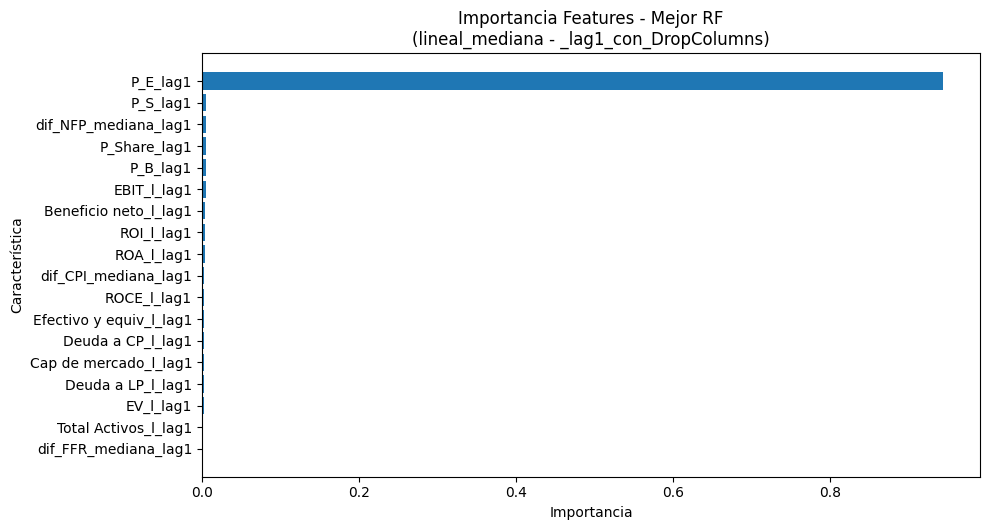

  Mejor XGB para lineal_mediana: RMSE = 16.9477
    Generando importancia de features para Mejor XGB de lineal_mediana...


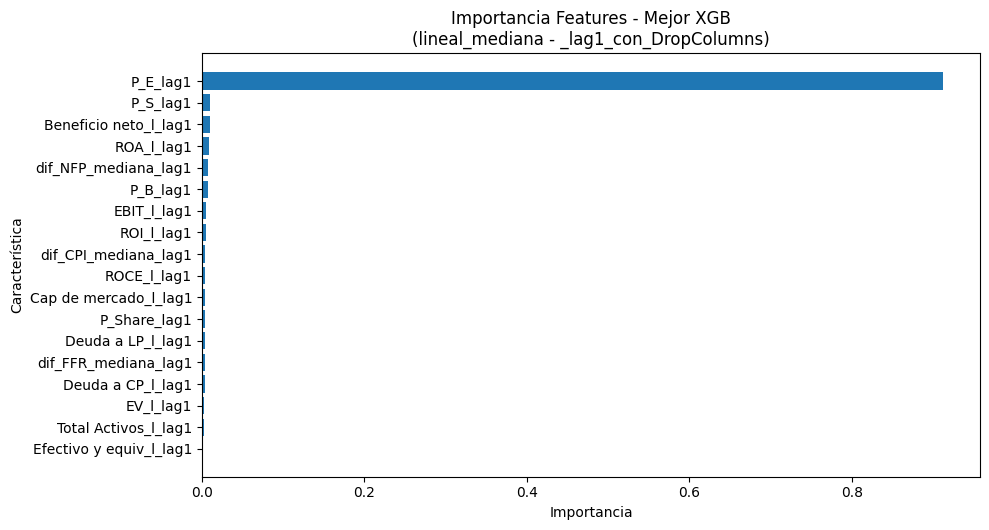

  Mejor LGBM para lineal_mediana: RMSE = 16.2625
    Generando importancia de features para Mejor LGBM de lineal_mediana...


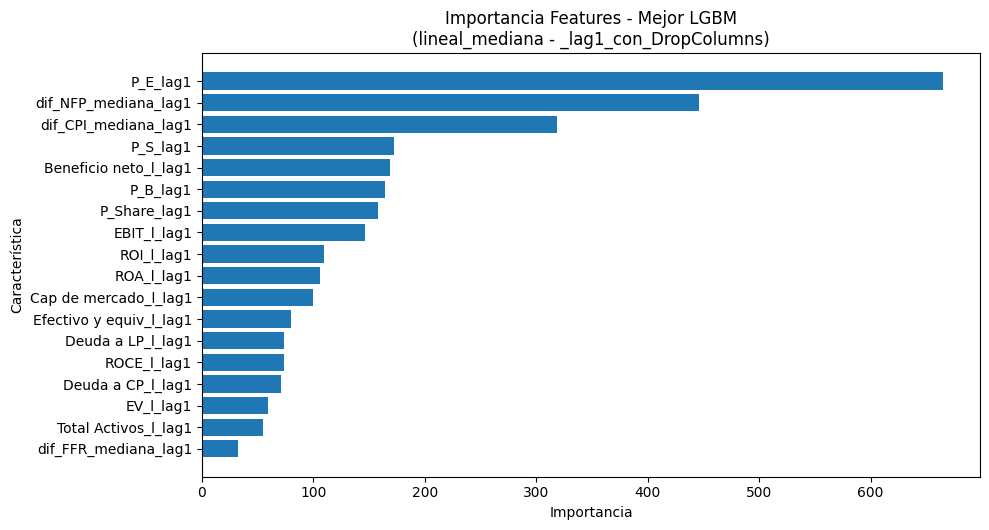

  Mejor CB para lineal_mediana: RMSE = 15.4861
    Generando importancia de features para Mejor CB de lineal_mediana...


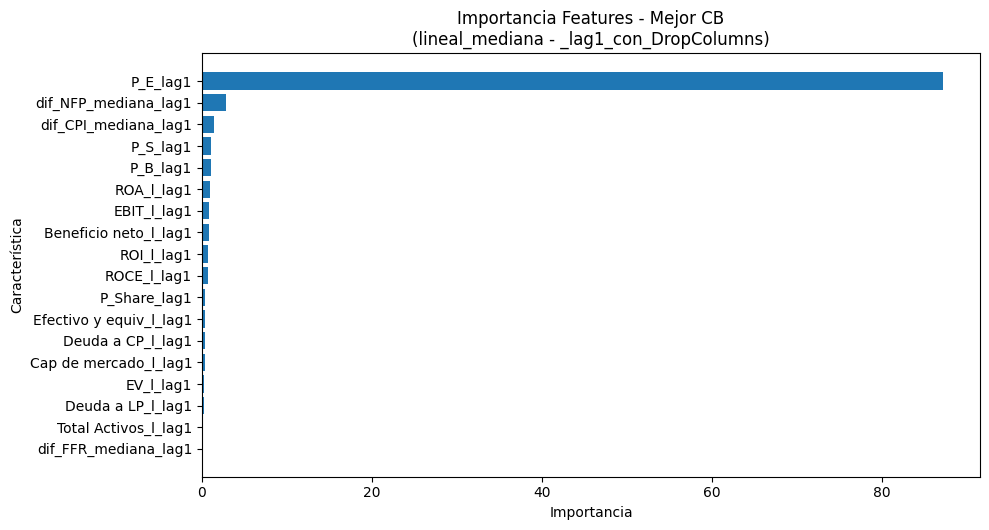


Paquete para 'lineal_mediana' guardado como: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_mediana ---
  Mejor RF para spline_mediana: RMSE = 14.4560
    Generando importancia de features para Mejor RF de spline_mediana...


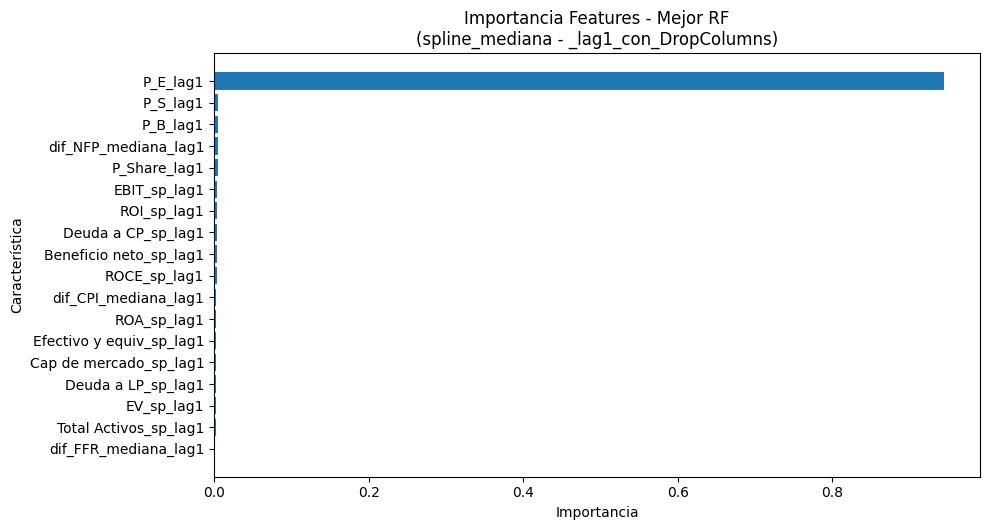

  Mejor XGB para spline_mediana: RMSE = 16.3070
    Generando importancia de features para Mejor XGB de spline_mediana...


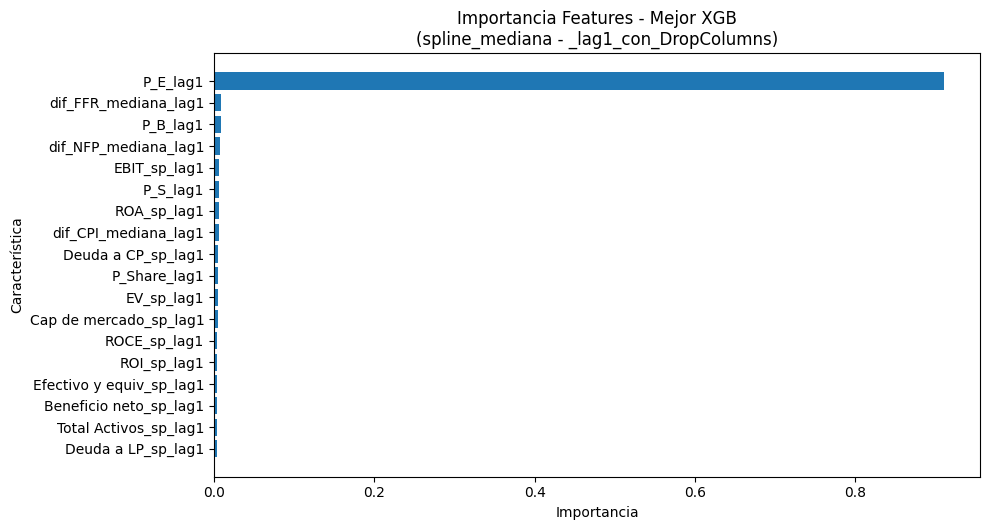

  Mejor LGBM para spline_mediana: RMSE = 16.5207
    Generando importancia de features para Mejor LGBM de spline_mediana...


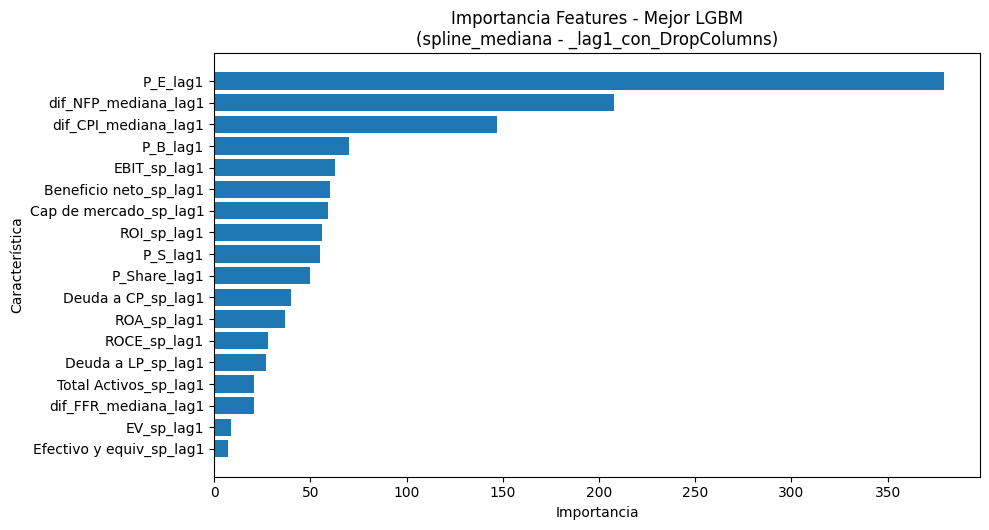

  Mejor CB para spline_mediana: RMSE = 15.9241
    Generando importancia de features para Mejor CB de spline_mediana...


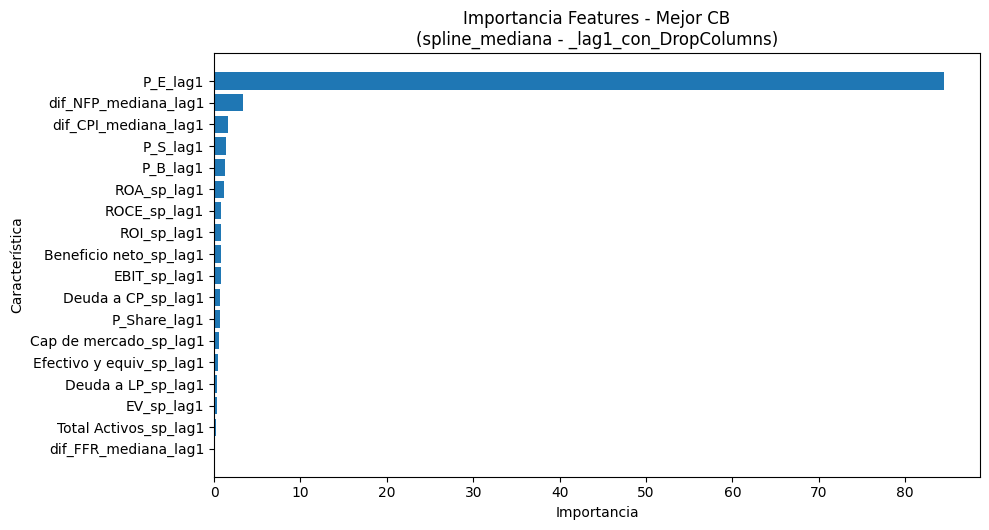


Paquete para 'spline_mediana' guardado como: paquete_mejores_por_tipo_spline_mediana__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: lineal_promedio ---
  Mejor RF para lineal_promedio: RMSE = 14.6831
    Generando importancia de features para Mejor RF de lineal_promedio...


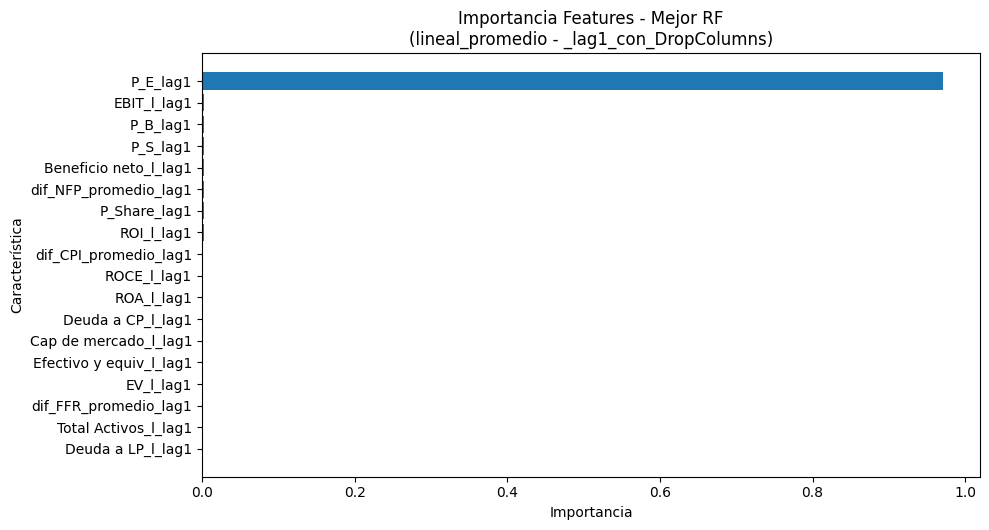

  Mejor XGB para lineal_promedio: RMSE = 15.7362
    Generando importancia de features para Mejor XGB de lineal_promedio...


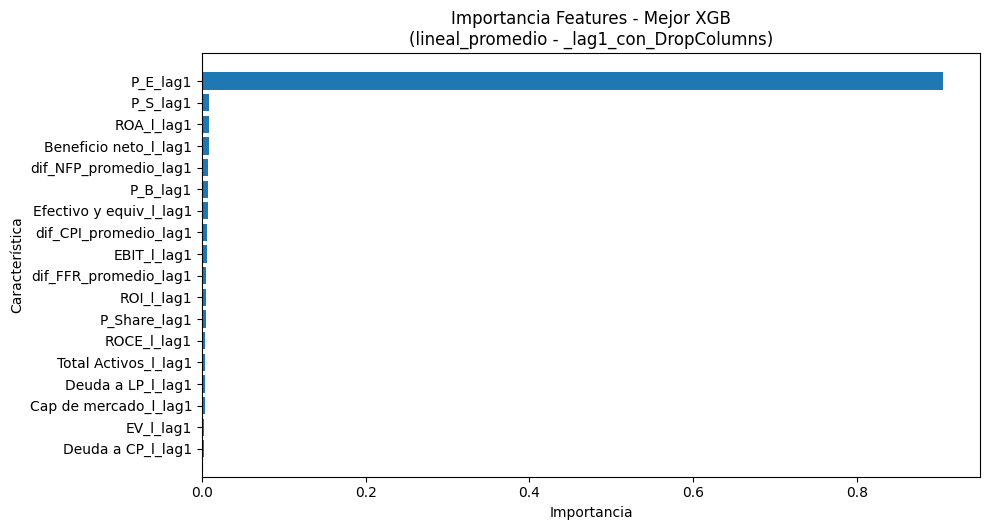

  Mejor LGBM para lineal_promedio: RMSE = 15.7935
    Generando importancia de features para Mejor LGBM de lineal_promedio...


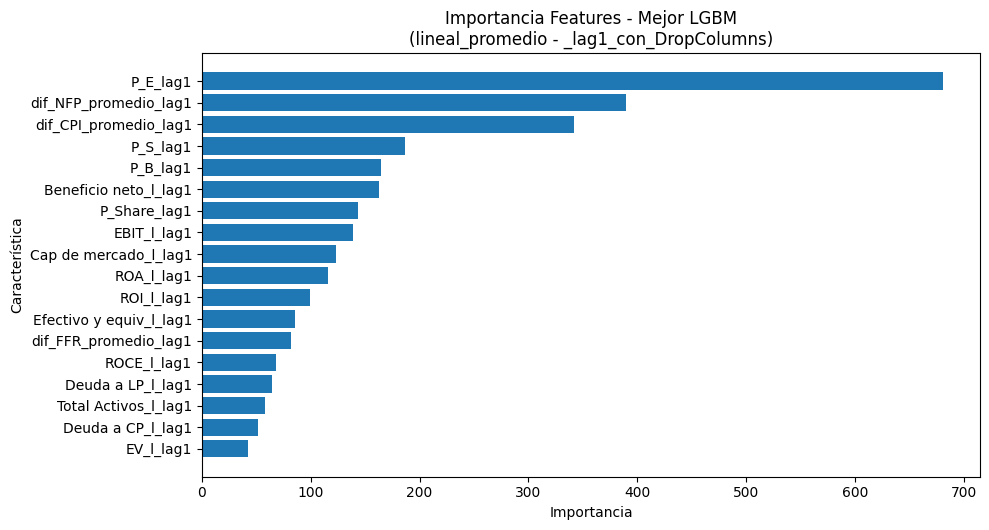

  Mejor CB para lineal_promedio: RMSE = 15.1869
    Generando importancia de features para Mejor CB de lineal_promedio...


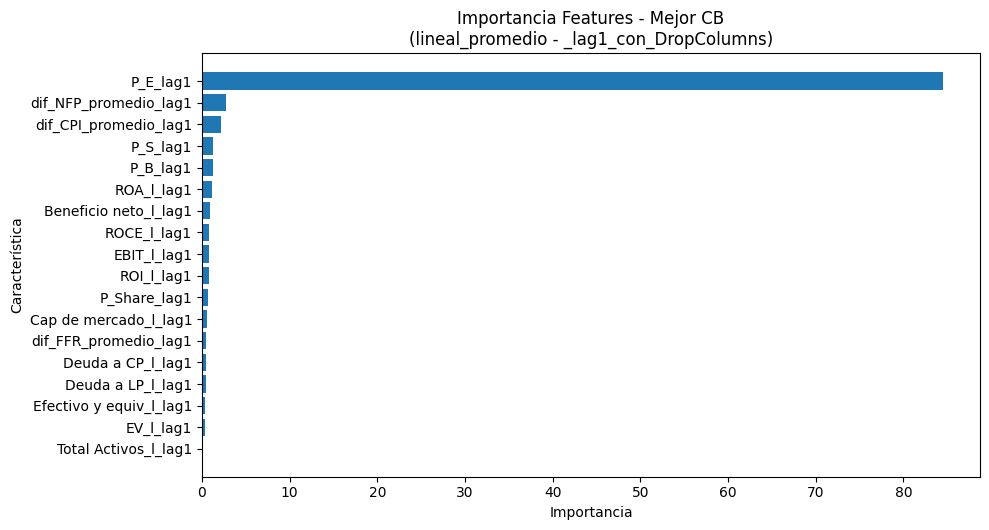


Paquete para 'lineal_promedio' guardado como: paquete_mejores_por_tipo_lineal_promedio__lag1_con_DropColumns.joblib

--- Preparando paquete y plots para Método: spline_promedio ---
  Mejor RF para spline_promedio: RMSE = 14.4707
    Generando importancia de features para Mejor RF de spline_promedio...


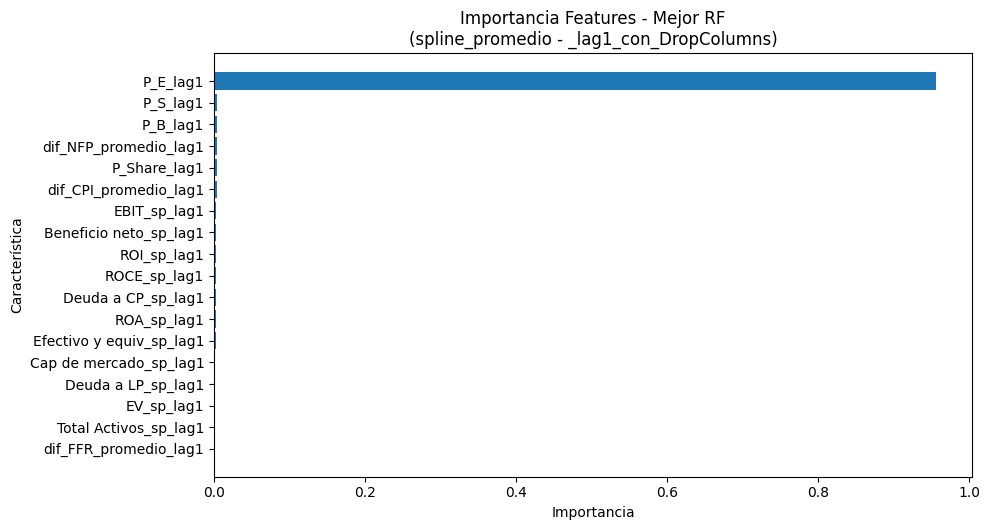

  Mejor XGB para spline_promedio: RMSE = 15.1484
    Generando importancia de features para Mejor XGB de spline_promedio...


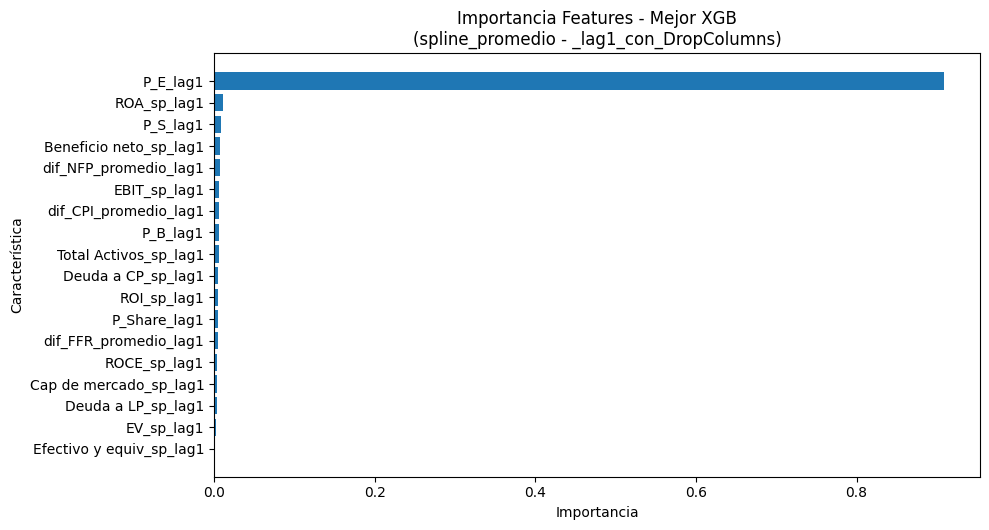

  Mejor LGBM para spline_promedio: RMSE = 15.6556
    Generando importancia de features para Mejor LGBM de spline_promedio...


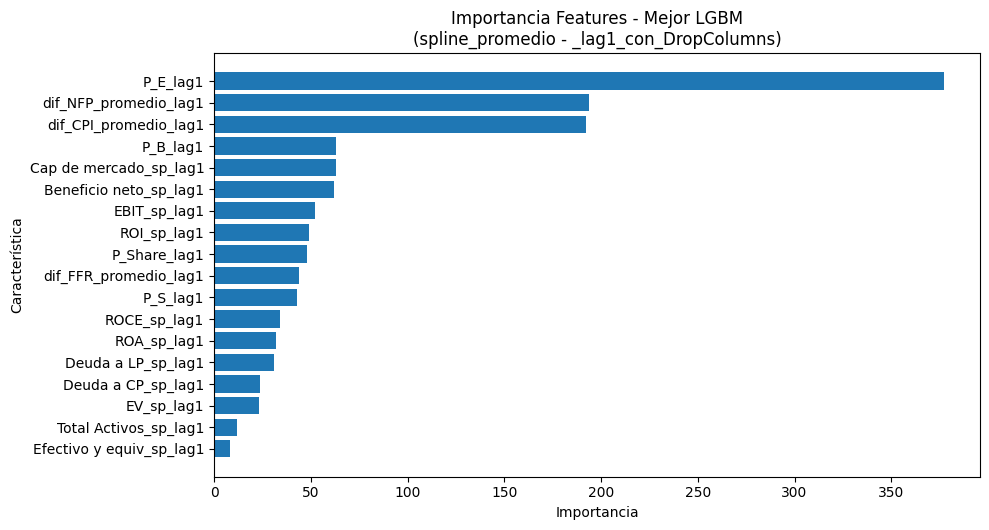

  Mejor CB para spline_promedio: RMSE = 15.6052
    Generando importancia de features para Mejor CB de spline_promedio...


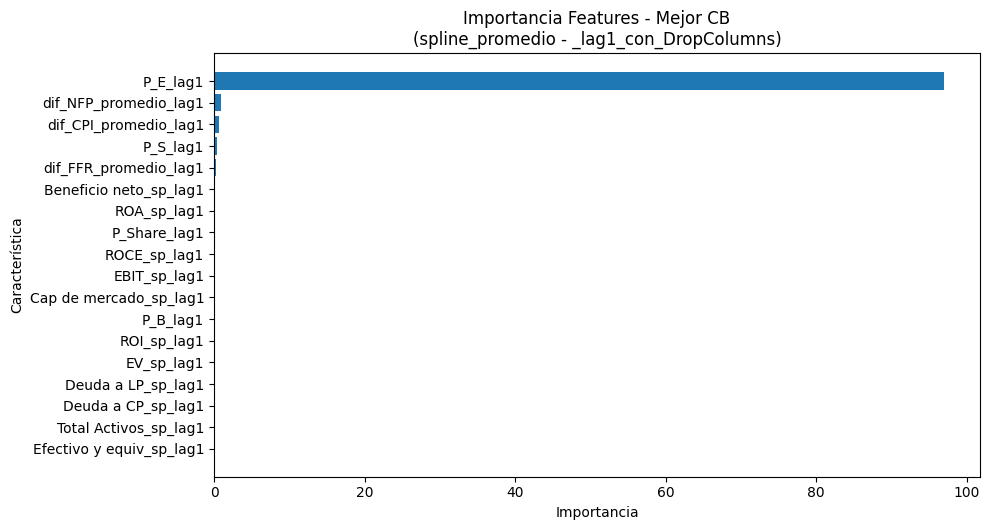


Paquete para 'spline_promedio' guardado como: paquete_mejores_por_tipo_spline_promedio__lag1_con_DropColumns.joblib

TABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO
Metodo_Features            Lag_Config  Log_Transform Modelo_Tipo_Base    RMSE    MAE     R2  n_features_modelo                                                                                               Best_Params
 lineal_mediana _lag1_con_DropColumns           True               RF 14.4482 3.5074 0.7475                 18                                                                                                      None
 lineal_mediana _lag1_con_DropColumns           True               CB 15.4861 3.3227 0.7099                 18       {'model__depth': 7, 'model__iterations': 200, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.1}
 lineal_mediana _lag1_con_DropColumns           True             LGBM 16.2625 3.5494 0.6801                 18                                                                           

In [47]:
# ================================================================================
# BLOQUE DE EXPERIMENTOS (CON DropColumns en Pipeline, PLOT FEATURE IMPORTANCE para Mejores por Tipo, GUARDAR PAQUETES)
# ================================================================================
results_accumulator = [] 
start_time_total_experiments = time.time()
use_log_transform_experiment = True
test_size_ratio_experiment = 0.20
LAG_SUFFIX_TO_USE = '_lag1' 

if 'dfs_shifted' not in locals() or not isinstance(dfs_shifted, dict) or not dfs_shifted:
    raise NameError("El diccionario 'dfs_shifted' no está definido o está vacío.")

for metodo_features, df_original_with_lags_and_ids in dfs_shifted.items():
    start_time_metodo = time.time()
    lag_config_display = f"{LAG_SUFFIX_TO_USE}_con_DropColumns" 

    print("\n" + "="*80)
    print(f"Procesando Método: {metodo_features} {'(CON Log Transform)' if use_log_transform_experiment else '(SIN Log Transform)'} (Lags: {LAG_SUFFIX_TO_USE}, con DropColumns)")
    print("="*80 + "\n")

    if df_original_with_lags_and_ids.empty: continue
    df_current_method_processed = df_original_with_lags_and_ids.copy()
    if 'time_step' not in df_current_method_processed.columns:
        df_current_method_processed.sort_values(['Empresa', 'Fecha'], inplace=True)
        df_current_method_processed['time_step'] = df_current_method_processed.groupby('Empresa').cumcount()

    predictor_cols_for_pipeline_input = sorted([
        c for c in df_current_method_processed.columns 
        if c.endswith(LAG_SUFFIX_TO_USE) and c not in ['Empresa', 'Fecha', 'time_step', 'P_E']
    ])
    if not predictor_cols_for_pipeline_input: continue
    columnas_base_que_generaron_lags = sorted(list(set(re.sub(r'_lag\d+$', '', lag_col) for lag_col in predictor_cols_for_pipeline_input)))
    
    all_relevant_cols_for_df = ['Empresa', 'Fecha', 'time_step', 'P_E'] + predictor_cols_for_pipeline_input
    final_cols_for_df_model_construction = sorted(list(set(c for c in all_relevant_cols_for_df if c in df_current_method_processed.columns)))
    essential_cols_check = ['Empresa', 'Fecha', 'time_step', 'P_E']
    if not all(ec in final_cols_for_df_model_construction for ec in essential_cols_check): continue
    df_model_for_splitting = df_current_method_processed[final_cols_for_df_model_construction].copy()

    n_total_empresas = df_model_for_splitting['Empresa'].nunique()
    n_empresas_test = 0
    if n_total_empresas > 1:
        n_empresas_test = max(1, int(round(n_total_empresas * test_size_ratio_experiment)))
        if n_total_empresas - n_empresas_test < 1 : n_empresas_test = n_total_empresas - 1
    X_train_with_ids, y_train_original, X_test_with_ids, y_test_original = train_test_split_by_empresa(df_model_for_splitting, n_empresas_test)
    if X_train_with_ids is None or X_train_with_ids.empty: continue
    
    y_train_transformed_target = y_train_original.copy()
    if use_log_transform_experiment:
        y_numeric = pd.to_numeric(y_train_original, errors='coerce')
        median_y_train = y_numeric.median() if not y_numeric.isnull().all() else 0.0
        y_numeric = y_numeric.fillna(median_y_train); y_numeric.loc[y_numeric < 0] = 0
        y_train_transformed_target = np.log1p(y_numeric)
        if y_train_transformed_target.isnull().any():
             median_y_transformed = y_train_transformed_target.median() if not y_train_transformed_target.isnull().all() else 0.0
             y_train_transformed_target = y_train_transformed_target.fillna(median_y_transformed)

    if not X_train_with_ids.index.equals(y_train_transformed_target.index):
        common_idx_train = X_train_with_ids.index.intersection(y_train_transformed_target.index)
        X_train_with_ids = X_train_with_ids.loc[common_idx_train]
        y_train_transformed_target = y_train_transformed_target.loc[common_idx_train]
        if X_train_with_ids.empty : continue

    X_train_s_with_ids, y_train_s_transformed = sort_by_timestep(X_train_with_ids, y_train_transformed_target)
    X_test_s_with_ids, y_test_s_original = pd.DataFrame(), pd.Series(dtype=float)
    if X_test_with_ids is not None and not X_test_with_ids.empty:
        X_test_s_with_ids, y_test_s_original = sort_by_timestep(X_test_with_ids, y_test_original)

    param_grid_rf   = {'model__max_depth':[10, 20, None],'model__min_samples_split':[5, 10],'model__n_estimators':[100, 200]}
    param_grid_xgb  = {'model__n_estimators':[100, 200],'model__max_depth':[3, 5, 7],'model__learning_rate':[0.1, 0.05]}
    param_grid_lgbm = {'model__n_estimators':[100, 200],'model__learning_rate':[0.1, 0.05],'model__max_depth':[3, 5, 7],'model__num_leaves':[15, 31]}
    param_grid_cb   = {'model__iterations':[100, 200],'model__learning_rate':[0.1, 0.05],'model__depth':[3, 5, 7],'model__l2_leaf_reg':[1, 3]}
    scenarios = {
        'RF_Simple':  {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_rf},
        'RF_HP':      {'model': RandomForestRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_rf},
        'XGB_Simple': {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': False, 'vt': False, 'grid': param_grid_xgb},
        'XGB_HP':     {'model': XGBRegressor(random_state=42, n_jobs=-1), 'hp': True,  'vt': False, 'grid': param_grid_xgb},
        'LGBM_Simple':{'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': False, 'vt': False, 'grid': param_grid_lgbm},
        'LGBM_HP':    {'model': LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1), 'hp': True,  'vt': False, 'grid': param_grid_lgbm},
        'CB_Simple':  {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': False, 'vt': False, 'grid': param_grid_cb},
        'CB_HP':      {'model': CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False), 'hp': True,  'vt': False, 'grid': param_grid_cb},
    }

    for escenario_nombre, escenario_cfg in scenarios.items():
        tiempo_esc_inicio = time.time()
        current_base_model = escenario_cfg['model']; perform_hp_search = escenario_cfg['hp']; use_temporal_cv_in_scenario = escenario_cfg.get('vt', False)
        X_fit_data_pipeline = X_train_s_with_ids if use_temporal_cv_in_scenario else X_train_with_ids
        y_fit_data_pipeline = y_train_s_transformed if use_temporal_cv_in_scenario else y_train_transformed_target
        X_eval_data_pipeline = X_test_s_with_ids if use_temporal_cv_in_scenario else X_test_with_ids
        y_eval_data_original_final = y_test_s_original if use_temporal_cv_in_scenario else y_test_original
        if X_fit_data_pipeline.empty or y_fit_data_pipeline.empty:
            results_accumulator.append({'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario,
                'Busqueda_HP': perform_hp_search, 'Config_Key': metodo_features, 'Metodo': metodo_features,
                'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 'RMSE': np.nan, 'MAE': np.nan, 
                'R2': np.nan, 'Best_Params': None, 'pipeline': 'Error: Datos vacíos', 
                'columnas_base_usadas': columnas_base_que_generaron_lags, 
                'n_features_modelo': len(predictor_cols_after_drop), 
                'features_usadas_por_modelo': [], 'Error': 'Datos vacíos'})
            continue
        cols_to_drop_in_pipeline = [col for col in ['Empresa', 'Fecha', 'time_step'] if col in X_fit_data_pipeline.columns]
        pipeline_obj_for_training = Pipeline([('drop_ids', DropColumns(columns=cols_to_drop_in_pipeline)), ('model', current_base_model)])
        model_actual_features_for_plot = [col for col in X_fit_data_pipeline.columns if col not in cols_to_drop_in_pipeline]
        final_fitted_pipeline, hp_best_params_found, error_msg_escenario = None, None, None
        try:
            if perform_hp_search:
                cv_strategy_obj, cv_fit_params_dict, can_perform_cv = None, {}, True
                n_groups_for_cv = X_fit_data_pipeline['Empresa'].nunique() if use_temporal_cv_in_scenario and 'Empresa' in X_fit_data_pipeline.columns else 0
                if use_temporal_cv_in_scenario and n_groups_for_cv >= 2:
                    groups_for_gkf = X_fit_data_pipeline['Empresa']; n_splits_gkf = min(3, n_groups_for_cv); n_splits_gkf = max(2, n_splits_gkf)
                    if len(X_fit_data_pipeline) < n_splits_gkf : can_perform_cv = False
                    else: cv_strategy_obj = GroupKFold(n_splits=n_splits_gkf); cv_fit_params_dict = {'groups': groups_for_gkf}
                elif len(X_fit_data_pipeline) >= 2:
                    n_samples_kf = len(X_fit_data_pipeline); kfold_splits_val = min(3, n_samples_kf); kfold_splits_val = max(2, kfold_splits_val)
                    if n_samples_kf < kfold_splits_val : can_perform_cv = False
                    else: cv_strategy_obj = KFold(n_splits=kfold_splits_val, shuffle=True, random_state=42)
                else: can_perform_cv = False
                if not can_perform_cv or cv_strategy_obj is None: perform_hp_search = False
                if perform_hp_search:
                    gs = GridSearchCV(pipeline_obj_for_training, escenario_cfg['grid'], scoring=rmse_scorer, cv=cv_strategy_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                    gs.fit(X_fit_data_pipeline, y_fit_data_pipeline, **cv_fit_params_dict)
                    final_fitted_pipeline, hp_best_params_found = gs.best_estimator_, gs.best_params_
            if not perform_hp_search or final_fitted_pipeline is None:
                pipeline_obj_for_training.fit(X_fit_data_pipeline, y_fit_data_pipeline)
                final_fitted_pipeline = pipeline_obj_for_training; hp_best_params_found = None
        except Exception as e: error_msg_escenario = str(e)
        eval_metrics_dict, n_features_in_final_model_attr = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}, "N/A"
        if final_fitted_pipeline:
            try:
                actual_estimator = final_fitted_pipeline.steps[-1][1]
                n_features_in_final_model_attr = getattr(actual_estimator, 'n_features_in_', "N/A")
                if not X_eval_data_pipeline.empty and not y_eval_data_original_final.empty:
                    pred_transformed_eval = final_fitted_pipeline.predict(X_eval_data_pipeline)
                    pred_original_scale_eval = np.expm1(pred_transformed_eval) if use_log_transform_experiment else pred_transformed_eval
                    if use_log_transform_experiment: pred_original_scale_eval[~np.isfinite(pred_original_scale_eval)] = np.nan
                    eval_metrics_dict = evaluate_model(y_eval_data_original_final, pred_original_scale_eval)
                    print(f"    Métricas Test {escenario_nombre}: RMSE={eval_metrics_dict['RMSE']:.4f}, MAE={eval_metrics_dict['MAE']:.4f}, R2={eval_metrics_dict['R2']:.4f}")
                # NO PLOTEAMOS AQUÍ, LO HAREMOS AL FINAL PARA LOS MEJORES POR TIPO
            except Exception as e_eval: error_msg_escenario = (error_msg_escenario + f" | EvalError: {str(e_eval)}") if error_msg_escenario else f"EvalError: {str(e_eval)}"
        
        results_accumulator.append({
            'Modelo': escenario_nombre.split('_')[0], 'Validacion_Temp': use_temporal_cv_in_scenario and isinstance(cv_strategy_obj, GroupKFold),
            'Busqueda_HP': escenario_cfg['hp'] and perform_hp_search, 
            'Config_Key': metodo_features, 'Metodo': metodo_features, 
            'Lag_Config': lag_config_display, 
            'Log_Transform': use_log_transform_experiment, 
            'RMSE': eval_metrics_dict['RMSE'], 'MAE': eval_metrics_dict['MAE'], 'R2': eval_metrics_dict['R2'], 
            'Best_Params': hp_best_params_found, 
            'pipeline': final_fitted_pipeline, 
            'columnas_base_usadas': columnas_base_que_generaron_lags, 
            'n_features_modelo': n_features_in_final_model_attr, 
            'features_usadas_por_modelo': model_actual_features_for_plot, # Guardar las features que vio el estimador
            'Error': error_msg_escenario
        })
    print(f"\nTiempo total para Método: {metodo_features}: {time.time() - start_time_metodo:.2f}s")
print(f"\n\nTiempo total de ejecución de todos los experimentos: {(time.time() - start_time_total_experiments)/60:.2f} minutos")

# ================================================================================
# CREAR TABLA DE RESULTADOS GENERAL, GUARDAR PAQUETES Y PLOTEAR MEJORES POR TIPO
# ================================================================================
if results_accumulator:
    df_results_all_experiments = pd.DataFrame(results_accumulator)
    print("\n" + "="*80 + "\n--- Resultados Finales Globales ---\n" + f"Total resultados: {len(df_results_all_experiments)}\n")
    cols_to_display_summary = ['Metodo', 'Modelo', 'Busqueda_HP', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Lag_Config', 'Error', 'Best_Params'] # Quitado 'features_usadas_por_modelo' para brevedad
    final_cols_to_display_summary = [col for col in cols_to_display_summary if col in df_results_all_experiments.columns]
    with pd.option_context('display.max_rows', 200, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
        print(df_results_all_experiments.sort_values(by=['Metodo','RMSE'], ascending=[True,True])[final_cols_to_display_summary].to_string(index=False))

    lista_info_mejores_por_tipo_global = []
    for metodo_actual_features_key in df_results_all_experiments['Metodo'].unique(): 
        print("\n" + "="*70 + f"\n--- Preparando paquete y plots para Método: {metodo_actual_features_key} ---")
        df_resultados_metodo_actual = df_results_all_experiments[
            (df_results_all_experiments['Metodo'] == metodo_actual_features_key) &
            (df_results_all_experiments['RMSE'].notna()) &
            (df_results_all_experiments['pipeline'].notna()) & 
            (df_results_all_experiments['Error'].isna()) &
            (df_results_all_experiments['pipeline'].apply(lambda x: not (isinstance(x, str) and x.startswith('Error:')))) & # Asegurar que pipeline no sea string de error
            (df_results_all_experiments['features_usadas_por_modelo'].apply(lambda x: isinstance(x, list) and len(x) > 0)) # Asegurar que hay features
        ].copy()

        if df_resultados_metodo_actual.empty: 
            print(f"No hay resultados válidos con features para el método '{metodo_actual_features_key}' para crear paquete o plotear.")
            continue

        mejores_modelos_info_para_paquete = {}
        modelos_base_a_considerar = ['RF', 'XGB', 'LGBM', 'CB']
        
        metadata_ref_row = df_resultados_metodo_actual.iloc[0]
        log_transform_paquete_actual = metadata_ref_row.get('Log_Transform', True)
        columnas_base_paquete_actual = metadata_ref_row.get('columnas_base_usadas', []) 
        lag_config_paquete_actual = metadata_ref_row.get('Lag_Config', 'desconocida')
        
        for tipo_modelo_base in modelos_base_a_considerar:
            df_tipo_especifico = df_resultados_metodo_actual[df_resultados_metodo_actual['Modelo'] == tipo_modelo_base]
            if not df_tipo_especifico.empty:
                mejor_fila_tipo_actual = df_tipo_especifico.sort_values(by='RMSE', ascending=True).iloc[0]
                
                pipeline_obj_actual = mejor_fila_tipo_actual['pipeline']
                features_usadas_actual = mejor_fila_tipo_actual['features_usadas_por_modelo']

                mejores_modelos_info_para_paquete[tipo_modelo_base] = {
                    'pipeline_object': pipeline_obj_actual,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'Best_Params': mejor_fila_tipo_actual['Best_Params'],
                    'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'features_usadas_por_modelo': features_usadas_actual, 
                    'Escenario_Validacion_Temp': mejor_fila_tipo_actual['Validacion_Temp'],
                    'Escenario_Busqueda_HP': mejor_fila_tipo_actual['Busqueda_HP']}
                
                print(f"  Mejor {tipo_modelo_base} para {metodo_actual_features_key}: RMSE = {mejor_fila_tipo_actual['RMSE']:.4f}")

                # --- PLOT FEATURE IMPORTANCE PARA ESTE MEJOR MODELO POR TIPO ---
                titulo_plot_tipo = (
                    f"Importancia Features - Mejor {tipo_modelo_base}\n"
                    f"({metodo_actual_features_key} - {lag_config_paquete_actual})"
                )
                print(f"    Generando importancia de features para Mejor {tipo_modelo_base} de {metodo_actual_features_key}...")
                plot_feature_importances(
                    pipeline_obj_actual, # El pipeline completo (DropColumns + modelo)
                    feature_names=features_usadas_actual, # Las features que vio el estimador final
                    title=titulo_plot_tipo
                )
                # --- FIN PLOT ---

                info_para_tabla_resumen = {
                    'Metodo_Features': metodo_actual_features_key, 
                    'Lag_Config': lag_config_paquete_actual,
                    'Log_Transform': log_transform_paquete_actual, 
                    'Modelo_Tipo_Base': tipo_modelo_base,
                    'RMSE': mejor_fila_tipo_actual['RMSE'], 'MAE': mejor_fila_tipo_actual['MAE'],
                    'R2': mejor_fila_tipo_actual['R2'], 'n_features_modelo': mejor_fila_tipo_actual['n_features_modelo'],
                    'Best_Params': mejor_fila_tipo_actual['Best_Params']}
                lista_info_mejores_por_tipo_global.append(info_para_tabla_resumen)
            else: 
                mejores_modelos_info_para_paquete[tipo_modelo_base] = None 

        if any(mejores_modelos_info_para_paquete.values()):
            paquete_final_a_guardar = {
                'metodo_features': metodo_actual_features_key, 
                'lag_config_usada': lag_config_paquete_actual,
                'log_transform_target': log_transform_paquete_actual,
                'columnas_base_para_lags': columnas_base_paquete_actual, 
                'mejores_modelos_info_por_tipo': mejores_modelos_info_para_paquete
            }
            nombre_archivo_paquete_final = f"paquete_mejores_por_tipo_{metodo_actual_features_key.replace(' ', '_')}_{lag_config_paquete_actual}.joblib"
            try:
                joblib.dump(paquete_final_a_guardar, nombre_archivo_paquete_final)
                print(f"\nPaquete para '{metodo_actual_features_key}' guardado como: {nombre_archivo_paquete_final}")
            except Exception as e_dump_final_package: print(f"\nERROR al guardar paquete para '{metodo_actual_features_key}': {e_dump_final_package}")
    
    if lista_info_mejores_por_tipo_global:
        df_mejores_por_tipo_global = pd.DataFrame(lista_info_mejores_por_tipo_global)
        print("\n" + "="*80 + "\nTABLA RESUMEN DE LOS MEJORES MODELOS POR TIPO" + "\n" + "="*80)
        with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
            cols_resumen_mejores = ['Metodo_Features', 'Lag_Config', 'Log_Transform', 'Modelo_Tipo_Base', 'RMSE', 'MAE', 'R2', 'n_features_modelo', 'Best_Params']
            cols_resumen_existentes = [col for col in cols_resumen_mejores if col in df_mejores_por_tipo_global.columns]
            print(df_mejores_por_tipo_global.sort_values(by=['Metodo_Features', 'RMSE'], ascending=[True, True])[cols_resumen_existentes].to_string(index=False))
else: 
    print("\nNo se generaron resultados en los experimentos.")

In [48]:
df_mejores_por_tipo_global.sort_values(by=['Metodo_Features', 'RMSE'], ascending=[True, True])

,Metodo_Features,Lag_Config,Log_Transform,Modelo_Tipo_Base,RMSE,MAE,R2,n_features_modelo,Best_Params
0,lineal_mediana,_lag1_con_DropColumns,True,RF,14.448223,3.507392,0.747499,18,None
3,lineal_mediana,_lag1_con_DropColumns,True,CB,15.486142,3.322652,0.709919,18,"{'model__depth': 7, 'model__iterations': 200, ..."
2,lineal_mediana,_lag1_con_DropColumns,True,LGBM,16.262500,3.549444,0.680104,18,None
1,lineal_mediana,_lag1_con_DropColumns,True,XGB,16.947727,3.453300,0.652579,18,"{'model__learning_rate': 0.1, 'model__max_dept..."
8,lineal_promedio,_lag1_con_DropColumns,True,RF,14.683056,3.448422,0.739225,18,"{'model__max_depth': 10, 'model__min_samples_s..."
11,lineal_promedio,_lag1_con_DropColumns,True,CB,15.186932,3.319577,0.721020,18,"{'model__depth': 7, 'model__iterations': 200, ..."
9,lineal_promedio,_lag1_con_DropColumns,True,XGB,15.736214,3.359516,0.700474,18,"{'model__learning_rate': 0.1, 'model__max_dept..."
10,lineal_promedio,_lag1_con_DropColumns,True,LGBM,15.793529,3.484714,0.698288,18,None
4,spline_mediana,_lag1_con_DropColumns,True,RF,14.456046,3.515347,0.747226,18,None
7,spline_mediana,_lag1_con_DropColumns,True,CB,15.924136,3.401918,0.693278,18,"{'model__depth': 7, 'model__iterations': 200, ..."


Cargando paquete de modelos desde: paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib
Paquete de modelos cargado exitosamente.
  Información del Paquete: Método=lineal_mediana, LagConfig=_lag1_con_DropColumns, LogT=True
    Columnas Base (usadas para generar lags): 18 ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a CP_l', 'Deuda a LP_l', 'EBIT_l']...
    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.
Se generarán lags [1] para DLocal.

Preparando datos de DLocal (Método: lineal_mediana, Lags: [1])
Generando lags para DLocal para las features: ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a CP_l', 'Deuda a LP_l', 'EBIT_l', 'EV_l', 'Efectivo y equiv_l', 'P_B', 'P_E', 'P_S', 'P_Share', 'ROA_l', 'ROCE_l', 'ROI_l', 'Total Activos_l', 'dif_CPI_mediana', 'dif_FFR_mediana', 'dif_NFP_mediana']
Se generaron 18 columnas de lag para DLocal: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_

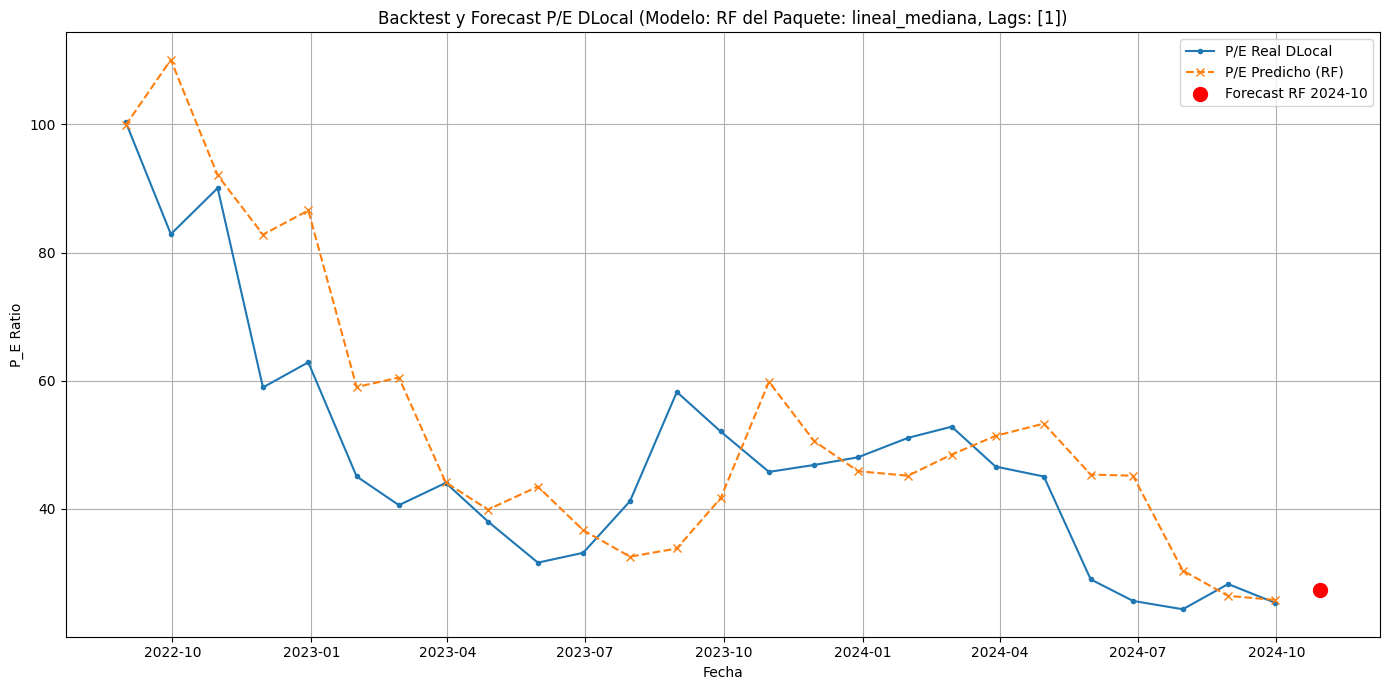


--- Procesando Modelo Tipo: XGB ---
  Features esperadas por XGB (del paquete o inferidas): 18 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1']...
  Métricas Backtest (XGB): RMSE=14.0165, MAE=10.7636, R2=0.4495


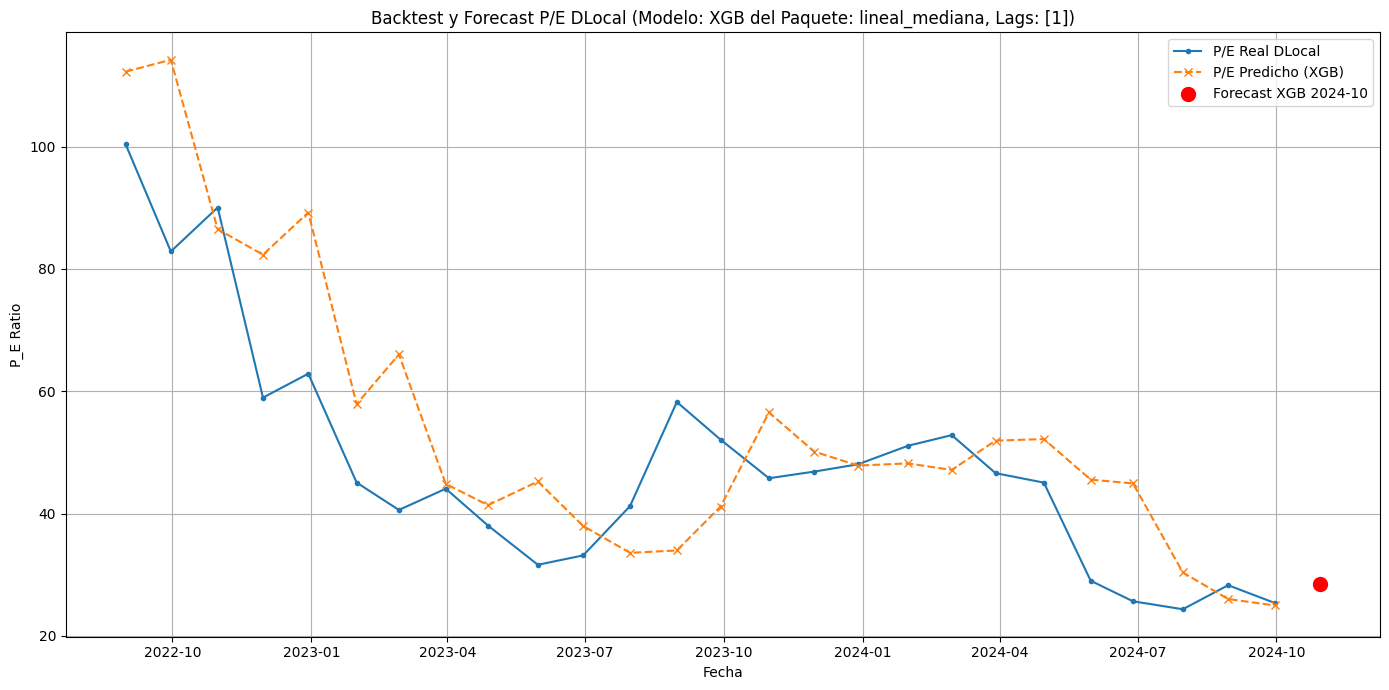


--- Procesando Modelo Tipo: LGBM ---
  Features esperadas por LGBM (del paquete o inferidas): 18 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1']...
  Métricas Backtest (LGBM): RMSE=14.1846, MAE=10.5266, R2=0.4362


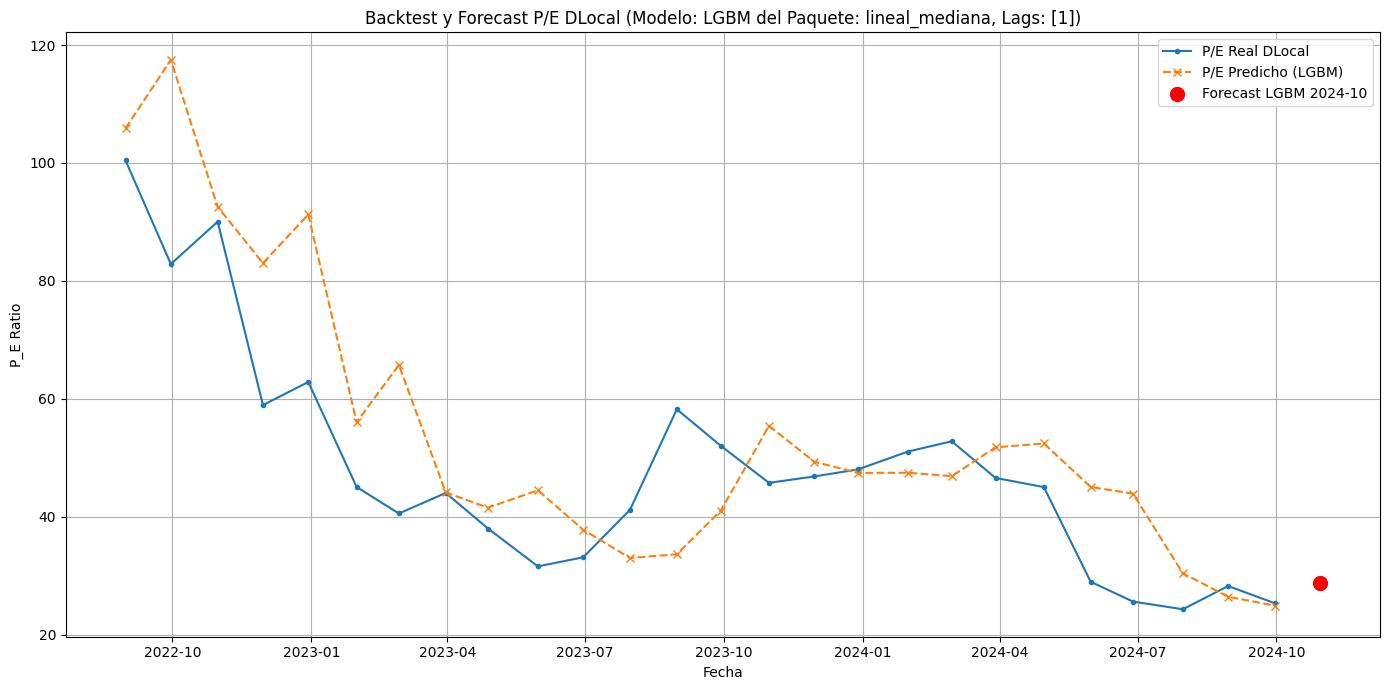


--- Procesando Modelo Tipo: CB ---
  Features esperadas por CB (del paquete o inferidas): 18 ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1']...
  Métricas Backtest (CB): RMSE=12.5926, MAE=9.5471, R2=0.5556


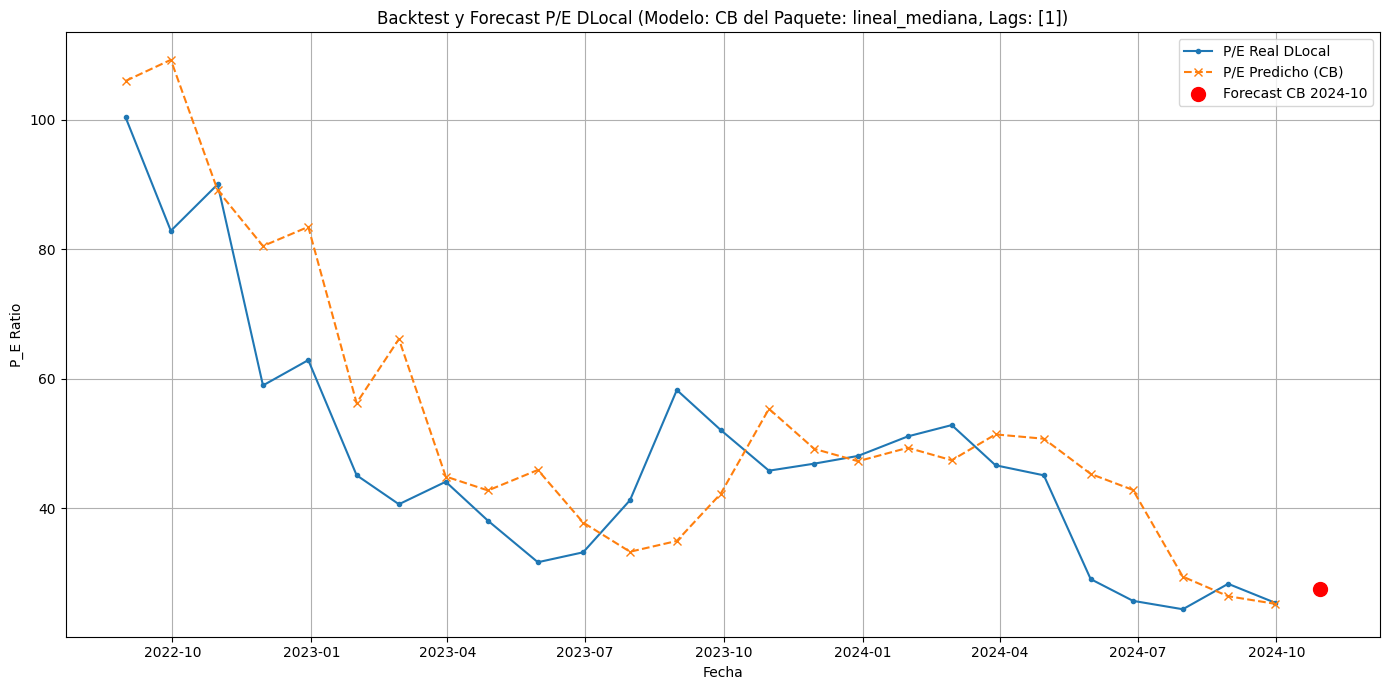


Resumen de Métricas Individuales de los Modelos en el Backtest de DLocal
Modelo_Tipo    RMSE     MAE     R2
         CB 12.5926  9.5471 0.5556
         RF 13.0814  9.9762 0.5205
        XGB 14.0165 10.7636 0.4495
       LGBM 14.1846 10.5266 0.4362

Proceso de predicción para DLocal completado.


In [49]:
# =====================================================================================
# BLOQUE DE PREDICCIÓN PARA DLOCAL (MODELOS INDIVIDUALES - GRÁFICOS Y MÉTRICAS)
# =====================================================================================

# --- 0. CONFIGURACIÓN Y CARGA DEL PAQUETE DEL MODELO ---
# ASUME: df_dlocal está cargado.
#        listas_columnas está definida (si es necesaria como fallback para columnas_base_paquete).
#        El paquete fue entrenado incluyendo P_E_lagN como feature si se desea usar aquí.

nombre_paquete_a_cargar = "paquete_mejores_por_tipo_lineal_mediana__lag1_con_DropColumns.joblib"

print(f"Cargando paquete de modelos desde: {nombre_paquete_a_cargar}")
model_package = None
try:
    ruta_paquete = os.path.join(os.getcwd(), nombre_paquete_a_cargar)
    if not os.path.exists(ruta_paquete):
        raise FileNotFoundError(f"El archivo del paquete '{ruta_paquete}' no existe.")
    model_package = joblib.load(ruta_paquete)
    print("Paquete de modelos cargado exitosamente.")

    required_keys = ['metodo_features', 'lag_config_usada', 'log_transform_target', 'mejores_modelos_info_por_tipo']
    if not isinstance(model_package, dict) or not all(key in model_package for key in required_keys):
        raise ValueError("El archivo cargado no es un paquete de modelos válido o le faltan claves esenciales.")

    metodo_features_paquete = model_package['metodo_features']
    lag_config_paquete = model_package['lag_config_usada'] 
    log_transform_paquete = model_package['log_transform_target']
    columnas_base_paquete = model_package.get('columnas_base_para_lags') # Esta clave debe existir en tu paquete
    mejores_modelos_info = model_package['mejores_modelos_info_por_tipo']

    if not columnas_base_paquete: # Fallback si no está en el paquete
        print("ADVERTENCIA: 'columnas_base_para_lags' no encontrada en el paquete. Intentando usar 'listas_columnas'.")
        if 'listas_columnas' in locals() and metodo_features_paquete in listas_columnas:
            columnas_base_paquete = listas_columnas[metodo_features_paquete]
            # Si P_E_lagN se usó y 'P_E' no está en listas_columnas[metodo_features_paquete], hay que añadirlo:
            # Esta lógica asume que si P_E_lagN es una feature, 'P_E' debe estar en las bases para generar ese lag.
            # El paquete idealmente ya tendría 'P_E' en 'columnas_base_para_lags' si P_E_lagN fue usado.
            # Si el paquete es de "solo lags de P/E", columnas_base_paquete debería ser ['P_E'].
            if 'P_E' not in columnas_base_paquete and any(f.startswith("P_E_lag") for f_dict in mejores_modelos_info.values() if f_dict and 'features_usadas_por_modelo' in f_dict for f in f_dict['features_usadas_por_modelo']):
                 if 'P_E' in df_dlocal.columns:
                    print("Añadiendo 'P_E' a columnas_base_paquete para generar su lag, basado en features de modelos.")
                    columnas_base_paquete.append('P_E')
                    columnas_base_paquete = sorted(list(set(columnas_base_paquete)))
        else: 
            raise ValueError("No se pudieron determinar las 'columnas_base_para_lags' ni del paquete ni de 'listas_columnas'.")
    
    print(f"  Información del Paquete: Método={metodo_features_paquete}, LagConfig={lag_config_paquete}, LogT={log_transform_paquete}")
    print(f"    Columnas Base (usadas para generar lags): {len(columnas_base_paquete)} {columnas_base_paquete[:5]}...")
    if 'P_E' in columnas_base_paquete:
        print("    'P_E' está en columnas_base_paquete; se generará P_E_lagN si lag_config lo indica.")
    else:
        print("    ADVERTENCIA: 'P_E' NO está en columnas_base_paquete. NO se generará P_E_lagN como feature para DLocal, a menos que lag_config_paquete lo fuerce.")

except FileNotFoundError: raise FileNotFoundError(f"ERROR FATAL: No se encontró el archivo del paquete '{nombre_paquete_a_cargar}'.")
except Exception as e_load_pack: raise RuntimeError(f"Error fatal al cargar o procesar el paquete: {e_load_pack}")

if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
     raise NameError("'df_dlocal' no definido o vacío.")

# Determinar qué lags generar para DLocal basado en lag_config_paquete
lags_a_generar_dlocal = []
temp_lag_str_cfg = str(lag_config_paquete).lower()
temp_lag_str_cfg = temp_lag_str_cfg.replace('pe_lags_', '').replace('_solo_pred', '').replace('lags_', '').replace('lag', '')
found_numbers_cfg = re.findall(r'\d+', temp_lag_str_cfg)
if found_numbers_cfg:
    lags_a_generar_dlocal = sorted(list(set(int(num) for num in found_numbers_cfg)))
if not lags_a_generar_dlocal: # Fallback
    for i in range(1, 7): 
        if f"lag{i}" in str(lag_config_paquete).lower() or f"_{i}" in str(lag_config_paquete): 
            lags_a_generar_dlocal.append(i)
    lags_a_generar_dlocal = sorted(list(set(lags_a_generar_dlocal)))
if not lags_a_generar_dlocal:
    raise ValueError(f"No se pudo determinar qué lags numéricos generar a partir de lag_config_paquete: '{lag_config_paquete}'")
print(f"Se generarán lags {lags_a_generar_dlocal} para DLocal.")


# --- 1. PREPARAR df_dlocal ---
print("\n" + "="*80 + f"\nPreparando datos de DLocal (Método: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})" + "\n" + "="*80)
df_dlocal_procesado_base = df_dlocal.copy()

# 1.1 Conversión Numérica
# Usar 'columnas_base_paquete' que ahora debería incluir 'P_E' si P_E_lagN es una feature.
cols_convertir_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
for col in cols_convertir_dlocal:
    if not pd.api.types.is_numeric_dtype(df_dlocal_procesado_base[col]):
        df_dlocal_procesado_base[col] = pd.to_numeric(df_dlocal_procesado_base[col], errors='coerce')

# 1.2 Imputación Pre-Lag
cols_imputar_dlocal = [col for col in columnas_base_paquete if col in df_dlocal_procesado_base.columns and col not in ['Empresa', 'Fecha']]
if cols_imputar_dlocal:
    df_dlocal_procesado_base.sort_values(['Empresa', 'Fecha'], inplace=True)
    if df_dlocal_procesado_base['Empresa'].nunique() > 1:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base.groupby('Empresa')[cols_imputar_dlocal].ffill()
    else:
        df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].ffill()
    df_dlocal_procesado_base[cols_imputar_dlocal] = df_dlocal_procesado_base[cols_imputar_dlocal].fillna(0)

# 1.3 Generar Lags
# 'features_para_generar_lags_dlocal' se basa en 'columnas_base_paquete'
features_para_generar_lags_dlocal = [c for c in columnas_base_paquete if c in df_dlocal_procesado_base.columns]
# Asegurar que P_E esté si se espera P_E_lagN y no está ya en features_para_generar_lags_dlocal
# (Esta lógica es un poco redundante si columnas_base_paquete ya es correcta)
if any(f"P_E_lag{lg}" in model_info_actual.get('features_usadas_por_modelo',[]) for lg in lags_a_generar_dlocal for model_info_actual in mejores_modelos_info.values() if model_info_actual) \
   and 'P_E' not in features_para_generar_lags_dlocal and 'P_E' in df_dlocal_procesado_base.columns:
    print("  Asegurando que 'P_E' se incluya para generar sus lags para DLocal.")
    features_para_generar_lags_dlocal.append('P_E')
    features_para_generar_lags_dlocal = sorted(list(set(features_para_generar_lags_dlocal)))


cols_necesarias_para_base_df = ['Empresa', 'Fecha']
if 'P_E' in df_dlocal_procesado_base.columns: cols_necesarias_para_base_df.append('P_E')
for f_lag in features_para_generar_lags_dlocal:
    if f_lag not in cols_necesarias_para_base_df: cols_necesarias_para_base_df.append(f_lag)

df_dlocal_con_todos_lags = df_dlocal_procesado_base[cols_necesarias_para_base_df].copy()
all_generated_lag_cols_dlocal = []

print(f"Generando lags para DLocal para las features: {features_para_generar_lags_dlocal}")
for lag_val in lags_a_generar_dlocal:
    for col_base_para_lag in features_para_generar_lags_dlocal:
        lag_col_name = f"{col_base_para_lag}_lag{lag_val}"
        df_dlocal_con_todos_lags[lag_col_name] = df_dlocal_con_todos_lags.groupby('Empresa')[col_base_para_lag].shift(lag_val)
        all_generated_lag_cols_dlocal.append(lag_col_name)
all_generated_lag_cols_dlocal = sorted(list(set(all_generated_lag_cols_dlocal)))
print(f"Se generaron {len(all_generated_lag_cols_dlocal)} columnas de lag para DLocal: {all_generated_lag_cols_dlocal[:5]}...")
# Confirmación de P_E_lagN
pe_lags_actually_generated = [col for col in all_generated_lag_cols_dlocal if col.startswith("P_E_lag")]
if pe_lags_actually_generated:
    print(f"    ¡Confirmado! Lags de P/E generados: {pe_lags_actually_generated}")
else:
    print("    ADVERTENCIA: NO se generaron lags de P/E para DLocal. Verifica 'columnas_base_paquete' y la lógica de generación de lags.")

# 1.4 Aplicar dropna
df_dlocal_final_features_con_ids = df_dlocal_con_todos_lags.dropna(subset=all_generated_lag_cols_dlocal).copy()
if df_dlocal_final_features_con_ids.empty: raise ValueError("DLocal vacío post lags y dropna.")
print(f"DataFrame DLocal procesado y listo (con IDs y lags): {df_dlocal_final_features_con_ids.shape}")

# --- 2. ITERAR, PREDECIR, EVALUAR INDIVIDUALMENTE Y GRAFICAR ---
print("\n" + "="*80 + "\nIterando sobre modelos por tipo para predicción, evaluación y graficación individual en DLocal" + "\n" + "="*80)
lista_metricas_individuales_dlocal = []

for tipo_modelo_actual, model_info_actual in mejores_modelos_info.items():
    print(f"\n--- Procesando Modelo Tipo: {tipo_modelo_actual} ---")

    if model_info_actual is None or 'pipeline_object' not in model_info_actual or model_info_actual['pipeline_object'] is None:
        print(f"  No hay un pipeline válido para '{tipo_modelo_actual}'. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    pipeline_cargado_actual = model_info_actual['pipeline_object']
    estimador_real_actual = pipeline_cargado_actual
    if hasattr(pipeline_cargado_actual, 'steps'): estimador_real_actual = pipeline_cargado_actual.steps[-1][1]
    
    # Obtener las features que este modelo específico espera (guardadas en el paquete)
    features_esperadas_por_modelo_actual = model_info_actual.get('features_usadas_por_modelo', [])
    
    if not features_esperadas_por_modelo_actual: # Fallback si no se guardaron en el paquete
        print(f"  ADVERTENCIA para {tipo_modelo_actual}: 'features_usadas_por_modelo' no encontrada en el paquete. Intentando inferir...")
        if hasattr(estimador_real_actual, 'feature_names_in_'):
            features_esperadas_por_modelo_actual = list(estimador_real_actual.feature_names_in_)
        elif hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == len(all_generated_lag_cols_dlocal):
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        elif tipo_modelo_actual == 'CB' and hasattr(estimador_real_actual, 'n_features_in_') and estimador_real_actual.n_features_in_ == 0 and len(all_generated_lag_cols_dlocal) > 0:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal
        else:
            features_esperadas_por_modelo_actual = all_generated_lag_cols_dlocal # Último recurso
            print(f"    Usando todos los {len(all_generated_lag_cols_dlocal)} lags generados como fallback final.")

    if not features_esperadas_por_modelo_actual:
        print(f"  Error: Lista final de features esperadas vacía para {tipo_modelo_actual}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    print(f"  Features esperadas por {tipo_modelo_actual} (del paquete o inferidas): {len(features_esperadas_por_modelo_actual)} {features_esperadas_por_modelo_actual[:5]}...")

    missing_features_in_dlocal = [f for f in features_esperadas_por_modelo_actual if f not in df_dlocal_final_features_con_ids.columns]
    if missing_features_in_dlocal:
        print(f"  ERROR para {tipo_modelo_actual}: Faltan features en DLocal que el modelo espera: {missing_features_in_dlocal}. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
        
    X_dlocal_input_this_model = df_dlocal_final_features_con_ids[features_esperadas_por_modelo_actual].copy()
    df_dlocal_eval_data_this_model = df_dlocal_final_features_con_ids[['Fecha', 'P_E']].loc[X_dlocal_input_this_model.index].copy()
    
    if X_dlocal_input_this_model.empty:
        print(f"  Input para {tipo_modelo_actual} vacío. Omitiendo.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})
        continue
    
    n_rows_pred_this_model = len(X_dlocal_input_this_model); fechas_p_individual, preds_p_individual, reales_p_individual = [], [], []
    if n_rows_pred_this_model > 0:
        if n_rows_pred_this_model > 1: # Backtest
            for i in range(1, n_rows_pred_this_model):
                X_pred_row_loop = X_dlocal_input_this_model.iloc[[i-1]]
                try:
                    pred_raw_loop = pipeline_cargado_actual.predict(X_pred_row_loop)[0]
                    pred_orig_loop = np.expm1(pred_raw_loop) if log_transform_paquete else pred_raw_loop
                    if log_transform_paquete and not np.isfinite(pred_orig_loop): pred_orig_loop = np.nan
                except Exception as e_pred_loop:
                    pred_orig_loop = np.nan
                    print(f"    Error en backtest para {tipo_modelo_actual} (Fecha target: {df_dlocal_eval_data_this_model.iloc[i]['Fecha']}): {e_pred_loop}")
                preds_p_individual.append(pred_orig_loop)
                fechas_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['Fecha'])
                reales_p_individual.append(df_dlocal_eval_data_this_model.iloc[i]['P_E'])
        
        X_forecast_row_loop = X_dlocal_input_this_model.iloc[[-1]]; pronostico_final_individual = np.nan
        try:
            pred_raw_forecast_loop = pipeline_cargado_actual.predict(X_forecast_row_loop)[0]
            pronostico_final_individual = np.expm1(pred_raw_forecast_loop) if log_transform_paquete else pred_raw_forecast_loop
            if log_transform_paquete and not np.isfinite(pronostico_final_individual): pronostico_final_individual = np.nan
        except Exception as e_forecast_ind:
             print(f"    Error durante el forecast para {tipo_modelo_actual}: {e_forecast_ind}")
        
        proxima_fecha_individual = "Periodo Siguiente"
        if not df_dlocal_eval_data_this_model.empty and 'Fecha' in df_dlocal_eval_data_this_model.columns and not df_dlocal_eval_data_this_model['Fecha'].empty:
            try: proxima_fecha_individual = df_dlocal_eval_data_this_model['Fecha'].iloc[-1] + pd.DateOffset(months=1)
            except: pass
            
        df_backtest_individual = pd.DataFrame({'Fecha': fechas_p_individual, 'P_E_Predicho': preds_p_individual, 'P_E_Real': reales_p_individual})
        
        metricas_individual_actual = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
        if not df_backtest_individual.empty:
            metricas_individual_actual = evaluate_model(df_backtest_individual['P_E_Real'], df_backtest_individual['P_E_Predicho'])
            print(f"  Métricas Backtest ({tipo_modelo_actual}): RMSE={metricas_individual_actual['RMSE']:.4f}, MAE={metricas_individual_actual['MAE']:.4f}, R2={metricas_individual_actual['R2']:.4f}")
        
        metricas_a_guardar = metricas_individual_actual.copy()
        metricas_a_guardar['Modelo_Tipo'] = tipo_modelo_actual
        lista_metricas_individuales_dlocal.append(metricas_a_guardar)

        if not df_backtest_individual.empty:
            plt.figure(figsize=(14, 7))
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Real'], marker='.', linestyle='-', label='P/E Real DLocal')
            plt.plot(df_backtest_individual['Fecha'], df_backtest_individual['P_E_Predicho'], marker='x', linestyle='--', label=f'P/E Predicho ({tipo_modelo_actual})')
            if isinstance(proxima_fecha_individual, pd.Timestamp) and pd.notna(pronostico_final_individual):
                 plt.scatter([proxima_fecha_individual], [pronostico_final_individual], color='red', label=f'Forecast {tipo_modelo_actual} {proxima_fecha_individual.strftime("%Y-%m")}', zorder=5, s=100)
            plt.title(f'Backtest y Forecast P/E DLocal (Modelo: {tipo_modelo_actual} del Paquete: {metodo_features_paquete}, Lags: {lags_a_generar_dlocal})')
            plt.xlabel('Fecha'); plt.ylabel('P_E Ratio'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
    else:
        print(f"  No hay datos suficientes en DLocal procesado para hacer predicciones con {tipo_modelo_actual}.")
        lista_metricas_individuales_dlocal.append({'Modelo_Tipo': tipo_modelo_actual, 'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan})

# --- 3. IMPRIMIR TABLA DE MÉTRICAS INDIVIDUALES (AL FINAL) ---
if lista_metricas_individuales_dlocal:
    df_metricas_final_dlocal = pd.DataFrame(lista_metricas_individuales_dlocal)
    print("\n" + "="*80 + "\nResumen de Métricas Individuales de los Modelos en el Backtest de DLocal" + "\n" + "="*80)
    df_metricas_final_dlocal_sorted = df_metricas_final_dlocal.sort_values(by='RMSE', ascending=True)
    columnas_ordenadas_metricas = ['Modelo_Tipo', 'RMSE', 'MAE', 'R2']
    columnas_existentes_para_print = [col for col in columnas_ordenadas_metricas if col in df_metricas_final_dlocal_sorted.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000, 'display.float_format', '{:.4f}'.format):
        print(df_metricas_final_dlocal_sorted[columnas_existentes_para_print].to_string(index=False))
else:
    print("\nNo se generaron métricas para DLocal o la lista está vacía.")

print("\n" + "="*80 + "\nProceso de predicción para DLocal completado." + "\n" + "="*80)

Tiene sentido obtener resultados muy similares (o incluso idénticos) a cuando se hacía fillna(0) globalmente, bajo ciertas condiciones específicas.

Posibles Razones para Resultados Similares:

Pocos NaNs en other_cols después de ffill:

Si el ffill() dentro de cada grupo ya resuelve la gran mayoría de los NaNs en las other_cols, entonces los pasos posteriores (mediana de grupo, fillna(0) global) tendrían un impacto mínimo porque operarían sobre muy pocos valores.
Esto es más probable si tus series temporales por empresa son relativamente completas y los NaNs son esporádicos en lugar de bloques grandes al inicio de cada serie.
La Mediana del Grupo (g.median()) es Frecuentemente Cero o Cercana a Cero:
Para algunas de tus other_cols (ratios, magnitudes), si la mediana calculada dentro de cada grupo de empresa resulta ser cero (o muy cercana a cero), entonces el paso .transform(lambda g: g.fillna(g.median())) estaría, en efecto, rellenando con cero.

Esto podría ocurrir si:

Una empresa tiene muchos ceros reales en esa feature.

Una empresa tiene pocos valores no nulos y la mediana de esos pocos valores es cero.

Muchas Empresas con Historial Completamente Vacío para Ciertas other_cols:

Si para una other_col específica, una empresa tiene todos sus valores como NaN, entonces:

ffill() no hará nada para esa empresa/columna.

g.median() para esa empresa/columna será NaN.

g.fillna(g.median()) (que es g.fillna(NaN)) no cambiará los NaNs.

Finalmente, el df[other_cols] = df[other_cols].fillna(0) global rellenará esos NaNs persistentes con 0.

Si este es el caso para una proporción significativa de tus datos en other_cols, entonces el resultado final de la imputación para esas celdas seguirá siendo 0.

Las cols_zero_ok son las Dominantes o Más Importantes:

Si las columnas en cols_zero_ok (donde explícitamente imputas con 0) son las que tienen la mayor cantidad de NaNs iniciales o son las features más importantes para tus modelos, entonces el cambio en la estrategia de imputación para other_cols podría no tener un impacto tan grande en los resultados finales del modelo.

Las Banderas _was_na No Son Explotadas por los Modelos (o no son suficientemente informativas):

Aunque creas las columnas _was_na, no hay garantía de que los modelos de árbol las encuentren suficientemente útiles como para cambiar significativamente sus patrones de división en comparación con cuando el valor imputado era simplemente 0.

Si la ausencia de un dato no tiene una correlación fuerte con el target (después de considerar otras features), la bandera podría tener baja importancia.

Naturaleza de los Datos y el Modelo:

A veces, los modelos de árbol pueden ser sorprendentemente robustos a diferentes estrategias de imputación simples si la señal principal proviene de otras features o si los valores imputados no caen en puntos críticos de decisión para el árbol.

En resumen, es plausible obtener resultados similares si:

La cantidad de datos realmente afectados por la nueva lógica de imputación para other_cols es pequeña.

Las medianas de grupo para other_cols son a menudo cero.

El fillna(0) final sigue siendo el que rellena una cantidad significativa de NaNs en other_cols (porque las empresas tenían historiales completamente vacíos para esas features).

| Posible causa                                      | Qué revisar / por qué sucede                                                                                                                                                                                                                                     |
| -------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Las celdas que antes iban a 0 siguen yendo a 0** | Si después del `ffill()` todavía quedan *huecos* (por ejemplo, la primera fila de cada empresa), tu paso final `fillna(0)` los vuelve a poner en 0. En ese caso, con-o-sin forward-fill el resultado neto sobre esas observaciones es idéntico.                  |
| **La variable nunca entra en el modelo**           | · Podría quedar fuera por los filtros de NaNs, por `DropColumns`, por `feature_importances_` muy bajas, o porque la librería ignora columnas con varianza \~0. <br>· Comprueba qué *features* usa cada pipeline (`pipe.named_steps['model'].feature_names_in_`). |
| **El modelo no “siente” la diferencia**            | • Si la magnitud típica de la feature es grande (p.ej. millones) y solo cambias algunos ceros por el valor anterior, el bosque aleatorio puede considerarlo ruido. <br>• Con targets log-transformados los cambios pequeños en variables se amortiguan.          |
| **Escasez de valores faltantes**                   | Si el % de NaNs era bajo, estadísticamente el efecto en RMSE/MAE puede caer dentro de la variabilidad del hold-out.                                                                                                                                              |
| **Redondeo de métricas**                           | A veces vemos “lo mismo” porque redondeamos a 3-4 decimales. Mira la diferencia exacta (`abs(new_rmse - old_rmse)`).                                                                                                                                             |


In [50]:
   
# ================================================================================
# BLOQUE DE EXPERIMENTOS (REGRESIÓN CUANTÍLICA - FEATURES COMBINADAS, EARLY STOPPING)
# ================================================================================
results_accumulator_quantile = [] 
start_time_total_quantile_exp = time.time()
use_log_transform_experiment = True
test_size_ratio_experiment = 0.20
QUANTILES_ALPHA = [0.05, 0.5, 0.95] 
EARLY_STOPPING_ROUNDS = 30 # Para LGBM y CatBoost en GridSearchCV

# --- USAR el diccionario 'dfs_shifted' que contiene P_E_lagN y otros lags ---
# Este dfs_shifted debe ser el resultado del "Bloque 8 (Incluyendo P_E_lag1 como feature)"
# Placeholder for dfs_shifted for testing purposes
# dfs_shifted = {'Metodo1': pd.DataFrame({
#     'Empresa': ['A']*5 + ['B']*5 + ['C']*5, # Added more companies for GroupKFold
#     'Fecha': pd.to_datetime(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04', '2020-01-05'] * 3),
#     'P_E': np.random.rand(15) * 10 + 5,
#     'Feature1_lag1': np.random.rand(15),
#     'P_E_lag1': np.random.rand(15) * 10 + 5,
#     'Feature2_lag1': np.random.rand(15)
# })}
if 'dfs_shifted' not in locals() or not isinstance(dfs_shifted, dict) or not dfs_shifted:
    raise NameError("El diccionario 'dfs_shifted' (con P_E_lagN y otros lags) no está definido o está vacío.")

for metodo_features, df_original_with_lags in dfs_shifted.items(): # Iterar sobre los métodos de features
    start_time_config = time.time()
    
    temp_cols_for_lag_config = df_original_with_lags.columns.tolist()
    pe_lags_present = sorted([int(re.search(r'P_E_lag(\d+)', col).group(1)) for col in temp_cols_for_lag_config if re.search(r'P_E_lag(\d+)', col)])
    otros_lags_present = sorted(list(set([int(re.search(r'_lag(\d+)', col).group(1)) for col in temp_cols_for_lag_config if not col.startswith('P_E_') and re.search(r'_lag(\d+)', col)])))
    lag_config_display = f"P_E_lags{pe_lags_present}_Otros_lags{otros_lags_present}"

    print("\n" + "="*80)
    print(f"Procesando Método Features: {metodo_features} (Regresión Cuantílica) {'(CON Log Transform)' if use_log_transform_experiment else '(SIN Log Transform)'}")
    print(f"  Configuración de Lags: {lag_config_display}")
    print(f"  Cuantiles a predecir: {QUANTILES_ALPHA}")
    print("="*80 + "\n")

    if df_original_with_lags.empty: continue

    df_current_method_processed = df_original_with_lags.copy()
    if 'time_step' not in df_current_method_processed.columns:
        df_current_method_processed.sort_values(['Empresa', 'Fecha'], inplace=True)
        df_current_method_processed['time_step'] = df_current_method_processed.groupby('Empresa').cumcount()

    predictor_cols_for_model = sorted([c for c in df_current_method_processed.columns if re.search(r'_lag\d+$', c)])
    if not predictor_cols_for_model: print(f"No se encontraron lags para {metodo_features}."); continue
    columnas_base_que_generaron_lags = sorted(list(set(re.sub(r'_lag\d+$', '', lag_col) for lag_col in predictor_cols_for_model)))
    
    cols_for_df_model_construction = ['Empresa', 'Fecha', 'time_step', 'P_E'] + predictor_cols_for_model
    final_cols_for_df_model_construction = sorted(list(set(c for c in cols_for_df_model_construction if c in df_current_method_processed.columns)))
    essential_cols_check = ['Empresa', 'Fecha', 'time_step', 'P_E']
    if not all(ec in final_cols_for_df_model_construction for ec in essential_cols_check): continue
    df_model_for_splitting = df_current_method_processed[final_cols_for_df_model_construction].copy()
    
    n_total_empresas = df_model_for_splitting['Empresa'].nunique()
    n_empresas_test = 0
    if n_total_empresas > 1:
        n_empresas_test = max(1, int(round(n_total_empresas * test_size_ratio_experiment)))
        if n_total_empresas - n_empresas_test < 1 : n_empresas_test = n_total_empresas - 1
    X_train_with_ids, y_train_original, X_test_with_ids, y_test_original = train_test_split_by_empresa(df_model_for_splitting, n_empresas_test)
    if X_train_with_ids is None or X_train_with_ids.empty: continue
    
    X_train_model_features = X_train_with_ids[predictor_cols_for_model].copy()
    X_test_model_features = pd.DataFrame(columns=predictor_cols_for_model)
    if X_test_with_ids is not None and not X_test_with_ids.empty: X_test_model_features = X_test_with_ids[predictor_cols_for_model].copy()
    
    y_train_transformed_target = y_train_original.copy()
    if use_log_transform_experiment:
        y_numeric = pd.to_numeric(y_train_original, errors='coerce'); median_y_train = y_numeric.median() if not y_numeric.isnull().all() else 0.0
        y_numeric = y_numeric.fillna(median_y_train); y_numeric.loc[y_numeric < 0] = 0; y_train_transformed_target = np.log1p(y_numeric)
        if y_train_transformed_target.isnull().any(): median_y_transformed = y_train_transformed_target.median() if not y_train_transformed_target.isnull().all() else 0.0; y_train_transformed_target = y_train_transformed_target.fillna(median_y_transformed)
    
    if not X_train_with_ids.index.equals(y_train_transformed_target.index):
        common_idx_train = X_train_with_ids.index.intersection(y_train_transformed_target.index)
        X_train_with_ids = X_train_with_ids.loc[common_idx_train]; X_train_model_features = X_train_model_features.loc[common_idx_train]
        y_train_transformed_target = y_train_transformed_target.loc[common_idx_train]
        if X_train_model_features.empty : continue
        
    X_train_cv_data_with_ids, y_train_cv_target = sort_by_timestep(X_train_with_ids, y_train_transformed_target)
    X_train_fit_data_features, y_train_fit_target = sort_by_timestep(X_train_model_features, y_train_transformed_target)
    X_test_eval_data_with_ids, y_test_eval_target_original = pd.DataFrame(), pd.Series(dtype=float)
    X_test_predict_data_features = pd.DataFrame()
    if X_test_with_ids is not None and not X_test_with_ids.empty:
        X_test_eval_data_with_ids, y_test_eval_target_original = sort_by_timestep(X_test_with_ids, y_test_original)
        X_test_predict_data_features, _ = sort_by_timestep(X_test_model_features, y_test_original)

    param_grid_lgbm_q = {'model__n_estimators':[500, 1000], 'model__learning_rate':[0.05, 0.03], 'model__num_leaves':[31, 63]}
    param_grid_cb_q   = {'model__iterations':[500, 1000], 'model__learning_rate':[0.05, 0.03], 'model__depth':[5, 7]}
    param_grid_rf_p   = {'model__n_estimators':[200, 500],'model__max_depth':[10, 20, None],'model__min_samples_split':[5, 10]}
    param_grid_xgb_p  = {'model__n_estimators':[200, 500],'model__max_depth':[5, 7, 9],'model__learning_rate':[0.05, 0.03]}

    scenarios_all = {
        'LGBM_Quantile_HP': {'model_class': LGBMRegressor, 'hp': True, 'grid_base': param_grid_lgbm_q, 'prefix': 'model', 'is_quantile': True},
        'CB_Quantile_HP':   {'model_class': CatBoostRegressor, 'hp': True, 'grid_base': param_grid_cb_q, 'prefix': 'model', 'is_quantile': True},
        'RF_Point_HP':      {'model_class': RandomForestRegressor, 'hp': True,  'grid_base': param_grid_rf_p,   'prefix': 'model', 'is_quantile': False},
        'XGB_Point_HP':     {'model_class': XGBRegressor, 'hp': True,  'grid_base': param_grid_xgb_p,  'prefix': 'model', 'is_quantile': False},
    }
    
    modelos_entrenados_para_paquete = {} 

    for escenario_nombre_base, escenario_cfg in scenarios_all.items():
        model_class = escenario_cfg['model_class']
        perform_hp_search = escenario_cfg['hp']
        model_prefix = escenario_cfg['prefix']
        
        X_fit_input = X_train_fit_data_features 
        y_fit_input = y_train_fit_target
        X_eval_input = X_test_predict_data_features 
        y_eval_target = y_test_eval_target_original
        
        X_for_cv_groups = X_train_cv_data_with_ids 
        current_model_actual_features = list(X_fit_input.columns)

        if escenario_cfg.get('is_quantile', True): 
            modelos_cuantil_del_escenario = {} 
            predictions_test_por_cuantil = {}
            for alpha_q in QUANTILES_ALPHA:
                esc_q_name = f"{escenario_nombre_base}_alpha{int(alpha_q*100)}"
                print(f"\n  --- Esc. Cuantílico: {esc_q_name} para {metodo_features} ---")
                
                # --- CORRECTED SECTION for model_params_q initialization ---
                model_params_q = {'random_state': 42} 
                
                if model_class == LGBMRegressor: 
                    model_params_q.update({'objective': 'quantile', 'alpha': alpha_q, 'verbosity': -1, 'n_jobs': -1})
                elif model_class == CatBoostRegressor: 
                    model_params_q.update({'loss_function': f'Quantile:alpha={alpha_q}', 'verbose': 0, 'allow_writing_files': False})
                    # CatBoostRegressor does not take 'n_jobs' in __init__
                else: 
                    # This case should ideally not be reached if scenarios_all is well-defined
                    # but as a safeguard, skip if model_class is unexpected for quantile.
                    print(f"Modelo {model_class.__name__} no configurado para regresión cuantílica en este script. Saltando.")
                    continue
                # --- END OF CORRECTED SECTION ---
                
                base_model_q = model_class(**model_params_q)
                pipeline_q = Pipeline([(model_prefix, base_model_q)]) 
                fitted_model_q, best_params_q, error_q = None, None, None
                
                current_perform_hp_search = perform_hp_search 

                try:
                    if current_perform_hp_search:
                        pinball_scorer_alpha = make_scorer(mean_pinball_loss, greater_is_better=False, alpha=alpha_q)
                        cv_obj, cv_params = None, {}
                        n_groups_cv = X_for_cv_groups['Empresa'].nunique() if 'Empresa' in X_for_cv_groups.columns else 0
                        can_cv = True
                        if n_groups_cv >= 2: # GroupKFold needs at least 2 groups
                            groups_gkf = X_for_cv_groups['Empresa']
                            # n_splits for GroupKFold must be <= number of groups.
                            n_s = min(3, n_groups_cv) 
                            n_s = max(2, n_s) # Ensure at least 2 splits if possible
                            if len(X_fit_input) < n_s : can_cv = False # Basic check for samples vs splits
                            else: cv_obj = GroupKFold(n_splits=n_s); cv_params = {'groups': groups_gkf}
                        elif len(X_fit_input) >= 4: # KFold needs at least n_splits samples, assume min 2 splits
                            n_s_kf = min(3, len(X_fit_input) // 2 if len(X_fit_input) // 2 >=2 else 2) # Try to make splits reasonable
                            n_s_kf = max(2, n_s_kf)
                            if len(X_fit_input) < n_s_kf: can_cv = False
                            else: cv_obj = KFold(n_splits=n_s_kf, shuffle=True, random_state=42)
                        else: can_cv = False
                        
                        if not can_cv or cv_obj is None: current_perform_hp_search = False

                        if current_perform_hp_search:
                            gs_q = GridSearchCV(pipeline_q, escenario_cfg['grid_base'], scoring=pinball_scorer_alpha, cv=cv_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                            gs_q.fit(X_fit_input, y_fit_input, **cv_params) 
                            fitted_model_q, best_params_q = gs_q.best_estimator_, gs_q.best_params_
                    
                    if not current_perform_hp_search or fitted_model_q is None: 
                        fit_model_instance = pipeline_q 
                        
                        if model_class in [LGBMRegressor, CatBoostRegressor]:
                            # Ensure enough samples for a validation split for early stopping
                            # Test size 0.2 means we need at least 5 samples for 1 validation sample.
                            if len(X_fit_input) >= 5: 
                                temp_X_train, temp_X_val, temp_y_train, temp_y_val = train_test_split(X_fit_input, y_fit_input, test_size=0.2, random_state=42)
                                fit_kwargs = {}
                                if model_class == LGBMRegressor: 
                                    fit_kwargs = {f'{model_prefix}__callbacks':[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)], 
                                                  f'{model_prefix}__eval_set':[(temp_X_val, temp_y_val)], 
                                                  f'{model_prefix}__eval_metric':'quantile'}
                                elif model_class == CatBoostRegressor: 
                                    fit_kwargs = {f'{model_prefix}__early_stopping_rounds':EARLY_STOPPING_ROUNDS, 
                                                  f'{model_prefix}__eval_set':[(temp_X_val, temp_y_val)]}
                                fit_model_instance.fit(temp_X_train, temp_y_train, **fit_kwargs)
                            else: # Not enough data for split, fit on all data without early stopping via eval_set
                                print(f"  Not enough samples ({len(X_fit_input)}) for early stopping split in {esc_q_name}. Fitting on all train data.")
                                fit_model_instance.fit(X_fit_input, y_fit_input)
                        else: 
                            fit_model_instance.fit(X_fit_input, y_fit_input)
                        fitted_model_q = fit_model_instance
                        best_params_q = None 
                except Exception as e: error_q = str(e); print(f"ERROR {esc_q_name}: {e}")
                
                modelos_cuantil_del_escenario[alpha_q] = fitted_model_q 
                if fitted_model_q and not X_eval_input.empty:
                    pred_trans_q = fitted_model_q.predict(X_eval_input)
                    pred_orig_q = np.expm1(pred_trans_q) if use_log_transform_experiment else pred_trans_q
                    if use_log_transform_experiment: pred_orig_q[~np.isfinite(pred_orig_q)] = np.nan
                    predictions_test_por_cuantil[alpha_q] = pred_orig_q
                else: predictions_test_por_cuantil[alpha_q] = np.full(len(y_eval_target) if not y_eval_target.empty else 0, np.nan)
                
                results_accumulator_quantile.append({
                    'Modelo': escenario_nombre_base.split('_')[0], 'Cuantil_Alpha': alpha_q,
                    'Busqueda_HP': escenario_cfg['hp'] and current_perform_hp_search, 
                    'Config_Key': metodo_features, 'Metodo': metodo_features, 
                    'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 
                    'Pinball_Loss_Test': mean_pinball_loss(y_eval_target, predictions_test_por_cuantil[alpha_q], alpha=alpha_q) if not y_eval_target.empty and pd.Series(predictions_test_por_cuantil[alpha_q]).notna().any() else np.nan,
                    'Best_Params': best_params_q, 'pipeline': fitted_model_q, 
                    'columnas_base_usadas': columnas_base_que_generaron_lags, 
                    'n_features_modelo': getattr(fitted_model_q.steps[-1][1] if hasattr(fitted_model_q, 'steps') else fitted_model_q, 'n_features_in_', "N/A") if fitted_model_q else "N/A", 
                    'features_usadas_por_modelo': current_model_actual_features, 'Error': error_q
                })

            if QUANTILES_ALPHA[0] in predictions_test_por_cuantil and QUANTILES_ALPHA[-1] in predictions_test_por_cuantil and not y_eval_target.empty:
                pass 
            modelos_entrenados_para_paquete[escenario_nombre_base.replace('_HP','')] = modelos_cuantil_del_escenario
        
        else: # Escenario de regresión puntual (RF o XGB)
            # For point regressors (RF, XGB), n_jobs is fine as they support it.
            point_model_init_args = {'random_state': 42, 'n_jobs': -1}
            base_point_model_instance = model_class(**point_model_init_args)
            pipeline_for_training = Pipeline([(model_prefix, base_point_model_instance)])
            
            final_fitted_model_object, hp_best_params_found, error_msg_escenario = None, None, None
            current_perform_hp_search_pt = perform_hp_search 

            try:
                if current_perform_hp_search_pt:
                    cv_strategy_obj, cv_fit_params_dict, can_perform_cv = None, {}, True
                    n_groups_cv_point = X_for_cv_groups['Empresa'].nunique() if 'Empresa' in X_for_cv_groups.columns else 0
                    if n_groups_cv_point >= 2:
                        groups_for_cv_point = X_for_cv_groups['Empresa']
                        n_s_gkf = min(3, n_groups_cv_point); n_s_gkf = max(2, n_s_gkf)
                        if len(X_fit_input) < n_s_gkf: can_perform_cv = False
                        else: cv_strategy_obj = GroupKFold(n_splits=n_s_gkf); cv_fit_params_dict = {'groups': groups_for_cv_point}
                    elif len(X_fit_input) >= 4:
                        n_s_kf_pt = min(3, len(X_fit_input) // 2 if len(X_fit_input) // 2 >=2 else 2)
                        n_s_kf_pt = max(2, n_s_kf_pt)
                        if len(X_fit_input) < n_s_kf_pt: can_perform_cv = False
                        else: cv_strategy_obj = KFold(n_splits=n_s_kf_pt, shuffle=True, random_state=42)
                    else: can_perform_cv = False

                    if not can_perform_cv or cv_strategy_obj is None: current_perform_hp_search_pt = False
                    
                    if current_perform_hp_search_pt:
                        gs = GridSearchCV(pipeline_for_training, escenario_cfg['grid_base'], scoring=rmse_scorer, cv=cv_strategy_obj, n_jobs=-1, refit=True, error_score='raise', verbose=0)
                        gs.fit(X_fit_input, y_fit_input, **cv_fit_params_dict)
                        final_fitted_model_object, hp_best_params_found = gs.best_estimator_, gs.best_params_

                if not current_perform_hp_search_pt or final_fitted_model_object is None:
                    fit_model_instance_pt = pipeline_for_training 
                    
                    can_do_early_stopping_split_pt = len(X_fit_input) >= 5

                    if model_class == XGBRegressor and can_do_early_stopping_split_pt:
                        temp_X_train_pt, temp_X_val_pt, temp_y_train_pt, temp_y_val_pt = train_test_split(
                            X_fit_input, y_fit_input, test_size=0.2, random_state=42
                        )
                        fit_kwargs_pt = {
                            f'{model_prefix}__early_stopping_rounds': EARLY_STOPPING_ROUNDS,
                            f'{model_prefix}__eval_set': [(temp_X_val_pt, temp_y_val_pt)],
                        }
                        # XGBoost default eval_metric for regression is rmse, so explicit not always needed
                        # but can be added: f'{model_prefix}__eval_metric': 'rmse'
                        fit_model_instance_pt.fit(temp_X_train_pt, temp_y_train_pt, **fit_kwargs_pt)
                    else: 
                        if model_class == XGBRegressor and not can_do_early_stopping_split_pt:
                             print(f"  Not enough samples ({len(X_fit_input)}) for early stopping split in {escenario_nombre_base}. Fitting on all train data.")
                        fit_model_instance_pt.fit(X_fit_input, y_fit_input)
                    
                    final_fitted_model_object = fit_model_instance_pt
                    hp_best_params_found = None
            except Exception as e: error_msg_escenario = str(e); print(f"ERROR {escenario_nombre_base}: {e}")
            
            eval_metrics_dict = {'RMSE': np.nan, 'MAE': np.nan, 'R2': np.nan}
            if final_fitted_model_object and not X_eval_input.empty and not y_eval_target.empty:
                pred_transformed_eval = final_fitted_model_object.predict(X_eval_input)
                pred_original_scale_eval = np.expm1(pred_transformed_eval) if use_log_transform_experiment else pred_transformed_eval
                if use_log_transform_experiment: pred_original_scale_eval[~np.isfinite(pred_original_scale_eval)] = np.nan
                eval_metrics_dict = evaluate_model(y_eval_target, pred_original_scale_eval)
            
            results_accumulator_quantile.append({
                'Modelo': escenario_nombre_base.split('_')[0], 'Cuantil_Alpha': 'Puntual',
                'Busqueda_HP': escenario_cfg['hp'] and current_perform_hp_search_pt, 
                'Config_Key': metodo_features, 'Metodo': metodo_features, 
                'Lag_Config': lag_config_display, 'Log_Transform': use_log_transform_experiment, 
                'RMSE': eval_metrics_dict['RMSE'], 'MAE': eval_metrics_dict['MAE'], 'R2': eval_metrics_dict['R2'], 
                'Best_Params': hp_best_params_found, 'pipeline': final_fitted_model_object, 
                'columnas_base_usadas': columnas_base_que_generaron_lags, 
                'n_features_modelo': getattr(final_fitted_model_object.steps[-1][1] if hasattr(final_fitted_model_object, 'steps') else final_fitted_model_object, 'n_features_in_', "N/A") if final_fitted_model_object else "N/A", 
                'features_usadas_por_modelo': current_model_actual_features, 'Error': error_msg_escenario 
            })
            modelos_entrenados_para_paquete[escenario_nombre_base.replace('_HP','')] = final_fitted_model_object

    if modelos_entrenados_para_paquete:
        paquete_final_a_guardar = {
            'metodo_features': metodo_features, 
            'lag_config_usada': lag_config_display, 
            'log_transform_target': use_log_transform_experiment,
            'columnas_base_para_lags': columnas_base_que_generaron_lags, 
            'features_usadas_en_entrenamiento': predictor_cols_for_model,
            'modelos_por_tipo_y_cuantil_o_puntual': modelos_entrenados_para_paquete
        }
        nombre_archivo_paquete_final = f"paquete_cuantil_{metodo_features.replace(' ', '_')}_{lag_config_display.replace(' ', '_')}.joblib" 
        try:
            joblib.dump(paquete_final_a_guardar, nombre_archivo_paquete_final)
            print(f"\nPaquete para '{metodo_features}' ({lag_config_display}) guardado como: {nombre_archivo_paquete_final}") 
        except Exception as e_dump_final_package:
            print(f"\nERROR al guardar el paquete final para '{metodo_features}': {e_dump_final_package}") 
    else:
        print(f"\nNo se entrenaron modelos válidos para '{metodo_features}'. No se guardó paquete.") 

if results_accumulator_quantile:
    df_results_quantile_exp_final = pd.DataFrame(results_accumulator_quantile)
    print("\n" + "="*80 + "\n--- Resultados Finales (Regresión Cuantílica y Puntual) ---\n")
    cols_q_display = ['Metodo', 'Modelo', 'Cuantil_Alpha', 'Busqueda_HP', 'RMSE', 'MAE', 'R2', 'Pinball_Loss_Test', 'Best_Params', 'Error']
    cols_q_exist = [c for c in cols_q_display if c in df_results_quantile_exp_final.columns]
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 2000, 'display.float_format', '{:.4f}'.format):
        print(df_results_quantile_exp_final.sort_values(by=['Metodo', 'Modelo', 'Cuantil_Alpha', 'RMSE', 'Pinball_Loss_Test'],key=lambda x: x.astype(str) if x.name == 'Cuantil_Alpha' else x)[cols_q_exist].to_string(index=False))
else:
    print("\nNo se generaron resultados en los experimentos cuantílicos.")


Procesando Método Features: lineal_mediana (Regresión Cuantílica) (CON Log Transform)
  Configuración de Lags: P_E_lags[1]_Otros_lags[1]
  Cuantiles a predecir: [0.05, 0.5, 0.95]


  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha5 para lineal_mediana ---

  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha50 para lineal_mediana ---

  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha95 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha5 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha50 para lineal_mediana ---

  --- Esc. Cuantílico: CB_Quantile_HP_alpha95 para lineal_mediana ---

Paquete para 'lineal_mediana' (P_E_lags[1]_Otros_lags[1]) guardado como: paquete_cuantil_lineal_mediana_P_E_lags[1]_Otros_lags[1].joblib

Procesando Método Features: spline_mediana (Regresión Cuantílica) (CON Log Transform)
  Configuración de Lags: P_E_lags[1]_Otros_lags[1]
  Cuantiles a predecir: [0.05, 0.5, 0.95]


  --- Esc. Cuantílico: LGBM_Quantile_HP_alpha5 para spline_mediana --

Usando el paquete: paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib
INFO: Usando la variable 'df_dlocal' existente para los datos históricos de DLocal.
Paquete 'paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib' cargado exitosamente.

--- Backtesting A Un Paso para DLocal ---

Métricas de Backtesting A Un Paso para DLocal:
  Puntos evaluados: 27
  Cobertura (5%-95%): 81.48%
  Anchura Media Intervalo: 18.32
  Pinball Loss Media Intervalo: 1.1314
  RMSE Mediana (Q50): 9.38
  MAE Mediana (Q50): 6.57
  Pinball Loss Mediana (Q50): 3.2845

--- Forecast A Un Paso para DLocal ---
Predicción para 2024-10-30: Q5: 22.41, Q50: 28.51, Q95: 32.53


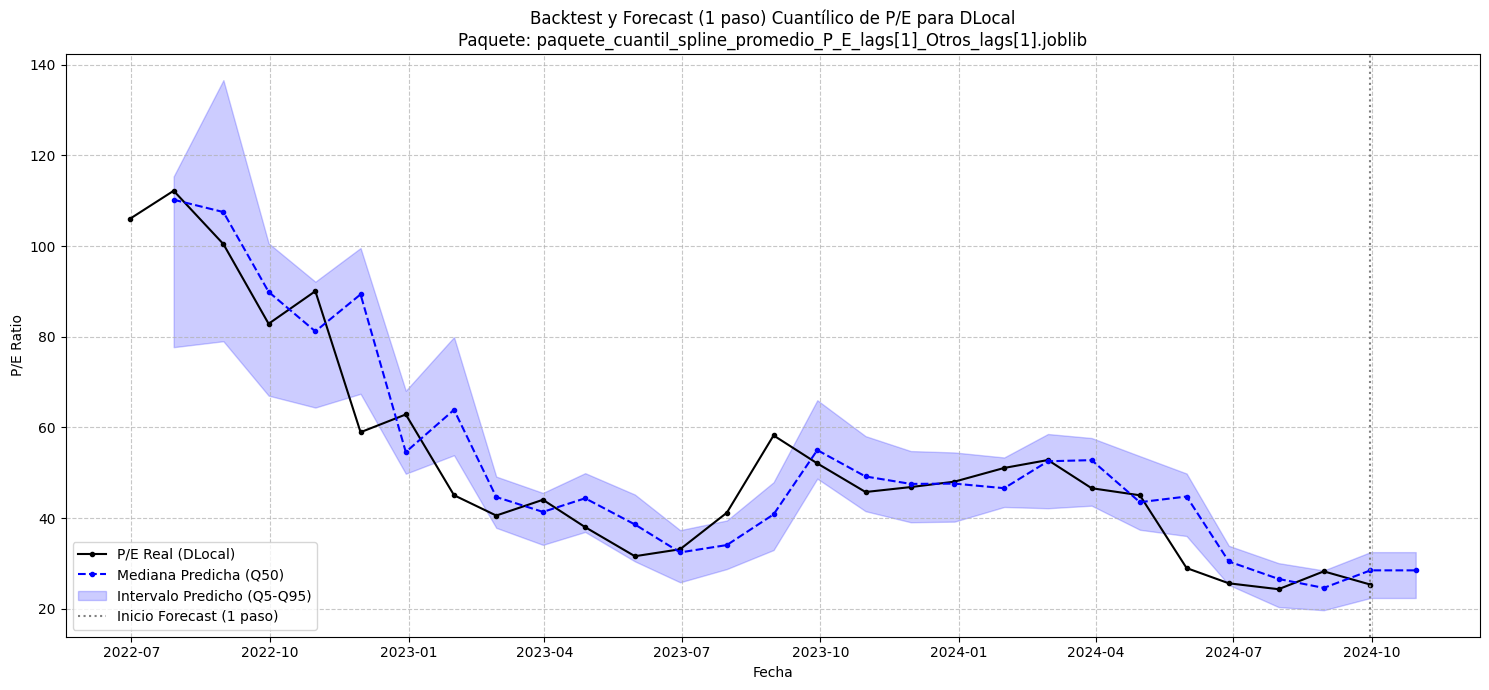


Forecast A Un Paso para DLocal:
       Fecha  P_E_pred_q5  P_E_pred_q50  P_E_pred_q95  P_E
0 2024-10-30    22.412392     28.506195     32.525736  NaN


In [51]:
# ================================================================================
# BLOQUE DE BACKTESTING "A UN PASO" Y FORECAST "A UN PASO" CUANTÍLICO PARA DLOCAL
# ================================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import re
import warnings
from sklearn.metrics import mean_pinball_loss, mean_squared_error # Para métricas de backtesting

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- Configuración para la Predicción ---
EMPRESA_A_PREDECIR = "DLocal"
# N_FUTURE_STEPS ya no se usa para un forecast a un solo paso, pero lo dejamos por si se quiere cambiar
# N_FUTURE_STEPS_FORECAST = 1 # <--- CAMBIO CLAVE: Solo 1 paso para el forecast
QUANTILES_PREDICCION = [0.05, 0.5, 0.95]
ALPHA_LOWER_INTERVAL = QUANTILES_PREDICCION[0]
ALPHA_UPPER_INTERVAL = QUANTILES_PREDICCION[-1]
ALPHA_MEDIAN = QUANTILES_PREDICCION[len(QUANTILES_PREDICCION)//2]


# !!! NOMBRE DEL PAQUETE DE MODELOS ENTRENADOS !!!
NOMBRE_PAQUETE_MODELOS = "paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib"
print(f"Usando el paquete: {NOMBRE_PAQUETE_MODELOS}")

# --- ASEGÚRATE DE QUE 'df_dlocal' ESTÉ DEFINIDO ANTES DE ESTE BLOQUE ---
if 'df_dlocal' not in locals() or not isinstance(df_dlocal, pd.DataFrame) or df_dlocal.empty:
    print(f"ERROR CRÍTICO: La variable 'df_dlocal' no está definida, no es un DataFrame o está vacía.")
    raise SystemExit("'df_dlocal' no disponible o inválida.")
else:
    print(f"INFO: Usando la variable 'df_dlocal' existente para los datos históricos de {EMPRESA_A_PREDECIR}.")
    df_empresa_hist_original = df_dlocal.copy()

# --- Cargar el paquete de modelos ---
# ... (Sección de carga de paquete sin cambios) ...
try:
    paquete_cargado = joblib.load(NOMBRE_PAQUETE_MODELOS)
    print(f"Paquete '{NOMBRE_PAQUETE_MODELOS}' cargado exitosamente.")
except FileNotFoundError:
    print(f"ERROR CRÍTICO: Archivo del paquete '{NOMBRE_PAQUETE_MODELOS}' no encontrado.")
    raise SystemExit(f"Archivo del paquete no encontrado: {NOMBRE_PAQUETE_MODELOS}")
except Exception as e:
    print(f"ERROR CRÍTICO: No se pudo cargar el paquete '{NOMBRE_PAQUETE_MODELOS}'. Error: {e}")
    raise SystemExit(f"Error al cargar el paquete: {e}")

log_transform_usada = paquete_cargado.get('log_transform_target')
features_entrenamiento = paquete_cargado.get('features_usadas_en_entrenamiento')
modelos_paquete = paquete_cargado.get('modelos_por_tipo_y_cuantil_o_puntual')

if any(v is None for v in [log_transform_usada, features_entrenamiento, modelos_paquete]):
    print("ERROR CRÍTICO: Información esencial faltante en el paquete cargado.")
    raise SystemExit("Paquete inválido.")

modelo_cuantil_key_base = None
for key_iter in modelos_paquete.keys():
    if 'Quantile' in key_iter and isinstance(modelos_paquete[key_iter], dict):
        potential_quantile_models = modelos_paquete[key_iter]
        if all(q_alpha in potential_quantile_models for q_alpha in QUANTILES_PREDICCION):
            modelo_cuantil_key_base = key_iter
            break
if not modelo_cuantil_key_base:
    print(f"ERROR CRÍTICO: No se encontró clave de diccionario para modelos cuantílicos en el paquete.")
    raise SystemExit("Modelos cuantílicos no encontrados en paquete.")
modelos_cuantil_dict = modelos_paquete[modelo_cuantil_key_base]
for alpha_val in QUANTILES_PREDICCION:
    if alpha_val not in modelos_cuantil_dict or not hasattr(modelos_cuantil_dict[alpha_val], 'predict'):
        print(f"ERROR CRÍTICO: Modelo para cuantil {alpha_val} faltante o inválido.")
        raise SystemExit(f"Modelo para cuantil {alpha_val} faltante o inválido.")

# --- Preparar datos históricos de DLocal ---
# ... (Sección de preparación de df_empresa_hist y función crear_features_con_lags sin cambios) ...
df_empresa_hist = df_empresa_hist_original.copy()
if 'Fecha' not in df_empresa_hist.columns:
    print("ERROR CRÍTICO: 'Fecha' no en df_empresa_hist (derivado de df_dlocal).")
    raise SystemExit("'Fecha' faltante.")
try:
    df_empresa_hist['Fecha'] = pd.to_datetime(df_empresa_hist['Fecha'])
except Exception as e_date:
    print(f"ERROR CRÍTICO: No se pudo convertir 'Fecha' a datetime. Error: {e_date}")
    raise SystemExit("Error en formato de 'Fecha'.")
df_empresa_hist.sort_values(by='Fecha', ascending=True, inplace=True)
df_empresa_hist.reset_index(drop=True, inplace=True)

def crear_features_con_lags_para_prediccion(df_historico_empresa, features_modelo_espera, fecha_base_prediccion):
    input_features = {}
    df_hist_para_lags = df_historico_empresa[df_historico_empresa['Fecha'] <= fecha_base_prediccion].sort_values(by='Fecha', ascending=False)
    if df_hist_para_lags.empty:
        for feat in features_modelo_espera: input_features[feat] = np.nan
        return pd.Series(input_features, index=features_modelo_espera)
    for feature_lag_name in features_modelo_espera:
        match = re.match(r"(.+)_lag(\d+)", feature_lag_name)
        if match:
            base_col_name = match.group(1)
            lag_n = int(match.group(2))
            if base_col_name not in df_hist_para_lags.columns:
                input_features[feature_lag_name] = np.nan
                continue
            if lag_n < len(df_hist_para_lags): 
                input_features[feature_lag_name] = df_hist_para_lags[base_col_name].iloc[lag_n]
            else:
                input_features[feature_lag_name] = np.nan
        else: 
            if feature_lag_name in df_hist_para_lags.columns:
                 input_features[feature_lag_name] = df_hist_para_lags[feature_lag_name].iloc[0] 
            else:
                input_features[feature_lag_name] = np.nan
    return pd.Series(input_features, index=features_modelo_espera)

# --- 1. BACKTESTING "A UN PASO": GENERAR PREDICCIONES PARA EL PERÍODO HISTÓRICO ---
# ... (Esta sección se mantiene igual que en el bloque anterior para el backtesting) ...
print("\n--- Backtesting A Un Paso para DLocal ---")
historical_predictions_list = []
min_lag_required = 0
if features_entrenamiento: 
    for feat_name in features_entrenamiento:
        match_lag = re.search(r"_lag(\d+)", feat_name)
        if match_lag:
            min_lag_required = max(min_lag_required, int(match_lag.group(1)))
for index, row_hist in df_empresa_hist.iterrows():
    current_hist_fecha = row_hist['Fecha']
    p_e_real_hist = row_hist.get('P_E', np.nan)
    pred_row_hist = {'Fecha': current_hist_fecha, 'P_E_real': p_e_real_hist}
    for alpha_val in QUANTILES_PREDICCION: 
        pred_row_hist[f'P_E_pred_q{int(alpha_val*100)}'] = np.nan
    if index < min_lag_required: 
        historical_predictions_list.append(pred_row_hist)
        continue
    hist_input_features = crear_features_con_lags_para_prediccion(df_empresa_hist, features_entrenamiento, current_hist_fecha)
    if hist_input_features.isna().all():
        historical_predictions_list.append(pred_row_hist)
        continue
    input_df_hist_model = pd.DataFrame([hist_input_features], columns=features_entrenamiento)
    for alpha_val in QUANTILES_PREDICCION:
        model_cuantil_actual = modelos_cuantil_dict[alpha_val]
        try:
            pred_transformed_hist = model_cuantil_actual.predict(input_df_hist_model)[0]
            if pd.isna(pred_transformed_hist): pred_original_hist = np.nan
            elif log_transform_usada: pred_original_hist = np.expm1(pred_transformed_hist)
            else: pred_original_hist = pred_transformed_hist
            pred_row_hist[f'P_E_pred_q{int(alpha_val*100)}'] = np.nan_to_num(pred_original_hist) if not pd.isna(pred_original_hist) else np.nan
        except Exception: pass             
    historical_predictions_list.append(pred_row_hist)
df_historical_quantile_preds = pd.DataFrame(historical_predictions_list)

# Calcular Métricas de Backtesting
# ... (Sección de métricas de backtesting sin cambios) ...
df_backtest_eval = df_historical_quantile_preds.dropna(
    subset=['P_E_real', f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}', f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}']
)
if not df_backtest_eval.empty:
    y_true_backtest = df_backtest_eval['P_E_real']
    pred_lower_backtest = df_backtest_eval[f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}']
    pred_upper_backtest = df_backtest_eval[f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}']
    coverage = np.mean((y_true_backtest >= pred_lower_backtest) & (y_true_backtest <= pred_upper_backtest))
    mean_interval_width = np.mean(pred_upper_backtest - pred_lower_backtest)
    pinball_loss_lower = mean_pinball_loss(y_true_backtest, pred_lower_backtest, alpha=ALPHA_LOWER_INTERVAL)
    pinball_loss_upper = mean_pinball_loss(y_true_backtest, pred_upper_backtest, alpha=ALPHA_UPPER_INTERVAL)
    avg_pinball_loss_interval = (pinball_loss_lower + pinball_loss_upper) / 2
    print(f"\nMétricas de Backtesting A Un Paso para DLocal:")
    print(f"  Puntos evaluados: {len(df_backtest_eval)}")
    print(f"  Cobertura ({ALPHA_LOWER_INTERVAL*100:.0f}%-{ALPHA_UPPER_INTERVAL*100:.0f}%): {coverage:.2%}")
    print(f"  Anchura Media Intervalo: {mean_interval_width:.2f}")
    print(f"  Pinball Loss Media Intervalo: {avg_pinball_loss_interval:.4f}")
    median_pred_col_name = f'P_E_pred_q{int(ALPHA_MEDIAN*100)}'
    if median_pred_col_name in df_backtest_eval.columns:
        valid_median_mask = df_backtest_eval[median_pred_col_name].notna()
        y_true_for_median = y_true_backtest[valid_median_mask]
        pred_median_backtest = df_backtest_eval.loc[valid_median_mask, median_pred_col_name]
        if not pred_median_backtest.empty and not y_true_for_median.empty:
            rmse_median = np.sqrt(mean_squared_error(y_true_for_median, pred_median_backtest))
            from sklearn.metrics import mean_absolute_error as mae
            mae_median = mae(y_true_for_median, pred_median_backtest)
            pinball_loss_median = mean_pinball_loss(y_true_for_median, pred_median_backtest, alpha=ALPHA_MEDIAN)
            print(f"  RMSE Mediana (Q{int(ALPHA_MEDIAN*100)}): {rmse_median:.2f}")
            print(f"  MAE Mediana (Q{int(ALPHA_MEDIAN*100)}): {mae_median:.2f}")
            print(f"  Pinball Loss Mediana (Q{int(ALPHA_MEDIAN*100)}): {pinball_loss_median:.4f}")
else:
    print("\nNo hay datos para métricas de backtesting.")

# --- 2. FORECAST "A UN PASO": GENERAR PREDICCIÓN SOLO PARA EL SIGUIENTE MES ---
print("\n--- Forecast A Un Paso para DLocal ---")
last_known_row_dlocal = df_empresa_hist.iloc[-1:]
last_known_P_E_original = last_known_row_dlocal['P_E'].iloc[0]
last_known_fecha = pd.to_datetime(last_known_row_dlocal['Fecha'].iloc[0])

# Features para predecir el primer mes futuro
features_for_next_step_forecast = crear_features_con_lags_para_prediccion(
    df_empresa_hist, features_entrenamiento, last_known_fecha
)

single_future_prediction_list = []
if not features_for_next_step_forecast.isna().all():
    input_df_forecast_model = pd.DataFrame([features_for_next_step_forecast], columns=features_entrenamiento)
    
    pred_step_transformed_future = {}
    pred_step_original_future = {}
    
    first_future_date = last_known_fecha + pd.DateOffset(months=1)
    pred_row_future = {'Fecha': first_future_date}

    for alpha_val in QUANTILES_PREDICCION:
        model_cuantil_actual = modelos_cuantil_dict[alpha_val]
        try:
            pred_transformed = model_cuantil_actual.predict(input_df_forecast_model)[0]
        except Exception:
            pred_transformed = np.nan
        pred_step_transformed_future[alpha_val] = pred_transformed
        
        if pd.isna(pred_transformed): pred_original_val = np.nan
        elif log_transform_usada: pred_original_val = np.expm1(pred_transformed)
        else: pred_original_val = pred_transformed
        pred_step_original_future[alpha_val] = np.nan_to_num(pred_original_val) if not pd.isna(pred_original_val) else np.nan
        pred_row_future[f'P_E_pred_q{int(alpha_val*100)}'] = pred_step_original_future[alpha_val]
        
    single_future_prediction_list.append(pred_row_future)
    
    q_strs_future = [f"Q{int(qv*100)}: {pred_step_original_future.get(qv, np.nan):.2f}" for qv in QUANTILES_PREDICCION]
    print(f"Predicción para {first_future_date.strftime('%Y-%m-%d')}: {', '.join(q_strs_future)}")
else:
    print("No se pudieron generar features para el forecast a un paso.")

df_single_future_prediction = pd.DataFrame(single_future_prediction_list)

# --- 3. COMBINAR DATAFRAMES Y GRAFICAR ---
df_historical_quantile_preds.rename(columns={'P_E_real': 'P_E'}, inplace=True, errors='ignore')
df_single_future_prediction['P_E'] = np.nan # No hay P/E real para el futuro

df_combined_predictions = pd.concat([df_historical_quantile_preds, df_single_future_prediction], ignore_index=True)
df_combined_predictions.sort_values(by='Fecha', inplace=True)

plt.figure(figsize=(15, 7))
plt.plot(df_combined_predictions['Fecha'], df_combined_predictions['P_E'], label=f'P/E Real ({EMPRESA_A_PREDECIR})', color='black', marker='.', linestyle='-')
median_col = f'P_E_pred_q{int(ALPHA_MEDIAN*100)}'
lower_col = f'P_E_pred_q{int(ALPHA_LOWER_INTERVAL*100)}'
upper_col = f'P_E_pred_q{int(ALPHA_UPPER_INTERVAL*100)}'
df_plot_median = df_combined_predictions.dropna(subset=[median_col])
df_plot_interval = df_combined_predictions.dropna(subset=[lower_col, upper_col])

if not df_plot_median.empty:
    plt.plot(df_plot_median['Fecha'], df_plot_median[median_col], label=f'Mediana Predicha (Q{int(ALPHA_MEDIAN*100)})', color='blue', marker='o', markersize=3, linestyle='--')
if not df_plot_interval.empty:
    plt.fill_between(df_plot_interval['Fecha'], df_plot_interval[lower_col], df_plot_interval[upper_col], color='blue', alpha=0.2, label=f'Intervalo Predicho (Q{int(ALPHA_LOWER_INTERVAL*100)}-Q{int(ALPHA_UPPER_INTERVAL*100)})')

# Línea vertical para separar backtest de forecast (ahora solo un punto de forecast)
plt.axvline(last_known_fecha, color='gray', linestyle=':', linewidth=1.5, label='Inicio Forecast (1 paso)')

plt.title(f'Backtest y Forecast (1 paso) Cuantílico de P/E para {EMPRESA_A_PREDECIR}\nPaquete: {NOMBRE_PAQUETE_MODELOS.split("/")[-1]}')
plt.xlabel('Fecha')
plt.ylabel('P/E Ratio')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Imprimir tabla de la única predicción futura
print("\n" + "="*80)
print(f"Forecast A Un Paso para {EMPRESA_A_PREDECIR}:")
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    print(df_single_future_prediction)
print("="*80)

Métricas de Backtesting A Un Paso para DLocal:

    *Puntos evaluados: 27: Se hicieron 27 predicciones históricas "a un paso" para DLocal donde se pudo comparar con el valor real y calcular métricas.
    *Cobertura (5%-95%): 81.48%:
        *Esto significa que el P/E real de DLocal cayó dentro del intervalo de confianza del 90% (entre el cuantil 5 y el cuantil 95 predichos) aproximadamente el 81.5% de las veces durante el backtesting.
        *Interpretación: Es mejor que el 74% anterior, pero todavía está por debajo del 90% nominal. Sigue sugiriendo que los intervalos son, en promedio, un poco demasiado estrechos o que el modelo no captura perfectamente toda la variabilidad de DLocal. Sin embargo, una mejora de ~7 puntos porcentuales en la cobertura es notable.
    *Anchura Media Intervalo: 18.32:
        *En promedio, la diferencia entre el límite superior (Q95) y el límite inferior (Q5) del intervalo de predicción fue de 18.32 puntos de P/E.
        *Interpretación: Este intervalo es significativamente más estrecho que los ~35 puntos que vimos en el ejemplo anterior. Un intervalo más estrecho, si la cobertura es razonable, es generalmente preferible porque da una predicción más precisa. La mejora en la cobertura junto con un intervalo más estrecho es un buen signo.
    *Pinball Loss Media Intervalo: 1.1314:
        *Esta es la métrica de error para los cuantiles del intervalo. Un valor más bajo es mejor. Es difícil interpretarlo en absoluto, pero es útil para comparar con otros modelos cuantílicos. Es más bajo que el ~1.6-1.8 anterior, lo cual es positivo.
    *RMSE Mediana (Q50): 9.38:
        *El error cuadrático medio de la predicción mediana (Q50) es de 9.38 puntos de P/E.
        *Interpretación: Es una mejora respecto a los ~13.7 anteriores.
    *MAE Mediana (Q50): 6.57:
        *El error absoluto medio de la predicción mediana es de 6.57 puntos de P/E.
        *Interpretación: Esta es una mejora sustancial respecto a los ~8.7 anteriores. Significa que la predicción central del modelo está, en promedio, más cerca del valor real.
    *Pinball Loss Mediana (Q50): 3.2845:
        *El error específico para la predicción de la mediana. También es más bajo que el ~4.3 anterior, lo cual es bueno.

Forecast A Un Paso para DLocal:

    *Predicción para 2024-10-30: Q5: 22.41, Q50: 28.51, Q95: 32.53:
        *Interpretación:
            *Tu mejor estimación (mediana) para el P/E de DLocal en octubre de 2024 es 28.51.
            *Con un 90% de confianza, esperas que el P/E esté entre 22.41 y 32.53.
            *El último P/E real conocido (septiembre 2024, según el gráfico) parece estar alrededor de 25-26. La predicción mediana de 28.51 es un poco más alta. El intervalo (22.41 - 32.53) contiene cómodamente el último valor real.
            *El ancho de este intervalo de forecast específico es 32.53 - 22.41 = 10.12 puntos, que es bastante estrecho y potencialmente útil.

Interpretación del Gráfico:

    *Ajuste General: La línea de la mediana predicha (azul discontinua) sigue bastante bien la tendencia del P/E real (negra). Hay menos "bandazos" o errores grandes en la predicción de la mediana en comparación con algunos gráficos anteriores.
    *Intervalo de Confianza (área sombreada):
        *Visualmente, el P/E real parece estar dentro del intervalo la mayor parte del tiempo, lo que concuerda con la cobertura del 81.48%.
        *El ancho del intervalo varía. Es más ancho en períodos de mayor volatilidad del P/E real (como a mediados de 2022 y finales de 2022/principios de 2023) y se vuelve más estrecho cuando el P/E real es más estable (como a mediados de 2023 y en 2024). Esto es un comportamiento deseable: el modelo parece estar ajustando la incertidumbre de su predicción a la volatilidad observada.
        *Hay algunos puntos donde el P/E real toca o incluso cruza ligeramente los bordes del intervalo (ej., alrededor de 2023-01, 2023-04, 2024-04), lo que explica por qué la cobertura no es del 100% (ni del 90%).
    *Punto de Forecast (extremo derecho): El punto de forecast para 2024-10 se ve como una continuación lógica de la tendencia reciente, con un intervalo relativamente estrecho.

Conclusiones Generales de este Resultado Específico:

1) Mejora Significativa: Este modelo (paquete_cuantil_spline_promedio_P_E_lags[1]_Otros_lags[1].joblib, presumiblemente entrenado con transformación logarítmica del target) muestra una mejora considerable en comparación con los resultados cuantílicos anteriores que discutimos.
    *La predicción de la mediana es más precisa (MAE de 6.57 vs ~8.7).
    *La cobertura del intervalo ha mejorado (81.5% vs ~74%).
    *Los intervalos son, en promedio, más estrechos (18.32 vs ~35), lo que los hace más informativos, especialmente porque la cobertura no se degradó drásticamente.
2) Buen Comportamiento del Intervalo: El hecho de que el ancho del intervalo se adapte a la volatilidad del P/E real es una señal positiva. El modelo no solo predice un valor, sino que también estima la incertidumbre de manera dinámica.
3) Cobertura Aún no Perfecta: Aunque mejor, una cobertura del 81.5% para un intervalo del 90% significa que todavía hay margen para mejorar la calibración si se requiere una precisión muy alta en los niveles de confianza. Sin embargo, para muchas aplicaciones prácticas, esto podría ser un resultado muy aceptable.
4) Utilidad del Forecast: El forecast para el próximo mes con un intervalo de ~10 puntos de P/E (22.41 a 32.53) es lo suficientemente específico como para ser potencialmente útil para la toma de decisiones, al tiempo que reconoce la incertidumbre.

En general, este es un resultado mucho más prometedor para la predicción cuantílica de DLocal. El modelo parece haber aprendido mejor y proporciona estimaciones de incertidumbre más refinadas.

## Clustering

In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
# Asegúrate de que 'dfs_shifted' esté disponible y contenga los DataFrames preprocesados
# Ejemplo: dfs_shifted = {'lineal_promedio': tu_dataframe_lineal_promedio_con_lags, ...}

# --------------------------------------------------------------------------
# BLOQUE 1 ADAPTADO: Preparación de Datos para Clustering de Observaciones
# --------------------------------------------------------------------------

print("\n=== BLOQUE 1: Preparación de Datos para Clustering ===")

# --- 1.1 SELECCIONA EL DATAFRAME 'df_shifted_*' QUE QUIERES USAR ---
# Cambia 'lineal_promedio' por el método que desees analizar (ej., 'spline_mediana')
nombre_metodo_usado = 'lineal_promedio' # OJO: Asegúrate que esta clave exista en dfs_shifted
if nombre_metodo_usado not in dfs_shifted:
    raise KeyError(f"La clave '{nombre_metodo_usado}' no se encuentra en el diccionario 'dfs_shifted'. Claves disponibles: {list(dfs_shifted.keys())}")

df_base_para_clustering = dfs_shifted[nombre_metodo_usado].copy()
print(f"\nUsando datos del método: '{nombre_metodo_usado}' para el clustering.")
print(f"Dimensiones iniciales del DataFrame base: {df_base_para_clustering.shape}")

# --- 1.2 IDENTIFICAR LAS CARACTERÍSTICAS REZAGADAS (PREDICTORES) ---
# Estas son todas las columnas que terminan en '_lagN' (donde N es el número de lag)
# Esto incluirá P_E_lagN si se generó correctamente en el Bloque 8 anterior.
features_para_clustering_rezagadas = sorted([col for col in df_base_para_clustering.columns if '_lag' in col])

if not features_para_clustering_rezagadas:
    raise ValueError(f"No se encontraron columnas rezagadas en el DataFrame '{nombre_metodo_usado}'. Verifica su contenido.")

print(f"\nCaracterísticas rezagadas seleccionadas para el input del clustering ({len(features_para_clustering_rezagadas)}):")
print(features_para_clustering_rezagadas[:10]) # Muestra las primeras 10 para brevedad
if any('P_E_lag' in col for col in features_para_clustering_rezagadas):
    print("  Confirmado: Se incluye P_E_lagN como característica para el clustering.")
else:
    print("  ADVERTENCIA: P_E_lagN NO se encontró entre las características rezagadas. El clustering no se basará directamente en el P/E pasado.")

# --- 1.3 CREAR EL DATAFRAME DE TRABAJO ---
# Este DataFrame contendrá las columnas de identificación, el target (P_E actual) y las features rezagadas.
columnas_a_mantener = ['Empresa', 'Fecha', 'P_E'] + features_para_clustering_rezagadas
# Asegurarse de que todas las columnas existan en el df_base_para_clustering
columnas_a_mantener = [col for col in columnas_a_mantener if col in df_base_para_clustering.columns]
df_clustering_trabajo = df_base_para_clustering[columnas_a_mantener].copy()
print(f"\nDimensiones del DataFrame de trabajo para clustering: {df_clustering_trabajo.shape}")

# --- 1.4 MANEJO DE VALORES FALTANTES EN FEATURES DE CLUSTERING (VERIFICACIÓN) ---
# Los DataFrames en 'dfs_shifted' ya deberían haber manejado los NaNs post-lag (dropna).
# Este paso es una doble verificación. Si hay muchos NaNs aquí, revisa la creación de 'dfs_shifted'.
print(f"\nVerificando valores faltantes en las features rezagadas seleccionadas ANTES de cualquier imputación adicional...")
missing_values_sum = df_clustering_trabajo[features_para_clustering_rezagadas].isnull().sum()
print(missing_values_sum[missing_values_sum > 0])

# Si decides imputar (aunque idealmente no debería haber muchos NaNs aquí):
# Por ejemplo, rellenar con la media de la columna.
# Es crucial que esta imputación se haga con cuidado para no introducir sesgos.
# Si son muy pocos, a veces es mejor eliminar esas filas.
if df_clustering_trabajo[features_para_clustering_rezagadas].isnull().any().any():
    print("\nADVERTENCIA: Se encontraron NaNs en las features rezagadas. Rellenando con la media de cada columna...")
    for col in features_para_clustering_rezagadas:
        if df_clustering_trabajo[col].isnull().any():
            mean_val = df_clustering_trabajo[col].mean()
            df_clustering_trabajo[col].fillna(mean_val, inplace=True)
            print(f"  Columna '{col}' rellenada con media: {mean_val:.4f}")
    print("Relleno de NaNs completado.")
else:
    print("No se encontraron NaNs en las features rezagadas seleccionadas.")

print(f"\nTotal de valores faltantes en features rezagadas DESPUÉS de la verificación/relleno: {df_clustering_trabajo[features_para_clustering_rezagadas].isnull().sum().sum()}")

# --- 1.5 ESCALADO DE LAS CARACTERÍSTICAS REZAGADAS ---
# Solo las features_para_clustering_rezagadas se escalan.
print("\nEscalando las características rezagadas para el clustering...")
scaler_clustering = StandardScaler()

# Aplicar el escalado
# Asegurarse de que no haya NaNs antes de escalar, ya que StandardScaler no los maneja.
if df_clustering_trabajo[features_para_clustering_rezagadas].isnull().any().any():
    raise ValueError("Aún existen NaNs en las features destinadas al escalado. Revisa el paso de imputación.")

scaled_features_array = scaler_clustering.fit_transform(df_clustering_trabajo[features_para_clustering_rezagadas])

# Convertir el array escalado de nuevo a un DataFrame con los nombres de columna correctos e índice original
df_scaled_features_clustering = pd.DataFrame(
    scaled_features_array,
    columns=features_para_clustering_rezagadas,
    index=df_clustering_trabajo.index
)

print("Escalado de características para clustering completado.")
print("Primeras filas de las características escaladas:")
print(df_scaled_features_clustering.head())

# --- 1.6 (OPCIONAL PERO RECOMENDADO) CREAR `time_step` SI SE USARÁ PARA ALGO MÁS ---
# Si bien no se usa directamente como feature en K-Means estándar para observaciones,
# puede ser útil para análisis posteriores o si cambias a algoritmos de clustering de series temporales.
# Lo crearemos en df_clustering_trabajo para mantenerlo junto con Empresa y Fecha.
if 'time_step' not in df_clustering_trabajo.columns:
    print("\nCreando la variable 'time_step' para mantener el orden temporal por empresa...")
    df_clustering_trabajo.sort_values(['Empresa', 'Fecha'], inplace=True) # Asegurar orden antes de cumcount
    df_clustering_trabajo['time_step'] = df_clustering_trabajo.groupby('Empresa').cumcount()
    print("Variable 'time_step' creada.")
    print("\nPrimeras filas de df_clustering_trabajo con 'time_step':")
    print(df_clustering_trabajo[['Empresa', 'Fecha', 'time_step']].head(10))
else:
    print("\nLa variable 'time_step' ya existe en df_clustering_trabajo.")


# --- DATAFRAMES RESULTANTES DE ESTE BLOQUE ---
# df_scaled_features_clustering: Contiene SOLO las features rezagadas y escaladas. ESTE ES EL INPUT PARA K-MEANS.
# df_clustering_trabajo: Contiene 'Empresa', 'Fecha', 'P_E' (actual), 'time_step' y las features rezagadas SIN ESCALAR.
#                        Útil para añadir las etiquetas de clúster y analizar los resultados.

# Ejemplo de cómo procederías:
# from sklearn.cluster import KMeans
# kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
# cluster_labels = kmeans.fit_predict(df_scaled_features_clustering)
# df_clustering_trabajo['Cluster'] = cluster_labels
# print("\nPrimeras filas con etiquetas de clúster añadidas:")
# print(df_clustering_trabajo.head())

# Guardar el scaler para poder usarlo después si es necesario
# import joblib
# joblib.dump(scaler_clustering, f'scaler_clustering_{nombre_metodo_usado}.joblib')
# print(f"\nScaler para clustering guardado como 'scaler_clustering_{nombre_metodo_usado}.joblib'")


=== BLOQUE 1: Preparación de Datos para Clustering ===

Usando datos del método: 'lineal_promedio' para el clustering.
Dimensiones iniciales del DataFrame base: (21420, 21)

Características rezagadas seleccionadas para el input del clustering (18):
['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1']
  Confirmado: Se incluye P_E_lagN como característica para el clustering.

Dimensiones del DataFrame de trabajo para clustering: (21420, 21)

Verificando valores faltantes en las features rezagadas seleccionadas ANTES de cualquier imputación adicional...
Series([], dtype: int64)
No se encontraron NaNs en las features rezagadas seleccionadas.

Total de valores faltantes en features rezagadas DESPUÉS de la verificación/relleno: 0

Escalando las características rezagadas para el clustering...
Escalado de características para clustering completado.
Primeras filas 

In [53]:
# --------------------------------------------------------------------------
# BLOQUE 2 ADAPTADO: División de los Datos
# --------------------------------------------------------------------------
# Asumimos que df_clustering_trabajo y features_para_clustering_rezagadas
# están definidos y son correctos del Bloque 1 adaptado.
# df_clustering_trabajo contiene: 'Empresa', 'Fecha', 'P_E' (actual), 'time_step', y las features rezagadas (sin escalar).
# features_para_clustering_rezagadas es la lista de nombres de las columnas rezagadas.

print("\n=== BLOQUE 2: División de los Datos ===")

# --- 2.1 Definir las características (X) y la variable objetivo (y) ---
# X contendrá las features rezagadas y las columnas necesarias para la división por grupo (Empresa)
# y potencialmente para la generación de ventanas (Fecha, time_step) si se usan más adelante.
# Para los modelos supervisADOS finales, solo usaremos las features rezagadas y el 'Cluster'.

# Columnas que NO son el target directo 'P_E' ni features puramente de identificación que no se usarán en el modelo supervisado (excepto 'Empresa' para el split y 'Cluster' que se añadirá)
# X_columnas_potenciales = ['Empresa', 'Fecha', 'time_step'] + features_para_clustering_rezagadas
# X_columnas_finales = [col for col in X_columnas_potenciales if col in df_clustering_trabajo.columns]

# X = df_clustering_trabajo[X_columnas_finales].copy()
# y = df_clustering_trabajo['P_E'].copy()

# Simplificación: df_para_split contendrá todo lo necesario para el split y la posterior selección de features.
df_para_split = df_clustering_trabajo.copy() # Ya contiene 'Empresa', 'Fecha', 'P_E', 'time_step' y las features rezagadas.

print(f"\nDimensiones del DataFrame para división (df_para_split): {df_para_split.shape}")
print("Primeras filas de df_para_split:")
print(df_para_split.head())

# --- 2.2 Definir el número de empresas para el conjunto de prueba ---
total_empresas = df_para_split['Empresa'].nunique()
if total_empresas < 2: # Necesitas al menos 2 empresas para hacer un split
    raise ValueError(f"Se necesitan al menos 2 empresas para dividir. Se encontraron: {total_empresas}")

# Usaremos un ratio, pero asegurando que quede al menos 1 empresa en test y 1 en train si es posible.
test_size_ratio = 0.2
n_empresas_prueba = int(total_empresas * test_size_ratio)
if n_empresas_prueba == 0 and total_empresas > 1:
    n_empresas_prueba = 1 # Asegurar al menos una empresa en test si hay más de una en total
if total_empresas - n_empresas_prueba < 1 and total_empresas > 1: # Asegurar al menos una en train
    n_empresas_prueba = total_empresas - 1


print(f"\nNúmero total de empresas: {total_empresas}")
print(f"Número de empresas para prueba (aprox. {test_size_ratio*100}%): {n_empresas_prueba}")

# --- 2.3 Obtener las empresas únicas y dividirlas ---
empresas_unicas = df_para_split['Empresa'].unique()
empresas_entrenamiento, empresas_prueba = train_test_split(
    empresas_unicas,
    test_size=n_empresas_prueba,
    random_state=42 # Para reproducibilidad
)

print(f"\nEmpresas en entrenamiento: {len(empresas_entrenamiento)}")
print(f"Empresas en prueba: {len(empresas_prueba)}")

# --- 2.4 Crear máscaras y dividir el DataFrame completo ---
mask_entrenamiento = df_para_split['Empresa'].isin(empresas_entrenamiento)
mask_prueba = df_para_split['Empresa'].isin(empresas_prueba)

df_train_completo = df_para_split[mask_entrenamiento].copy()
df_test_completo = df_para_split[mask_prueba].copy()

print(f"\nTamaño del DataFrame de entrenamiento completo: {df_train_completo.shape}")
print(f"Tamaño del DataFrame de prueba completo: {df_test_completo.shape}")

# --- 2.5 Separar X e y para entrenamiento y prueba ---
# Las features para los modelos supervisados serán las rezagadas + la columna 'Cluster' (que se añadirá después del Bloque 3).
# Por ahora, X_train y X_test contendrán todas las columnas excepto 'P_E' (target actual).
# 'Empresa', 'Fecha', 'time_step' se mantendrán por ahora, ya que pueden ser necesarias para el Bloque 3 (Clustering con Rolling Window).

X_train = df_train_completo.drop(columns=['P_E'])
y_train = df_train_completo['P_E'].copy()
# groups_train se usará en GroupKFold para los modelos supervisados por clúster
groups_train = df_train_completo['Empresa'].copy()


X_test = df_test_completo.drop(columns=['P_E'])
y_test = df_test_completo['P_E'].copy()
# groups_test no se usa directamente en el entrenamiento, pero es bueno tenerlo por consistencia
groups_test = df_test_completo['Empresa'].copy()


print(f"\nDimensiones de X_train: {X_train.shape}, y_train: {y_train.shape}, groups_train: {groups_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}, y_test: {y_test.shape}, groups_test: {groups_test.shape}")

# Verificar que no haya solapamiento de empresas
empresas_en_train_set = set(X_train['Empresa'].unique())
empresas_en_test_set = set(X_test['Empresa'].unique())
solapamiento = empresas_en_train_set.intersection(empresas_en_test_set)
if not solapamiento:
    print("\nConfirmado: No hay solapamiento de empresas entre los conjuntos de entrenamiento y prueba.")
else:
    print(f"\nADVERTENCIA: Hay solapamiento de empresas: {solapamiento}")

# --- RESULTADOS DE ESTE BLOQUE ---
# X_train: DataFrame con features (incluyendo Empresa, Fecha, time_step y rezagadas) para entrenamiento.
# y_train: Series con el target P_E para entrenamiento.
# groups_train: Series con la 'Empresa' para GroupKFold en entrenamiento.
# X_test: DataFrame con features para prueba.
# y_test: Series con el target P_E para prueba.
# groups_test: Series con la 'Empresa' para prueba.
# empresas_entrenamiento: Array con los nombres de las empresas de entrenamiento.
# empresas_prueba: Array con los nombres de las empresas de prueba.


=== BLOQUE 2: División de los Datos ===

Dimensiones del DataFrame para división (df_para_split): (21420, 22)
Primeras filas de df_para_split:
             Empresa      Fecha      P_E  Beneficio neto_l_lag1  \
1561  AAPL US Equity 2014-11-28  18.5553            7987.666667   
1562  AAPL US Equity 2014-12-31  14.9215            8227.333333   
1563  AAPL US Equity 2015-01-30  15.8381            8467.000000   
1564  AAPL US Equity 2015-02-27  17.3656           11652.666667   
1565  AAPL US Equity 2015-03-31  15.3999           14838.333333   

      Cap de mercado_l_lag1  Deuda a CP_l_lag1  Deuda a LP_l_lag1  \
1561          570831.719633        3442.666667       29015.666667   
1562          587054.669367        4875.333333       29001.333333   
1563          603277.619100        6308.000000       28987.000000   
1564          625029.444000        5505.000000       30159.333333   
1565          646781.268900        4702.000000       31331.666667   

       EBIT_l_lag1      EV_l_lag1  Efe


=== Sección 3: Clustering con Rolling Window ===
Columnas usadas para clustering: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROA_l_lag1', 'ROCE_l_lag1', 'ROI_l_lag1', 'Total Activos_l_lag1', 'dif_CPI_promedio_lag1', 'dif_FFR_promedio_lag1', 'dif_NFP_promedio_lag1']

=== Fase 1: Encontrar el mejor n_timesteps con step = 5 ===

Calculando para n_timesteps = 3, step = 5
Secuencias generadas: 3456
  n_clusters = 2
    Silhouette Score: 0.12337429644550883, Inertia: 44.13581460671345
  n_clusters = 3
    Silhouette Score: 0.09214325528542329, Inertia: 41.308680405293494
  n_clusters = 4
    Silhouette Score: 0.09674106311878104, Inertia: 38.90699611047252

Calculando para n_timesteps = 6, step = 5
Secuencias generadas: 3312
  n_clusters = 2
    Silhouette Score: 0.10244619716681701, Inertia: 91.35642397248822
  n_clusters = 3
    Silh

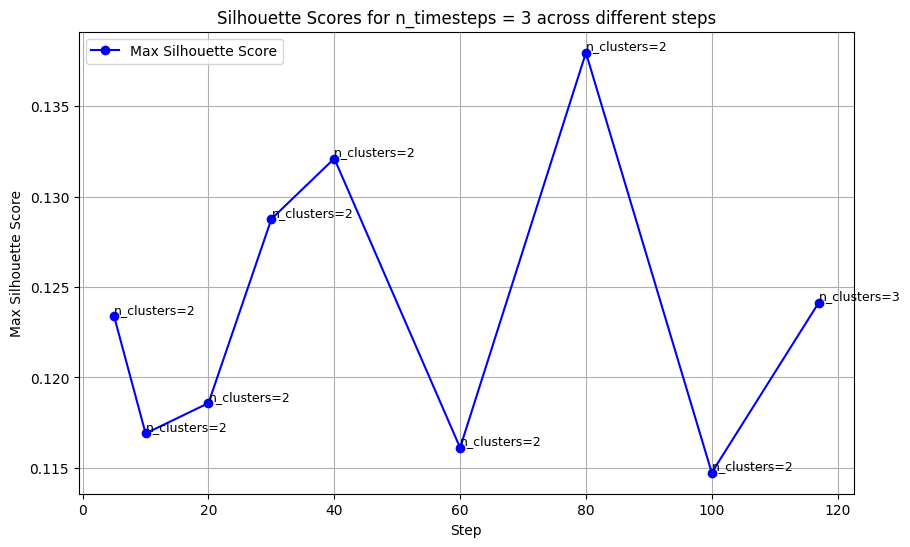

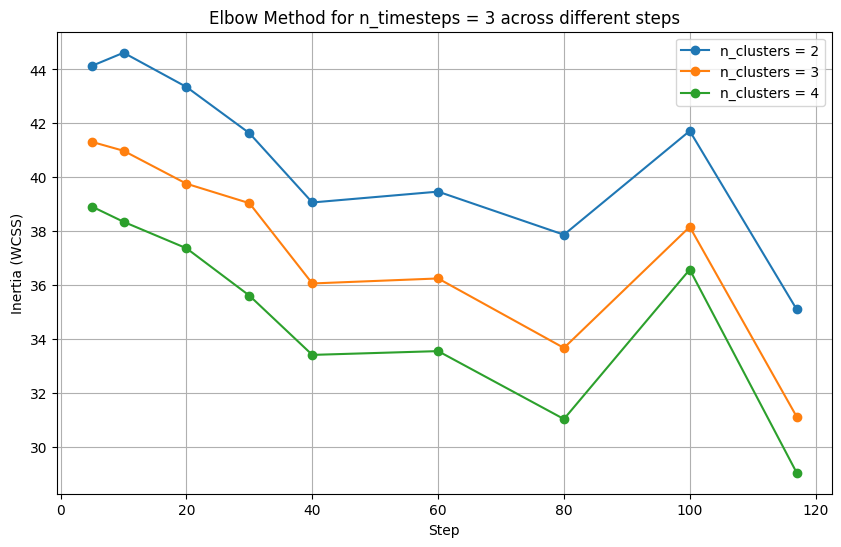


=== Aplicando clustering con n_timesteps = 3, Step = 80, n_clusters = 2 ===
Secuencias generadas en entrenamiento: 288
Forma de cada secuencia: (3, 18)
Forma escalada: (288, 3, 18)

Clusters en entrenamiento (usando moda):
          Empresa  Cluster
0  NVDA US Equity        0
1  HEES US Equity        0
2  HOLX US Equity        1
3   CPB US Equity        0
4  ARLP US Equity        1

Asignando clústeres al conjunto de prueba...
Secuencias en prueba: 72
Forma escalada en prueba: (72, 3, 18)

Clusters en prueba (usando moda):
           Empresa  Cluster
0   CENT US Equity        0
1   EBAY US Equity        0
2   SNPS US Equity        1
3   JBSS US Equity        1
4  RUSHB US Equity        0


In [54]:
# -------------------------------
# 3. Clustering con Rolling Window
# -------------------------------

# Definir explícitamente las columnas para clustering
print("\n=== Sección 3: Clustering con Rolling Window ===")
columnas_clustering = [col for col in X_train.columns if col not in ['Empresa', 'Fecha', 'time_step']]
print(f"Columnas usadas para clustering: {columnas_clustering}")

# Función para generar secuencias con ventana deslizante
def generate_rolling_windows(df, group_col, feature_cols, window_size, step):
    sequences = []
    for empresa in df[group_col].unique():
        df_empresa = df[df[group_col] == empresa][feature_cols]
        if len(df_empresa) < window_size:
            print(f"Advertencia: La empresa {empresa} tiene menos de {window_size} observaciones. Saltando.")
            continue
        for start in range(0, len(df_empresa) - window_size + 1, step):
            window = df_empresa.iloc[start:start + window_size].values
            sequences.append(window)
    return np.array(sequences)

# Función para realizar el clustering y calcular el Silhouette Score y la inercia
def compute_clustering_scores(n_timesteps, step, X_train, range_n_clusters):
    print(f"\nCalculando para n_timesteps = {n_timesteps}, step = {step}")
    X_sequences_train = generate_rolling_windows(X_train, 'Empresa', columnas_clustering, n_timesteps, step)
    print(f"Secuencias generadas: {X_sequences_train.shape[0]}")
    
    # Escalar las secuencias
    scaler_ts = TimeSeriesScalerMeanVariance()
    X_scaled_3D = scaler_ts.fit_transform(X_sequences_train)
    
    # Calcular Silhouette Scores e inercia para diferentes números de clústeres
    silhouette_scores = []
    inertias = []
    for n_clusters in range_n_clusters:
        print(f"  n_clusters = {n_clusters}")
        kmeans = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", max_iter=10, random_state=42, n_jobs=-1)
        cluster_labels = kmeans.fit_predict(X_scaled_3D)
        score = ts_silhouette_score(X_scaled_3D, cluster_labels, metric="dtw")
        silhouette_scores.append(score)
        inertias.append(kmeans.inertia_)
        print(f"    Silhouette Score: {score}, Inertia: {kmeans.inertia_}")
    
    return silhouette_scores, inertias

# Función para aplicar el clustering con la configuración óptima y asignar clústeres
def apply_optimal_clustering(n_timesteps, step, n_clusters, X_train, X_test, empresas_entrenamiento, empresas_prueba, suffix):
    print(f"\n=== Aplicando clustering con n_timesteps = {n_timesteps}, Step = {step}, n_clusters = {n_clusters} ===")
    
    # Preparar datos de entrenamiento
    X_sequences_train = generate_rolling_windows(X_train, 'Empresa', columnas_clustering, n_timesteps, step)
    print(f"Secuencias generadas en entrenamiento: {X_sequences_train.shape[0]}")
    print(f"Forma de cada secuencia: {X_sequences_train.shape[1:]}")

    # Escalar las secuencias
    scaler_ts = TimeSeriesScalerMeanVariance()
    X_scaled_3D = scaler_ts.fit_transform(X_sequences_train)
    joblib.dump(scaler_ts, f'scaler_ts_rolling_dtw_{suffix}.joblib')
    print(f"Forma escalada: {X_scaled_3D.shape}")

    # Aplicar clustering con el número óptimo de clústeres
    kmeans_optimal = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", max_iter=10, random_state=42, n_jobs=-1)
    cluster_labels_train = kmeans_optimal.fit_predict(X_scaled_3D)
    joblib.dump(kmeans_optimal, f"kmeans_rolling_dtw_{suffix}.joblib")

    # Asignar clústeres a empresas (usando la moda de las ventanas)
    n_secuencias_por_empresa = ((120 - n_timesteps) // step) + 1
    cluster_labels_per_empresa_train = []
    for i, empresa in enumerate(empresas_entrenamiento):
        start_idx = i * n_secuencias_por_empresa
        end_idx = start_idx + n_secuencias_por_empresa
        if end_idx <= len(cluster_labels_train):
            empresa_labels = cluster_labels_train[start_idx:end_idx]
            if len(empresa_labels) > 0:
                most_common_cluster = mode(empresa_labels)[0]  # Moda de los clústeres
                cluster_labels_per_empresa_train.append(most_common_cluster)
            else:
                cluster_labels_per_empresa_train.append(np.nan)
        else:
            cluster_labels_per_empresa_train.append(np.nan)

    df_empresas_clusters_train = pd.DataFrame({
        'Empresa': empresas_entrenamiento,
        'Cluster': cluster_labels_per_empresa_train
    }).dropna()
    print("\nClusters en entrenamiento (usando moda):")
    print(df_empresas_clusters_train.head())

    # Asignar clústeres al conjunto de prueba
    print("\nAsignando clústeres al conjunto de prueba...")
    X_sequences_test = generate_rolling_windows(X_test, 'Empresa', columnas_clustering, n_timesteps, step)
    print(f"Secuencias en prueba: {X_sequences_test.shape[0]}")

    scaler_ts = joblib.load(f'scaler_ts_rolling_dtw_{suffix}.joblib')
    X_scaled_test_3D = scaler_ts.transform(X_sequences_test)
    print(f"Forma escalada en prueba: {X_scaled_test_3D.shape}")

    optimal_labels_test = kmeans_optimal.predict(X_scaled_test_3D)

    # Asignar clústeres a empresas en prueba (usando la moda)
    cluster_labels_per_empresa_test = []
    for i, empresa in enumerate(empresas_prueba):
        start_idx = i * n_secuencias_por_empresa
        end_idx = start_idx + n_secuencias_por_empresa
        if end_idx <= len(optimal_labels_test):
            empresa_labels = optimal_labels_test[start_idx:end_idx]
            if len(empresa_labels) > 0:
                most_common_cluster = mode(empresa_labels)[0]  # Moda de los clústeres
                cluster_labels_per_empresa_test.append(most_common_cluster)
            else:
                cluster_labels_per_empresa_test.append(np.nan)
        else:
            cluster_labels_per_empresa_test.append(np.nan)

    df_empresas_clusters_test = pd.DataFrame({
        'Empresa': empresas_prueba,
        'Cluster': cluster_labels_per_empresa_test
    }).dropna()
    print("\nClusters en prueba (usando moda):")
    print(df_empresas_clusters_test.head())

    # Guardar los DataFrames para usarlos más tarde
    df_empresas_clusters_train.to_csv(f"df_empresas_clusters_train_{suffix}.csv", index=False)
    df_empresas_clusters_test.to_csv(f"df_empresas_clusters_test_{suffix}.csv", index=False)

    return df_empresas_clusters_train, df_empresas_clusters_test

# Paso 1: Definir las configuraciones a evaluar
n_timesteps_list = [3, 6, 12, 24, 48]  # Probamos diferentes valores de n_timesteps
step_list = [5, 10, 20, 30, 40, 60, 80, 100, 117]  # Todos los steps que probaremos en la Fase 2
range_n_clusters = [2, 3, 4]

# Fase 1: Encontrar el mejor n_timesteps con un step fijo (usamos step = 5)
print("\n=== Fase 1: Encontrar el mejor n_timesteps con step = 5 ===")
fixed_step = 5
results_phase1 = {}
for n_timesteps in n_timesteps_list:
    silhouette_scores, inertias = compute_clustering_scores(n_timesteps, fixed_step, X_train, range_n_clusters)
    optimal_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
    results_phase1[n_timesteps] = {
        'silhouette_scores': silhouette_scores,
        'inertias': inertias,
        'optimal_n_clusters': optimal_n_clusters
    }

# Seleccionar el mejor n_timesteps
best_n_timesteps = None
best_silhouette_score_phase1 = -1
best_optimal_n_clusters_phase1 = None

for n_timesteps in n_timesteps_list:
    silhouette_scores = results_phase1[n_timesteps]['silhouette_scores']
    optimal_n_clusters = results_phase1[n_timesteps]['optimal_n_clusters']
    max_silhouette = max(silhouette_scores)
    print(f"n_timesteps = {n_timesteps}, step = {fixed_step}: Silhouette Scores = {silhouette_scores}, Optimal n_clusters = {optimal_n_clusters} (Max Silhouette: {max_silhouette})")
    
    if max_silhouette > best_silhouette_score_phase1:
        best_silhouette_score_phase1 = max_silhouette
        best_n_timesteps = n_timesteps
        best_optimal_n_clusters_phase1 = optimal_n_clusters

print(f"\nMejor n_timesteps encontrado: n_timesteps = {best_n_timesteps}, Silhouette Score = {best_silhouette_score_phase1}")

# Fase 2: Usar el mejor n_timesteps y probar diferentes valores de step
print(f"\n=== Fase 2: Encontrar el mejor step con n_timesteps = {best_n_timesteps} ===")
results_phase2 = {}
# Reutilizar el resultado de n_timesteps=3, step=5 de la Fase 1
results_phase2[fixed_step] = {
    'silhouette_scores': results_phase1[best_n_timesteps]['silhouette_scores'],
    'inertias': results_phase1[best_n_timesteps]['inertias'],
    'optimal_n_clusters': results_phase1[best_n_timesteps]['optimal_n_clusters']
}

# Calcular para los otros valores de step
remaining_steps = [step for step in step_list if step != fixed_step]
for step in remaining_steps:
    silhouette_scores, inertias = compute_clustering_scores(best_n_timesteps, step, X_train, range_n_clusters)
    optimal_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
    results_phase2[step] = {
        'silhouette_scores': silhouette_scores,
        'inertias': inertias,
        'optimal_n_clusters': optimal_n_clusters
    }

# Seleccionar el mejor step
best_step = None
best_silhouette_score = -1
best_optimal_n_clusters = None

# Preparar datos para los gráficos
steps = sorted(results_phase2.keys())
max_silhouette_scores = []
optimal_n_clusters_list = []
inertias_per_step = {n_clusters: [] for n_clusters in range_n_clusters}

for step in steps:
    silhouette_scores = results_phase2[step]['silhouette_scores']
    inertias = results_phase2[step]['inertias']
    optimal_n_clusters = results_phase2[step]['optimal_n_clusters']
    max_silhouette = max(silhouette_scores)
    print(f"n_timesteps = {best_n_timesteps}, step = {step}: Silhouette Scores = {silhouette_scores}, Optimal n_clusters = {optimal_n_clusters} (Max Silhouette: {max_silhouette})")
    
    if max_silhouette > best_silhouette_score:
        best_silhouette_score = max_silhouette
        best_step = step
        best_optimal_n_clusters = optimal_n_clusters
    
    max_silhouette_scores.append(max_silhouette)
    optimal_n_clusters_list.append(optimal_n_clusters)
    for i, n_clusters in enumerate(range_n_clusters):
        inertias_per_step[n_clusters].append(inertias[i])

print(f"\nMejor configuración encontrada: n_timesteps = {best_n_timesteps}, step = {best_step}, n_clusters = {best_optimal_n_clusters}, Silhouette Score = {best_silhouette_score}")

# Gráficos para la Fase 2
# 1. Gráfico de Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(steps, max_silhouette_scores, marker='o', linestyle='-', color='b', label='Max Silhouette Score')
for i, (step, score, n_clusters) in enumerate(zip(steps, max_silhouette_scores, optimal_n_clusters_list)):
    plt.text(step, score, f'n_clusters={n_clusters}', fontsize=9, verticalalignment='bottom')
plt.xlabel('Step')
plt.ylabel('Max Silhouette Score')
plt.title(f'Silhouette Scores for n_timesteps = {best_n_timesteps} across different steps')
plt.grid(True)
plt.legend()
plt.show()

# 2. Gráfico del método del codo (Elbow Method)
plt.figure(figsize=(10, 6))
for n_clusters in range_n_clusters:
    plt.plot(steps, inertias_per_step[n_clusters], marker='o', linestyle='-', label=f'n_clusters = {n_clusters}')
plt.xlabel('Step')
plt.ylabel('Inertia (WCSS)')
plt.title(f'Elbow Method for n_timesteps = {best_n_timesteps} across different steps')
plt.grid(True)
plt.legend()
plt.show()

# Paso 3: Aplicar el clustering con la configuración óptima
suffix = f"{best_n_timesteps}m_step{best_step}"
df_empresas_clusters_train, df_empresas_clusters_test = apply_optimal_clustering(
    n_timesteps=best_n_timesteps,
    step=best_step,
    n_clusters=best_optimal_n_clusters,
    X_train=X_train,
    X_test=X_test,
    empresas_entrenamiento=empresas_entrenamiento,
    empresas_prueba=empresas_prueba,
    suffix=suffix
)

#### **usamos ventana deslizante de 3 meses (n_timesteps=3) y step=80**

In [55]:
# --------------------------------------------------------------------------
# BLOQUE ADAPTADO: Fusionar Clústeres con los Datos Originales
# --------------------------------------------------------------------------
# Asumimos que:
# X_train, y_train, X_test, y_test vienen del Bloque 2 adaptado.
#   X_train/X_test contienen 'Empresa', 'Fecha', 'time_step' y las features rezagadas.
#   y_train/y_test son las Series del target 'P_E' alineadas con X_train/X_test.
# df_empresas_clusters_train, df_empresas_clusters_test vienen del Bloque 3
#   (apply_optimal_clustering) y tienen 'Empresa' y 'Cluster'.

print("\n=== BLOQUE ADAPTADO: Fusionando Clústeres con los Datos Originales ===")

# --- Conjunto de Entrenamiento ---
print("\nProcesando conjunto de entrenamiento...")

# 1. Reconstruir temporalmente el DataFrame de entrenamiento con el target
#    Esto asegura que el target 'P_E' se mantenga alineado con sus features durante el merge.
#    Asegurarse de que los índices de X_train e y_train estén alineados antes de concatenar.
if not X_train.index.equals(y_train.index):
    print("ADVERTENCIA: Índices de X_train e y_train no están alineados antes del merge. Intentando alinear...")
    # Esto es una salvaguarda; idealmente, deberían estar alineados desde el Bloque 2.
    common_idx_train = X_train.index.intersection(y_train.index)
    X_train_temp_merge = X_train.loc[common_idx_train].copy()
    y_train_temp_merge = y_train.loc[common_idx_train].copy()
    print(f"  Dimensiones después de alinear por índice común: X_train_temp_merge: {X_train_temp_merge.shape}, y_train_temp_merge: {y_train_temp_merge.shape}")
else:
    X_train_temp_merge = X_train.copy()
    y_train_temp_merge = y_train.copy()

df_train_con_target = pd.concat([X_train_temp_merge, y_train_temp_merge.rename('P_E_target_temp')], axis=1)

# 2. Fusionar con las etiquetas de clúster de las empresas
#    El merge se hace sobre 'Empresa'. La columna 'Cluster' se añadirá a todas las filas de cada empresa.
df_train_con_cluster_y_target = df_train_con_target.merge(df_empresas_clusters_train, on='Empresa', how='left')

# 3. Manejar empresas que podrían no tener un clúster asignado (si alguna empresa en X_train no tuvo suficientes ventanas)
if df_train_con_cluster_y_target['Cluster'].isnull().any():
    print(f"ADVERTENCIA: {df_train_con_cluster_y_target['Cluster'].isnull().sum()} filas en entrenamiento no pudieron ser asignadas a un clúster (posiblemente empresas pequeñas).")
    # Decide cómo manejar esto:
    # Opción A: Eliminar estas filas
    # df_train_con_cluster_y_target.dropna(subset=['Cluster'], inplace=True)
    # print("  Filas sin clúster eliminadas.")
    # Opción B: Asignar un clúster placeholder (ej., -1) o imputar
    df_train_con_cluster_y_target['Cluster'].fillna(-1, inplace=True) # Ejemplo: placeholder
    print("  Filas sin clúster rellenadas con -1.")


df_train_con_cluster_y_target['Cluster'] = df_train_con_cluster_y_target['Cluster'].astype(int)

# 4. Separar de nuevo X_model_train (features para el modelo) e y_model_train (target)
#    X_model_train ahora incluirá 'Cluster' como una feature.
#    Las columnas de identificación como 'Empresa', 'Fecha', 'time_step' se pueden mantener aquí
#    si son necesarias para el GroupKFold o se eliminarán justo antes de entrenar el modelo supervisado.
X_model_train = df_train_con_cluster_y_target.drop(columns=['P_E_target_temp'])
y_model_train = df_train_con_cluster_y_target['P_E_target_temp'].copy()

# Mantener groups_train alineado
groups_train_final = X_model_train['Empresa'].copy() # 'Empresa' sigue estando en X_model_train

print(f"Dimensiones finales entrenamiento: X_model_train: {X_model_train.shape}, y_model_train: {y_model_train.shape}")


# --- Conjunto de Prueba ---
print("\nProcesando conjunto de prueba...")
# 1. Reconstruir temporalmente el DataFrame de prueba con el target
if not X_test.index.equals(y_test.index):
    print("ADVERTENCIA: Índices de X_test e y_test no están alineados antes del merge. Intentando alinear...")
    common_idx_test = X_test.index.intersection(y_test.index)
    X_test_temp_merge = X_test.loc[common_idx_test].copy()
    y_test_temp_merge = y_test.loc[common_idx_test].copy()
else:
    X_test_temp_merge = X_test.copy()
    y_test_temp_merge = y_test.copy()

df_test_con_target = pd.concat([X_test_temp_merge, y_test_temp_merge.rename('P_E_target_temp')], axis=1)

# 2. Fusionar con las etiquetas de clúster de las empresas
df_test_con_cluster_y_target = df_test_con_target.merge(df_empresas_clusters_test, on='Empresa', how='left')

# 3. Manejar empresas en prueba que podrían no tener un clúster
if df_test_con_cluster_y_target['Cluster'].isnull().any():
    print(f"ADVERTENCIA: {df_test_con_cluster_y_target['Cluster'].isnull().sum()} filas en prueba no pudieron ser asignadas a un clúster.")
    df_test_con_cluster_y_target['Cluster'].fillna(-1, inplace=True) # Ejemplo: placeholder
    print("  Filas sin clúster rellenadas con -1.")

df_test_con_cluster_y_target['Cluster'] = df_test_con_cluster_y_target['Cluster'].astype(int)

# 4. Separar de nuevo X_model_test e y_model_test
X_model_test = df_test_con_cluster_y_target.drop(columns=['P_E_target_temp'])
y_model_test = df_test_con_cluster_y_target['P_E_target_temp'].copy()

# Mantener groups_test alineado
groups_test_final = X_model_test['Empresa'].copy()

print(f"Dimensiones finales prueba: X_model_test: {X_model_test.shape}, y_model_test: {y_model_test.shape}")


# --- Verificación de Valores NaN después del merge y procesamiento ---
print("\nValores NaN en X_model_train después del merge y procesamiento:")
print(X_model_train.isnull().sum().sort_values(ascending=False).head())
print(f"Total NaNs en X_model_train: {X_model_train.isnull().sum().sum()}")

print("\nValores NaN en y_model_train después del merge y procesamiento:")
print(y_model_train.isnull().sum())

print("\nValores NaN en X_model_test después del merge y procesamiento:")
print(X_model_test.isnull().sum().sort_values(ascending=False).head())
print(f"Total NaNs en X_model_test: {X_model_test.isnull().sum().sum()}")

print("\nValores NaN en y_model_test después del merge y procesamiento:")
print(y_model_test.isnull().sum())


# --- RENOMBRAR VARIABLES PARA CONSISTENCIA CON BLOQUES POSTERIORES ---
# Los bloques siguientes esperan df_model_train, y_train, df_model_test, y_test, groups_train
df_model_train_final = X_model_train
y_train_final = y_model_train
df_model_test_final = X_model_test
y_test_final = y_model_test
# groups_train ya se llama groups_train_final, puedes renombrarlo si prefieres solo groups_train

# Ahora df_model_train_final y df_model_test_final contienen la columna 'Cluster'
# y y_train_final e y_test_final están correctamente alineados.


=== BLOQUE ADAPTADO: Fusionando Clústeres con los Datos Originales ===

Procesando conjunto de entrenamiento...
Dimensiones finales entrenamiento: X_model_train: (17136, 22), y_model_train: (17136,)

Procesando conjunto de prueba...
Dimensiones finales prueba: X_model_test: (4284, 22), y_model_test: (4284,)

Valores NaN en X_model_train después del merge y procesamiento:
Empresa                  0
Fecha                    0
time_step                0
dif_NFP_promedio_lag1    0
dif_FFR_promedio_lag1    0
dtype: int64
Total NaNs en X_model_train: 0

Valores NaN en y_model_train después del merge y procesamiento:
0

Valores NaN en X_model_test después del merge y procesamiento:
Empresa                  0
Fecha                    0
time_step                0
dif_NFP_promedio_lag1    0
dif_FFR_promedio_lag1    0
dtype: int64
Total NaNs en X_model_test: 0

Valores NaN en y_model_test después del merge y procesamiento:
0



=== Sección 4: Gráfico de Silhouette (Visualización con Secuencias Aplanadas) ===

Preparando datos para el gráfico de Silhouette...
  Columnas usadas para generar secuencias para el gráfico: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROA_l_lag1', 'ROCE_l_lag1', 'ROI_l_lag1', 'Total Activos_l_lag1', 'dif_CPI_promedio_lag1', 'dif_FFR_promedio_lag1', 'dif_NFP_promedio_lag1']
  Secuencias generadas para el gráfico: (288, 3, 18)
  Forma de las secuencias escaladas: (288, 3, 18)
  Etiquetas de clúster generadas: 288 (Debería coincidir con 288)
  Forma de los datos aplanados para Silhouette: (288, 54)


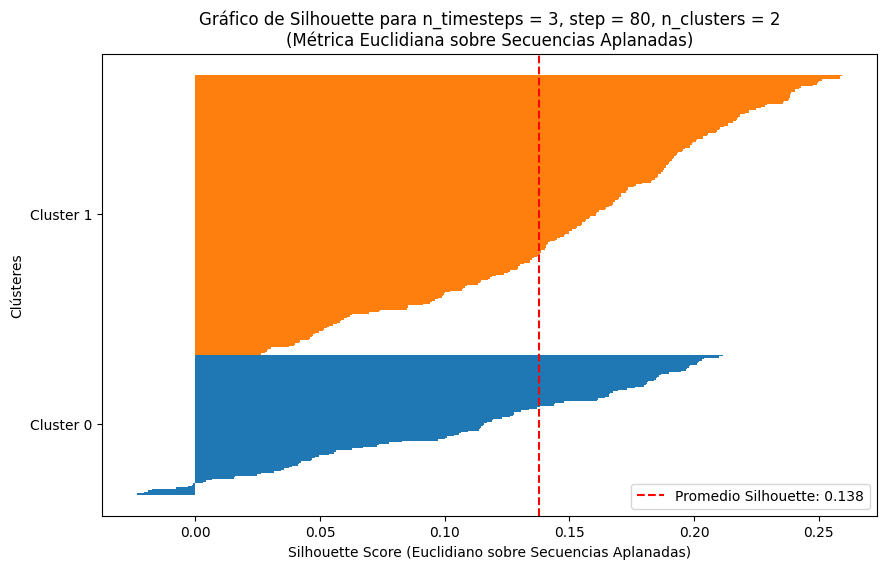

In [56]:
# -------------------------------
# 4. Gráfico de Silhouette
# -------------------------------
print("\n=== Sección 4: Gráfico de Silhouette (Visualización con Secuencias Aplanadas) ===")

def plot_silhouette_flattened(X_3D_scaled, labels, n_clusters, n_timesteps, step): # Renombrado para claridad
    """
    Genera un gráfico de análisis de Silhouette para evaluar los clústeres,
    basado en secuencias aplanadas y distancia euclidiana (implícita en silhouette_samples).
    """
    # Aplanar las secuencias 3D a 2D para silhouette_samples
    # Cada secuencia (ventana) se convierte en un único vector de características
    X_2d = X_3D_scaled.reshape(X_3D_scaled.shape[0], -1) # (n_sequences, n_timesteps * n_features_per_timestep)

    print(f"  Forma de los datos aplanados para Silhouette: {X_2d.shape}")
    if X_2d.shape[0] != len(labels):
        raise ValueError(f"El número de muestras en X_2d ({X_2d.shape[0]}) no coincide con el número de etiquetas ({len(labels)}).")
    if len(np.unique(labels)) < 2 or len(np.unique(labels)) > X_2d.shape[0]-1 : # Condición para silhouette_samples
        print(f"  ADVERTENCIA: No se puede calcular silhouette_samples con {len(np.unique(labels))} etiquetas únicas para {X_2d.shape[0]} muestras. Saltando gráfico.")
        return

    silhouette_avg = silhouette_score(X_2d, labels) # Usar silhouette_score para el promedio general
    silhouette_vals = silhouette_samples(X_2d, labels)

    y_lower, y_upper = 0, 0
    yticks = []

    plt.figure(figsize=(10, 6)) # Asegurar que la figura se crea aquí
    for i in range(n_clusters):
        cluster_silhouette_vals = silhouette_vals[labels == i]
        cluster_silhouette_vals.sort()
        y_upper += len(cluster_silhouette_vals)
        plt.barh(range(y_lower, y_upper), cluster_silhouette_vals, edgecolor='none', height=1)
        yticks.append((y_lower + y_upper) / 2)
        y_lower += len(cluster_silhouette_vals)

    plt.axvline(silhouette_avg, color="red", linestyle="--", label=f"Promedio Silhouette: {silhouette_avg:.3f}")
    plt.yticks(yticks, [f"Cluster {i}" for i in range(n_clusters)])
    plt.xlabel("Silhouette Score (Euclidiano sobre Secuencias Aplanadas)")
    plt.ylabel("Clústeres")
    plt.title(f"Gráfico de Silhouette para n_timesteps = {n_timesteps}, step = {best_step}, n_clusters = {n_clusters}\n(Métrica Euclidiana sobre Secuencias Aplanadas)")
    plt.legend()
    plt.show()

# --- Obtener los datos necesarios ---
# X_train viene del Bloque 2 adaptado.
# best_n_timesteps, best_step, best_optimal_n_clusters, suffix vienen del Bloque 3.

print("\nPreparando datos para el gráfico de Silhouette...")

# 1. Definir las columnas de características usadas para generar las secuencias en el Bloque 3
#    Esto DEBE COINCIDIR con las 'columnas_clustering' usadas en el Bloque 3.
#    Si X_train (del Bloque 2) se definió correctamente, esto debería ser:
features_usadas_para_secuencias = [col for col in X_train.columns if col not in ['Empresa', 'Fecha', 'time_step']]
# O, si guardaste la lista de columnas_clustering del Bloque 3, cárgala o redefínela aquí.
# Por ejemplo: columnas_clustering_originales_bloque3 = [...]
# df_features_train = X_train[columnas_clustering_originales_bloque3]

df_features_train = X_train[features_usadas_para_secuencias].copy()
print(f"  Columnas usadas para generar secuencias para el gráfico: {df_features_train.columns.tolist()}")


# 2. Generar las secuencias de entrenamiento (igual que en apply_optimal_clustering)
#    Asegúrate que la función generate_rolling_windows esté definida y accesible.
#    Y que X_train tenga la columna 'Empresa'.
if 'Empresa' not in X_train.columns:
    raise KeyError("'Empresa' no se encuentra en X_train, necesaria para generate_rolling_windows.")

X_sequences_train_plot = generate_rolling_windows(X_train, 'Empresa', df_features_train.columns, best_n_timesteps, best_step)
# Si tu generate_rolling_windows devuelve también los IDs de empresa, solo necesitas el array de secuencias:
# X_sequences_train_plot, _ = generate_rolling_windows(X_train, 'Empresa', df_features_train.columns, best_n_timesteps, best_step)


if X_sequences_train_plot.shape[0] == 0:
    print("ADVERTENCIA: No se generaron secuencias para el gráfico de Silhouette. Saltando el gráfico.")
else:
    print(f"  Secuencias generadas para el gráfico: {X_sequences_train_plot.shape}")
    # 3. Cargar el scaler y transformar
    try:
        scaler_ts_plot = joblib.load(f'scaler_ts_rolling_dtw_{suffix}.joblib')
        X_scaled_3D_plot = scaler_ts_plot.transform(X_sequences_train_plot)
        print(f"  Forma de las secuencias escaladas: {X_scaled_3D_plot.shape}")

        # 4. Cargar el modelo KMeans y predecir etiquetas
        kmeans_optimal_plot = joblib.load(f"kmeans_rolling_dtw_{suffix}.joblib")
        cluster_labels_train_plot = kmeans_optimal_plot.predict(X_scaled_3D_plot)
        print(f"  Etiquetas de clúster generadas: {len(cluster_labels_train_plot)} (Debería coincidir con {X_sequences_train_plot.shape[0]})")

        # 5. Generar el gráfico de Silhouette
        plot_silhouette_flattened(X_scaled_3D_plot, cluster_labels_train_plot, best_optimal_n_clusters, best_n_timesteps, best_step)
    except FileNotFoundError as e:
        print(f"ERROR al cargar archivos .joblib para el gráfico de Silhouette: {e}. Asegúrate de que los archivos existen con el sufijo '{suffix}'.")
    except Exception as e:
        print(f"Un error ocurrió durante la preparación o graficación de Silhouette: {e}")


=== Sección 5: Gráficos de Distribución de Clústeres y Variables ===

Generando gráfico de distribución de clústeres en entrenamiento y prueba...


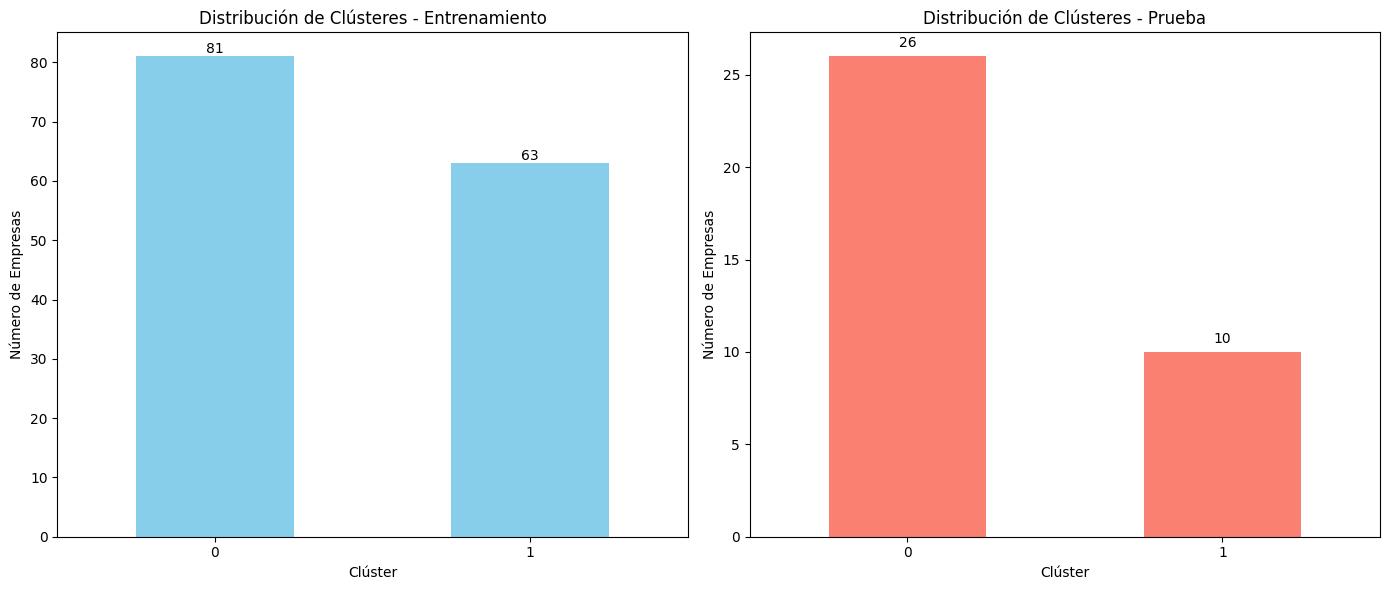


Generando gráficos de distribución de las variables por clúster...
  Se graficarán las primeras 3 features de 18 disponibles: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1']


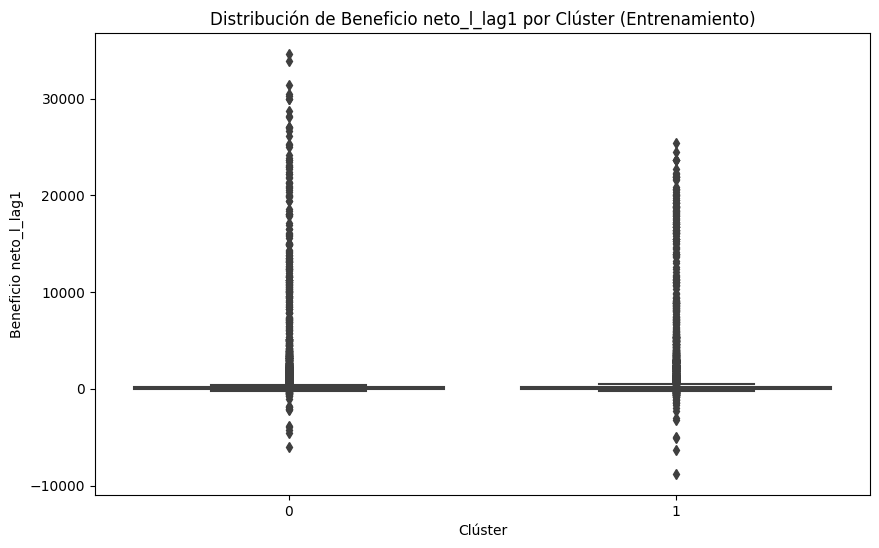

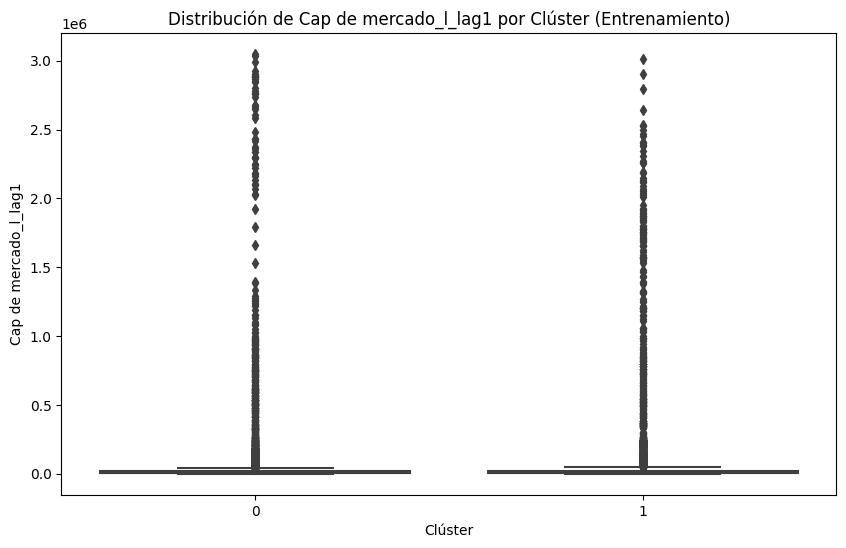

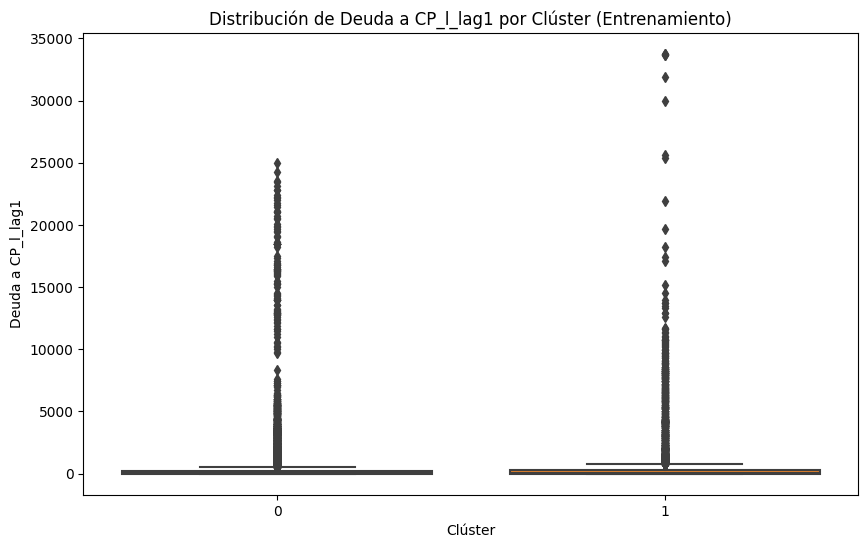

In [58]:
# -------------------------------
# 5. Gráficos de Distribución de Clústeres y Variables
# -------------------------------
print("\n=== Sección 5: Gráficos de Distribución de Clústeres y Variables ===")

# Parte 1: Gráfico de distribución del número de empresas por clúster
# (Esta parte debería funcionar bien si df_empresas_clusters_train y df_empresas_clusters_test están definidos)
print("\nGenerando gráfico de distribución de clústeres en entrenamiento y prueba...")

# Calcular la cantidad de empresas por clúster en entrenamiento
clusters_entrenamiento_counts = df_empresas_clusters_train['Cluster'].value_counts().sort_index()

# Calcular la cantidad de empresas por clúster en prueba
clusters_prueba_counts = df_empresas_clusters_test['Cluster'].value_counts().sort_index()

# Configurar el tamaño de la figura
plt.figure(figsize=(14, 6))

# Subgráfico para el conjunto de entrenamiento
plt.subplot(1, 2, 1)
clusters_entrenamiento_counts.plot(kind='bar', color='skyblue')
plt.title('Distribución de Clústeres - Entrenamiento')
plt.xlabel('Clúster')
plt.ylabel('Número de Empresas')
plt.xticks(rotation=0)
for index, value in enumerate(clusters_entrenamiento_counts):
    plt.text(index, value + 0.5, str(value), ha='center')

# Subgráfico para el conjunto de prueba
plt.subplot(1, 2, 2)
clusters_prueba_counts.plot(kind='bar', color='salmon')
plt.title('Distribución de Clústeres - Prueba')
plt.xlabel('Clúster')
plt.ylabel('Número de Empresas')
plt.xticks(rotation=0)
for index, value in enumerate(clusters_prueba_counts):
    plt.text(index, value + 0.5, str(value), ha='center')

# Ajustar el layout y mostrar el gráfico
plt.tight_layout()
plt.show()

# Parte 2: Gráficos de distribución de las variables por clúster
print("\nGenerando gráficos de distribución de las variables por clúster...")

# USA EL NOMBRE CORRECTO DEL DATAFRAME DE ENTRENAMIENTO FINAL
# Si lo llamaste df_model_train_final en el bloque anterior:
if 'df_model_train_final' not in locals():
    raise NameError("La variable 'df_model_train_final' (o el nombre que le hayas dado al DataFrame de entrenamiento con clusters) no está definida.")

# Identificar las columnas numéricas (excluyendo columnas no numéricas y de identificación)
# 'Cluster' ya es una columna en df_model_train_final
non_numeric_cols_plot = ['Empresa', 'Fecha', 'time_step'] # 'Cluster' se usa para el eje x del boxplot
# Las features a plotear son las que no son de identificación y no son el propio 'Cluster'
features_to_plot = [
    col for col in df_model_train_final.columns
    if col not in non_numeric_cols_plot and col != 'Cluster' # Excluir 'Cluster' de las features a plotear en el eje Y
]


# Seleccionar un subconjunto de variables para graficar (por ejemplo, las primeras 3 o algunas clave)
# Asegúrate de que estas features existan y sean las que te interesan (probablemente las rezagadas)
if len(features_to_plot) > 3:
    print(f"  Se graficarán las primeras 3 features de {len(features_to_plot)} disponibles: {features_to_plot[:3]}")
    features_to_plot = features_to_plot[:3]
elif not features_to_plot:
    print("  ADVERTENCIA: No se encontraron features para graficar en los boxplots.")
else:
    print(f"  Se graficarán las siguientes features: {features_to_plot}")


# Generar un boxplot para cada variable seleccionada
for feature in features_to_plot:
    if feature in df_model_train_final.columns: # Doble verificación
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Cluster', y=feature, data=df_model_train_final) # Usar df_model_train_final
        plt.title(f'Distribución de {feature} por Clúster (Entrenamiento)')
        plt.xlabel('Clúster')
        plt.ylabel(feature)
        plt.show()
    else:
        print(f"  ADVERTENCIA: La feature '{feature}' no se encontró en df_model_train_final.")

In [59]:
# ---------------------------------------------------------------------------------
# BLOQUE 6 ADAPTADO: Escalado de Características para Modelos Supervisados
# ---------------------------------------------------------------------------------
print("\n=== BLOQUE 6: Escalado de Características para Modelos Supervisados ===")

# Asumimos que df_model_train_final y df_model_test_final están definidos
# y son el resultado del bloque de fusión de clústeres.
# Estos DataFrames contienen 'Empresa', 'Fecha', 'time_step', las features rezagadas, y 'Cluster'.

if 'df_model_train_final' not in locals() or 'df_model_test_final' not in locals():
    raise NameError("Las variables 'df_model_train_final' o 'df_model_test_final' no están definidas. Asegúrate de que el bloque de fusión de clústeres se haya ejecutado y las variables tengan los nombres correctos.")

# --- 6.1 Definir las características (features) para el modelo supervisado ---
# Estas son las columnas que se usarán como entrada para RF, XGBoost, etc.
# Excluimos identificadores y la columna 'Cluster' si no se va a escalar (generalmente no se escala).
# Si 'Cluster' se va a usar como feature numérica directamente (lo cual es común si es int),
# entonces SÍ debería estar en 'features_a_escalar_numeric'.
# Sin embargo, si la vas a tratar como categórica (ej. one-hot encoding más adelante, o si el modelo la maneja bien como int),
# entonces la excluyes del escalado numérico.
# Por ahora, asumiremos que las features rezagadas son las principales a escalar.
# 'Cluster' se puede añadir después del escalado o manejar por separado.

columnas_identificadoras_y_target_relacionadas = ['Empresa', 'Fecha', 'time_step', 'P_E'] # P_E es el target, no una feature
# 'Cluster' es una feature, pero la trataremos por separado del escalado de las features originales.

# Las features a escalar son las columnas rezagadas originales.
features_rezagadas_originales = [
    col for col in df_model_train_final.columns
    if '_lag' in col # Asumiendo que todas tus features originales rezagadas contienen '_lag'
]

if not features_rezagadas_originales:
    print("ADVERTENCIA: No se encontraron features rezagadas para escalar. Verifica las columnas en df_model_train_final.")
    # Si no hay features rezagadas, el escalado podría no ser necesario o la lógica de selección de features debe revisarse.
    # Por ahora, crearemos X_train_scaled y X_test_scaled vacíos o con las columnas que sí haya.
    X_train_features_para_modelo = df_model_train_final.drop(columns=columnas_identificadoras_y_target_relacionadas, errors='ignore')
    X_test_features_para_modelo = df_model_test_final.drop(columns=columnas_identificadoras_y_target_relacionadas, errors='ignore')
    # En este caso, X_train_scaled sería igual a X_train_features_para_modelo si no hay nada que escalar.
    # O podrías decidir no escalar si solo queda 'Cluster'.
else:
    print(f"\nCaracterísticas rezagadas seleccionadas para escalado en modelos supervisados: {features_rezagadas_originales}")

    # --- 6.2 Escalar solo las características rezagadas numéricas ---
    print("\nEscalando características rezagadas con StandardScaler...")
    scaler_supervisado = StandardScaler()

    # Ajustar y transformar en el conjunto de entrenamiento
    X_train_rezagadas_scaled_array = scaler_supervisado.fit_transform(df_model_train_final[features_rezagadas_originales])
    X_train_rezagadas_scaled = pd.DataFrame(
        X_train_rezagadas_scaled_array,
        columns=features_rezagadas_originales,
        index=df_model_train_final.index
    )

    # Transformar en el conjunto de prueba
    X_test_rezagadas_scaled_array = scaler_supervisado.transform(df_model_test_final[features_rezagadas_originales])
    X_test_rezagadas_scaled = pd.DataFrame(
        X_test_rezagadas_scaled_array,
        columns=features_rezagadas_originales,
        index=df_model_test_final.index
    )
    print("Escalado completado.")

    # --- 6.3 Reconstruir los DataFrames de features para el modelo ---
    # Añadir la columna 'Cluster' (que no se escaló) a las features escaladas.
    # Y otras columnas que quieras usar como features pero que no se escalaron (si las hubiera).

    # Para entrenamiento
    X_train_features_para_modelo = X_train_rezagadas_scaled.copy()
    if 'Cluster' in df_model_train_final.columns:
        X_train_features_para_modelo['Cluster'] = df_model_train_final['Cluster'].copy()
    else:
        print("ADVERTENCIA: La columna 'Cluster' no se encontró en df_model_train_final.")


    # Para prueba
    X_test_features_para_modelo = X_test_rezagadas_scaled.copy()
    if 'Cluster' in df_model_test_final.columns:
        X_test_features_para_modelo['Cluster'] = df_model_test_final['Cluster'].copy()
    else:
        print("ADVERTENCIA: La columna 'Cluster' no se encontró en df_model_test_final.")

# Guardar el escalador para uso futuro
joblib.dump(scaler_supervisado, "scaler_supervisado_modelos.joblib") # Nombre más específico
print("\nEscalador para modelos supervisados guardado como 'scaler_supervisado_modelos.joblib'")

print(f"\nDimensiones de X_train_features_para_modelo (features finales para modelos supervisados): {X_train_features_para_modelo.shape}")
print("Primeras filas de X_train_features_para_modelo:")
print(X_train_features_para_modelo.head())

print(f"\nDimensiones de X_test_features_para_modelo: {X_test_features_para_modelo.shape}")

# --- RESULTADOS DE ESTE BLOQUE ---
# X_train_features_para_modelo: DataFrame con las features escaladas y la columna 'Cluster' para entrenamiento.
# X_test_features_para_modelo: DataFrame con las features escaladas y la columna 'Cluster' para prueba.
# y_train_final, y_test_final: Targets (definidos en el bloque de fusión).
# groups_train_final: Grupos para CV (definidos en el bloque de fusión).
# scaler_supervisado: El objeto StandardScaler ajustado.


=== BLOQUE 6: Escalado de Características para Modelos Supervisados ===

Características rezagadas seleccionadas para escalado en modelos supervisados: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROA_l_lag1', 'ROCE_l_lag1', 'ROI_l_lag1', 'Total Activos_l_lag1', 'dif_CPI_promedio_lag1', 'dif_FFR_promedio_lag1', 'dif_NFP_promedio_lag1']

Escalando características rezagadas con StandardScaler...
Escalado completado.

Escalador para modelos supervisados guardado como 'scaler_supervisado_modelos.joblib'

Dimensiones de X_train_features_para_modelo (features finales para modelos supervisados): (17136, 19)
Primeras filas de X_train_features_para_modelo:
   Beneficio neto_l_lag1  Cap de mercado_l_lag1  Deuda a CP_l_lag1  \
0               3.337828               2.408283           1.520043   
1               3.445089               2.483476

In [93]:
# ---------------------------------------------------------------------------------
# BLOQUE 7 ADAPTADO: Definición de la Función de Entrenamiento por Clúster
# ---------------------------------------------------------------------------------
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold, KFold, ParameterGrid # <--- ParameterGrid importado
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n=== BLOQUE 7: Definición de la Función de Entrenamiento por Clúster (Adaptada) ===")

def entrenar_evaluar_modelos_por_cluster(
    df_train_full_input,  # DataFrame completo de entrenamiento (features + Cluster + Empresa + otras IDs)
    y_train_input,        # Serie del target de entrenamiento, alineada con df_train_full_input
    df_test_full_input,   # DataFrame completo de prueba (features + Cluster + Empresa + otras IDs)
    y_test_input,         # Serie del target de prueba, alineada con df_test_full_input
    param_grid_rf,
    param_grid_xgb,
    model_type='rf',
    n_iter=10 # Número de iteraciones para RandomizedSearchCV
):
    """
    Entrena y evalúa el mejor modelo por clúster con búsqueda de hiperparámetros.
    """
    resultados = []

    if 'Cluster' not in df_train_full_input.columns or 'Empresa' not in df_train_full_input.columns:
        raise ValueError("df_train_full_input debe contener las columnas 'Cluster' y 'Empresa'.")
    if 'Cluster' not in df_test_full_input.columns:
        raise ValueError("df_test_full_input debe contener la columna 'Cluster'.")

    # Asegurar alineación inicial (salvaguarda)
    common_idx_train = df_train_full_input.index.intersection(y_train_input.index)
    df_train_aligned = df_train_full_input.loc[common_idx_train]
    y_train_aligned = y_train_input.loc[common_idx_train]

    common_idx_test = df_test_full_input.index.intersection(y_test_input.index)
    df_test_aligned = df_test_full_input.loc[common_idx_test]
    y_test_aligned = y_test_input.loc[common_idx_test]

    clusters_unicos = sorted(df_train_aligned['Cluster'].unique())
    print(f"\nTipo de Modelo a entrenar: {'Random Forest' if model_type == 'rf' else 'XGBoost'}")
    print(f"Clústeres únicos identificados en datos de entrenamiento: {clusters_unicos}")

    cols_to_drop_from_features = ['Empresa', 'Fecha', 'time_step', 'Cluster']

    for cluster_val in clusters_unicos:
        print(f"\n--- Procesando Clúster {cluster_val} ---")

        mask_train_cluster = df_train_aligned['Cluster'] == cluster_val
        X_train_cluster_full_df = df_train_aligned.loc[mask_train_cluster]
        y_train_cluster = y_train_aligned.loc[mask_train_cluster].copy().reset_index(drop=True)
        groups_cluster_train = X_train_cluster_full_df['Empresa'].copy().reset_index(drop=True)
        X_train_cluster_features = X_train_cluster_full_df.drop(
            columns=cols_to_drop_from_features, errors='ignore'
        ).reset_index(drop=True)

        if X_train_cluster_features.empty or len(X_train_cluster_features) < 5: # Umbral mínimo
             print(f"  Muy pocos datos de entrenamiento ({len(X_train_cluster_features)}) para el clúster {cluster_val}. Saltando este clúster.")
             continue

        if X_train_cluster_features.isnull().any().any() or y_train_cluster.isnull().any() or groups_cluster_train.isnull().any():
            print(f"  Error: NaNs en datos preparados para clúster {cluster_val}. Saltando.")
            continue
        
        print(f"  Tamaño de datos de entrenamiento para clúster {cluster_val}: {X_train_cluster_features.shape[0]} muestras.")

        mask_test_cluster = df_test_aligned['Cluster'] == cluster_val
        X_test_cluster_full_df = df_test_aligned.loc[mask_test_cluster]
        y_test_cluster = y_test_aligned.loc[mask_test_cluster].copy().reset_index(drop=True)
        X_test_cluster_features = X_test_cluster_full_df.drop(
            columns=cols_to_drop_from_features, errors='ignore'
        ).reset_index(drop=True)

        if X_test_cluster_features.empty:
            print(f"  No hay datos de prueba para el clúster {cluster_val}.")
        else:
            print(f"  Tamaño de datos de prueba para clúster {cluster_val}: {X_test_cluster_features.shape[0]} muestras.")

        if model_type == 'rf':
            modelo = RandomForestRegressor(random_state=42, n_jobs=-1)
            param_distributions = param_grid_rf
        elif model_type == 'xgb':
            modelo = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0)
            param_distributions = param_grid_xgb
        else:
            raise ValueError("model_type debe ser 'rf' o 'xgb'")

        cv_strategy = None
        fit_params_cv = {}
        n_unique_groups_in_cluster = groups_cluster_train.nunique()
        min_samples_for_cv = 5 # Un umbral razonable para que CV tenga sentido

        if n_unique_groups_in_cluster >= 2 and len(X_train_cluster_features) >= min_samples_for_cv:
            n_splits_gkf = min(3, n_unique_groups_in_cluster)
            n_splits_gkf = max(2, n_splits_gkf)
            if len(X_train_cluster_features) >= n_splits_gkf:
                cv_strategy = GroupKFold(n_splits=n_splits_gkf)
                fit_params_cv = {'groups': groups_cluster_train}
                print(f"  Usando GroupKFold con {n_splits_gkf} splits.")
            else:
                print(f"  No suficientes muestras ({len(X_train_cluster_features)}) para GroupKFold con {n_splits_gkf} splits. Intentando KFold.")
        
        if cv_strategy is None and len(X_train_cluster_features) >= min_samples_for_cv:
            n_splits_kf = min(3, len(X_train_cluster_features))
            n_splits_kf = max(2, n_splits_kf)
            if len(X_train_cluster_features) >= n_splits_kf:
                cv_strategy = KFold(n_splits=n_splits_kf, shuffle=True, random_state=42)
                print(f"  Usando KFold con {n_splits_kf} splits.")
            else:
                print(f"  No suficientes muestras ({len(X_train_cluster_features)}) para KFold con {n_splits_kf} splits. No se usará CV para HP.")
        elif cv_strategy is None: # Si no se cumplió la condición de min_samples_for_cv
             print(f"  No suficientes muestras ({len(X_train_cluster_features)}) para CV. No se usará CV para HP.")


        num_param_combinations = len(ParameterGrid(param_distributions))
        current_n_iter = min(n_iter, num_param_combinations)
        if current_n_iter < n_iter and num_param_combinations > 0 : # Solo imprimir si n_iter se redujo y hay combinaciones
            print(f"  Ajustando n_iter de RandomizedSearch de {n_iter} a {current_n_iter} (total combinaciones: {num_param_combinations}).")
        
        best_model = None
        best_params_found = "Default (Configuración Inicial)"

        if cv_strategy is not None and num_param_combinations > 0 and current_n_iter > 0:
            randomized_search = RandomizedSearchCV(
                estimator=modelo,
                param_distributions=param_distributions,
                n_iter=current_n_iter,
                scoring='neg_mean_squared_error',
                cv=cv_strategy,
                verbose=0,
                random_state=42,
                n_jobs=-1
            )
            try:
                print("  Realizando búsqueda de hiperparámetros con RandomizedSearchCV...")
                randomized_search.fit(X_train_cluster_features, y_train_cluster, **fit_params_cv)
                best_model = randomized_search.best_estimator_
                best_params_found = randomized_search.best_params_
                print("  Búsqueda de hiperparámetros completada.")
            except Exception as e:
                print(f"  Error durante RandomizedSearchCV para clúster {cluster_val}: {e}")
                print("  Entrenando modelo con parámetros por defecto como fallback.")
                best_params_found = "Default (Fallo en HP Search)"
                # No reasignar 'modelo' a 'best_model' aquí si HP falla, entrenar el 'modelo' base después
        
        if best_model is None: # Si HP Search no se hizo o falló
            print("  Entrenando modelo con parámetros por defecto (sin HP Search o fallback de HP).")
            try:
                modelo.fit(X_train_cluster_features, y_train_cluster)
                best_model = modelo
                # best_params_found ya está como "Default..."
            except Exception as e_fit:
                print(f"    Error entrenando modelo con params por defecto: {e_fit}")
                continue # Saltar al siguiente clúster si el entrenamiento base también falla

        rmse_val, mae_val, r2_val = np.nan, np.nan, np.nan
        if best_model and not X_test_cluster_features.empty:
            try:
                y_pred = best_model.predict(X_test_cluster_features)
                rmse_val = np.sqrt(mean_squared_error(y_test_cluster, y_pred))
                mae_val = mean_absolute_error(y_test_cluster, y_pred)
                r2_val = r2_score(y_test_cluster, y_pred)
                print(f"    Métricas en Prueba - RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}, R²: {r2_val:.4f}")
            except Exception as e:
                print(f"    Error al predecir en el conjunto de prueba para clúster {cluster_val}: {e}")
        elif not X_test_cluster_features.empty:
             print(f"    No se pudo obtener un 'best_model' para el clúster {cluster_val}.")
        else:
            print(f"    No hay datos de prueba para evaluar el clúster {cluster_val}.")

        ruta_modelo = "No guardado"
        if best_model:
            nombre_modelo = f"{model_type}_cluster_{cluster_val}_best.joblib"
            carpeta_modelo = f"modelos_{model_type}_por_cluster"
            os.makedirs(carpeta_modelo, exist_ok=True)
            ruta_modelo = os.path.join(carpeta_modelo, nombre_modelo)
            try:
                joblib.dump(best_model, ruta_modelo)
                print(f"    Mejor modelo guardado en: {ruta_modelo}")
            except Exception as e:
                print(f"    Error al guardar el modelo para clúster {cluster_val}: {e}")
        
        resultados.append({
            'Clúster': cluster_val,
            'Modelo': 'Random Forest' if model_type == 'rf' else 'XGBoost',
            'Hiperparámetros': best_params_found,
            'RMSE_Prueba': rmse_val,
            'MAE_Prueba': mae_val,
            'R2_Prueba': r2_val,
            'Ruta_Modelo': ruta_modelo,
            'N_Muestras_Train_Cluster': len(X_train_cluster_features),
            'N_Muestras_Test_Cluster': len(X_test_cluster_features) if not X_test_cluster_features.empty else 0
        })
        print(f"    Resultados para clúster {cluster_val} agregados.")

    print(f"\nFinalizando función 'entrenar_evaluar_modelos_por_cluster'. Total de configuraciones de clúster procesadas: {len(resultados)}")
    return pd.DataFrame(resultados) if resultados else pd.DataFrame()


=== BLOQUE 7: Definición de la Función de Entrenamiento por Clúster (Adaptada) ===


In [94]:
# ---------------------------------------------------------------------------------
# BLOQUE 8 ADAPTADO: Entrenamiento de Modelos Supervisados por Clúster
# ---------------------------------------------------------------------------------
print("\n=== BLOQUE 8: Entrenamiento de Modelos Supervisados por Clúster (Adaptado) ===")

# --- 8.1 Definir los diccionarios de hiperparámetros (sin cambios) ---
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4] # Añadido para más control
}

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7], # Reducido para evitar sobreajuste en clústeres pequeños
    'learning_rate': [0.01, 0.05, 0.1],
    'colsample_bytree': [0.7, 0.8, 0.9], # Añadido
    'subsample': [0.7, 0.8, 0.9]      # Añadido
}

# --- 8.2 Preparar los DataFrames de ENTRADA para la función de entrenamiento ---
# Usaremos las variables finales del Bloque de Fusión de Clústeres y del Bloque 6 (Escalado Supervisado)

# df_model_train_final: Contiene 'Empresa', 'Fecha', 'time_step', features rezagadas SIN ESCALAR, y 'Cluster'.
# y_train_final: Target de entrenamiento.
# X_train_features_para_modelo: Contiene features rezagadas ESCALADAS y 'Cluster' SIN ESCALAR.
# df_model_test_final, y_test_final, X_test_features_para_modelo: Equivalentes para el conjunto de prueba.

if 'df_model_train_final' not in locals() or \
   'y_train_final' not in locals() or \
   'X_train_features_para_modelo' not in locals() or \
   'df_model_test_final' not in locals() or \
   'y_test_final' not in locals() or \
   'X_test_features_para_modelo' not in locals():
    raise NameError("Una o más variables necesarias (df_model_train_final, y_train_final, etc.) no están definidas. Ejecuta los bloques anteriores.")

# df_train_full_input para la función: debe tener las features que el modelo usará
# (X_train_features_para_modelo) MÁS las columnas de ID ('Empresa', 'Fecha', 'time_step')
# que la función 'entrenar_evaluar_modelos_por_cluster' espera para luego eliminarlas.

# Reconstruir df_train_full_input
df_train_full_input = X_train_features_para_modelo.copy() # Ya tiene features escaladas y 'Cluster'
# Añadir columnas de ID desde df_model_train_final, asegurando alineación de índices
for col_id in ['Empresa', 'Fecha', 'time_step']:
    if col_id in df_model_train_final.columns:
        df_train_full_input[col_id] = df_model_train_final[col_id].reindex(df_train_full_input.index)
    else:
        print(f"ADVERTENCIA: La columna de ID '{col_id}' no se encontró en df_model_train_final.")

# Reconstruir df_test_full_input
df_test_full_input = X_test_features_para_modelo.copy() # Ya tiene features escaladas y 'Cluster'
for col_id in ['Empresa', 'Fecha', 'time_step']:
    if col_id in df_model_test_final.columns:
        df_test_full_input[col_id] = df_model_test_final[col_id].reindex(df_test_full_input.index)
    else:
        print(f"ADVERTENCIA: La columna de ID '{col_id}' no se encontró en df_model_test_final.")


print(f"Dimensiones de df_train_full_input (para función): {df_train_full_input.shape}")
print(f"Columnas en df_train_full_input: {df_train_full_input.columns.tolist()}")
print(f"Dimensiones de df_test_full_input (para función): {df_test_full_input.shape}")


# --- 8.3 Verificar y Limpiar NaNs (Importante antes de pasar a la función) ---
# La función interna también verifica, pero es bueno hacerlo aquí.

# Limpiar df_train_full_input y alinear y_train_final
print("\nLimpiando NaNs en datos de entrenamiento antes de llamar a la función...")
nan_mask_train = df_train_full_input.notna().all(axis=1) & y_train_final.notna()
df_train_full_input_clean = df_train_full_input.loc[nan_mask_train].reset_index(drop=True)
y_train_final_clean = y_train_final.loc[nan_mask_train].reset_index(drop=True)
print(f"  Filas originales en entrenamiento: {len(df_train_full_input)}, Filas después de limpiar NaNs: {len(df_train_full_input_clean)}")

# Limpiar df_test_full_input y alinear y_test_final
print("\nLimpiando NaNs en datos de prueba antes de llamar a la función...")
nan_mask_test = df_test_full_input.notna().all(axis=1) & y_test_final.notna()
df_test_full_input_clean = df_test_full_input.loc[nan_mask_test].reset_index(drop=True)
y_test_final_clean = y_test_final.loc[nan_mask_test].reset_index(drop=True)
print(f"  Filas originales en prueba: {len(df_test_full_input)}, Filas después de limpiar NaNs: {len(df_test_full_input_clean)}")


# --- 8.4 Entrenar y Evaluar Modelos por Clúster ---
# Usar los DataFrames limpios

if df_train_full_input_clean.empty:
    print("ERROR: No hay datos de entrenamiento después de limpiar NaNs. No se puede continuar.")
    resultados_rf = pd.DataFrame()
    resultados_xgb = pd.DataFrame()
else:
    print("\nIniciando entrenamiento de Random Forest con búsqueda de hiperparámetros...")
    resultados_rf = entrenar_evaluar_modelos_por_cluster(
        df_train_full_input=df_train_full_input_clean, # Pasar el DataFrame completo con IDs y Cluster
        y_train_input=y_train_final_clean,
        df_test_full_input=df_test_full_input_clean,   # Pasar el DataFrame completo con IDs y Cluster
        y_test_input=y_test_final_clean,
        param_grid_rf=param_grid_rf,
        param_grid_xgb=param_grid_xgb, # La función espera ambos, aunque solo use uno
        model_type='rf',
        n_iter=15 # Puedes ajustar n_iter
    )

    print("\nIniciando entrenamiento de XGBoost con búsqueda de hiperparámetros...")
    resultados_xgb = entrenar_evaluar_modelos_por_cluster(
        df_train_full_input=df_train_full_input_clean,
        y_train_input=y_train_final_clean,
        df_test_full_input=df_test_full_input_clean,
        y_test_input=y_test_final_clean,
        param_grid_rf=param_grid_rf, # La función espera ambos
        param_grid_xgb=param_grid_xgb,
        model_type='xgb',
        n_iter=15 # Puedes ajustar n_iter
    )



=== BLOQUE 8: Entrenamiento de Modelos Supervisados por Clúster (Adaptado) ===
Dimensiones de df_train_full_input (para función): (17136, 22)
Columnas en df_train_full_input: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROA_l_lag1', 'ROCE_l_lag1', 'ROI_l_lag1', 'Total Activos_l_lag1', 'dif_CPI_promedio_lag1', 'dif_FFR_promedio_lag1', 'dif_NFP_promedio_lag1', 'Cluster', 'Empresa', 'Fecha', 'time_step']
Dimensiones de df_test_full_input (para función): (4284, 22)

Limpiando NaNs en datos de entrenamiento antes de llamar a la función...
  Filas originales en entrenamiento: 17136, Filas después de limpiar NaNs: 17136

Limpiando NaNs en datos de prueba antes de llamar a la función...
  Filas originales en prueba: 4284, Filas después de limpiar NaNs: 4284

Iniciando entrenamiento de Random Forest con búsqueda de hiperparámetros...

Tipo 

In [65]:
# -------------------------------
# 9. Combinar y Guardar los Resultados
# -------------------------------
print("\n=== Sección 9: Combinar y Guardar los Resultados ===")

print("\nVerificando si 'resultados_rf' y 'resultados_xgb' contienen datos válidos...")

# Verificar si 'resultados_rf' contiene datos
if resultados_rf is not None and not resultados_rf.empty:
    print("resultados_rf contiene datos (mejores modelos de Random Forest):")
    print(resultados_rf.head())
else:
    print("resultados_rf es None o está vacío.")

# Verificar si 'resultados_xgb' contiene datos
if resultados_xgb is not None and not resultados_xgb.empty:
    print("resultados_xgb contiene datos (mejores modelos de XGBoost):")
    print(resultados_xgb.head())
else:
    print("resultados_xgb es None o está vacío.")

# Combinar resultados si ambos contienen datos
if (resultados_rf is not None and not resultados_rf.empty) and (resultados_xgb is not None and not resultados_xgb.empty):
    print("\nCombinando los mejores resultados de Random Forest y XGBoost...")
    resultados_combinados = pd.concat([resultados_rf, resultados_xgb], ignore_index=True)
    
    # Verificar que las columnas esperadas estén presentes
    expected_columns = ['Clúster', 'Modelo', 'Hiperparámetros', 'RMSE_Prueba', 'MAE_Prueba', 'R2_Prueba', 'Ruta_Modelo']
    missing_columns = [col for col in expected_columns if col not in resultados_combinados.columns]
    if not missing_columns:
        print("Concatenación completada. Todas las columnas esperadas están presentes.")
    else:
        print(f"Advertencia: Faltan las columnas {missing_columns} en los resultados combinados.")
    
    # Guardar la tabla de resultados en un archivo CSV con sufijo dinámico
    resultados_combinados.to_csv(f"resultados_modelos_por_cluster_{suffix}.csv", index=False)
    print(f"\nTabla de mejores resultados guardada como 'resultados_modelos_por_cluster_{suffix}.csv'")
else:
    print("\nNo se pueden concatenar los resultados porque una o ambas variables son None o están vacías.")


=== Sección 9: Combinar y Guardar los Resultados ===

Verificando si 'resultados_rf' y 'resultados_xgb' contienen datos válidos...
resultados_rf contiene datos (mejores modelos de Random Forest):
   Clúster         Modelo                                    Hiperparámetros  \
0        0  Random Forest  {'n_estimators': 200, 'min_samples_split': 5, ...   
1        1  Random Forest  {'n_estimators': 200, 'min_samples_split': 5, ...   

   RMSE_Prueba  MAE_Prueba  R2_Prueba  \
0    17.255864    3.332036   0.615646   
1    13.276587    4.431832   0.803236   

                                       Ruta_Modelo  N_Muestras_Train_Cluster  \
0  modelos_rf_por_cluster\rf_cluster_0_best.joblib                      9639   
1  modelos_rf_por_cluster\rf_cluster_1_best.joblib                      7497   

   N_Muestras_Test_Cluster  
0                     3094  
1                     1190  
resultados_xgb contiene datos (mejores modelos de XGBoost):
   Clúster   Modelo                               

In [66]:
# -------------------------------
# 10. Evaluación Final y Resumen
# -------------------------------
print("\n=== Sección 10: Evaluación Final y Resumen ===")

print("\nGenerando resumen de métricas por clúster y modelo...")

# Mostrar un resumen de los resultados
if resultados_combinados is not None and not resultados_combinados.empty:
    print("\nResumen de métricas por clúster y modelo:")
    print(resultados_combinados.head())

    # Pivotar la tabla para una mejor visualización (sin 'Iteración')
    tabla_resumen = resultados_combinados.pivot_table(
        index=['Clúster', 'Modelo'],
        values=['RMSE_Prueba', 'MAE_Prueba', 'R2_Prueba'],
        aggfunc='first'  # Usamos 'first' porque hay un solo valor por combinación
    ).reset_index()

    print("\nTabla resumen:")
    print(tabla_resumen)
else:
    print("\nNo hay resultados combinados para mostrar.")


=== Sección 10: Evaluación Final y Resumen ===

Generando resumen de métricas por clúster y modelo...

Resumen de métricas por clúster y modelo:
   Clúster         Modelo                                    Hiperparámetros  \
0        0  Random Forest  {'n_estimators': 200, 'min_samples_split': 5, ...   
1        1  Random Forest  {'n_estimators': 200, 'min_samples_split': 5, ...   
2        0        XGBoost  {'subsample': 0.9, 'n_estimators': 200, 'max_d...   
3        1        XGBoost  {'subsample': 0.7, 'n_estimators': 100, 'max_d...   

   RMSE_Prueba  MAE_Prueba  R2_Prueba  \
0    17.255864    3.332036   0.615646   
1    13.276587    4.431832   0.803236   
2    18.747160    3.570736   0.546342   
3    15.609854    8.820457   0.727999   

                                         Ruta_Modelo  \
0    modelos_rf_por_cluster\rf_cluster_0_best.joblib   
1    modelos_rf_por_cluster\rf_cluster_1_best.joblib   
2  modelos_xgb_por_cluster\xgb_cluster_0_best.joblib   
3  modelos_xgb_por_clus


=== Sección 11: Visualización de Resultados ===


<Figure size 1200x800 with 0 Axes>

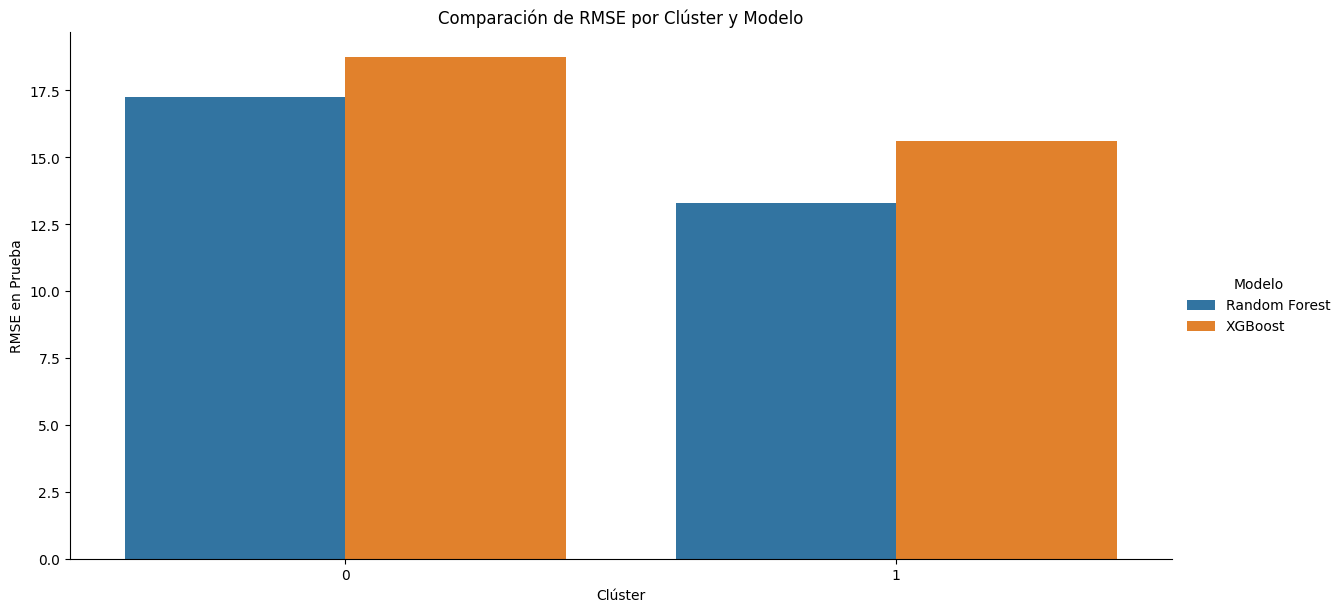

<Figure size 1200x800 with 0 Axes>

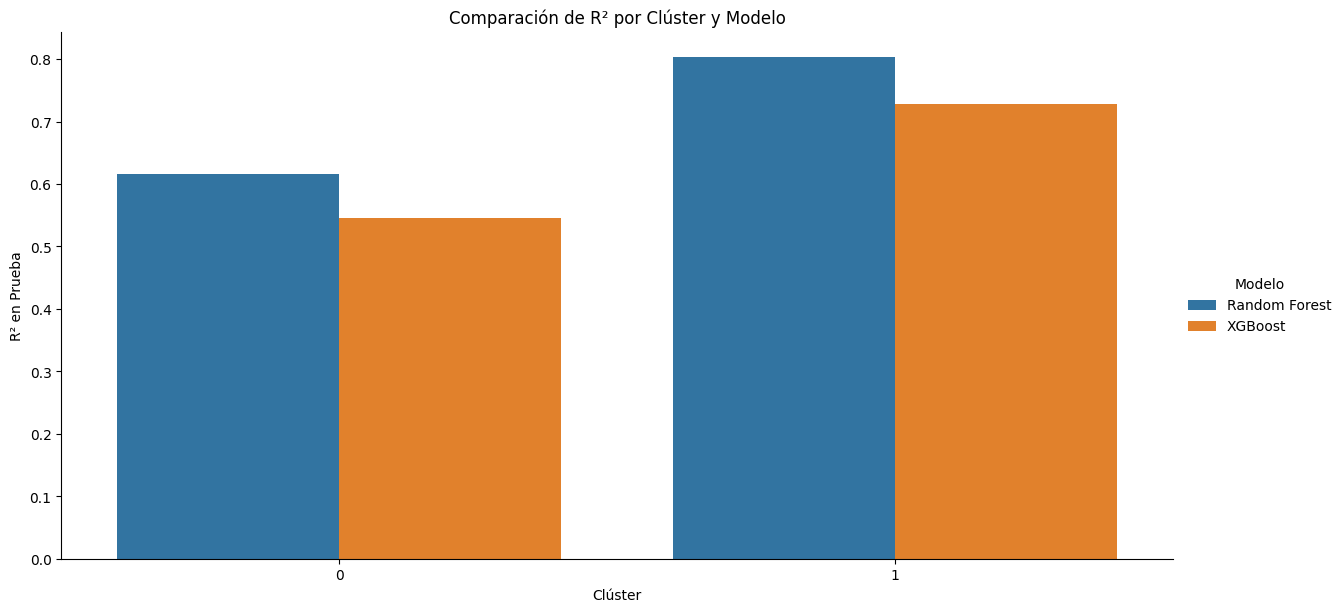

<Figure size 1200x800 with 0 Axes>

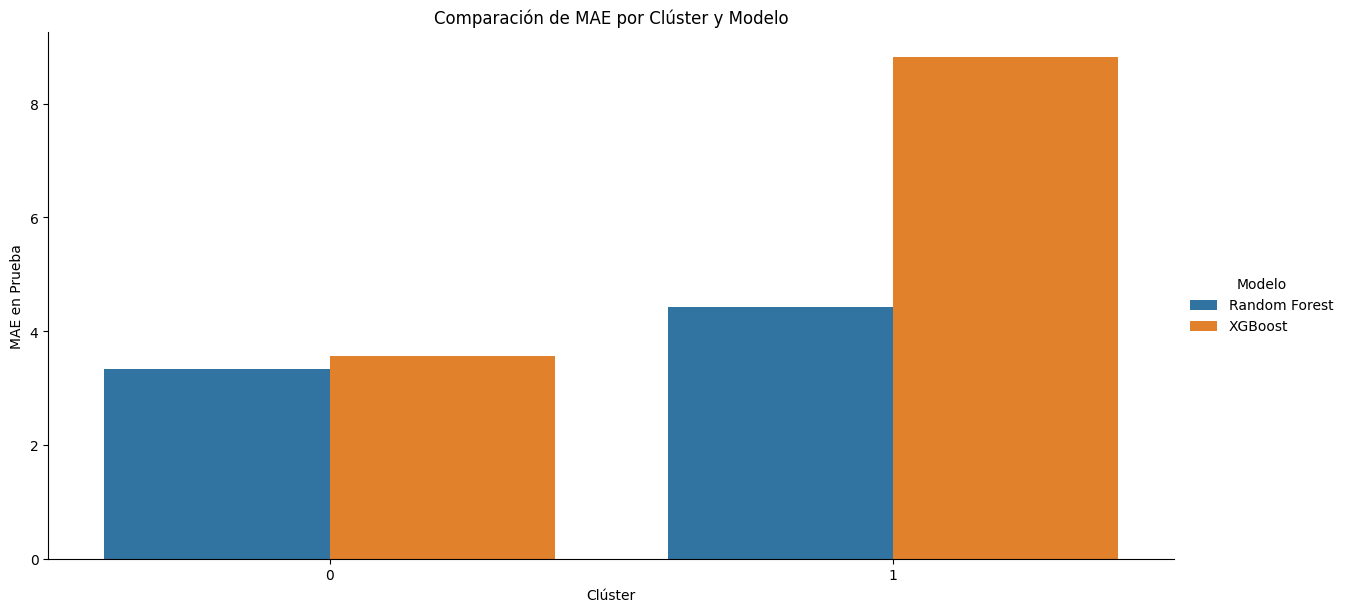

In [67]:
# -------------------------------
# 11. Visualización de Resultados
# -------------------------------
print("\n=== Sección 11: Visualización de Resultados ===")

if resultados_combinados is not None and not resultados_combinados.empty:
    # Comparación de RMSE por Modelo y Clúster (Gráfico de barras)
    plt.figure(figsize=(12, 8))
    sns.catplot(
        data=resultados_combinados, 
        x='Clúster', 
        y='RMSE_Prueba', 
        hue='Modelo', 
        kind='bar',  # Usar barras en lugar de boxplot
        height=6, 
        aspect=2
    )
    plt.title('Comparación de RMSE por Clúster y Modelo')
    plt.xlabel('Clúster')
    plt.ylabel('RMSE en Prueba')
    plt.show()

    # Comparación de R² por Modelo y Clúster (Gráfico de barras)
    plt.figure(figsize=(12, 8))
    sns.catplot(
        data=resultados_combinados, 
        x='Clúster', 
        y='R2_Prueba', 
        hue='Modelo', 
        kind='bar',  # Usar barras en lugar de boxplot
        height=6, 
        aspect=2
    )
    plt.title('Comparación de R² por Clúster y Modelo')
    plt.xlabel('Clúster')
    plt.ylabel('R² en Prueba')
    plt.show()

    # Comparación de MAE por Modelo y Clúster (Gráfico de barras)
    plt.figure(figsize=(12, 8))
    sns.catplot(
        data=resultados_combinados, 
        x='Clúster', 
        y='MAE_Prueba', 
        hue='Modelo', 
        kind='bar',  # Usar barras en lugar de boxplot
        height=6, 
        aspect=2
    )
    plt.title('Comparación de MAE por Clúster y Modelo')
    plt.xlabel('Clúster')
    plt.ylabel('MAE en Prueba')
    plt.show()
else:
    print("\nNo hay resultados combinados para visualizar.")


=== BLOQUE 12: Visualización de Importancia de Características ===

Nombres de features que se asumirán para los gráficos de importancia: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROA_l_lag1', 'ROCE_l_lag1', 'ROI_l_lag1', 'Total Activos_l_lag1', 'dif_CPI_promedio_lag1', 'dif_FFR_promedio_lag1', 'dif_NFP_promedio_lag1']

Visualizando importancia de características para Random Forest en el clúster 0...


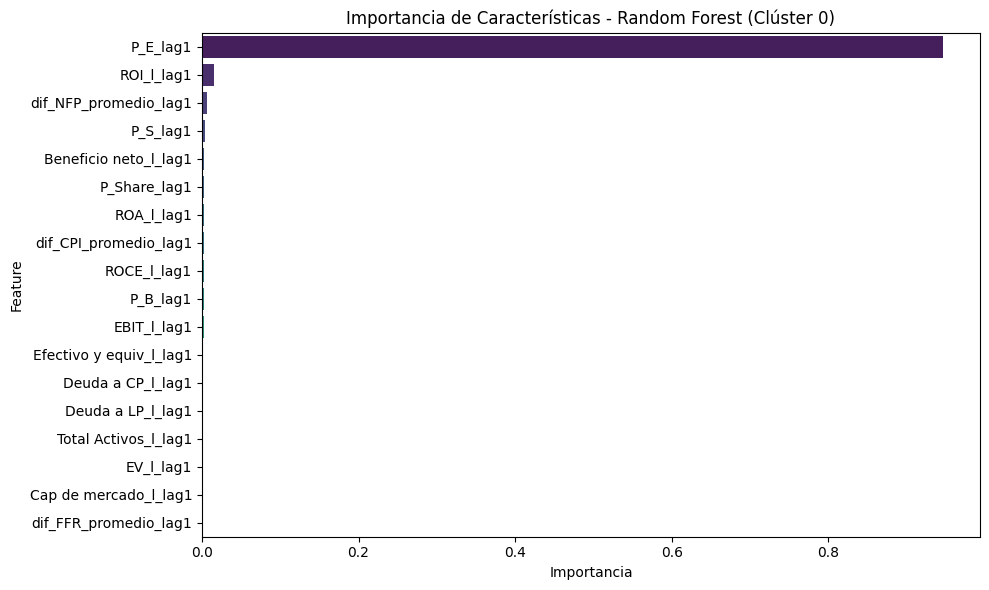


Visualizando importancia de características para Random Forest en el clúster 1...


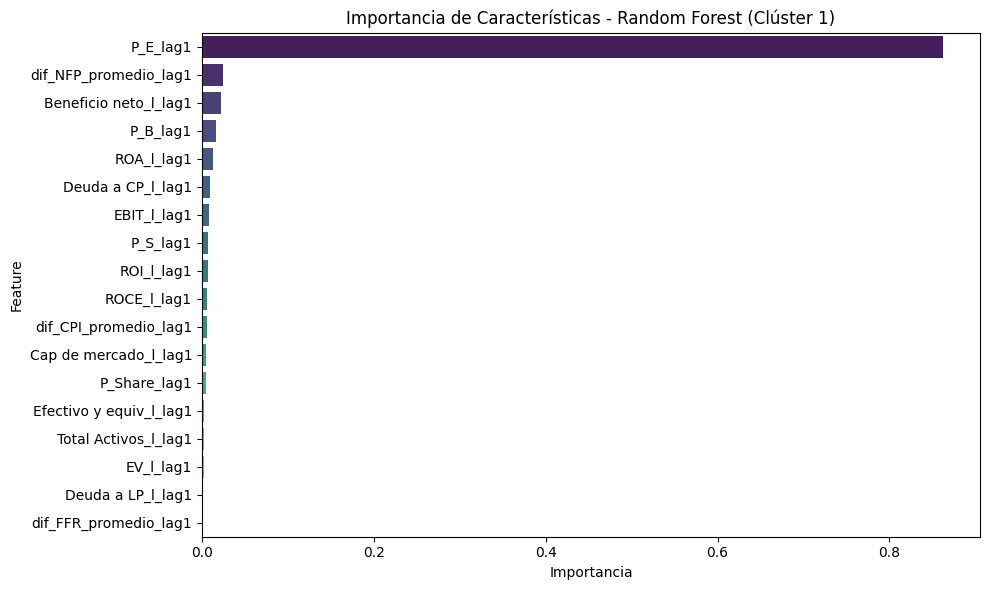


Visualizando importancia de características para XGBoost en el clúster 0...


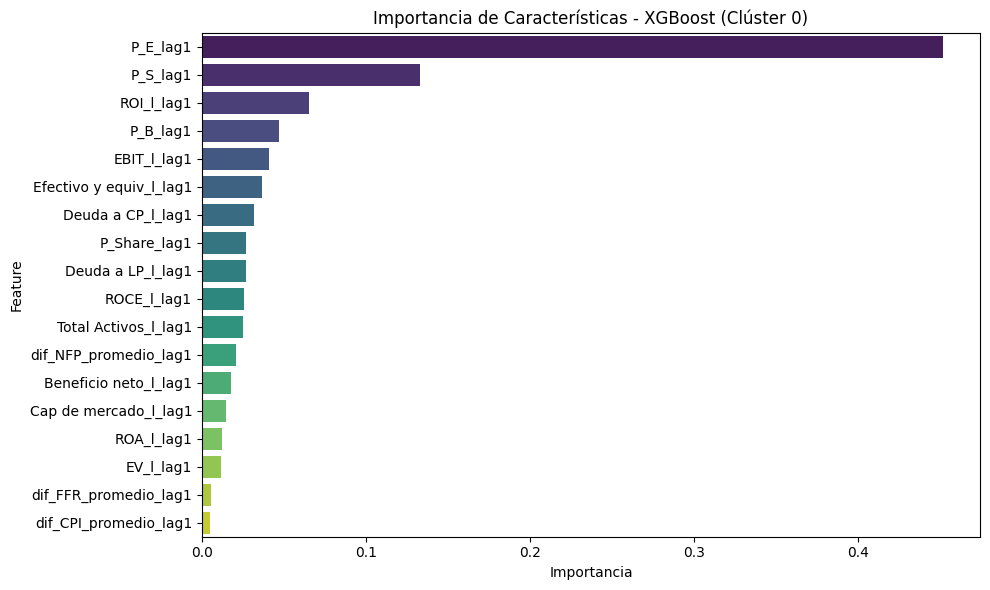


Visualizando importancia de características para XGBoost en el clúster 1...


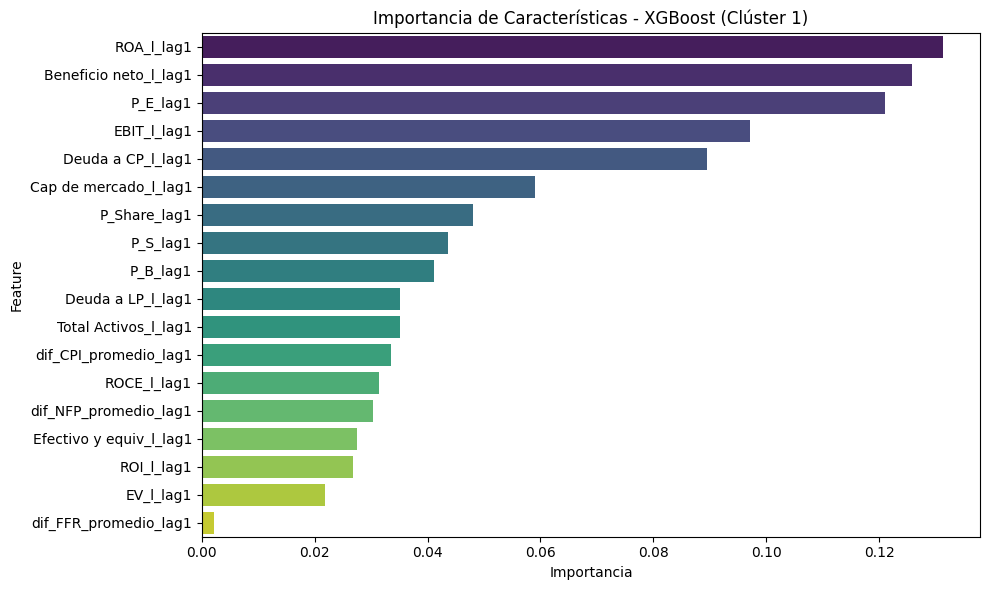

In [69]:
# ---------------------------------------------------------------------------------
# BLOQUE 12 ADAPTADO: Visualización de Importancia de Características
# ---------------------------------------------------------------------------------
print("\n=== BLOQUE 12: Visualización de Importancia de Características ===")

def visualizar_importancia_caracteristicas(modelo, feature_names, tipo_modelo='Random Forest', cluster_id=None): # Añadido cluster_id para el título
    """
    Visualiza la importancia de las características para un modelo dado.
    """
    if tipo_modelo not in ['Random Forest', 'XGBoost']:
        raise ValueError("tipo_modelo debe ser 'Random Forest' o 'XGBoost'")

    if not hasattr(modelo, 'feature_importances_'):
        print(f"  ADVERTENCIA: El modelo {tipo_modelo} para clúster {cluster_id} no tiene 'feature_importances_'. Saltando.")
        return

    importances = modelo.feature_importances_

    # Asegurarse de que feature_names tenga la misma longitud que importances
    if len(feature_names) != len(importances):
        print(f"  ERROR: Discrepancia en longitud. Features esperadas: {len(feature_names)}, Importancias obtenidas: {len(importances)}")
        print(f"  Nombres de features pasados: {feature_names}")
        # Intenta obtener feature_names_in_ del modelo si está disponible y coincide
        if hasattr(modelo, 'feature_names_in_') and len(modelo.feature_names_in_) == len(importances):
            print("  Usando 'feature_names_in_' del modelo.")
            feature_names_actual = modelo.feature_names_in_
        else:
            print("  No se puede determinar los nombres correctos de las features. Saltando gráfico.")
            return
    else:
        feature_names_actual = feature_names


    feature_importance_df = pd.DataFrame({
        'Feature': feature_names_actual,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, max(6, len(feature_names_actual) * 0.3))) # Ajustar altura dinámicamente
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis') # Mostrar top 20
    plt.xlabel('Importancia')
    plt.title(f'Importancia de Características - {tipo_modelo} (Clúster {cluster_id})')
    plt.tight_layout() # Añadido para mejor ajuste
    plt.show()

# --- Definir la lista de nombres de features que los modelos USARON ---
# Estas son las columnas de X_train_cluster_features DENTRO de la función entrenar_evaluar_modelos_por_cluster.
# Esencialmente, son las features rezagadas originales (después del escalado del Bloque 6)
# SIN 'Empresa', 'Fecha', 'time_step', y SIN la propia columna 'Cluster'.

# Si X_train_features_para_modelo (del Bloque 6/8) es el DataFrame que contiene
# las features escaladas y 'Cluster', entonces las features para el modelo son esas menos 'Cluster'.
if 'X_train_features_para_modelo' not in locals():
    raise NameError("'X_train_features_para_modelo' no está definido. Ejecuta los bloques anteriores.")

# Las features que realmente entraron al .fit() del modelo RF/XGB dentro de cada clúster
# serían las columnas de X_train_features_para_modelo EXCEPTO 'Cluster' (y las IDs si aún estuvieran).
# Asumiendo que X_train_features_para_modelo ya tiene las features correctas (escaladas) y 'Cluster'.
features_usadas_en_modelo_por_cluster = [
    col for col in X_train_features_para_modelo.columns
    if col not in ['Cluster'] # Excluir 'Cluster' ya que no es una feature predictiva para el modelo del clúster
    # Y también excluir otras IDs si accidentalmente quedaron en X_train_features_para_modelo
    # and col not in ['Empresa', 'Fecha', 'time_step'] # Esto ya debería haberse manejado
]
print(f"\nNombres de features que se asumirán para los gráficos de importancia: {features_usadas_en_modelo_por_cluster}")


# Visualizar la importancia de características para el mejor modelo de cada clúster
if 'resultados_combinados' in locals() and resultados_combinados is not None and not resultados_combinados.empty:
    for _, row in resultados_combinados.iterrows(): # Iterar sobre cada modelo entrenado
        cluster_id = row['Clúster']
        modelo_tipo = row['Modelo'] # 'Random Forest' o 'XGBoost'
        ruta_modelo = row['Ruta_Modelo']

        if pd.isna(ruta_modelo) or ruta_modelo == "No guardado":
            print(f"No hay modelo guardado para {modelo_tipo} en el clúster {cluster_id}. Saltando.")
            continue
        
        try:
            modelo_cargado = joblib.load(ruta_modelo)
            print(f"\nVisualizando importancia de características para {modelo_tipo} en el clúster {cluster_id}...")
            visualizar_importancia_caracteristicas(
                modelo_cargado,
                features_usadas_en_modelo_por_cluster, # Pasar la lista de nombres de features
                tipo_modelo=modelo_tipo,
                cluster_id=cluster_id
            )
        except FileNotFoundError:
            print(f"Error: Archivo del modelo no encontrado en {ruta_modelo} para {modelo_tipo} clúster {cluster_id}.")
        except Exception as e:
            print(f"Error al cargar o visualizar el modelo {ruta_modelo} para {modelo_tipo} clúster {cluster_id}: {e}")
else:
    print("\nNo hay 'resultados_combinados' para visualizar la importancia de características, o está vacío.")

In [95]:
# -------------------------------
# 13. Selección de los Mejores Modelos por Clúster
# -------------------------------
print("\n=== Sección 13: Selección de los Mejores Modelos por Clúster ===")

# Verificar si resultados_combinados existe y no está vacío
if resultados_combinados is not None and not resultados_combinados.empty:
    print("\nSeleccionando el mejor modelo para cada clúster (basado en menor RMSE)...")
    
    # Seleccionar el mejor modelo para cada clúster basado en el menor RMSE
    mejores_resultados = resultados_combinados.loc[
        resultados_combinados.groupby('Clúster')['RMSE_Prueba'].idxmin()
    ].reset_index(drop=True)
    
    print("\nMejores modelos por clúster:")
    print(mejores_resultados[['Clúster', 'Modelo', 'R2_Prueba', 'RMSE_Prueba', 'MAE_Prueba']])
    
    # Construir un diccionario con el mejor modelo para cada clúster
    mejores_modelos_por_cluster = {}
    
    for _, row in mejores_resultados.iterrows():
        cluster = row['Clúster']
        modelo = row['Modelo']
        
        # Crear la ruta usando os.path.join con el nuevo formato
        if modelo == "XGBoost":
            path = os.path.join("modelos_xgboost", f"xgb_cluster_{cluster}_best.joblib")
        elif modelo == "Random Forest":
            path = os.path.join("modelos_random_forest", f"rf_cluster_{cluster}_best.joblib")
        else:
            path = "ruta_desconocida.joblib"
        
        mejores_modelos_por_cluster[cluster] = path
    
    print("\nDiccionario de mejores modelos por clúster:")
    print(mejores_modelos_por_cluster)
else:
    print("\nNo hay resultados combinados para seleccionar los mejores modelos.")
    mejores_modelos_por_cluster = {}


=== Sección 13: Selección de los Mejores Modelos por Clúster ===

Seleccionando el mejor modelo para cada clúster (basado en menor RMSE)...

Mejores modelos por clúster:
   Clúster         Modelo  R2_Prueba  RMSE_Prueba  MAE_Prueba
0        0  Random Forest   0.615646    17.255864    3.332036
1        1  Random Forest   0.803236    13.276587    4.431832

Diccionario de mejores modelos por clúster:
{0: 'modelos_random_forest\\rf_cluster_0_best.joblib', 1: 'modelos_random_forest\\rf_cluster_1_best.joblib'}


In [71]:
# -------------------------------
# 14. Guardado de los Mejores Resultados
# -------------------------------
print("\n=== Sección 14: Guardado de los Mejores Resultados ===")

if 'mejores_resultados' in locals() and mejores_resultados is not None and not mejores_resultados.empty:
    # Guardar con un sufijo dinámico para evitar sobrescritura
    nombre_archivo = f'mejores_resultados_{suffix}.csv'
    mejores_resultados.to_csv(nombre_archivo, index=False)
    print(f"\nArchivo '{nombre_archivo}' creado exitosamente.")
else:
    print("\nNo hay mejores resultados para guardar.")


=== Sección 14: Guardado de los Mejores Resultados ===

Archivo 'mejores_resultados_3m_step80.csv' creado exitosamente.


In [90]:
import pandas as pd
import numpy as np

# --- ASUNCIONES ---
# 1. df_dlocal: Ya está cargado y preprocesado con las columnas base, incluyendo:
#    'dif_CPI_promedio', 'dif_FFR_promedio', 'dif_NFP_promedio'
#    (además de las otras como 'P_E', 'ROA_l', etc.)
# 2. listas_columnas: Diccionario definido que contiene la lista de columnas base para 'lineal_promedio'.
# 3. create_lags: Tu función para crear lags está definida.
# 4. empresa_objetivo_dlocal: Definido como "DLO US Equity" (o el ticker correcto).

# --- Verificar que las variables necesarias existen ---
if 'df_dlocal' not in locals():
    raise NameError("'df_dlocal' no está definido. Cárgalo y preprocésalo primero.")
if 'listas_columnas' not in locals():
    raise NameError("'listas_columnas' no está definido.")
if 'create_lags' not in locals() or not callable(create_lags):
    raise NameError("La función 'create_lags' no está definida.")

print(f"\n--- Preparando DataFrame de DLocal con Lags basados en PROMEDIOS ---")

# --- Paso 1: Definir las columnas base para los lags ---
# Usaremos las columnas definidas para 'lineal_promedio', asegurándonos de que
# para las diferencias macro, se usen las versiones '_promedio'.

nombre_metodo_base = 'lineal_promedio'
if nombre_metodo_base not in listas_columnas:
    raise KeyError(f"El método '{nombre_metodo_base}' no se encuentra en 'listas_columnas'.")

columnas_base_del_metodo = listas_columnas[nombre_metodo_base]

# Ajustar para asegurar que se usan las versiones '_promedio' de las diferencias macro
# y no las '_mediana' si ambas estuvieran en la lista original de 'lineal_promedio'.
columnas_base_para_dlocal_promedio = []
for col in columnas_base_del_metodo:
    if col.endswith("_mediana") and col.replace("_mediana", "_promedio") in df_dlocal.columns:
        # Si la lista tiene la versión mediana pero existe la promedio en df_dlocal, preferir promedio
        columnas_base_para_dlocal_promedio.append(col.replace("_mediana", "_promedio"))
    elif col not in df_dlocal.columns and col.replace("_promedio", "_mediana") in df_dlocal.columns:
        # Si la lista tiene la versión promedio pero solo existe la mediana en df_dlocal (menos ideal para este objetivo)
        print(f"ADVERTENCIA: Se esperaba '{col}' (promedio) pero solo se encontró '{col.replace('_promedio', '_mediana')}' en df_dlocal.")
        columnas_base_para_dlocal_promedio.append(col.replace("_promedio", "_mediana"))
    elif col in df_dlocal.columns:
        columnas_base_para_dlocal_promedio.append(col)
    # else: la columna no existe en df_dlocal ni su contraparte, se omitirá más adelante

# Asegurar que 'P_E' esté si se va a generar P_E_lag1
# (asumiendo que features_usadas_para_secuencias o features_usadas_en_modelo_por_cluster lo requieren)
# Esta lógica es una salvaguarda; idealmente, listas_columnas ya es correcta.
if ('P_E_lag1' in features_usadas_para_secuencias or 'P_E_lag1' in features_usadas_en_modelo_por_cluster) and \
   'P_E' not in columnas_base_para_dlocal_promedio and 'P_E' in df_dlocal.columns:
    columnas_base_para_dlocal_promedio.append('P_E')

columnas_base_para_dlocal_promedio = sorted(list(set(columnas_base_para_dlocal_promedio)))

# Verificar que las columnas base seleccionadas realmente existan en df_dlocal
columnas_base_finales_para_lags = [col for col in columnas_base_para_dlocal_promedio if col in df_dlocal.columns]
missing_cols = set(columnas_base_para_dlocal_promedio) - set(columnas_base_finales_para_lags)
if missing_cols:
    print(f"ADVERTENCIA: Las siguientes columnas base (después del ajuste a '_promedio') no se encontraron en df_dlocal y se omitirán para los lags: {missing_cols}")

if not columnas_base_finales_para_lags:
    raise ValueError("No hay columnas base válidas seleccionadas para generar lags para DLocal.")

print(f"Columnas base finales que se usarán para generar lags para DLocal: {columnas_base_finales_para_lags}")

# --- Paso 2: Crear los lags ---
# La función create_lags necesita 'Empresa' y 'Fecha'.
if not all(col in df_dlocal.columns for col in ['Empresa', 'Fecha']):
    raise ValueError("df_dlocal debe contener las columnas 'Empresa' y 'Fecha' para crear lags.")

# Asegurar que df_dlocal esté ordenado antes de crear lags si create_lags no lo hace internamente
df_dlocal_sorted = df_dlocal.sort_values(['Empresa', 'Fecha'])

df_dlocal_con_promedio_lags_temp = create_lags(
    df_dlocal_sorted,
    group_col='Empresa',
    date_col='Fecha',
    features=columnas_base_finales_para_lags,
    lag=1 # Asumiendo que todos los lags son de 1 período
)
print("Lags generados.")

# --- Paso 3: Definir las columnas rezagadas esperadas y eliminar NaNs ---
# Esta lista debe coincidir con 'features_usadas_para_secuencias' (que se usa para clustering)
# y con las features rezagadas en 'features_usadas_en_modelo_por_cluster'.
# Es crucial que esta lista contenga los nombres con '_promedio_lag1'.

# Reconstruir la lista de lags esperados basada en las columnas base que SÍ se usaron para generar lags
# y asegurando que sean las versiones _promedio_lag1 si las originales eran _promedio.
# Esto es para asegurar que el dropna se haga sobre las columnas correctas.
columnas_lag_generadas_promedio = []
for col_base in columnas_base_finales_para_lags:
    # Si la columna base ya era una de las de promedio (ej. 'dif_CPI_promedio'), su lag será 'dif_CPI_promedio_lag1'
    # Si la columna base era otra (ej. 'ROA_l'), su lag será 'ROA_l_lag1'
    columnas_lag_generadas_promedio.append(f"{col_base}_lag1")

# Verificar que las columnas en 'features_usadas_para_secuencias' (que son las que el modelo de clustering espera)
# realmente se hayan generado.
missing_expected_lags = [col for col in features_usadas_para_secuencias if col not in df_dlocal_con_promedio_lags_temp.columns]
if missing_expected_lags:
    print(f"ERROR CRÍTICO: Las siguientes columnas rezagadas esperadas por el modelo de clustering NO se pudieron generar para DLocal: {missing_expected_lags}")
    print(f"Columnas disponibles con lags en DLocal: {df_dlocal_con_promedio_lags_temp.columns[df_dlocal_con_promedio_lags_temp.columns.str.contains('_lag1')]}")
    raise ValueError("Discrepancia en las features rezagadas generadas para DLocal y las esperadas por los modelos entrenados.")

# Eliminar NaNs usando la lista de features que el modelo de clustering espera (features_usadas_para_secuencias)
df_dlocal_con_promedio_lags = df_dlocal_con_promedio_lags_temp.dropna(subset=features_usadas_para_secuencias).copy()

if df_dlocal_con_promedio_lags.empty:
    print(f"ADVERTENCIA: El DataFrame de DLocal quedó vacío después de generar lags (versión promedio) y eliminar NaNs.")
    print(f"  Esto puede suceder si DLocal tiene muy pocas observaciones o si faltan datos base.")
else:
    print(f"DataFrame 'df_dlocal_con_promedio_lags' preparado. Dimensiones: {df_dlocal_con_promedio_lags.shape}")
    print("Primeras filas de df_dlocal_con_promedio_lags:")
    print(df_dlocal_con_promedio_lags.head())
    print("\nColumnas presentes en df_dlocal_con_promedio_lags:")
    print(df_dlocal_con_promedio_lags.columns.tolist())

# --- Ahora puedes usar 'df_dlocal_con_promedio_lags' en tu Bloque 15 ---
# Ejemplo de cómo lo usarías en la llamada a predecir_empresa:
#
# if not df_dlocal_con_promedio_lags.empty:
#     resultado_pred = predecir_empresa(
#         empresa_objetivo=empresa_objetivo_dlocal,
#         df_historico_completo_empresa=df_dlocal_con_promedio_lags, # <--- USAR ESTE
#         scaler_supervisado_path=variable_scaler_supervisado_path,
#         clustering_model_path=variable_clustering_model_path,
#         features_modelo_supervisado=variable_lista_features_modelo_supervisado, # Debe esperar _promedio_lag1
#         mejores_modelos_por_cluster=variable_mejores_modelos_por_cluster,
#         columnas_features_clustering=variable_columnas_features_clustering, # Debe ser la lista con _promedio_lag1
#         scaler_ts_clustering_path=variable_scaler_ts_clustering_path,
#         n_timesteps_clustering=best_n_timesteps,
#         step_clustering=best_step
#     )
# else:
#     print(f"No se pudo generar la predicción para {empresa_objetivo_dlocal} porque df_dlocal_con_promedio_lags está vacío.")


--- Preparando DataFrame de DLocal con Lags basados en PROMEDIOS ---
Columnas base finales que se usarán para generar lags para DLocal: ['Beneficio neto_l', 'Cap de mercado_l', 'Deuda a CP_l', 'Deuda a LP_l', 'EBIT_l', 'EV_l', 'Efectivo y equiv_l', 'P_B', 'P_E', 'P_S', 'P_Share', 'ROA_l', 'ROCE_l', 'ROI_l', 'Total Activos_l', 'dif_CPI_promedio', 'dif_FFR_promedio', 'dif_NFP_promedio']
Lags generados.
DataFrame 'df_dlocal_con_promedio_lags' preparado. Dimensiones: (27, 64)
Primeras filas de df_dlocal_con_promedio_lags:
         Empresa      Fecha       P_E      P_B      P_S  P_Share    ROCE_sp  \
1  DLO US Equity 2022-07-29  112.1826  29.2377  32.6734    27.78  36.348863   
2  DLO US Equity 2022-08-31  100.4313  26.1750  29.2508    24.87  36.509090   
3  DLO US Equity 2022-09-30   82.8649  21.5968  24.1346    20.52  35.695900   
4  DLO US Equity 2022-10-31   90.0530  23.4702  26.2281    22.30  34.364510   
5  DLO US Equity 2022-11-30   58.9585  15.3661  17.1718    14.60  32.970137   



In [96]:
# ---------------------------------------------------------------------------------
# BLOQUE 15 CORREGIDO: Llamada a la Función predecir_empresa para DLocal
# ---------------------------------------------------------------------------------

# --- Asegúrate de que estas variables cruciales estén definidas desde bloques anteriores ---
# df_dlocal_con_promedio_lags: DataFrame de DLocal CON Lags _promedio_ y NaNs de lags eliminados
#                             (generado en el bloque anterior que me acabas de mostrar la salida).
# empresa_objetivo_dlocal: El nombre de la empresa.
# features_usadas_en_modelo_por_cluster: Lista de nombres de features rezagadas que los modelos supervisados esperan (SIN 'Cluster').
# mejores_modelos_por_cluster: Diccionario {cluster_id: ruta_modelo}.
# features_usadas_para_secuencias: Lista de columnas usadas para generar las secuencias de clustering (DEBE incluir _promedio_lag1).
# best_n_timesteps, best_step: Parámetros óptimos de clustering.

print("\n=== BLOQUE 15: Predicción para DLOCAL con predecir_empresa (Usando df_dlocal_con_promedio_lags) ===")

empresa_objetivo_dlocal = "DLO US Equity" # Asegúrate que este sea el ticker exacto

# --- 0. Verificar que df_dlocal_con_promedio_lags esté definido ---
if 'df_dlocal_con_promedio_lags' not in locals() or not isinstance(df_dlocal_con_promedio_lags, pd.DataFrame):
    raise NameError("'df_dlocal_con_promedio_lags' no está definido o no es un DataFrame. Ejecuta el bloque anterior donde se crea.")

# Usar df_dlocal_con_promedio_lags directamente, ya que es específico para DLocal y tiene los lags correctos.
df_dlocal_listo_para_funcion = df_dlocal_con_promedio_lags.copy()

if df_dlocal_listo_para_funcion.empty:
    print(f"El DataFrame preparado para '{empresa_objetivo_dlocal}' ('df_dlocal_con_promedio_lags') está vacío.")
else:
    # Verificar que el DataFrame sea solo de la empresa objetivo (debería serlo si se creó correctamente)
    if not (df_dlocal_listo_para_funcion['Empresa'].astype(str).str.strip() == empresa_objetivo_dlocal.strip()).all():
        print(f"ADVERTENCIA: 'df_dlocal_listo_para_funcion' parece contener datos de más empresas que solo '{empresa_objetivo_dlocal}'.")
        print(f"  Valores únicos de 'Empresa': {df_dlocal_listo_para_funcion['Empresa'].unique()}")
        # Podrías re-filtrar aquí por si acaso, aunque idealmente df_dlocal_con_promedio_lags ya es solo de DLocal.
        df_dlocal_listo_para_funcion = df_dlocal_listo_para_funcion[
            df_dlocal_listo_para_funcion['Empresa'].astype(str).str.strip() == empresa_objetivo_dlocal.strip()
        ].copy()
        if df_dlocal_listo_para_funcion.empty:
            print(f"  Después de re-filtrar, no quedaron datos para '{empresa_objetivo_dlocal}'.")
            # sys.exit("Deteniendo debido a datos vacíos después de re-filtrar.") # Descomentar para detener


    print(f"Datos listos para '{empresa_objetivo_dlocal}' para la función predecir_empresa. Dimensiones: {df_dlocal_listo_para_funcion.shape}")

    # --- 1. Definir la lista de features que el modelo supervisado espera ---
    if 'features_usadas_en_modelo_por_cluster' not in locals():
        raise NameError("'features_usadas_en_modelo_por_cluster' no está definida.")
    variable_lista_features_modelo_supervisado = features_usadas_en_modelo_por_cluster + ['Cluster']
    print(f"Features para el modelo supervisado: {variable_lista_features_modelo_supervisado}")

    # --- 2. Definir las columnas usadas para el clustering ---
    #    Esta lista DEBE ser la que contiene las versiones _promedio_lag1
    if 'features_usadas_para_secuencias' not in locals():
        raise NameError("'features_usadas_para_secuencias' no está definida.")
    # Verificar que features_usadas_para_secuencias realmente contenga las _promedio_lag1
    if not all(f"_promedio_lag1" in col for col in features_usadas_para_secuencias if "dif_" in col and "_lag1" in col):
        print(f"ADVERTENCIA: 'features_usadas_para_secuencias' podría no contener las versiones '_promedio_lag1' de las diferencias macro.")
        print(f"  Contenido de features_usadas_para_secuencias: {features_usadas_para_secuencias}")
    variable_columnas_features_clustering = features_usadas_para_secuencias
    print(f"Features para generar secuencias de clustering: {variable_columnas_features_clustering}")

    # --- 3. Definir rutas y parámetros de clustering ---
    if 'best_n_timesteps' not in locals() or 'best_step' not in locals():
        raise NameError("'best_n_timesteps' o 'best_step' no están definidos.")
    current_suffix_pred = f"{best_n_timesteps}m_step{best_step}"
    print(f"Usando suffix para archivos de clustering: {current_suffix_pred}")

    variable_scaler_supervisado_path = "scaler_supervisado_modelos.joblib"
    variable_clustering_model_path = f"kmeans_rolling_dtw_{current_suffix_pred}.joblib"
    variable_scaler_ts_clustering_path = f"scaler_ts_rolling_dtw_{current_suffix_pred}.joblib"

    # --- 4. Asegurar que 'mejores_modelos_por_cluster' está definido ---
    if 'mejores_modelos_por_cluster' not in locals():
        raise NameError("'mejores_modelos_por_cluster' no está definido.")
    variable_mejores_modelos_por_cluster = mejores_modelos_por_cluster

    # --- 5. Llamar a la función predecir_empresa ---
    # Asegúrate de que la función predecir_empresa (la versión corregida del Bloque 15) esté definida.
    
    resultados_prediccion_dlocal = predecir_empresa(
        empresa_objetivo=empresa_objetivo_dlocal,
        df_historico_completo_empresa=df_dlocal_listo_para_funcion, # <--- USAR EL DF DE DLOCAL CON LAGS _PROMEDIO_
        scaler_supervisado_path=variable_scaler_supervisado_path,
        clustering_model_path=variable_clustering_model_path,
        features_modelo_supervisado=variable_lista_features_modelo_supervisado,
        mejores_modelos_por_cluster=variable_mejores_modelos_por_cluster,
        columnas_features_clustering=variable_columnas_features_clustering,
        scaler_ts_clustering_path=variable_scaler_ts_clustering_path,
        n_timesteps_clustering=best_n_timesteps,
        step_clustering=best_step
    )

    if resultados_prediccion_dlocal is not None:
        print(f"\nPredicciones finales para {empresa_objetivo_dlocal}:")
        print(resultados_prediccion_dlocal.tail())
    else:
        print(f"No se pudo generar la predicción para {empresa_objetivo_dlocal}.")


=== BLOQUE 15: Predicción para DLOCAL con predecir_empresa (Usando df_dlocal_con_promedio_lags) ===
Datos listos para 'DLO US Equity' para la función predecir_empresa. Dimensiones: (27, 64)
Features para el modelo supervisado: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROA_l_lag1', 'ROCE_l_lag1', 'ROI_l_lag1', 'Total Activos_l_lag1', 'dif_CPI_promedio_lag1', 'dif_FFR_promedio_lag1', 'dif_NFP_promedio_lag1', 'Cluster']
Features para generar secuencias de clustering: ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROA_l_lag1', 'ROCE_l_lag1', 'ROI_l_lag1', 'Total Activos_l_lag1', 'dif_CPI_promedio_lag1', 'dif_FFR_promedio_lag1', 'dif_NFP_promedio_lag1']
Usando suffix para archivos d

In [97]:
import os
import shutil # Para eliminar carpetas si es necesario

# Nombres de las carpetas donde se guardan los modelos por clúster
carpeta_rf_cluster = "modelos_random_forest_por_cluster"
carpeta_xgb_cluster = "modelos_xgboost_por_cluster" # Si también entrenas XGBoost por clúster

# Eliminar archivos individuales o carpetas enteras
# Opción A: Eliminar archivos específicos si conoces los clústeres
# clusters_a_limpiar = [0, 1] # O los clústeres que tengas
# for cluster_id in clusters_a_limpiar:
#     rf_model_path = os.path.join(carpeta_rf_cluster, f"rf_cluster_{cluster_id}_best.joblib")
#     xgb_model_path = os.path.join(carpeta_xgb_cluster, f"xgb_cluster_{cluster_id}_best.joblib")
#     if os.path.exists(rf_model_path):
#         os.remove(rf_model_path)
#         print(f"Eliminado: {rf_model_path}")
#     if os.path.exists(xgb_model_path):
#         os.remove(xgb_model_path)
#         print(f"Eliminado: {xgb_model_path}")

# Opción B: Eliminar las carpetas enteras (más drástico, pero asegura limpieza total de esos modelos)
# ¡CUIDADO! Esto eliminará todos los modelos en estas carpetas.
if os.path.exists(carpeta_rf_cluster):
    shutil.rmtree(carpeta_rf_cluster)
    print(f"Carpeta eliminada: {carpeta_rf_cluster}")
if os.path.exists(carpeta_xgb_cluster):
    shutil.rmtree(carpeta_xgb_cluster)
    print(f"Carpeta eliminada: {carpeta_xgb_cluster}")

# Volver a crear las carpetas vacías para que el guardado funcione
os.makedirs(carpeta_rf_cluster, exist_ok=True)
os.makedirs(carpeta_xgb_cluster, exist_ok=True)
print(f"Carpetas {carpeta_rf_cluster} y {carpeta_xgb_cluster} aseguradas/recreadas.")

Carpetas modelos_random_forest_por_cluster y modelos_xgboost_por_cluster aseguradas/recreadas.


In [98]:
# ---------------------------------------------------------------------------------
# BLOQUE 7 COMPLETO: Definición de la Función de Entrenamiento por Clúster
# ---------------------------------------------------------------------------------
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold, KFold, ParameterGrid # <--- ParameterGrid importado
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import traceback # Para imprimir tracebacks completos en excepciones

print("\n=== BLOQUE 7: Definición de la Función de Entrenamiento por Clúster (Completa y Adaptada) ===")

def entrenar_evaluar_modelos_por_cluster(
    df_train_full_input,  # DataFrame completo de entrenamiento (features + Cluster + Empresa + otras IDs)
    y_train_input,        # Serie del target de entrenamiento, alineada con df_train_full_input
    df_test_full_input,   # DataFrame completo de prueba (features + Cluster + Empresa + otras IDs)
    y_test_input,         # Serie del target de prueba, alineada con df_test_full_input
    param_grid_rf,        # Grid de hiperparámetros para Random Forest
    param_grid_xgb,       # Grid de hiperparámetros para XGBoost
    model_type='rf',      # Tipo de modelo: 'rf' o 'xgb'
    n_iter=10             # Número de iteraciones para RandomizedSearchCV
):
    """
    Entrena y evalúa el mejor modelo por clúster con búsqueda de hiperparámetros.
    - df_train_full_input y df_test_full_input DEBEN contener:
        * Las features preprocesadas (ej. escaladas).
        * La columna 'Cluster' (entero).
        * La columna 'Empresa' para GroupKFold.
        * Otras columnas de ID ('Fecha', 'time_step') que se eliminarán antes del modelado.
    - y_train_input, y_test_input: Series del target.
    """
    resultados = []

    if 'Cluster' not in df_train_full_input.columns or 'Empresa' not in df_train_full_input.columns:
        raise ValueError("df_train_full_input debe contener las columnas 'Cluster' y 'Empresa'.")
    if 'Cluster' not in df_test_full_input.columns: # 'Empresa' no es estrictamente necesaria en test para GroupKFold, pero sí 'Cluster'
        raise ValueError("df_test_full_input debe contener la columna 'Cluster'.")

    # Asegurar alineación inicial (salvaguarda)
    common_idx_train = df_train_full_input.index.intersection(y_train_input.index)
    df_train_aligned = df_train_full_input.loc[common_idx_train]
    y_train_aligned = y_train_input.loc[common_idx_train]

    common_idx_test = df_test_full_input.index.intersection(y_test_input.index)
    df_test_aligned = df_test_full_input.loc[common_idx_test]
    y_test_aligned = y_test_input.loc[common_idx_test]

    clusters_unicos = sorted(df_train_aligned['Cluster'].unique()) # Usar sorted para un orden consistente
    print(f"\nTipo de Modelo a entrenar: {'Random Forest' if model_type == 'rf' else 'XGBoost'}")
    print(f"Clústeres únicos identificados en datos de entrenamiento: {clusters_unicos}")

    # Columnas a eliminar de las features antes de pasar al modelo
    # Estas son columnas de ID o etiquetas que no son predictoras directas para el modelo de ese clúster.
    cols_to_drop_from_features = ['Empresa', 'Fecha', 'time_step', 'Cluster']

    for cluster_val in clusters_unicos:
        print(f"\n--- Procesando Clúster {cluster_val} ---")

        # --- Preparar datos de ENTRENAMIENTO para este clúster ---
        mask_train_cluster = df_train_aligned['Cluster'] == cluster_val
        
        X_train_cluster_full_df = df_train_aligned.loc[mask_train_cluster]
        y_train_cluster = y_train_aligned.loc[mask_train_cluster].copy().reset_index(drop=True)
        groups_cluster_train = X_train_cluster_full_df['Empresa'].copy().reset_index(drop=True)
        
        X_train_cluster_features = X_train_cluster_full_df.drop(
            columns=cols_to_drop_from_features, errors='ignore' # errors='ignore' por si alguna ya no está
        ).reset_index(drop=True)
        
        if X_train_cluster_features.empty or len(X_train_cluster_features) < 5: # Umbral mínimo para CV/entrenamiento
             print(f"  Muy pocos datos de entrenamiento ({len(X_train_cluster_features)}) para el clúster {cluster_val}. Saltando este clúster.")
             continue

        if X_train_cluster_features.isnull().any().any() or y_train_cluster.isnull().any() or groups_cluster_train.isnull().any():
            print(f"  Error: Se encontraron NaNs en los datos preparados para el clúster {cluster_val}. Saltando.")
            # print(f"    NaNs en X_train_cluster_features: {X_train_cluster_features.isnull().sum().sum()}")
            # print(f"    NaNs en y_train_cluster: {y_train_cluster.isnull().sum()}")
            # print(f"    NaNs en groups_cluster_train: {groups_cluster_train.isnull().sum()}")
            continue
        
        print(f"  Tamaño de datos de entrenamiento para clúster {cluster_val}: {X_train_cluster_features.shape[0]} muestras, {X_train_cluster_features.shape[1]} features.")

        # --- Preparar datos de PRUEBA para este clúster ---
        mask_test_cluster = df_test_aligned['Cluster'] == cluster_val
        X_test_cluster_full_df = df_test_aligned.loc[mask_test_cluster]
        y_test_cluster = y_test_aligned.loc[mask_test_cluster].copy().reset_index(drop=True)
        
        X_test_cluster_features = X_test_cluster_full_df.drop(
            columns=cols_to_drop_from_features, errors='ignore'
        ).reset_index(drop=True)

        if X_test_cluster_features.empty:
            print(f"  No hay datos de prueba para el clúster {cluster_val}.")
        else:
            print(f"  Tamaño de datos de prueba para clúster {cluster_val}: {X_test_cluster_features.shape[0]} muestras.")

        # --- Definir Modelo y Búsqueda de Hiperparámetros ---
        if model_type == 'rf':
            modelo = RandomForestRegressor(random_state=42, n_jobs=-1)
            param_distributions = param_grid_rf
        elif model_type == 'xgb':
            modelo = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1, verbosity=0) # verbosity=0 para menos output
            param_distributions = param_grid_xgb
        else:
            raise ValueError("model_type debe ser 'rf' o 'xgb'")

        # Configurar estrategia de Validación Cruzada
        cv_strategy = None
        fit_params_cv = {} # Parámetros adicionales para .fit() de GridSearchCV (como 'groups')
        n_unique_groups_in_cluster = groups_cluster_train.nunique()
        min_samples_for_cv = 5 # Un umbral razonable para que CV tenga sentido

        if n_unique_groups_in_cluster >= 2 and len(X_train_cluster_features) >= min_samples_for_cv :
            n_splits_gkf = min(3, n_unique_groups_in_cluster) 
            n_splits_gkf = max(2, n_splits_gkf) 
            if len(X_train_cluster_features) >= n_splits_gkf:
                cv_strategy = GroupKFold(n_splits=n_splits_gkf)
                fit_params_cv = {'groups': groups_cluster_train}
                print(f"  Usando GroupKFold con {n_splits_gkf} splits.")
            else: # No suficientes muestras para los splits de GroupKFold
                print(f"  No suficientes muestras ({len(X_train_cluster_features)}) para GroupKFold con {n_splits_gkf} splits. Intentando KFold.")
        
        if cv_strategy is None and len(X_train_cluster_features) >= min_samples_for_cv: # Fallback a KFold
            n_splits_kf = min(3, len(X_train_cluster_features)) 
            n_splits_kf = max(2, n_splits_kf)
            if len(X_train_cluster_features) >= n_splits_kf:
                cv_strategy = KFold(n_splits=n_splits_kf, shuffle=True, random_state=42)
                print(f"  Usando KFold con {n_splits_kf} splits.")
            else: # No suficientes muestras para los splits de KFold
                print(f"  No suficientes muestras ({len(X_train_cluster_features)}) para KFold con {n_splits_kf} splits. No se usará CV para HP.")
        elif cv_strategy is None: # Si no se cumplió la condición de min_samples_for_cv
             print(f"  No suficientes muestras ({len(X_train_cluster_features)}) para CV. No se usará CV para HP.")

        # Ajustar n_iter para RandomizedSearchCV
        num_param_combinations = len(ParameterGrid(param_distributions))
        current_n_iter = min(n_iter, num_param_combinations)
        if current_n_iter < n_iter and num_param_combinations > 0 :
            print(f"  Ajustando n_iter de RandomizedSearch de {n_iter} a {current_n_iter} (total combinaciones: {num_param_combinations}).")
        
        best_model = None
        best_params_found = "Default (Configuración Inicial)" # Valor por defecto

        if cv_strategy is not None and num_param_combinations > 0 and current_n_iter > 0:
            randomized_search = RandomizedSearchCV(
                estimator=modelo,
                param_distributions=param_distributions,
                n_iter=current_n_iter,
                scoring='neg_mean_squared_error',
                cv=cv_strategy,
                verbose=0,
                random_state=42,
                n_jobs=-1
            )
            try:
                print("  Realizando búsqueda de hiperparámetros con RandomizedSearchCV...")
                randomized_search.fit(X_train_cluster_features, y_train_cluster, **fit_params_cv)
                best_model = randomized_search.best_estimator_
                best_params_found = randomized_search.best_params_
                print("  Búsqueda de hiperparámetros completada.")
            except Exception as e:
                print(f"  Error durante RandomizedSearchCV para clúster {cluster_val}: {e}")
                # traceback.print_exc() # Descomentar para debug detallado
                print("  Entrenando modelo con parámetros por defecto como fallback.")
                best_params_found = "Default (Fallo en HP Search)"
                # No reasignar 'modelo' a 'best_model' aquí, se hará después si HP falla
        else: # Condiciones para RandomizedSearch no cumplidas
            if cv_strategy is None:
                print("  No se realizará RandomizedSearchCV (estrategia de CV no aplicable).")
            elif num_param_combinations == 0:
                print("  No se realizará RandomizedSearchCV (no hay combinaciones de parámetros en el grid).")
            elif current_n_iter == 0:
                 print("  No se realizará RandomizedSearchCV (n_iter ajustado es 0).")
        
        if best_model is None: # Si HP Search no se hizo, falló, o no se asignó best_model
            print("  Entrenando modelo con parámetros por defecto.")
            try:
                modelo.fit(X_train_cluster_features, y_train_cluster)
                best_model = modelo
                # best_params_found ya tiene un valor "Default..."
            except Exception as e_fit:
                print(f"    Error entrenando modelo con params por defecto: {e_fit}")
                # traceback.print_exc() # Descomentar para debug detallado
                continue # Saltar al siguiente clúster si el entrenamiento base también falla

        # --- Evaluación y Guardado ---
        rmse_val, mae_val, r2_val = np.nan, np.nan, np.nan
        if best_model and not X_test_cluster_features.empty:
            try:
                y_pred = best_model.predict(X_test_cluster_features)
                rmse_val = np.sqrt(mean_squared_error(y_test_cluster, y_pred))
                mae_val = mean_absolute_error(y_test_cluster, y_pred)
                r2_val = r2_score(y_test_cluster, y_pred)
                print(f"    Métricas en Prueba - RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}, R²: {r2_val:.4f}")
            except Exception as e:
                print(f"    Error al predecir en el conjunto de prueba para clúster {cluster_val}: {e}")
        elif not X_test_cluster_features.empty: # Si X_test no está vacío pero no hay best_model
             print(f"    No se pudo obtener un 'best_model' para el clúster {cluster_val} para evaluar.")
        else: # X_test_cluster_features está vacío
            print(f"    No hay datos de prueba para evaluar el clúster {cluster_val}.")

        ruta_modelo = "No guardado" # Valor por defecto
        if best_model:
            nombre_modelo = f"{model_type}_cluster_{cluster_val}_best.joblib"
            carpeta_modelo = f"modelos_{model_type}_por_cluster"
            os.makedirs(carpeta_modelo, exist_ok=True) # Asegura que la carpeta exista
            ruta_modelo = os.path.join(carpeta_modelo, nombre_modelo)
            try:
                joblib.dump(best_model, ruta_modelo)
                print(f"    Mejor modelo guardado en: {ruta_modelo}")
            except Exception as e:
                print(f"    Error al guardar el modelo para clúster {cluster_val}: {e}")
        
        resultados.append({
            'Clúster': cluster_val,
            'Modelo': 'Random Forest' if model_type == 'rf' else 'XGBoost',
            'Hiperparámetros': best_params_found,
            'RMSE_Prueba': rmse_val,
            'MAE_Prueba': mae_val,
            'R2_Prueba': r2_val,
            'Ruta_Modelo': ruta_modelo,
            'N_Muestras_Train_Cluster': len(X_train_cluster_features),
            'N_Muestras_Test_Cluster': len(X_test_cluster_features) if not X_test_cluster_features.empty else 0
        })
        print(f"    Resultados para clúster {cluster_val} agregados.")

    print(f"\nFinalizando función 'entrenar_evaluar_modelos_por_cluster'. Total de configuraciones de clúster procesadas: {len(resultados)}")
    return pd.DataFrame(resultados) if resultados else pd.DataFrame() # Devolver DataFrame vacío si no hay resultados


=== BLOQUE 7: Definición de la Función de Entrenamiento por Clúster (Completa y Adaptada) ===


In [99]:
# ---------------------------------------------------------------------------------
# BLOQUE 8 COMPLETO Y ADAPTADO: Entrenamiento de Modelos Supervisados por Clúster
# ---------------------------------------------------------------------------------
print("\n=== BLOQUE 8: Entrenamiento de Modelos Supervisados por Clúster (Llamada a Función Adaptada) ===")

# --- 8.1 Definir los diccionarios de hiperparámetros ---
# Puedes ajustar estos grids según tus necesidades y tiempo de cómputo
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None], # None permite que los árboles crezcan completamente
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7], # Profundidades más pequeñas para evitar sobreajuste en subconjuntos
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9], # Fracción de muestras para entrenar cada árbol
    'colsample_bytree': [0.7, 0.8, 0.9] # Fracción de features para entrenar cada árbol
}

# --- 8.2 Verificar la existencia de las variables de entrada necesarias ---
# Estas variables deberían haber sido creadas y finalizadas en bloques anteriores.
# df_model_train_final: Contiene features escaladas (del Bloque 6), 'Cluster', 'Empresa', 'Fecha', 'time_step'.
# y_train_final: Target de entrenamiento alineado.
# df_model_test_final: Equivalente para test.
# y_test_final: Target de test alineado.

variables_necesarias = [
    'df_model_train_final', 'y_train_final',
    'df_model_test_final', 'y_test_final'
]
for var_name in variables_necesarias:
    if var_name not in locals():
        raise NameError(f"La variable '{var_name}' no está definida. Asegúrate de que los bloques anteriores (fusión de clústeres, escalado) se hayan ejecutado correctamente.")

print(f"Dimensiones de df_model_train_final (entrada a función): {df_model_train_final.shape}")
print(f"Dimensiones de y_train_final (entrada a función): {y_train_final.shape}")
print(f"Dimensiones de df_model_test_final (entrada a función): {df_model_test_final.shape}")
print(f"Dimensiones de y_test_final (entrada a función): {y_test_final.shape}")

# Verificar que 'Empresa' y 'Cluster' estén en los DataFrames de entrenamiento y prueba
if not all(col in df_model_train_final.columns for col in ['Empresa', 'Cluster']):
    raise KeyError("Las columnas 'Empresa' y/o 'Cluster' faltan en df_model_train_final.")
if 'Cluster' not in df_model_test_final.columns: # 'Empresa' no es estrictamente necesaria en test para la función
    raise KeyError("La columna 'Cluster' falta en df_model_test_final.")


# --- 8.3 Entrenar y Evaluar Random Forest por Clúster ---
print("\nIniciando entrenamiento de Random Forest por clúster con búsqueda de hiperparámetros...")
# La función 'entrenar_evaluar_modelos_por_cluster' ya está definida (Bloque 7)
resultados_rf = entrenar_evaluar_modelos_por_cluster(
    df_train_full_input=df_model_train_final, # Contiene features escaladas, Cluster, Empresa, etc.
    y_train_input=y_train_final,
    df_test_full_input=df_model_test_final,   # Contiene features escaladas, Cluster, Empresa, etc.
    y_test_input=y_test_final,
    param_grid_rf=param_grid_rf,
    param_grid_xgb=param_grid_xgb, # Se pasa pero no se usa para model_type='rf'
    model_type='rf',
    n_iter=15 # Número de iteraciones para RandomizedSearchCV (ajusta según necesidad)
)

# --- 8.4 Entrenar y Evaluar XGBoost por Clúster ---
print("\nIniciando entrenamiento de XGBoost por clúster con búsqueda de hiperparámetros...")
resultados_xgb = entrenar_evaluar_modelos_por_cluster(
    df_train_full_input=df_model_train_final,
    y_train_input=y_train_final,
    df_test_full_input=df_model_test_final,
    y_test_input=y_test_final,
    param_grid_rf=param_grid_rf, # Se pasa pero no se usa para model_type='xgb'
    param_grid_xgb=param_grid_xgb,
    model_type='xgb',
    n_iter=15 # Número de iteraciones para RandomizedSearchCV (ajusta según necesidad)
)

# --- 8.5 Mostrar un resumen de los resultados (opcional aquí, se hace más a fondo en Bloque 9) ---
if not resultados_rf.empty:
    print("\nResumen de resultados para Random Forest por clúster:")
    print(resultados_rf[['Clúster', 'RMSE_Prueba', 'MAE_Prueba', 'R2_Prueba', 'N_Muestras_Train_Cluster']].head())
else:
    print("\nNo se generaron resultados para Random Forest.")

if not resultados_xgb.empty:
    print("\nResumen de resultados para XGBoost por clúster:")
    print(resultados_xgb[['Clúster', 'RMSE_Prueba', 'MAE_Prueba', 'R2_Prueba', 'N_Muestras_Train_Cluster']].head())
else:
    print("\nNo se generaron resultados para XGBoost.")

# Los DataFrames resultados_rf y resultados_xgb están listos para el Bloque 9 (Combinar y Guardar Resultados)


=== BLOQUE 8: Entrenamiento de Modelos Supervisados por Clúster (Llamada a Función Adaptada) ===
Dimensiones de df_model_train_final (entrada a función): (17136, 22)
Dimensiones de y_train_final (entrada a función): (17136,)
Dimensiones de df_model_test_final (entrada a función): (4284, 22)
Dimensiones de y_test_final (entrada a función): (4284,)

Iniciando entrenamiento de Random Forest por clúster con búsqueda de hiperparámetros...

Tipo de Modelo a entrenar: Random Forest
Clústeres únicos identificados en datos de entrenamiento: [0, 1]

--- Procesando Clúster 0 ---
  Tamaño de datos de entrenamiento para clúster 0: 9639 muestras, 18 features.
  Tamaño de datos de prueba para clúster 0: 3094 muestras.
  Usando GroupKFold con 3 splits.
  Realizando búsqueda de hiperparámetros con RandomizedSearchCV...
  Búsqueda de hiperparámetros completada.
    Métricas en Prueba - RMSE: 17.2558, MAE: 3.3318, R²: 0.6156
    Mejor modelo guardado en: modelos_rf_por_cluster\rf_cluster_0_best.joblib
 

In [100]:
# ---------------------------------------------------------------------------------
# BLOQUE 13 COMPLETO Y ADAPTADO: Selección de los Mejores Modelos por Clúster
# ---------------------------------------------------------------------------------
import pandas as pd # Asegurar que pandas esté importado
import os # Para construir rutas si es necesario (aunque las rutas ya están en los resultados)

print("\n=== BLOQUE 13: Selección de los Mejores Modelos por Clúster (Adaptado) ===")

# --- 13.1 Verificar si los DataFrames de resultados existen y no están vacíos ---
if 'resultados_rf' not in locals() or not isinstance(resultados_rf, pd.DataFrame):
    print("ADVERTENCIA: 'resultados_rf' no está definido o no es un DataFrame. Se creará uno vacío.")
    resultados_rf = pd.DataFrame()

if 'resultados_xgb' not in locals() or not isinstance(resultados_xgb, pd.DataFrame):
    print("ADVERTENCIA: 'resultados_xgb' no está definido o no es un DataFrame. Se creará uno vacío.")
    resultados_xgb = pd.DataFrame()

# --- 13.2 Combinar los resultados de Random Forest y XGBoost ---
# Solo concatenar si ambos DataFrames tienen datos, o si solo uno tiene datos.
if not resultados_rf.empty and not resultados_xgb.empty:
    print("\nCombinando los resultados de Random Forest y XGBoost...")
    resultados_combinados = pd.concat([resultados_rf, resultados_xgb], ignore_index=True)
elif not resultados_rf.empty:
    print("\nUsando solo resultados de Random Forest (XGBoost resultados vacíos o no definidos).")
    resultados_combinados = resultados_rf.copy()
elif not resultados_xgb.empty:
    print("\nUsando solo resultados de XGBoost (Random Forest resultados vacíos o no definidos).")
    resultados_combinados = resultados_xgb.copy()
else:
    print("\nERROR: No hay resultados de modelos (ni RF ni XGBoost) para procesar. No se puede continuar con la selección.")
    resultados_combinados = pd.DataFrame() # Asegurar que exista para el if posterior

# --- 13.3 Seleccionar el mejor modelo para cada clúster (basado en menor RMSE_Prueba) ---
if not resultados_combinados.empty:
    print("\nSeleccionando el mejor modelo para cada clúster (basado en menor RMSE_Prueba)...")
    
    # Asegurarse de que RMSE_Prueba sea numérico y manejar NaNs si es necesario antes de idxmin
    resultados_combinados['RMSE_Prueba'] = pd.to_numeric(resultados_combinados['RMSE_Prueba'], errors='coerce')
    
    # Para idxmin, es mejor no tener NaNs o que los NaNs se consideren "peores"
    # Si un modelo falló y tiene RMSE NaN, no debería ser seleccionado como el mejor.
    # Podemos ordenar primero para que los NaNs queden al final si idxmin no los maneja bien.
    resultados_combinados_sorted_for_best = resultados_combinados.sort_values(by=['Clúster', 'RMSE_Prueba'], ascending=[True, True])
    
    # idxmin encontrará el índice de la primera ocurrencia del mínimo RMSE para cada clúster.
    # Si hay empates, tomará el primero según el orden actual (que es RF si se concatenó RF primero y tienen el mismo RMSE).
    idx_mejores_modelos = resultados_combinados_sorted_for_best.groupby('Clúster')['RMSE_Prueba'].idxmin()
    mejores_resultados_por_cluster_df = resultados_combinados_sorted_for_best.loc[idx_mejores_modelos].reset_index(drop=True)
    
    print("\nMejores modelos por clúster:")
    if not mejores_resultados_por_cluster_df.empty:
        print(mejores_resultados_por_cluster_df[['Clúster', 'Modelo', 'RMSE_Prueba', 'MAE_Prueba', 'R2_Prueba', 'Ruta_Modelo', 'N_Muestras_Train_Cluster']])
    else:
        print("No se pudieron determinar los mejores modelos por clúster (posiblemente todos los RMSE son NaN).")

    # --- 13.4 Construir el diccionario 'mejores_modelos_por_cluster' ---
    # Este diccionario mapea cluster_id -> ruta_al_mejor_modelo.joblib
    mejores_modelos_por_cluster = {} # Inicializar/Re-inicializar
    if not mejores_resultados_por_cluster_df.empty:
        for _, row in mejores_resultados_por_cluster_df.iterrows():
            cluster_id = int(row['Clúster']) # Asegurar que el clúster sea entero
            ruta_modelo = row['Ruta_Modelo']
            if pd.notna(ruta_modelo) and ruta_modelo != "No guardado":
                mejores_modelos_por_cluster[cluster_id] = ruta_modelo
            else:
                print(f"ADVERTENCIA: No se encontró una ruta de modelo válida para el mejor modelo del clúster {cluster_id}.")
    
    print("\nDiccionario de mejores modelos por clúster (rutas a archivos .joblib):")
    print(mejores_modelos_por_cluster)

else:
    print("\nNo hay resultados combinados para seleccionar los mejores modelos. El diccionario 'mejores_modelos_por_cluster' estará vacío.")
    mejores_modelos_por_cluster = {} # Asegurar que exista como diccionario vacío

# Guardar la tabla de mejores resultados (opcional, pero útil para revisión)
if not mejores_resultados_por_cluster_df.empty:
    try:
        # Asegúrate de que 'suffix' esté definido si lo usas en el nombre del archivo
        # Si 'suffix' no está definido globalmente, puedes omitirlo o definirlo aquí basado en best_n_timesteps, etc.
        if 'suffix' not in locals() and 'best_n_timesteps' in locals() and 'best_step' in locals():
            suffix_temp = f"{best_n_timesteps}m_step{best_step}"
        elif 'suffix' in locals():
            suffix_temp = suffix
        else:
            suffix_temp = "default" # Fallback si no hay info para el suffix

        nombre_archivo_mejores = f"mejores_modelos_por_cluster_resumen_{suffix_temp}.csv"
        mejores_resultados_por_cluster_df.to_csv(nombre_archivo_mejores, index=False)
        print(f"\nTabla resumen de los mejores modelos por clúster guardada como '{nombre_archivo_mejores}'")
    except Exception as e:
        print(f"Error al guardar la tabla resumen de mejores modelos: {e}")


=== BLOQUE 13: Selección de los Mejores Modelos por Clúster (Adaptado) ===

Combinando los resultados de Random Forest y XGBoost...

Seleccionando el mejor modelo para cada clúster (basado en menor RMSE_Prueba)...

Mejores modelos por clúster:
   Clúster         Modelo  RMSE_Prueba  MAE_Prueba  R2_Prueba  \
0        0  Random Forest    17.255837    3.331840   0.615647   
1        1  Random Forest    14.277435    4.639498   0.772452   

                                       Ruta_Modelo  N_Muestras_Train_Cluster  
0  modelos_rf_por_cluster\rf_cluster_0_best.joblib                      9639  
1  modelos_rf_por_cluster\rf_cluster_1_best.joblib                      7497  

Diccionario de mejores modelos por clúster (rutas a archivos .joblib):
{0: 'modelos_rf_por_cluster\\rf_cluster_0_best.joblib', 1: 'modelos_rf_por_cluster\\rf_cluster_1_best.joblib'}

Tabla resumen de los mejores modelos por clúster guardada como 'mejores_modelos_por_cluster_resumen_3m_step80.csv'



=== BLOQUE 15: Predicción para DLOCAL con predecir_empresa (Llamada Corregida) ===
Datos listos para 'DLO US Equity' para la función predecir_empresa. Dimensiones: (27, 64)
Features para el modelo supervisado (argumento 'features_modelo_supervisado', NO incluye 'Cluster' aquí): ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROA_l_lag1', 'ROCE_l_lag1', 'ROI_l_lag1', 'Total Activos_l_lag1', 'dif_CPI_promedio_lag1', 'dif_FFR_promedio_lag1', 'dif_NFP_promedio_lag1']
Features para generar secuencias de clustering (argumento 'columnas_features_clustering'): ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROA_l_lag1', 'ROCE_l_lag1', 'ROI_l_lag1', 'Total Activos_l_lag1', 'dif_CPI_promedio_la

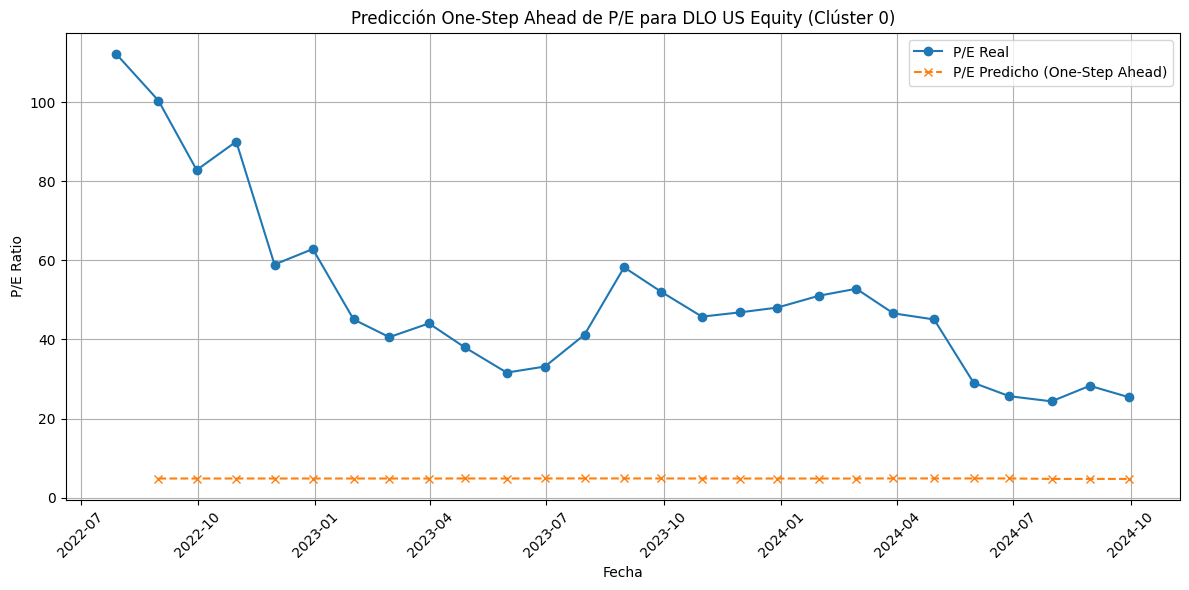


Predicciones finales para DLO US Equity:
        Fecha        Empresa      P_E  Cluster  P_E_predicho
22 2024-05-31  DLO US Equity  29.0140        0      4.852933
23 2024-06-28  DLO US Equity  25.6528        0      4.852933
24 2024-07-31  DLO US Equity  24.3527        0      4.732576
25 2024-08-30  DLO US Equity  28.2847        0      4.732576
26 2024-09-30  DLO US Equity  25.3674        0      4.732576


In [102]:
# ---------------------------------------------------------------------------------
# BLOQUE 15 COMPLETO Y CORREGIDO: Llamada a la Función predecir_empresa para DLOCAL
# ---------------------------------------------------------------------------------

# --- Asegúrate de que estas variables cruciales estén definidas desde bloques anteriores ---
# df_dlocal_con_promedio_lags: DataFrame de DLocal CON Lags _promedio_ y NaNs de lags eliminados.
# empresa_objetivo_dlocal: El nombre de la empresa (se define abajo).
# features_usadas_en_modelo_por_cluster: Lista de nombres de features rezagadas que los modelos supervisados esperan
#                                       (esta lista NO debe incluir 'Cluster' aquí).
#                                       Esta lista se define típicamente en el Bloque 12.
# mejores_modelos_por_cluster: Diccionario {cluster_id: ruta_modelo} (DEL BLOQUE 13).
# features_usadas_para_secuencias: Lista de columnas usadas para generar las secuencias de clustering
#                                 (DEBE incluir _promedio_lag1 para las macros).
# best_n_timesteps, best_step: Parámetros óptimos de clustering (del Bloque 3).
# La función predecir_empresa debe estar definida.

print("\n=== BLOQUE 15: Predicción para DLOCAL con predecir_empresa (Llamada Corregida) ===")

empresa_objetivo_dlocal = "DLO US Equity"
# nombre_metodo_usado_para_modelos se usó para crear df_dlocal_con_promedio_lags, no se necesita aquí directamente si ese df ya existe.

# --- 0. Verificar que df_dlocal_con_promedio_lags esté definido ---
if 'df_dlocal_con_promedio_lags' not in locals() or not isinstance(df_dlocal_con_promedio_lags, pd.DataFrame):
    raise NameError("'df_dlocal_con_promedio_lags' no está definido o no es un DataFrame. Ejecuta el bloque anterior donde se crea.")

df_dlocal_listo_para_funcion = df_dlocal_con_promedio_lags.copy()

if df_dlocal_listo_para_funcion.empty:
    print(f"El DataFrame preparado para '{empresa_objetivo_dlocal}' ('df_dlocal_con_promedio_lags') está vacío.")
    resultado_pred = None
else:
    # Verificar que el DataFrame sea solo de la empresa objetivo
    if not (df_dlocal_listo_para_funcion['Empresa'].astype(str).str.strip() == empresa_objetivo_dlocal.strip()).all():
        print(f"ADVERTENCIA: 'df_dlocal_listo_para_funcion' parece contener datos de más empresas que solo '{empresa_objetivo_dlocal}'.")
        df_dlocal_listo_para_funcion = df_dlocal_listo_para_funcion[
            df_dlocal_listo_para_funcion['Empresa'].astype(str).str.strip() == empresa_objetivo_dlocal.strip()
        ].copy()
        if df_dlocal_listo_para_funcion.empty:
            print(f"  Después de re-filtrar, no quedaron datos para '{empresa_objetivo_dlocal}'.")
            resultado_pred = None # Evitar error más adelante

    if not df_dlocal_listo_para_funcion.empty:
        print(f"Datos listos para '{empresa_objetivo_dlocal}' para la función predecir_empresa. Dimensiones: {df_dlocal_listo_para_funcion.shape}")

        # --- 1. Definir la lista de features que el modelo supervisado espera ---
        if 'features_usadas_en_modelo_por_cluster' not in locals():
            raise NameError("'features_usadas_en_modelo_por_cluster' no está definida. Esta debería ser la lista de nombres de las features rezagadas que entraron a los modelos supervisados (sin 'Cluster').")
        
        # CORRECCIÓN: 'features_modelo_supervisado' NO debe incluir 'Cluster' aquí,
        # porque los modelos por clúster se entrenaron sin 'Cluster' como feature.
        # La función predecir_empresa añade 'Cluster' al df_empresa internamente ANTES de la predicción,
        # pero las features que el modelo .predict() espera son solo las rezagadas escaladas.
        # Sin embargo, la función predecir_empresa que te di SÍ espera que 'features_modelo_supervisado'
        # incluya 'Cluster' para poder hacer el reordenamiento final.
        # La clave es que el scaler_supervisado NO se ajustó con 'Cluster'.
        # Y el modelo final NO se entrenó con 'Cluster' como una de sus columnas de entrada directas.

        # La lista que pasas a 'features_modelo_supervisado' debe ser la lista de columnas
        # que el modelo cargado (ej. rf_cluster_0_best.joblib) espera en su método .predict().
        # Esta lista se derivó de X_train_cluster_features dentro de entrenar_evaluar_modelos_por_cluster,
        # la cual NO tenía 'Cluster'.
        variable_lista_features_modelo_supervisado = features_usadas_en_modelo_por_cluster 
        print(f"Features para el modelo supervisado (argumento 'features_modelo_supervisado', NO incluye 'Cluster' aquí): {variable_lista_features_modelo_supervisado}")

        # --- 2. Definir las columnas usadas para el clustering ---
        if 'features_usadas_para_secuencias' not in locals():
            raise NameError("'features_usadas_para_secuencias' no está definida.")
        variable_columnas_features_clustering = features_usadas_para_secuencias
        print(f"Features para generar secuencias de clustering (argumento 'columnas_features_clustering'): {variable_columnas_features_clustering}")

        # --- 3. Definir rutas y parámetros de clustering ---
        if 'best_n_timesteps' not in locals() or 'best_step' not in locals():
            raise NameError("'best_n_timesteps' o 'best_step' no están definidos.")
        current_suffix_pred = f"{best_n_timesteps}m_step{best_step}"
        print(f"Usando suffix para archivos de clustering: {current_suffix_pred}")

        variable_scaler_supervisado_path = "scaler_supervisado_modelos.joblib"
        variable_clustering_model_path = f"kmeans_rolling_dtw_{current_suffix_pred}.joblib"
        variable_scaler_ts_clustering_path = f"scaler_ts_rolling_dtw_{current_suffix_pred}.joblib"

        # --- 4. Usar 'mejores_modelos_por_cluster' del Bloque 13 ---
        if 'mejores_modelos_por_cluster' not in locals() or not isinstance(mejores_modelos_por_cluster, dict):
            raise NameError("'mejores_modelos_por_cluster' no está definido o no es un diccionario.")
        variable_mejores_modelos_por_cluster = mejores_modelos_por_cluster

        # --- 5. Llamar a la función predecir_empresa ---
        if 'predecir_empresa' not in locals() or not callable(predecir_empresa):
            raise NameError("La función 'predecir_empresa' no está definida.")

        resultados_prediccion_dlocal = predecir_empresa(
            empresa_objetivo=empresa_objetivo_dlocal,
            df_historico_completo_empresa=df_dlocal_listo_para_funcion,
            scaler_supervisado_path=variable_scaler_supervisado_path,
            clustering_model_path=variable_clustering_model_path,
            features_modelo_supervisado=variable_lista_features_modelo_supervisado, # Lista SIN 'Cluster'
            mejores_modelos_por_cluster=variable_mejores_modelos_por_cluster,
            columnas_features_clustering=variable_columnas_features_clustering,
            scaler_ts_clustering_path=variable_scaler_ts_clustering_path,
            n_timesteps_clustering=best_n_timesteps,
            step_clustering=best_step
        )

        if resultados_prediccion_dlocal is not None and not resultados_prediccion_dlocal.empty:
            print(f"\nPredicciones finales para {empresa_objetivo_dlocal}:")
            print(resultados_prediccion_dlocal.tail())
        elif resultados_prediccion_dlocal is not None and resultados_prediccion_dlocal.empty:
            print(f"La función predecir_empresa devolvió un DataFrame vacío para {empresa_objetivo_dlocal}.")
        else:
            print(f"No se pudo generar la predicción para {empresa_objetivo_dlocal} (la función predecir_empresa devolvió None).")
    else: # Si df_dlocal_listo_para_funcion estaba vacío después del re-filtrado
        resultado_pred = None # Asegurar que está definido
        print(f"No hay datos para {empresa_objetivo_dlocal} para proceder con la predicción.")

if 'resultado_pred' not in locals(): # Si el bloque 'else' principal no se ejecutó
    print(f"La predicción no se ejecutó para {empresa_objetivo_dlocal} porque no se encontraron datos iniciales.")


=== BLOQUE 15: Predicción para DLOCAL con predecir_empresa (Step de Clustering Ajustable) ===
Usando un STEP específico de 1 para la asignación de clúster de 'DLO US Equity'.
Datos listos para 'DLO US Equity' para la función predecir_empresa. Dimensiones: (27, 64)
Features para el modelo supervisado (argumento 'features_modelo_supervisado', NO incluye 'Cluster'): ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 'ROA_l_lag1', 'ROCE_l_lag1', 'ROI_l_lag1', 'Total Activos_l_lag1', 'dif_CPI_promedio_lag1', 'dif_FFR_promedio_lag1', 'dif_NFP_promedio_lag1']
Features para generar secuencias de clustering (argumento 'columnas_features_clustering'): ['Beneficio neto_l_lag1', 'Cap de mercado_l_lag1', 'Deuda a CP_l_lag1', 'Deuda a LP_l_lag1', 'EBIT_l_lag1', 'EV_l_lag1', 'Efectivo y equiv_l_lag1', 'P_B_lag1', 'P_E_lag1', 'P_S_lag1', 'P_Share_lag1', 

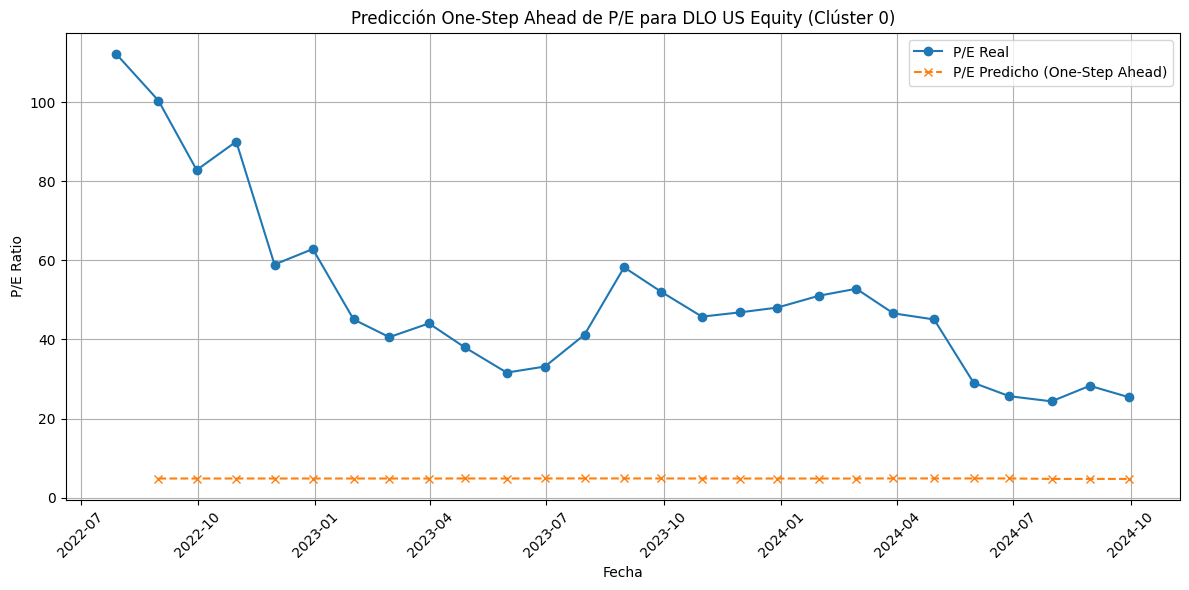


Predicciones finales para DLO US Equity:
        Fecha        Empresa      P_E  Cluster  P_E_predicho
22 2024-05-31  DLO US Equity  29.0140        0      4.852933
23 2024-06-28  DLO US Equity  25.6528        0      4.852933
24 2024-07-31  DLO US Equity  24.3527        0      4.732576
25 2024-08-30  DLO US Equity  28.2847        0      4.732576
26 2024-09-30  DLO US Equity  25.3674        0      4.732576


In [103]:
# ---------------------------------------------------------------------------------
# BLOQUE 15 COMPLETO Y CORREGIDO: Llamada a predecir_empresa para DLOCAL
# (con step de clustering ajustable para la predicción de DLocal)
# ---------------------------------------------------------------------------------
import pandas as pd # Asegurar que pandas esté importado si es una celda nueva
import numpy as np # Para np.nan si es necesario

# --- Asegúrate de que estas variables cruciales estén definidas desde bloques anteriores ---
# df_dlocal_con_promedio_lags: DataFrame de DLocal CON Lags _promedio_ y NaNs de lags eliminados.
# empresa_objetivo_dlocal: El nombre de la empresa (se define abajo).
# features_usadas_en_modelo_por_cluster: Lista de nombres de features rezagadas que los modelos supervisados esperan (SIN 'Cluster').
# mejores_modelos_por_cluster: Diccionario {cluster_id: ruta_modelo}.
# features_usadas_para_secuencias: Lista de columnas usadas para generar las secuencias de clustering.
# best_n_timesteps, best_step: Parámetros óptimos del clustering general (usados para cargar modelos de clustering).
# La función predecir_empresa debe estar definida.

print("\n=== BLOQUE 15: Predicción para DLOCAL con predecir_empresa (Step de Clustering Ajustable) ===")

empresa_objetivo_dlocal = "DLO US Equity"

# --- 0. Verificar que df_dlocal_con_promedio_lags esté definido ---
if 'df_dlocal_con_promedio_lags' not in locals() or not isinstance(df_dlocal_con_promedio_lags, pd.DataFrame):
    raise NameError("'df_dlocal_con_promedio_lags' no está definido o no es un DataFrame. Ejecuta el bloque anterior donde se crea.")

df_dlocal_listo_para_funcion = df_dlocal_con_promedio_lags.copy()

# --- PARÁMETRO AJUSTABLE PARA EL STEP DE CLUSTERING DE DLOCAL ---
# El best_step se usó para entrenar el modelo de clustering y seleccionar el número de clústeres.
# Para la asignación de clúster de UNA SOLA empresa (DLocal), podemos usar un step más pequeño
# para generar más ventanas y obtener una moda más robusta, si la empresa tiene suficientes datos.
step_especifico_para_pred_dlocal_clustering = 1 # Prueba con 1 para maximizar ventanas. Puedes cambiarlo.
print(f"Usando un STEP específico de {step_especifico_para_pred_dlocal_clustering} para la asignación de clúster de '{empresa_objetivo_dlocal}'.")
# El n_timesteps_clustering seguirá siendo best_n_timesteps porque el modelo de clustering se entrenó con ese tamaño de ventana.


if df_dlocal_listo_para_funcion.empty:
    print(f"El DataFrame preparado para '{empresa_objetivo_dlocal}' ('df_dlocal_con_promedio_lags') está vacío.")
    resultado_pred = None
else:
    if not (df_dlocal_listo_para_funcion['Empresa'].astype(str).str.strip() == empresa_objetivo_dlocal.strip()).all():
        print(f"ADVERTENCIA: 'df_dlocal_listo_para_funcion' parece contener datos de más empresas que solo '{empresa_objetivo_dlocal}'. Re-filtrando...")
        df_dlocal_listo_para_funcion = df_dlocal_listo_para_funcion[
            df_dlocal_listo_para_funcion['Empresa'].astype(str).str.strip() == empresa_objetivo_dlocal.strip()
        ].copy()
        if df_dlocal_listo_para_funcion.empty:
            print(f"  Después de re-filtrar, no quedaron datos para '{empresa_objetivo_dlocal}'.")
            resultado_pred = None

    if not df_dlocal_listo_para_funcion.empty:
        print(f"Datos listos para '{empresa_objetivo_dlocal}' para la función predecir_empresa. Dimensiones: {df_dlocal_listo_para_funcion.shape}")

        # --- 1. Definir la lista de features que el modelo supervisado espera ---
        if 'features_usadas_en_modelo_por_cluster' not in locals():
            raise NameError("'features_usadas_en_modelo_por_cluster' no está definida.")
        variable_lista_features_modelo_supervisado = features_usadas_en_modelo_por_cluster
        print(f"Features para el modelo supervisado (argumento 'features_modelo_supervisado', NO incluye 'Cluster'): {variable_lista_features_modelo_supervisado}")

        # --- 2. Definir las columnas usadas para el clustering ---
        if 'features_usadas_para_secuencias' not in locals():
            raise NameError("'features_usadas_para_secuencias' no está definida.")
        variable_columnas_features_clustering = features_usadas_para_secuencias
        print(f"Features para generar secuencias de clustering (argumento 'columnas_features_clustering'): {variable_columnas_features_clustering}")

        # --- 3. Definir rutas y parámetros de clustering ---
        if 'best_n_timesteps' not in locals() or 'best_step' not in locals(): # best_step es el usado para entrenar el k-means
            raise NameError("'best_n_timesteps' o 'best_step' (del entrenamiento general) no están definidos.")
        
        # El suffix para cargar los modelos de clustering DEBE ser el del entrenamiento original
        suffix_modelos_clustering_entrenados = f"{best_n_timesteps}m_step{best_step}"
        print(f"Usando suffix '{suffix_modelos_clustering_entrenados}' para cargar los modelos de clustering (kmeans y scaler_ts).")

        variable_scaler_supervisado_path = "scaler_supervisado_modelos.joblib"
        variable_clustering_model_path = f"kmeans_rolling_dtw_{suffix_modelos_clustering_entrenados}.joblib"
        variable_scaler_ts_clustering_path = f"scaler_ts_rolling_dtw_{suffix_modelos_clustering_entrenados}.joblib"

        # --- 4. Usar 'mejores_modelos_por_cluster' del Bloque 13 ---
        if 'mejores_modelos_por_cluster' not in locals() or not isinstance(mejores_modelos_por_cluster, dict):
            raise NameError("'mejores_modelos_por_cluster' no está definido o no es un diccionario.")
        variable_mejores_modelos_por_cluster = mejores_modelos_por_cluster

        # --- 5. Llamar a la función predecir_empresa ---
        if 'predecir_empresa' not in locals() or not callable(predecir_empresa):
            raise NameError("La función 'predecir_empresa' no está definida.")

        resultados_prediccion_dlocal = predecir_empresa(
            empresa_objetivo=empresa_objetivo_dlocal,
            df_historico_completo_empresa=df_dlocal_listo_para_funcion,
            scaler_supervisado_path=variable_scaler_supervisado_path,
            clustering_model_path=variable_clustering_model_path, # Modelo de clustering entrenado con best_step
            features_modelo_supervisado=variable_lista_features_modelo_supervisado,
            mejores_modelos_por_cluster=variable_mejores_modelos_por_cluster,
            columnas_features_clustering=variable_columnas_features_clustering,
            scaler_ts_clustering_path=variable_scaler_ts_clustering_path, # Scaler de TS entrenado con datos generales
            n_timesteps_clustering=best_n_timesteps, # Tamaño de ventana del modelo de clustering
            step_clustering=step_especifico_para_pred_dlocal_clustering # Step ajustado para DLocal
        )

        if resultados_prediccion_dlocal is not None and not resultados_prediccion_dlocal.empty:
            print(f"\nPredicciones finales para {empresa_objetivo_dlocal}:")
            print(resultados_prediccion_dlocal.tail())
        elif resultados_prediccion_dlocal is not None and resultados_prediccion_dlocal.empty:
            print(f"La función predecir_empresa devolvió un DataFrame vacío para {empresa_objetivo_dlocal}.")
        else:
            print(f"No se pudo generar la predicción para {empresa_objetivo_dlocal} (la función predecir_empresa devolvió None).")
    else:
        resultado_pred = None
        print(f"No hay datos para {empresa_objetivo_dlocal} para proceder con la predicción.")

if 'resultado_pred' not in locals():
    print(f"La predicción no se ejecutó para {empresa_objetivo_dlocal} porque no se encontraron datos iniciales o hubo un error previo.")